# H → ZZ* → 4ℓ — Machine-Learning Analysis Notebook

Companion code to *"A Machine-Learning Analysis of the Higgs Boson in the
H → ZZ\* → 4ℓ Channel"* (Papoyan & Keoshkerian, AUA).

Pipeline: ATLAS Open Data 2025 (√s = 13 TeV, 36.6 fb⁻¹) → preselection &
4-lepton invariant mass → Z₁/Z₂ reconstruction → 31 physics-motivated
features → separation-power ranking & correlation pruning (20 features kept)
→ 7 classifiers under a common 5-fold stratified CV protocol → real-data
test on 1,279 ATLAS events with two background-estimation methods
(MC prediction and data-driven sideband extrapolation).


## 1. Imports and environment setup

All third-party imports needed throughout the notebook are consolidated here so
each downstream cell can be re-run independently without local re-imports.

In [1]:
# Run once per fresh environment (e.g. a new Colab session)
import sys
!{sys.executable} -m pip install -q uproot awkward vector atlasopenmagic xgboost lightgbm tensorflow seaborn

# atlasopenmagic helper that drops the required ROOT/data dependencies in
from atlasopenmagic import install_from_environment
install_from_environment()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 11.3 MB/s eta 0:00:00
Installing packages: ['aiohttp>=3.9.5', 'atlasopenmagic>=1.2.0', 'awkward>=2.6.7', 'awkward-pandas>=2023.8.0', 'coffea~=0.7.0', 'fsspec>=2025.7.0', 'hist>=2.8.0', 'ipykernel>=6.29.5', 'jupyter>=1.0.0', 'lmfit>=1.3.2', 'matplotlib>=3.9.1', 'metakernel>=0.30.2', 'notebook<7', 'numpy>=1.26.4', 'pandas>=2.2.2', 'papermill>=2.6.0', 'pip>=24.2', 'scikit-learn>=1.5.1', 'uproot>=5.3.10', 'uproot3>=3.14.4', 'fsspec-xrootd>=0.5.1', 'jupyterlab_latex~=3.1.0', 'vector>=1.4.1']
Installation complete. You may need to restart your Python environment for changes to take effect.


In [2]:
# ----- core numerics, I/O, plotting -----
import os, time, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator

# ----- HEP-specific I/O and 4-vector arithmetic -----
import uproot          # read ROOT files (columnar format used in HEP)
import awkward as ak   # nested/variable-length arrays
import vector          # vectorised 4-momentum operations & Lorentz boosts
import atlasopenmagic as atom   # ATLAS Open Data access helper

# ----- statistics -----
from scipy.stats import norm

# ----- scikit-learn: splits, preprocessing, metrics, classical models -----
from sklearn.model_selection         import StratifiedKFold, train_test_split
from sklearn.preprocessing           import StandardScaler
from sklearn.metrics                 import roc_auc_score, roc_curve
from sklearn.ensemble                import RandomForestClassifier
from sklearn.linear_model            import LogisticRegression
from sklearn.naive_bayes             import GaussianNB
from sklearn.discriminant_analysis   import QuadraticDiscriminantAnalysis

# ----- boosted trees -----
import xgboost as xgb
import lightgbm as lgb

# ----- Keras MLP -----
import tensorflow as tf
from tensorflow.keras.models     import Sequential
from tensorflow.keras.layers     import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks  import EarlyStopping

# Pick the ATLAS Open Data release used in the paper (13 TeV, 2025 beta).
atom.set_release('2025e-13tev-beta')

# Energy unit convention used by the Open Data ROOT files.
MeV = 0.001
GeV = 1.0


Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 1083.46datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


## 2. Data and simulated samples *(paper §III)*

ATLAS Open Data 2025 release: √s = 13 TeV proton-proton collisions recorded in
2015–2016 at L = 36.6 fb⁻¹, together with the Monte-Carlo samples for the
H → ZZ\* → 4ℓ signal and for the irreducible ZZ\* and reducible (Z+jets, tt̄,
tt̄+V, VVV) backgrounds.

The samples are pulled directly from the ATLAS Open Data portal through the
`atlasopenmagic` Python package, using the `exactly4lep` skim (events with
exactly four reconstructed leptons).

In [3]:
# ----------------------------------------------------------------------------
# Sample definitions (paper Table II — yields are reproduced after preselection)
# ----------------------------------------------------------------------------
lumi      = 36.6        # integrated luminosity [fb^-1]
fraction  = 1.0         # fraction of events per file to process (1.0 = all)
skim      = "exactly4lep"

# Group dataset IDs into Data / backgrounds / signal as in the paper.
defs = {
    r'Data':                                       {'dids': ['data']},
    r'Background $Z,t\bar{t},t\bar{t}+V,VVV$':   {'dids': [410470, 410155, 410218, 410219, 412043,
                                                              364243, 364242, 364246, 364248,
                                                              700320, 700321, 700322, 700323,
                                                              700324, 700325],
                                                    'color': "#6b59d3"},
    r'Background $ZZ^{*}$':                        {'dids': [700600], 'color': "#ff0000"},
    r'Signal ($m_H$ = 125 GeV)':                   {'dids': [345060, 346228, 346310, 346311, 346312,
                                                              346340, 346341, 346342],
                                                    'color': "#00cdff"},
}

samples = atom.build_dataset(defs, skim=skim, protocol='https', cache=True)


## 3. Preselection cuts *(paper §IV)*

Selection requirements applied on top of the `exactly4lep` skim:

* Trigger: at least one of the single-electron (`trigE`) or single-muon (`trigM`) triggers fired, and at least one reconstructed lepton matched to that trigger.
* Lepton ID/isolation: all four leptons pass Loose ID + Loose isolation (electrons), or Medium ID + Loose isolation (muons).
* Same-flavour, opposite-sign pairing: lepton-type sum ∈ {44, 48, 52} excluded by `cut_lep_type`, charge sum = 0 by `cut_lep_charge`.
* pT staircase (paper Table I): pT(ℓ₁) > 20, pT(ℓ₂) > 15, pT(ℓ₃) > 10, pT(ℓ₄) > 7 GeV.

`calc_weight` builds the per-event luminosity weight w_total described in
paper §VI (Eqs. 1–2): cross-section × filter-efficiency × k-factor × MC weight,
multiplied by pile-up / lepton-reconstruction / lepton-trigger scale factors.

In [4]:
# ----------------------------------------------------------------------------
# Branches read from the ROOT files
# ----------------------------------------------------------------------------
variables = ['lep_pt', 'lep_eta', 'lep_phi', 'lep_e',
             'lep_charge', 'lep_type',
             'trigE', 'trigM', 'lep_isTrigMatched',
             'lep_isLooseID', 'lep_isMediumID', 'lep_isLooseIso']

weight_variables = ["filteff", "kfac", "xsec", "mcWeight",
                    "ScaleFactor_PILEUP",
                    "ScaleFactor_ELE", "ScaleFactor_MUON",
                    "ScaleFactor_LepTRIGGER"]

# ----------------------------------------------------------------------------
# Per-event filtering functions
# ----------------------------------------------------------------------------
# Cut on lepton-type sum: keep only 4e / 4mu / 2e2mu combinations
# (electron type = 11, muon type = 13; the rejected sums {44, 48, 52} are
# wrong-flavour combinations).
def cut_lep_type(lep_type):
    sum_lep_type = lep_type[:, 0] + lep_type[:, 1] + lep_type[:, 2] + lep_type[:, 3]
    # True = remove this event
    return (sum_lep_type != 44) & (sum_lep_type != 48) & (sum_lep_type != 52)

# Charge sum must be zero (two opposite-sign pairs).
def cut_lep_charge(lep_charge):
    sum_lep_charge = lep_charge[:, 0] + lep_charge[:, 1] + lep_charge[:, 2] + lep_charge[:, 3] != 0
    return sum_lep_charge   # True = remove this event

# Four-lepton invariant mass (paper §V): m_4l = |p_tot|.M from summed 4-vectors.
def calc_mass(lep_pt, lep_eta, lep_phi, lep_e):
    p4 = vector.zip({"pt": lep_pt, "eta": lep_eta, "phi": lep_phi, "E": lep_e})
    return (p4[:, 0] + p4[:, 1] + p4[:, 2] + p4[:, 3]).M

# Per-event luminosity-scaled weight (paper §VI, Eqs. 1 & 2).
def calc_weight(weight_variables, events):
    total_weight = lumi * 1000 / events["sum_of_weights"]
    for variable in weight_variables:
        total_weight = total_weight * abs(events[variable])
    return total_weight

# Require at least one trigger-matched lepton.
def cut_trig_match(lep_trigmatch):
    return ak.sum(lep_trigmatch, axis=1) >= 1

# Require single-e OR single-mu trigger fired.
def cut_trig(trigE, trigM):
    return trigE | trigM

# All four leptons pass tight enough ID + isolation:
#   electrons: Loose ID + Loose iso
#   muons:     Medium ID + Loose iso
def ID_iso_cut(IDel, IDmu, isoel, isomu, pid):
    return (ak.sum(((pid == 13) & IDmu & isomu) |
                   ((pid == 11) & IDel & isoel), axis=1) == 4)


### 3.1 Apply preselection to all samples

Loop over Data + every Monte-Carlo sample, apply the trigger / staircase /
ID-iso / SFOS preselection of paper §IV, compute m_4l (paper §V) and the
per-event luminosity weight w_total (paper §VI), then concatenate into
`all_data[sample_name]`.

In [5]:
# Set luminosity to 36.6 fb-1, data size of the full release
lumi = 36.6

# Controls the fraction of all events analysed
fraction = 1.0 # reduce this is if you want quicker runtime (implemented in the loop over the tree)

# Define empty dictionary to hold awkward arrays
all_data = {}

# Loop over samples
for s in samples:

    # Print which sample is being processed
    print('Processing '+s+' samples')

    # Define empty list to hold data
    frames = []

    # Loop over each file
    for val in samples[s]['list']:
        if s == 'data':
            prefix = "Data/" # Data prefix
        else: # MC prefix
            prefix = "MC/mc_"
        fileString = val

        # start the clock
        start = time.time()
        print("\t"+val+":")

        # Open file
        tree = uproot.open(fileString + ":analysis")

        sample_data = []

        # Loop over data in the tree
        for data in tree.iterate(variables + weight_variables + ["sum_of_weights", "lep_n", 'jet_n', "met", "met_phi"],
                                 library="ak",
                                 entry_stop=tree.num_entries*fraction):#, # process up to numevents*fraction
                                #  step_size = 10000000):

            # Number of events in this batch
            nIn = len(data)

            data = data[cut_trig(data.trigE, data.trigM)]
            data = data[cut_trig_match(data.lep_isTrigMatched)]

            # Record transverse momenta (see bonus activity for explanation)
            data['leading_lep_pt'] = data['lep_pt'][:,0]
            data['sub_leading_lep_pt'] = data['lep_pt'][:,1]
            data['third_leading_lep_pt'] = data['lep_pt'][:,2]
            data['last_lep_pt'] = data['lep_pt'][:,3]

            # Cuts on transverse momentum
            data = data[data['leading_lep_pt'] > 20]
            data = data[data['sub_leading_lep_pt'] > 15]
            data = data[data['third_leading_lep_pt'] > 10]

            data = data[ID_iso_cut(data.lep_isLooseID,
                                   data.lep_isMediumID,
                                   data.lep_isLooseIso,
                                   data.lep_isLooseIso,
                                   data.lep_type)]

            # Number Cuts
            #data = data[data['lep_n'] == 4]

            # Lepton cuts

            lep_type = data['lep_type']
            data = data[~cut_lep_type(lep_type)]
            lep_charge = data['lep_charge']
            data = data[~cut_lep_charge(lep_charge)]

            # Invariant Mass
            data['mass'] = calc_mass(data['lep_pt'], data['lep_eta'], data['lep_phi'], data['lep_e'])

            # Store Monte Carlo weights in the data
            if 'data' not in s: # Only calculates weights if the data is MC
                data['totalWeight'] = calc_weight(weight_variables, data)
                # data['totalWeight'] = calc_weight(data)

            # Append data to the whole sample data list
            sample_data.append(data)

            if not 'data' in val:
                nOut = sum(data['totalWeight']) # sum of weights passing cuts in this batch
            else:
                nOut = len(data)

            elapsed = time.time() - start # time taken to process
            print("\t\t nIn: "+str(nIn)+",\t nOut: \t"+str(nOut)+"\t in "+str(round(elapsed,1))+"s") # events before and after

        frames.append(ak.concatenate(sample_data))

    all_data[s] = ak.concatenate(frames) # dictionary entry is concatenated awkward arrays

Processing Data samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root:
		 nIn: 3424,	 nOut: 	2	 in 1.6s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root:
		 nIn: 25092,	 nOut: 	17	 in 2.7s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root:
		 nIn: 16234,	 nOut: 	13	 in 3.1s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodG.exactly4lep.root:
		 nIn: 37101,	 nOut: 	24	 in 6.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodH.exactly4lep.root:
		 nIn: 12152,	 nOut: 	11	 in 1.6s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodJ.exactly4lep.root:

## 4. Four-lepton invariant-mass spectrum *(paper Fig. 2)*

Stacked m_4l histogram of all backgrounds plus the H → ZZ\* → 4ℓ signal,
overlaid with the ATLAS data points. The Higgs peak sits around
m_4l ≈ 125 GeV; the broad continuum above 180 GeV is dominated by
non-resonant ZZ\* production.

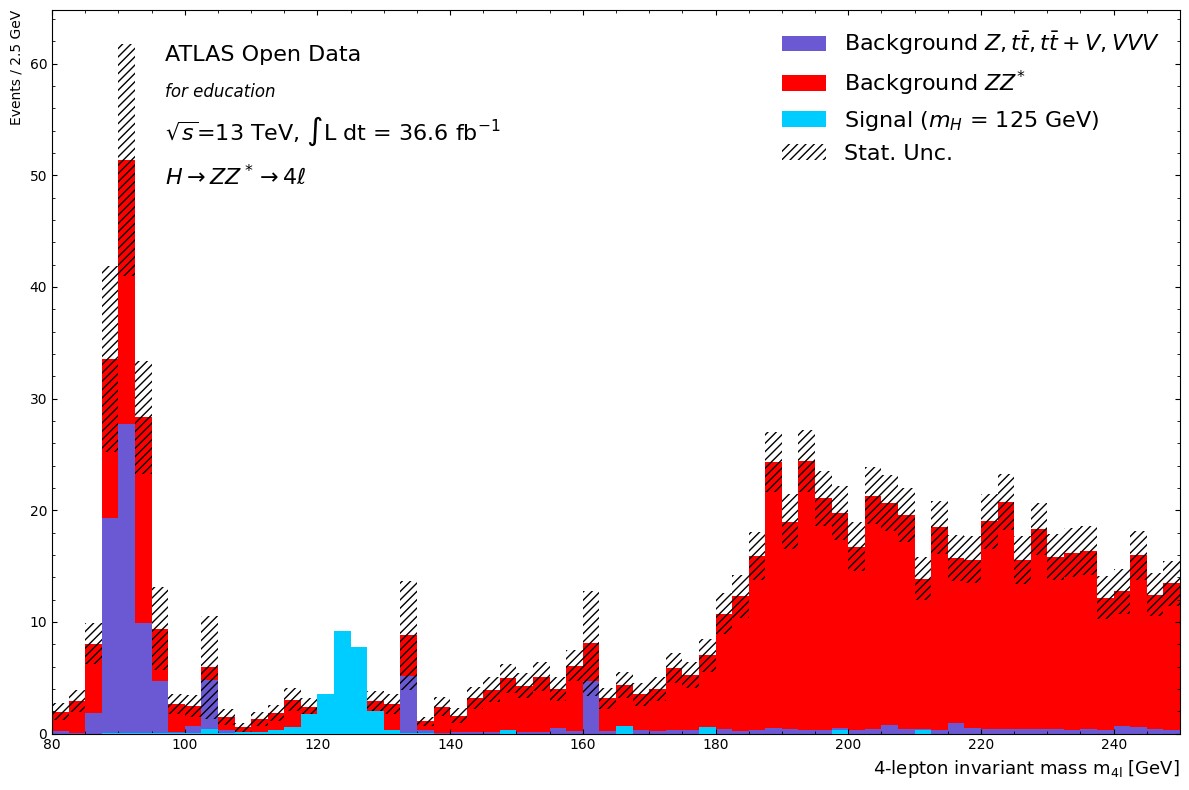

In [6]:
# x-axis range of the plot
xmin = 80 * GeV
xmax = 250 * GeV

# Histogram bin setup
step_size = 2.5 * GeV
bin_edges = np.arange(start=xmin, stop=xmax+step_size, step=step_size)
bin_centres = np.arange(start=xmin+step_size/2, stop=xmax+step_size/2, step=step_size)

signal_x       = ak.to_numpy(all_data[r'Signal ($m_H$ = 125 GeV)']['mass'])
signal_weights = ak.to_numpy(all_data[r'Signal ($m_H$ = 125 GeV)'].totalWeight)
signal_color   = samples[r'Signal ($m_H$ = 125 GeV)']['color']

mc_x, mc_weights, mc_colors, mc_labels = [], [], [], []
for s in samples:
    if s not in ['Data', r'Signal ($m_H$ = 125 GeV)']:
        mc_x.append(ak.to_numpy(all_data[s]['mass']))
        mc_weights.append(ak.to_numpy(all_data[s].totalWeight))
        mc_colors.append(samples[s]['color'])
        mc_labels.append(s)

fig, main_axes = plt.subplots(figsize=(12, 8))

# Stacked backgrounds
mc_heights = main_axes.hist(mc_x, bins=bin_edges,
                            weights=mc_weights, stacked=True,
                            color=mc_colors, label=mc_labels)
mc_x_tot = mc_heights[0][-1]

# Stat uncertainty
mc_x_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                                weights=np.hstack(mc_weights)**2)[0])
main_axes.bar(bin_centres, 2*mc_x_err,
              bottom=mc_x_tot - mc_x_err,
              alpha=0.5, color='none', hatch='////',
              width=step_size, label='Stat. Unc.')

# Signal — unfilled outline on top
main_axes.hist(signal_x, bins=bin_edges,
               weights=signal_weights,
              linewidth=2.0,
               color=signal_color,
               label=r'Signal ($m_H$ = 125 GeV)',
               zorder=5)

main_axes.set_xlim(left=xmin, right=xmax)
main_axes.set_ylim(bottom=0)
main_axes.xaxis.set_minor_locator(AutoMinorLocator())
main_axes.yaxis.set_minor_locator(AutoMinorLocator())
main_axes.tick_params(which='both', direction='in', top=True, right=True)

main_axes.set_xlabel(r'4-lepton invariant mass $\mathrm{m_{4l}}$ [GeV]',
                     fontsize=13, x=1, horizontalalignment='right')
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                     y=1, horizontalalignment='right')

plt.text(0.1, 0.93, 'ATLAS Open Data',  transform=main_axes.transAxes, fontsize=16)
plt.text(0.1, 0.88, 'for education',    transform=main_axes.transAxes, fontsize=12, style='italic')
plt.text(0.1, 0.82, rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
         transform=main_axes.transAxes, fontsize=16)
plt.text(0.1, 0.76, r'$H \rightarrow ZZ^* \rightarrow 4\ell$',
         transform=main_axes.transAxes, fontsize=16)

main_axes.legend(frameon=False, fontsize=16)
plt.tight_layout()
plt.show()

## 5. Z₁ / Z₂ reconstruction and feature engineering *(paper §V & §VII)*

`reconstruct_z1_z2_fast` does the per-event work:

1. For each of the three possible 4-lepton → 2 dilepton pairings, check
   same-flavour opposite-sign on both pairs; pick the pairing whose
   `m(Z_candidate)` lies closest to the nominal m_Z = 91.2 GeV. That pair
   becomes Z₁ (on-shell); the other becomes Z₂ (off-shell).
2. Boost the lepton 4-momenta into the Z₁, Z₂ and Higgs rest frames and compute
   the five helicity-frame angles θ₁, θ₂, Θ, Φ, Φ₁ following the convention of
   Gao et al. (paper §VII.A.4).
3. Compute angular separation observables (intra-Z Δφ, cross-pair ΔR) and
   scalar pT sums (paper §VII.A.5–6).
4. Pull in the event-level observables N_jet, MET, ϕ_miss (paper §VII.A.7).

The 31 physics-motivated features produced here are the inputs to all
downstream feature ranking and classifier training cells.

In [7]:
MZ = 91.2  # GeV — nominal Z boson mass (paper §V)

# ----------------------------------------------------------------------------
# Lab-frame angular helpers
# ----------------------------------------------------------------------------
def opening_dphi(phi1, phi2):
    # Wrap |delta_phi| into [0, pi]
    dphi = np.abs(phi1 - phi2)
    return np.where(dphi > np.pi, 2*np.pi - dphi, dphi)

def delta_r(eta1, phi1, eta2, phi2):
    deta = eta1 - eta2
    dphi = opening_dphi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)


## 6. Feature-distribution plots *(paper Fig. 3 et seq.)*

Stacked signal-vs-background histograms for every feature group: lepton
transverse momenta, pseudorapidities, helicity angles, intra-Z Δφ,
cross-pair ΔR, scalar pT sums, lepton-flavour composition, jet-categorised
pT shapes, kinematic ratios, jet multiplicity, and MET.

These plots are the visual check on which features show the largest
shape difference between signal and background; the quantitative version
(separation power δ²) is computed in §7.

In [8]:
# ---------------------------------------------------------------
# Z1/Z2 reconstruction helpers
# ---------------------------------------------------------------
import itertools

MZ = 91.2  # GeV — nominal Z boson mass

def reconstruct_z1_z2(lep_pt, lep_eta, lep_phi, lep_e, lep_charge, lep_type):
    """
    For every event reconstruct Z1 (closest to MZ) and Z2 (the other pair).
    Returns (mZ1, mZ2) as numpy arrays (events that cannot form two SFOS pairs
    are dropped).
    """
    p4 = vector.zip({'pt': lep_pt, 'eta': lep_eta, 'phi': lep_phi, 'E': lep_e})

    mZ1_list, mZ2_list = [], []

    n_events = len(lep_pt)
    for i in range(n_events):
        charges = ak.to_numpy(lep_charge[i])   # shape (4,)
        types   = ak.to_numpy(lep_type[i])     # shape (4,)

        # All ways to split 4 leptons into two pairs: (0,1)(2,3), (0,2)(1,3), (0,3)(1,2)
        pairings = [((0,1),(2,3)), ((0,2),(1,3)), ((0,3),(1,2))]

        best = None
        for (a,b),(c,d) in pairings:
            # Both pairs must be SFOS
            if not (types[a]==types[b] and charges[a]+charges[b]==0):
                continue
            if not (types[c]==types[d] and charges[c]+charges[d]==0):
                continue

            m_ab = (p4[i,a] + p4[i,b]).M
            m_cd = (p4[i,c] + p4[i,d]).M

            # Z1 is the pair closer to MZ
            if abs(m_ab - MZ) <= abs(m_cd - MZ):
                mz1, mz2 = m_ab, m_cd
            else:
                mz1, mz2 = m_cd, m_ab

            if best is None or abs(mz1 - MZ) < abs(best[0] - MZ):
                best = (mz1, mz2)

        if best is not None:
            mZ1_list.append(best[0])
            mZ2_list.append(best[1])

    return np.array(mZ1_list), np.array(mZ2_list)

print('Z1/Z2 reconstruction function defined.')

Z1/Z2 reconstruction function defined.


In [10]:
def reconstruct_z1_z2_fast(d):
    pt  = d['lep_pt']
    eta = d['lep_eta']
    phi = d['lep_phi']
    e   = d['lep_e']
    q   = d['lep_charge']
    pid = d['lep_type']

    p4 = vector.zip({'pt': pt, 'eta': eta, 'phi': phi, 'E': e})

    pairings = [(0,1,2,3), (0,2,1,3), (0,3,1,2)]

    results = []
    for (i,j,k,l) in pairings:
        sfos_1 = (pid[:,i] == pid[:,j]) & (q[:,i] + q[:,j] == 0)
        sfos_2 = (pid[:,k] == pid[:,l]) & (q[:,k] + q[:,l] == 0)
        valid  = sfos_1 & sfos_2

        p4_z1 = p4[:,i] + p4[:,j]
        p4_z2 = p4[:,k] + p4[:,l]

        m_ij = p4_z1.M
        m_kl = p4_z2.M

        ij_is_Z1 = np.abs(ak.to_numpy(m_ij) - MZ) <= np.abs(ak.to_numpy(m_kl) - MZ)

        results.append({
            'valid': valid,
            'mz1':   np.where(ij_is_Z1, ak.to_numpy(m_ij),      ak.to_numpy(m_kl)),
            'mz2':   np.where(ij_is_Z1, ak.to_numpy(m_kl),      ak.to_numpy(m_ij)),
            'ptz1':  np.where(ij_is_Z1, ak.to_numpy(p4_z1.pt),  ak.to_numpy(p4_z2.pt)),
            'ptz2':  np.where(ij_is_Z1, ak.to_numpy(p4_z2.pt),  ak.to_numpy(p4_z1.pt)),
        })

    mz1_arr  = np.stack([r['mz1']  for r in results], axis=1)
    mz2_arr  = np.stack([r['mz2']  for r in results], axis=1)
    ptz1_arr = np.stack([r['ptz1'] for r in results], axis=1)
    ptz2_arr = np.stack([r['ptz2'] for r in results], axis=1)
    val_arr  = np.stack([ak.to_numpy(r['valid']) for r in results], axis=1)

    dist     = np.where(val_arr, np.abs(mz1_arr - MZ), np.inf)
    best_idx = np.argmin(dist, axis=1)
    row_idx  = np.arange(len(best_idx))

    valid_any = val_arr.any(axis=1)

    mZ1  = mz1_arr [row_idx, best_idx][valid_any]
    mZ2  = mz2_arr [row_idx, best_idx][valid_any]
    ptZ1 = ptz1_arr[row_idx, best_idx][valid_any]
    ptZ2 = ptz2_arr[row_idx, best_idx][valid_any]

    weights = ak.to_numpy(d['totalWeight'])[valid_any] if 'totalWeight' in d.fields else np.ones(len(mZ1))

    return mZ1, mZ2, ptZ1, ptZ2, weights


# Re-run reconstruction
z_masses = {}

for s in all_data:
    if s == 'Data':
        continue
    mZ1, mZ2, ptZ1, ptZ2, weights = reconstruct_z1_z2_fast(all_data[s])
    z_masses[s] = {'mZ1': mZ1, 'mZ2': mZ2, 'ptZ1': ptZ1, 'ptZ2': ptZ2, 'w': weights}
    print(f'{s}: {len(mZ1)} events reconstructed')

Background $Z,t\bar{t},t\bar{t}+V,VVV$: 6033 events reconstructed
Background $ZZ^{*}$: 6364 events reconstructed
Signal ($m_H$ = 125 GeV): 226120 events reconstructed


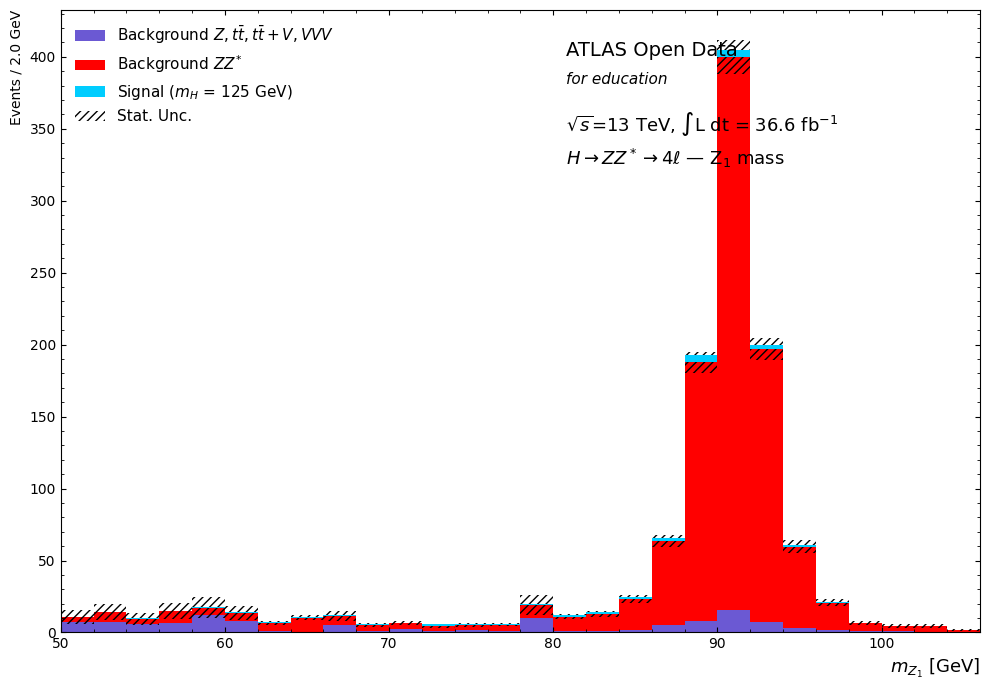

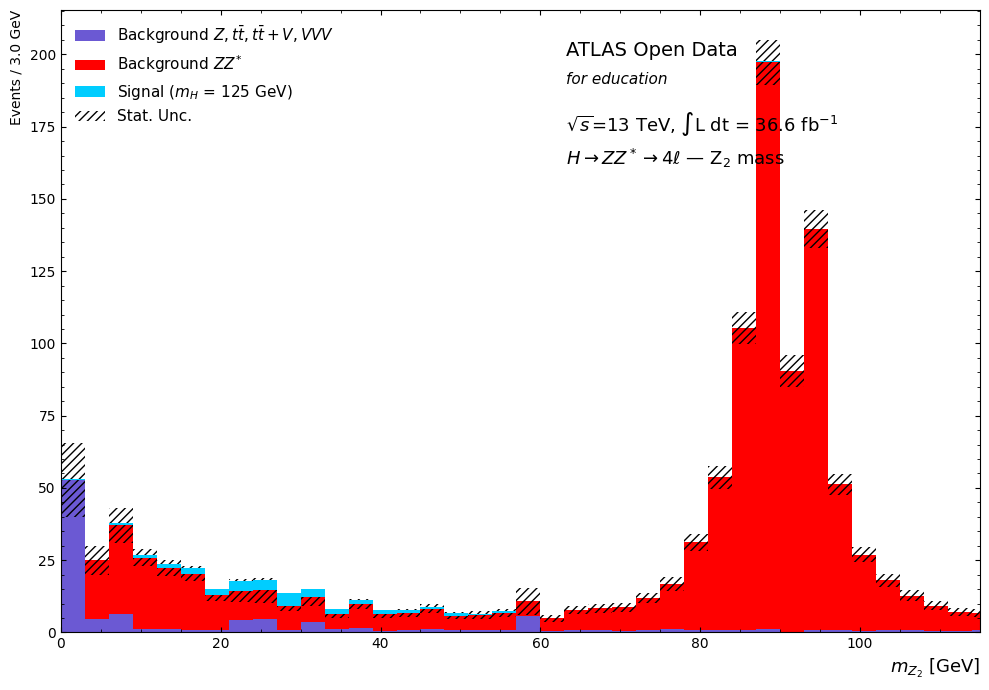

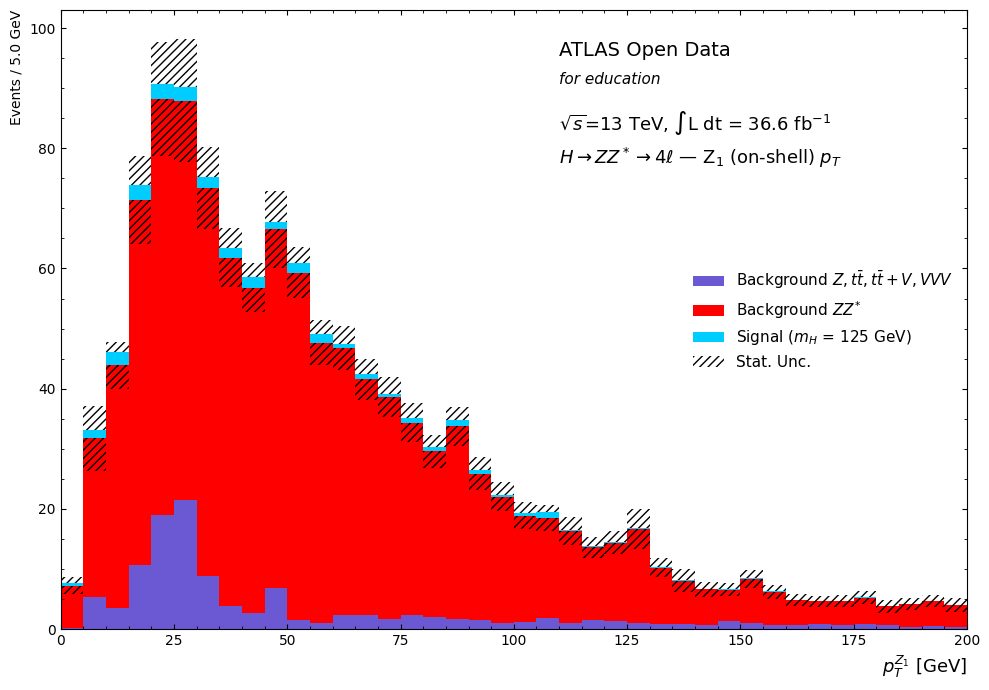

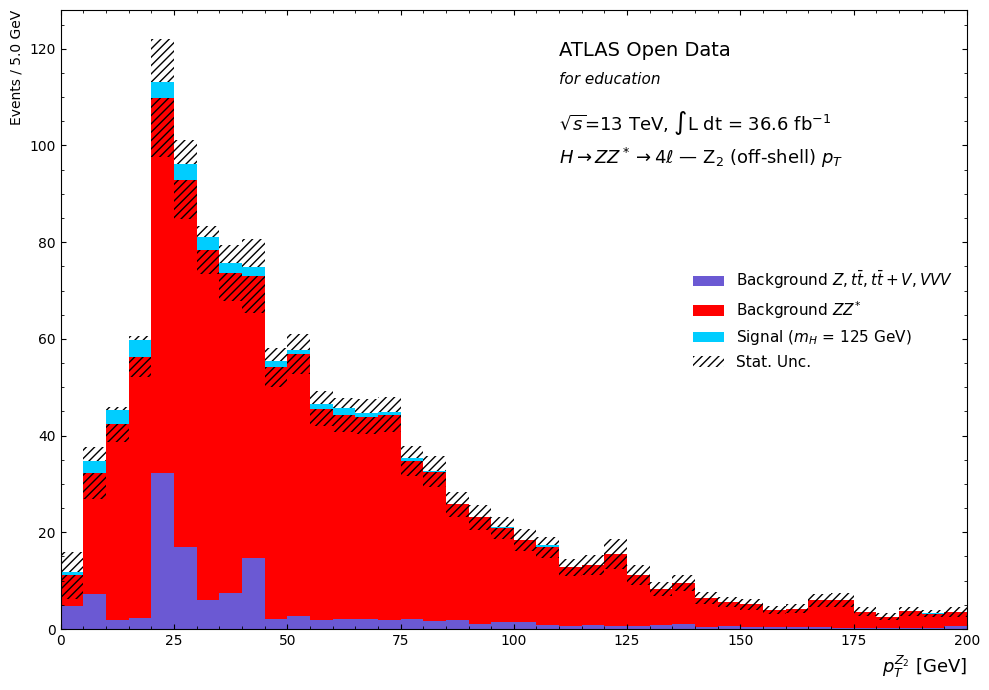

In [11]:
def plot_mc_feature(feat_key, xmin, xmax, step_size, title_label, xlabel):
    bin_edges   = np.arange(xmin, xmax + step_size, step_size)
    bin_centres = bin_edges[:-1] + step_size / 2

    sig_key      = r'Signal ($m_H$ = 125 GeV)'
    signal_x     = z_masses[sig_key][feat_key]
    signal_w     = z_masses[sig_key]['w']
    signal_color = samples[sig_key]['color']

    mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
    for s in z_masses:
        if s == sig_key:
            continue
        mc_x.append(z_masses[s][feat_key])
        mc_w.append(z_masses[s]['w'])
        mc_colors.append(samples[s]['color'])
        mc_labels.append(s)

    fig, ax = plt.subplots(figsize=(10, 7))

    mc_h   = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
    mc_tot = mc_h[0][-1]

    mc_err = np.sqrt(
        np.histogram(np.hstack(mc_x), bins=bin_edges,
                     weights=np.hstack(mc_w)**2)[0]
    )
    ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
           alpha=0.5, color='none', hatch='////', width=step_size,
           label='Stat. Unc.')

    ax.hist(signal_x, bins=bin_edges, weights=signal_w, bottom=mc_tot,
            color=signal_color, label=sig_key)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.set_xlabel(xlabel, fontsize=13, x=1, horizontalalignment='right')
    ax.set_ylabel(f'Events / {step_size} GeV', y=1, horizontalalignment='right')

    ax.text(0.55, 0.95, 'ATLAS Open Data',  transform=ax.transAxes, fontsize=14, va='top')
    ax.text(0.55, 0.90, 'for education',    transform=ax.transAxes, fontsize=11, style='italic', va='top')
    ax.text(0.55, 0.84, rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
            transform=ax.transAxes, fontsize=13, va='top')
    ax.text(0.55, 0.78, rf'$H \rightarrow ZZ^* \rightarrow 4\ell$ — {title_label}',
            transform=ax.transAxes, fontsize=13, va='top')

    ax.legend(frameon=False, fontsize=11)
    plt.tight_layout()
    plt.show()

# --- Z1 and Z2 mass plots (as before) ---
plot_mc_feature('mZ1',  50,  106, 2.0, r'Z$_1$ mass',      r'$m_{Z_1}$ [GeV]')
plot_mc_feature('mZ2',   0,  115, 3.0, r'Z$_2$ mass',      r'$m_{Z_2}$ [GeV]')

# --- Z1 and Z2 pT plots ---
plot_mc_feature('ptZ1',  0,  200, 5.0, r'Z$_1$ (on-shell) $p_T$',  r'$p_T^{Z_1}$ [GeV]')
plot_mc_feature('ptZ2',  0,  200, 5.0, r'Z$_2$ (off-shell) $p_T$', r'$p_T^{Z_2}$ [GeV]')

In [12]:
def reconstruct_z1_z2_fast(d):
    pt  = d['lep_pt']
    eta = d['lep_eta']
    phi = d['lep_phi']
    e   = d['lep_e']
    q   = d['lep_charge']
    pid = d['lep_type']

    p4 = vector.zip({'pt': pt, 'eta': eta, 'phi': phi, 'E': e})

    p4_4l = p4[:,0] + p4[:,1] + p4[:,2] + p4[:,3]
    pt4l  = ak.to_numpy(p4_4l.pt)

    vh_cart = np.stack([ak.to_numpy(p4_4l.energy), ak.to_numpy(p4_4l.px),
                        ak.to_numpy(p4_4l.py),     ak.to_numpy(p4_4l.pz)], axis=1)

    def to_cartesian(idx):
        px = ak.to_numpy(pt[:,idx]) * np.cos(ak.to_numpy(phi[:,idx]))
        py = ak.to_numpy(pt[:,idx]) * np.sin(ak.to_numpy(phi[:,idx]))
        pz = ak.to_numpy(pt[:,idx]) * np.sinh(ak.to_numpy(eta[:,idx]))
        en = ak.to_numpy(e[:,idx])
        return np.stack([en, px, py, pz], axis=1)

    def boost_to(p4vec, boost_target):
        E  = boost_target[:,0]
        bx = boost_target[:,1] / E
        by = boost_target[:,2] / E
        bz = boost_target[:,3] / E
        b2 = bx**2 + by**2 + bz**2
        gamma  = 1.0 / np.sqrt(np.maximum(1 - b2, 1e-12))
        bp     = bx*p4vec[:,1] + by*p4vec[:,2] + bz*p4vec[:,3]
        gamma2 = np.where(b2 > 0, (gamma - 1.0) / b2, 0.0)
        px_new = p4vec[:,1] + gamma2*bp*bx - gamma*bx*p4vec[:,0]
        py_new = p4vec[:,2] + gamma2*bp*by - gamma*by*p4vec[:,0]
        pz_new = p4vec[:,3] + gamma2*bp*bz - gamma*bz*p4vec[:,0]
        e_new  = gamma*(p4vec[:,0] - bp)
        return np.stack([e_new, px_new, py_new, pz_new], axis=1)

    def calc_theta(lneg, vz, vh):
        lneg_zrf = boost_to(lneg, vz)
        h_zrf    = boost_to(vh,   vz)
        z_dir = -h_zrf[:,1:4]
        z_dir = z_dir / (np.linalg.norm(z_dir, axis=1, keepdims=True) + 1e-12)
        l_dir = lneg_zrf[:,1:4]
        l_dir = l_dir / (np.linalg.norm(l_dir, axis=1, keepdims=True) + 1e-12)
        return np.arccos(np.clip(np.sum(z_dir * l_dir, axis=1), -1, 1))

    def calc_Theta(vz1, vh):
        vz1_hrf = boost_to(vz1, vh)
        z1_dir  = vz1_hrf[:,1:4]
        z1_dir  = z1_dir / (np.linalg.norm(z1_dir, axis=1, keepdims=True) + 1e-12)
        beam    = np.zeros_like(z1_dir); beam[:,2] = 1.0
        return np.arccos(np.clip(np.sum(z1_dir * beam, axis=1), -1, 1))

    def calc_phi_phi1(lneg1, lpos1, lneg2, lpos2, vz1, vh):
        lneg1_h = boost_to(lneg1, vh); lpos1_h = boost_to(lpos1, vh)
        lneg2_h = boost_to(lneg2, vh); lpos2_h = boost_to(lpos2, vh)
        vz1_h   = boost_to(vz1,   vh)

        def p3(v): return v[:,1:4]

        n1 = np.cross(p3(lneg1_h), p3(lpos1_h))
        n1 = n1 / (np.linalg.norm(n1, axis=1, keepdims=True) + 1e-12)
        n2 = np.cross(p3(lneg2_h), p3(lpos2_h))
        n2 = n2 / (np.linalg.norm(n2, axis=1, keepdims=True) + 1e-12)
        z1_dir = p3(vz1_h)
        z1_dir = z1_dir / (np.linalg.norm(z1_dir, axis=1, keepdims=True) + 1e-12)

        cos_phi  = np.clip(np.sum(n1 * n2, axis=1), -1, 1)
        sign_phi = np.sign(np.sum(n1 * np.cross(n2, z1_dir), axis=1))
        Phi      = sign_phi * np.arccos(cos_phi)

        beam    = np.zeros_like(z1_dir); beam[:,2] = 1.0
        n_prod  = np.cross(z1_dir, beam)
        norm_np = np.linalg.norm(n_prod, axis=1, keepdims=True)
        n_prod  = np.where(norm_np > 1e-6, n_prod / (norm_np + 1e-12), n_prod)
        cos_phi1  = np.clip(np.sum(n1 * n_prod, axis=1), -1, 1)
        sign_phi1 = np.sign(np.sum(n_prod * np.cross(n1, z1_dir), axis=1))
        Phi1      = sign_phi1 * np.arccos(cos_phi1)

        return Phi, Phi1

    pairings = [(0,1,2,3), (0,2,1,3), (0,3,1,2)]
    results  = []

    for (i,j,k,l) in pairings:
        sfos_1 = (pid[:,i] == pid[:,j]) & (q[:,i] + q[:,j] == 0)
        sfos_2 = (pid[:,k] == pid[:,l]) & (q[:,k] + q[:,l] == 0)
        valid  = sfos_1 & sfos_2

        p4_z1 = p4[:,i] + p4[:,j]
        p4_z2 = p4[:,k] + p4[:,l]
        m_ij  = p4_z1.M
        m_kl  = p4_z2.M

        ij_is_Z1 = np.abs(ak.to_numpy(m_ij) - MZ) <= np.abs(ak.to_numpy(m_kl) - MZ)

        pt_i,  pt_j  = ak.to_numpy(pt[:,i]),  ak.to_numpy(pt[:,j])
        pt_k,  pt_l  = ak.to_numpy(pt[:,k]),  ak.to_numpy(pt[:,l])
        eta_i, eta_j = ak.to_numpy(eta[:,i]), ak.to_numpy(eta[:,j])
        eta_k, eta_l = ak.to_numpy(eta[:,k]), ak.to_numpy(eta[:,l])
        phi_i, phi_j = ak.to_numpy(phi[:,i]), ak.to_numpy(phi[:,j])
        phi_k, phi_l = ak.to_numpy(phi[:,k]), ak.to_numpy(phi[:,l])

        i_is_lead_ij = pt_i >= pt_j
        k_is_lead_kl = pt_k >= pt_l

        vz1_cart = np.stack([ak.to_numpy(p4_z1.energy), ak.to_numpy(p4_z1.px),
                              ak.to_numpy(p4_z1.py),    ak.to_numpy(p4_z1.pz)], axis=1)
        vz2_cart = np.stack([ak.to_numpy(p4_z2.energy), ak.to_numpy(p4_z2.px),
                              ak.to_numpy(p4_z2.py),    ak.to_numpy(p4_z2.pz)], axis=1)

        vi = to_cartesian(i); vj = to_cartesian(j)
        vk = to_cartesian(k); vl = to_cartesian(l)

        qi = ak.to_numpy(q[:,i])
        qk = ak.to_numpy(q[:,k])
        lneg_ij = np.where(qi[:,None] < 0, vi, vj)
        lpos_ij = np.where(qi[:,None] >= 0, vi, vj)
        lneg_kl = np.where(qk[:,None] < 0, vk, vl)
        lpos_kl = np.where(qk[:,None] >= 0, vk, vl)

        theta1_ij = calc_theta(lneg_ij, vz1_cart, vh_cart)
        theta1_kl = calc_theta(lneg_kl, vz2_cart, vh_cart)
        theta1    = np.where(ij_is_Z1, theta1_ij, theta1_kl)
        theta2    = np.where(ij_is_Z1, theta1_kl, theta1_ij)

        vz1_final = np.where(ij_is_Z1[:,None], vz1_cart, vz2_cart)
        vz2_final = np.where(ij_is_Z1[:,None], vz2_cart, vz1_cart)

        Theta = calc_Theta(vz1_final, vh_cart)

        lneg_z1 = np.where(ij_is_Z1[:,None], lneg_ij, lneg_kl)
        lpos_z1 = np.where(ij_is_Z1[:,None], lpos_ij, lpos_kl)
        lneg_z2 = np.where(ij_is_Z1[:,None], lneg_kl, lneg_ij)
        lpos_z2 = np.where(ij_is_Z1[:,None], lpos_kl, lpos_ij)

        Phi, Phi1 = calc_phi_phi1(lneg_z1, lpos_z1, lneg_z2, lpos_z2,
                                   vz1_final, vh_cart)

        dphi_z1 = opening_dphi(phi_i, phi_j)
        dphi_z2 = opening_dphi(phi_k, phi_l)

        # All 6 inter-lepton dR pairs (raw, before Z1/Z2 assignment)
        dR_ij = delta_r(eta_i, phi_i, eta_j, phi_j)
        dR_ik = delta_r(eta_i, phi_i, eta_k, phi_k)
        dR_il = delta_r(eta_i, phi_i, eta_l, phi_l)
        dR_jk = delta_r(eta_j, phi_j, eta_k, phi_k)
        dR_jl = delta_r(eta_j, phi_j, eta_l, phi_l)
        dR_kl = delta_r(eta_k, phi_k, eta_l, phi_l)

        # ── Correct cross-pair dR after Z1/Z2 assignment ──────────────────
        # Lepton ordering within each Z: lead (0), sublead (1)
        # So the 4 assigned leptons are: Z1_lead(0), Z1_sub(1), Z2_lead(2), Z2_sub(3)
        # and the cross pairs are: 02, 03, 12, 13

        # eta/phi of each assigned lepton
        eta_z1_lead = np.where(ij_is_Z1,
                               np.where(i_is_lead_ij, eta_i, eta_j),
                               np.where(k_is_lead_kl, eta_k, eta_l))
        eta_z1_sub  = np.where(ij_is_Z1,
                               np.where(i_is_lead_ij, eta_j, eta_i),
                               np.where(k_is_lead_kl, eta_l, eta_k))
        eta_z2_lead = np.where(ij_is_Z1,
                               np.where(k_is_lead_kl, eta_k, eta_l),
                               np.where(i_is_lead_ij, eta_i, eta_j))
        eta_z2_sub  = np.where(ij_is_Z1,
                               np.where(k_is_lead_kl, eta_l, eta_k),
                               np.where(i_is_lead_ij, eta_j, eta_i))

        phi_z1_lead = np.where(ij_is_Z1,
                               np.where(i_is_lead_ij, phi_i, phi_j),
                               np.where(k_is_lead_kl, phi_k, phi_l))
        phi_z1_sub  = np.where(ij_is_Z1,
                               np.where(i_is_lead_ij, phi_j, phi_i),
                               np.where(k_is_lead_kl, phi_l, phi_k))
        phi_z2_lead = np.where(ij_is_Z1,
                               np.where(k_is_lead_kl, phi_k, phi_l),
                               np.where(i_is_lead_ij, phi_i, phi_j))
        phi_z2_sub  = np.where(ij_is_Z1,
                               np.where(k_is_lead_kl, phi_l, phi_k),
                               np.where(i_is_lead_ij, phi_j, phi_i))

        dR_02 = delta_r(eta_z1_lead, phi_z1_lead, eta_z2_lead, phi_z2_lead)
        dR_03 = delta_r(eta_z1_lead, phi_z1_lead, eta_z2_sub,  phi_z2_sub)
        dR_12 = delta_r(eta_z1_sub,  phi_z1_sub,  eta_z2_lead, phi_z2_lead)
        dR_13 = delta_r(eta_z1_sub,  phi_z1_sub,  eta_z2_sub,  phi_z2_sub)

        results.append({
            'valid':            valid,
            'mz1':              np.where(ij_is_Z1, ak.to_numpy(m_ij),     ak.to_numpy(m_kl)),
            'mz2':              np.where(ij_is_Z1, ak.to_numpy(m_kl),     ak.to_numpy(m_ij)),
            'ptz1':             np.where(ij_is_Z1, ak.to_numpy(p4_z1.pt), ak.to_numpy(p4_z2.pt)),
            'ptz2':             np.where(ij_is_Z1, ak.to_numpy(p4_z2.pt), ak.to_numpy(p4_z1.pt)),
            'pt_z1_l1':         np.where(ij_is_Z1, np.maximum(pt_i, pt_j), np.maximum(pt_k, pt_l)),
            'pt_z1_l2':         np.where(ij_is_Z1, np.minimum(pt_i, pt_j), np.minimum(pt_k, pt_l)),
            'pt_z2_l1':         np.where(ij_is_Z1, np.maximum(pt_k, pt_l), np.maximum(pt_i, pt_j)),
            'pt_z2_l2':         np.where(ij_is_Z1, np.minimum(pt_k, pt_l), np.minimum(pt_i, pt_j)),
            'pt4l':             pt4l,
            'eta_z1_l1':        eta_z1_lead,
            'eta_z1_l2':        eta_z1_sub,
            'eta_z2_l1':        eta_z2_lead,
            'eta_z2_l2':        eta_z2_sub,
            'theta1':           theta1,
            'theta2':           theta2,
            'Theta':            Theta,
            'Phi':              Phi,
            'Phi1':             Phi1,
            'dphi_z1':          np.where(ij_is_Z1, dphi_z1, dphi_z2),
            'dphi_z2':          np.where(ij_is_Z1, dphi_z2, dphi_z1),
            'dR_z1':            np.where(ij_is_Z1, dR_ij,   dR_kl),
            'dR_z2':            np.where(ij_is_Z1, dR_kl,   dR_ij),
            'dR_02':            dR_02,
            'dR_03':            dR_03,
            'dR_12':            dR_12,
            'dR_13':            dR_13,
            'scalar_pt_sum_z1': np.where(ij_is_Z1, pt_i + pt_j, pt_k + pt_l),
            'scalar_pt_sum_z2': np.where(ij_is_Z1, pt_k + pt_l, pt_i + pt_j),
            'type_z1_l1': np.where(ij_is_Z1,
                              np.where(i_is_lead_ij, ak.to_numpy(pid[:,i]), ak.to_numpy(pid[:,j])),
                              np.where(k_is_lead_kl, ak.to_numpy(pid[:,k]), ak.to_numpy(pid[:,l]))),
            'type_z1_l2': np.where(ij_is_Z1,
                              np.where(i_is_lead_ij, ak.to_numpy(pid[:,j]), ak.to_numpy(pid[:,i])),
                              np.where(k_is_lead_kl, ak.to_numpy(pid[:,l]), ak.to_numpy(pid[:,k]))),
            'type_z2_l1': np.where(ij_is_Z1,
                              np.where(k_is_lead_kl, ak.to_numpy(pid[:,k]), ak.to_numpy(pid[:,l])),
                              np.where(i_is_lead_ij, ak.to_numpy(pid[:,i]), ak.to_numpy(pid[:,j]))),
            'type_z2_l2': np.where(ij_is_Z1,
                              np.where(k_is_lead_kl, ak.to_numpy(pid[:,l]), ak.to_numpy(pid[:,k])),
                              np.where(i_is_lead_ij, ak.to_numpy(pid[:,j]), ak.to_numpy(pid[:,i]))),
            'jet_n':   ak.to_numpy(d['jet_n']),
            'met':     ak.to_numpy(d['met']),
            'met_phi': ak.to_numpy(d['met_phi']),
            'mass':    ak.to_numpy(d['mass']),
        })

    keys = ['mz1','mz2','ptz1','ptz2','pt4l',
            'pt_z1_l1','pt_z1_l2','pt_z2_l1','pt_z2_l2',
            'eta_z1_l1','eta_z1_l2','eta_z2_l1','eta_z2_l2',
            'theta1','theta2','Theta','Phi','Phi1',
            'dphi_z1','dphi_z2',
            'dR_z1','dR_z2','dR_02','dR_03','dR_12','dR_13',
            'scalar_pt_sum_z1','scalar_pt_sum_z2',
            'type_z1_l1','type_z1_l2','type_z2_l1','type_z2_l2',
            'jet_n','met','met_phi','mass']

    stacked   = {k: np.stack([r[k] for r in results], axis=1) for k in keys}
    val_arr   = np.stack([ak.to_numpy(r['valid']) for r in results], axis=1)

    dist      = np.where(val_arr, np.abs(stacked['mz1'] - MZ), np.inf)
    best_idx  = np.argmin(dist, axis=1)
    row_idx   = np.arange(len(best_idx))
    valid_any = val_arr.any(axis=1)

    out = {k: stacked[k][row_idx, best_idx][valid_any] for k in keys}
    out['w'] = ak.to_numpy(d['totalWeight'])[valid_any] if 'totalWeight' in d.fields else np.ones(valid_any.sum())
    return out

# Re-run reconstruction
z_masses = {}
for s in all_data:
    if s == 'Data':
        continue
    z_masses[s] = reconstruct_z1_z2_fast(all_data[s])
    print(f'{s}: {len(z_masses[s]["mz1"])} events reconstructed')

Background $Z,t\bar{t},t\bar{t}+V,VVV$: 6033 events reconstructed
Background $ZZ^{*}$: 6364 events reconstructed
Signal ($m_H$ = 125 GeV): 226120 events reconstructed


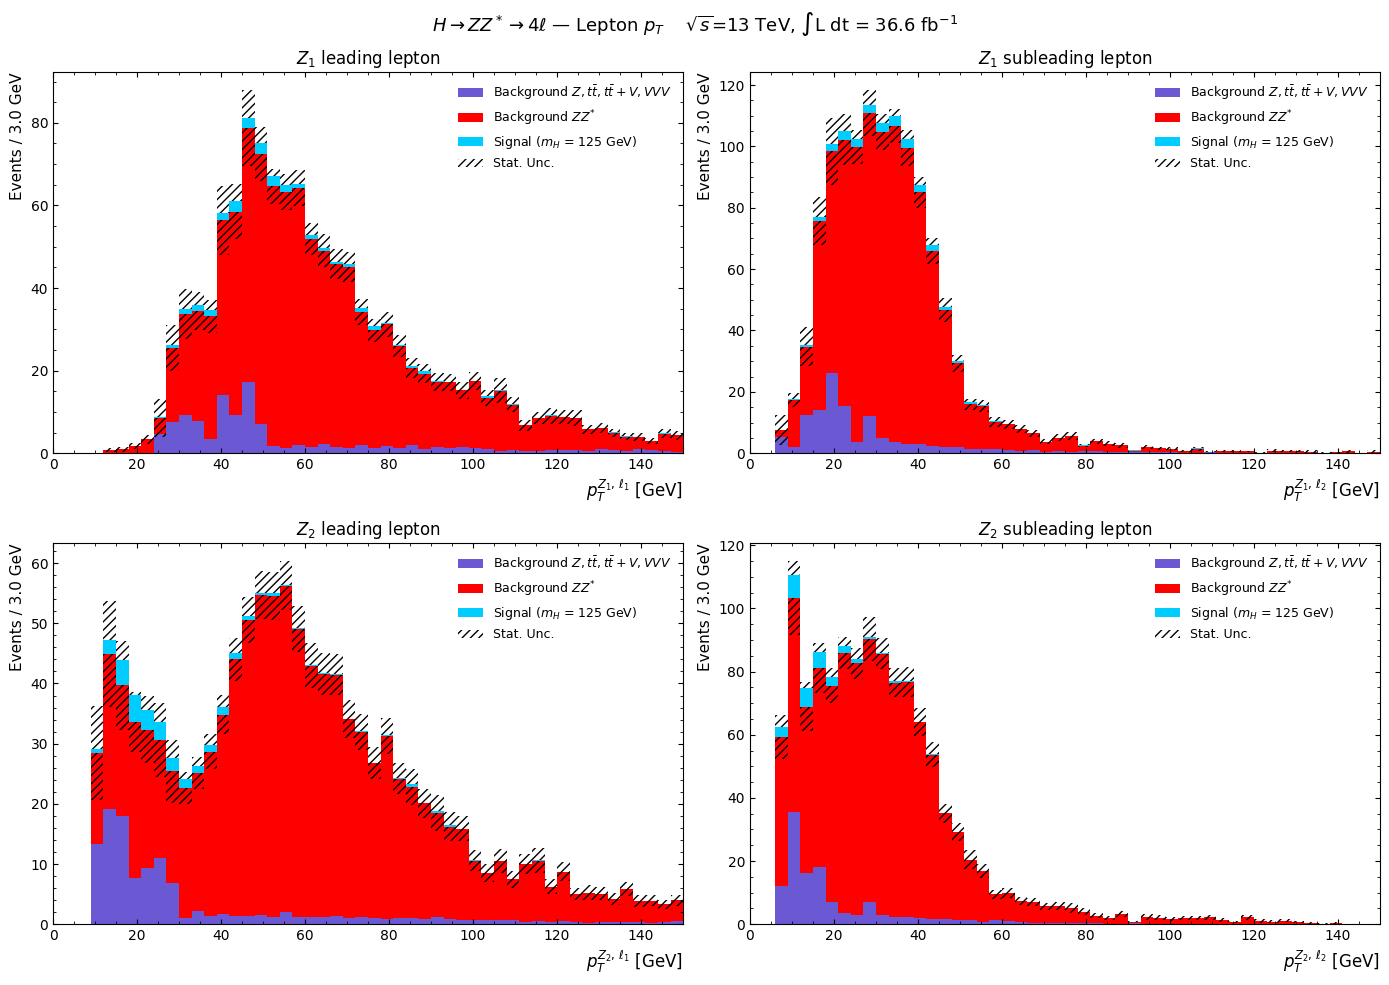

In [13]:
def plot_2x2_lepton_pt():
    panels = [
        ('pt_z1_l1', r'$Z_1$ leading lepton',    r'$p_T^{Z_1,\,\ell_1}$ [GeV]'),
        ('pt_z1_l2', r'$Z_1$ subleading lepton',  r'$p_T^{Z_1,\,\ell_2}$ [GeV]'),
        ('pt_z2_l1', r'$Z_2$ leading lepton',     r'$p_T^{Z_2,\,\ell_1}$ [GeV]'),
        ('pt_z2_l2', r'$Z_2$ subleading lepton',  r'$p_T^{Z_2,\,\ell_2}$ [GeV]'),
    ]

    sig_key = r'Signal ($m_H$ = 125 GeV)'
    xmin, xmax, step_size = 0, 150, 3.0
    bin_edges   = np.arange(xmin, xmax + step_size, step_size)
    bin_centres = bin_edges[:-1] + step_size / 2

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (feat_key, title_label, xlabel) in zip(axes, panels):

        signal_x     = z_masses[sig_key][feat_key]
        signal_w     = z_masses[sig_key]['w']
        signal_color = samples[sig_key]['color']

        mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
        for s in z_masses:
            if s == sig_key:
                continue
            mc_x.append(z_masses[s][feat_key])
            mc_w.append(z_masses[s]['w'])
            mc_colors.append(samples[s]['color'])
            mc_labels.append(s)

        mc_h   = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                         color=mc_colors, label=mc_labels)
        mc_tot = mc_h[0][-1]

        mc_err = np.sqrt(
            np.histogram(np.hstack(mc_x), bins=bin_edges,
                         weights=np.hstack(mc_w)**2)[0]
        )
        ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
               alpha=0.5, color='none', hatch='////', width=step_size,
               label='Stat. Unc.')

        ax.hist(signal_x, bins=bin_edges, weights=signal_w, bottom=mc_tot,
                color=signal_color, label=sig_key)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=0)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.set_xlabel(xlabel, fontsize=12, x=1, horizontalalignment='right')
        ax.set_ylabel(f'Events / {step_size} GeV', fontsize=11, y=1, horizontalalignment='right')
        ax.set_title(title_label, fontsize=12)
        ax.legend(frameon=False, fontsize=9)

    plt.suptitle(
        rf'$H \rightarrow ZZ^* \rightarrow 4\ell$ — Lepton $p_T$    '
        rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

plot_2x2_lepton_pt()

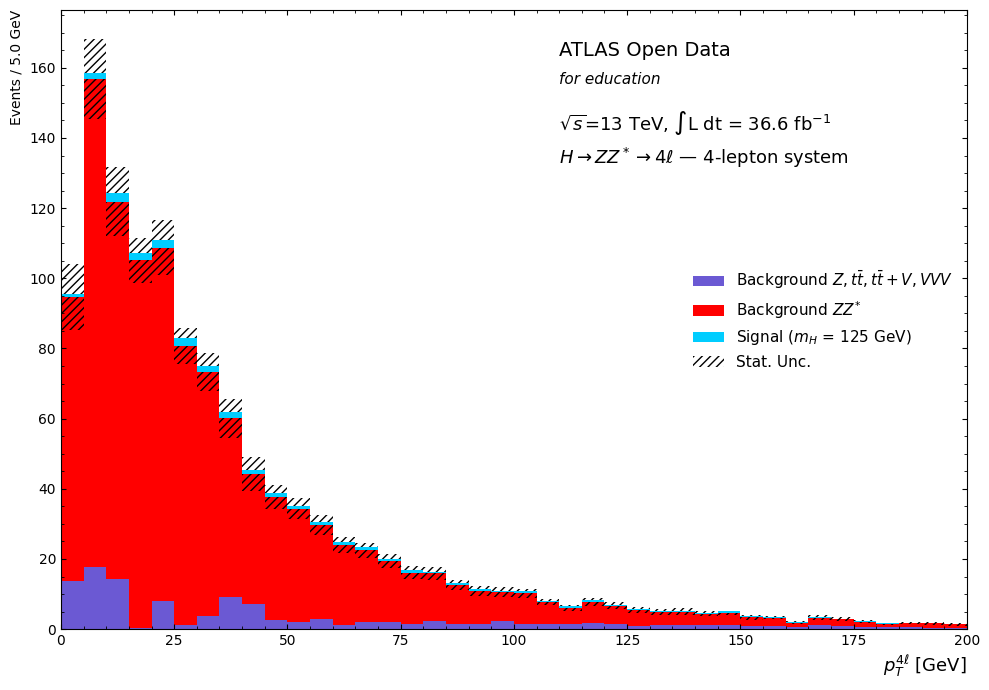

In [14]:
plot_mc_feature(
    feat_key   = 'pt4l',
    xmin       = 0,
    xmax       = 200,
    step_size  = 5.0,
    title_label= r'4-lepton system',
    xlabel     = r'$p_T^{4\ell}$ [GeV]'
)

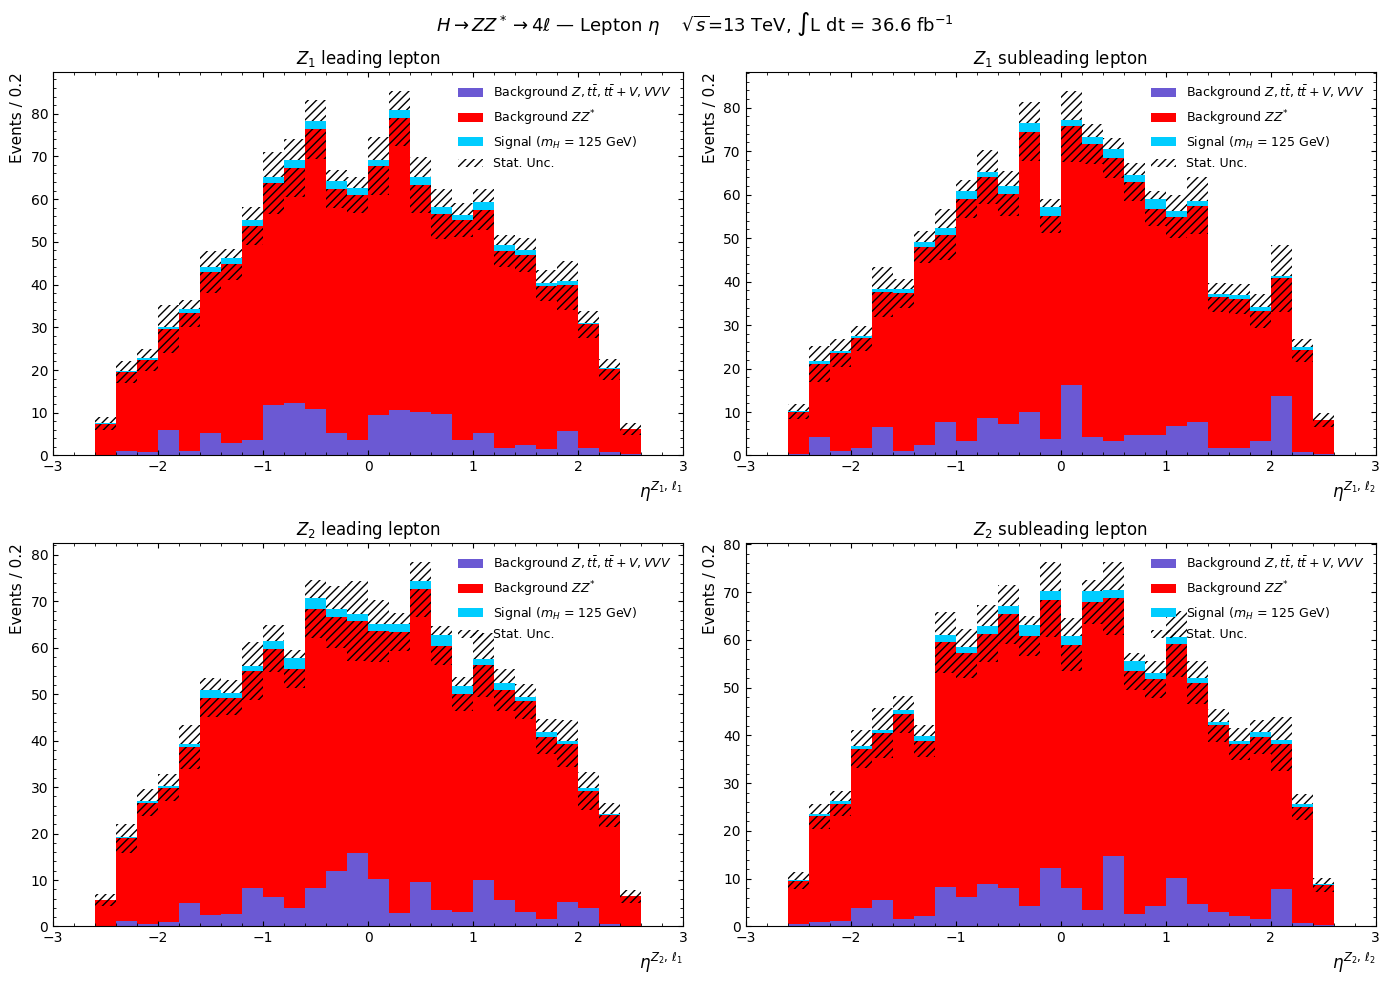

In [15]:
def plot_2x2_lepton_eta():
    panels = [
        ('eta_z1_l1', r'$Z_1$ leading lepton',   r'$\eta^{Z_1,\,\ell_1}$'),
        ('eta_z1_l2', r'$Z_1$ subleading lepton', r'$\eta^{Z_1,\,\ell_2}$'),
        ('eta_z2_l1', r'$Z_2$ leading lepton',    r'$\eta^{Z_2,\,\ell_1}$'),
        ('eta_z2_l2', r'$Z_2$ subleading lepton', r'$\eta^{Z_2,\,\ell_2}$'),
    ]

    sig_key   = r'Signal ($m_H$ = 125 GeV)'
    xmin, xmax, step_size = -3.0, 3.0, 0.2
    bin_edges   = np.arange(xmin, xmax + step_size, step_size)
    bin_centres = bin_edges[:-1] + step_size / 2

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (feat_key, title_label, xlabel) in zip(axes, panels):

        signal_x     = z_masses[sig_key][feat_key]
        signal_w     = z_masses[sig_key]['w']
        signal_color = samples[sig_key]['color']

        mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
        for s in z_masses:
            if s == sig_key:
                continue
            mc_x.append(z_masses[s][feat_key])
            mc_w.append(z_masses[s]['w'])
            mc_colors.append(samples[s]['color'])
            mc_labels.append(s)

        mc_h   = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                         color=mc_colors, label=mc_labels)
        mc_tot = mc_h[0][-1]

        mc_err = np.sqrt(
            np.histogram(np.hstack(mc_x), bins=bin_edges,
                         weights=np.hstack(mc_w)**2)[0]
        )
        ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
               alpha=0.5, color='none', hatch='////', width=step_size,
               label='Stat. Unc.')

        ax.hist(signal_x, bins=bin_edges, weights=signal_w, bottom=mc_tot,
                color=signal_color, label=sig_key)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=0)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.set_xlabel(xlabel, fontsize=12, x=1, horizontalalignment='right')
        ax.set_ylabel(f'Events / {step_size}', fontsize=11, y=1, horizontalalignment='right')
        ax.set_title(title_label, fontsize=12)
        ax.legend(frameon=False, fontsize=9)

    plt.suptitle(
        rf'$H \rightarrow ZZ^* \rightarrow 4\ell$ — Lepton $\eta$    '
        rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

plot_2x2_lepton_eta()

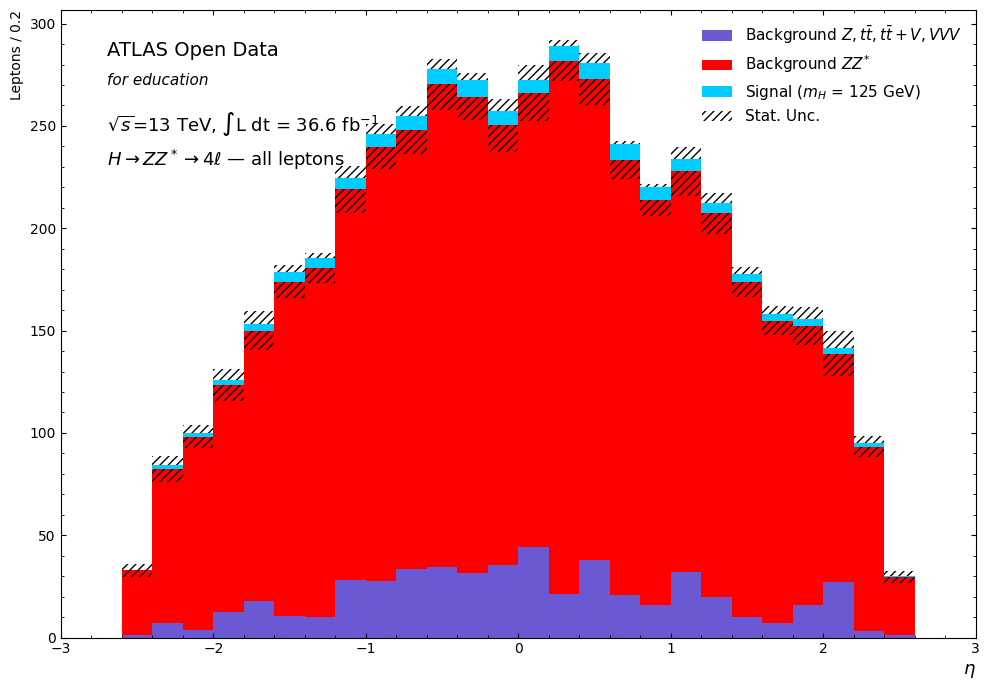

In [16]:
def plot_all_lepton_eta():
    sig_key   = r'Signal ($m_H$ = 125 GeV)'
    xmin, xmax, step_size = -3.0, 3.0, 0.2
    bin_edges   = np.arange(xmin, xmax + step_size, step_size)
    bin_centres = bin_edges[:-1] + step_size / 2

    signal_x     = np.concatenate([z_masses[sig_key][f'eta_z{z}_l{l}'] for z in [1,2] for l in [1,2]])
    signal_w     = np.tile(z_masses[sig_key]['w'], 4)
    signal_color = samples[sig_key]['color']

    mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
    for s in z_masses:
        if s == sig_key:
            continue
        mc_x.append(np.concatenate([z_masses[s][f'eta_z{z}_l{l}'] for z in [1,2] for l in [1,2]]))
        mc_w.append(np.tile(z_masses[s]['w'], 4))
        mc_colors.append(samples[s]['color'])
        mc_labels.append(s)

    fig, ax = plt.subplots(figsize=(10, 7))

    mc_h   = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
    mc_tot = mc_h[0][-1]

    mc_err = np.sqrt(
        np.histogram(np.hstack(mc_x), bins=bin_edges,
                     weights=np.hstack(mc_w)**2)[0]
    )
    ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
           alpha=0.5, color='none', hatch='////', width=step_size,
           label='Stat. Unc.')

    ax.hist(signal_x, bins=bin_edges, weights=signal_w, bottom=mc_tot,
            color=signal_color, label=sig_key)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.set_xlabel(r'$\eta$', fontsize=13, x=1, horizontalalignment='right')
    ax.set_ylabel(f'Leptons / {step_size}', y=1, horizontalalignment='right')

    ax.text(0.05, 0.95, 'ATLAS Open Data', transform=ax.transAxes, fontsize=14, va='top')
    ax.text(0.05, 0.90, 'for education',   transform=ax.transAxes, fontsize=11,
            style='italic', va='top')
    ax.text(0.05, 0.84,
            rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
            transform=ax.transAxes, fontsize=13, va='top')
    ax.text(0.05, 0.78, r'$H \rightarrow ZZ^* \rightarrow 4\ell$ — all leptons',
            transform=ax.transAxes, fontsize=13, va='top')

    ax.legend(frameon=False, fontsize=11)
    plt.tight_layout()
    plt.show()

plot_all_lepton_eta()

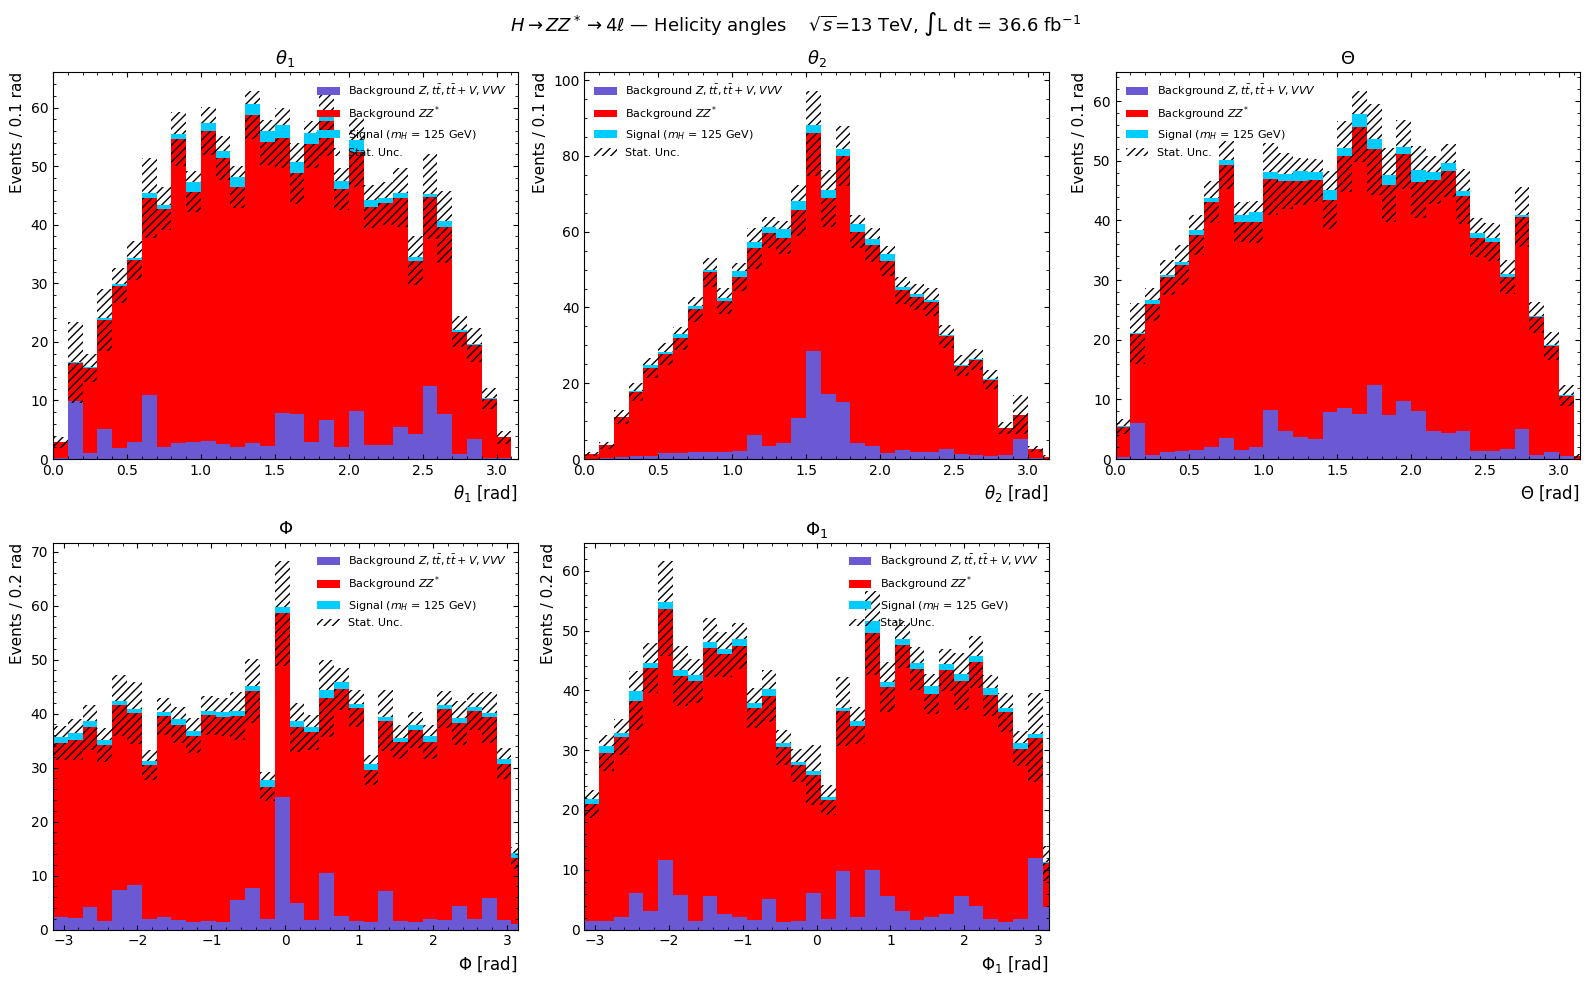

In [17]:
def plot_helicity_angles():
    panels = [
        ('theta1', r'$\theta_1$',  r'$\theta_1$ [rad]',  0, np.pi,  0.1),
        ('theta2', r'$\theta_2$',  r'$\theta_2$ [rad]',  0, np.pi,  0.1),
        ('Theta',  r'$\Theta$',    r'$\Theta$ [rad]',    0, np.pi,  0.1),
        ('Phi',    r'$\Phi$',      r'$\Phi$ [rad]',     -np.pi, np.pi, 0.2),
        ('Phi1',   r'$\Phi_1$',    r'$\Phi_1$ [rad]',   -np.pi, np.pi, 0.2),
    ]

    sig_key = r'Signal ($m_H$ = 125 GeV)'
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (feat_key, title_label, xlabel, xmin, xmax, step_size) in zip(axes, panels):
        bin_edges   = np.arange(xmin, xmax + step_size, step_size)
        bin_centres = bin_edges[:-1] + step_size / 2

        signal_x     = z_masses[sig_key][feat_key]
        signal_w     = z_masses[sig_key]['w']
        signal_color = samples[sig_key]['color']

        mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
        for s in z_masses:
            if s == sig_key:
                continue
            mc_x.append(z_masses[s][feat_key])
            mc_w.append(z_masses[s]['w'])
            mc_colors.append(samples[s]['color'])
            mc_labels.append(s)

        mc_h   = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                         color=mc_colors, label=mc_labels)
        mc_tot = mc_h[0][-1]

        mc_err = np.sqrt(
            np.histogram(np.hstack(mc_x), bins=bin_edges,
                         weights=np.hstack(mc_w)**2)[0]
        )
        ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
               alpha=0.5, color='none', hatch='////', width=step_size,
               label='Stat. Unc.')

        ax.hist(signal_x, bins=bin_edges, weights=signal_w, bottom=mc_tot,
                color=signal_color, label=sig_key)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=0)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.set_xlabel(xlabel, fontsize=12, x=1, horizontalalignment='right')
        ax.set_ylabel(f'Events / {round(step_size,2)} rad', fontsize=11,
                      y=1, horizontalalignment='right')
        ax.set_title(title_label, fontsize=13)
        ax.legend(frameon=False, fontsize=8)

    axes[-1].set_visible(False)   # hide the 6th empty panel

    plt.suptitle(
        rf'$H \rightarrow ZZ^* \rightarrow 4\ell$ — Helicity angles    '
        rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

plot_helicity_angles()

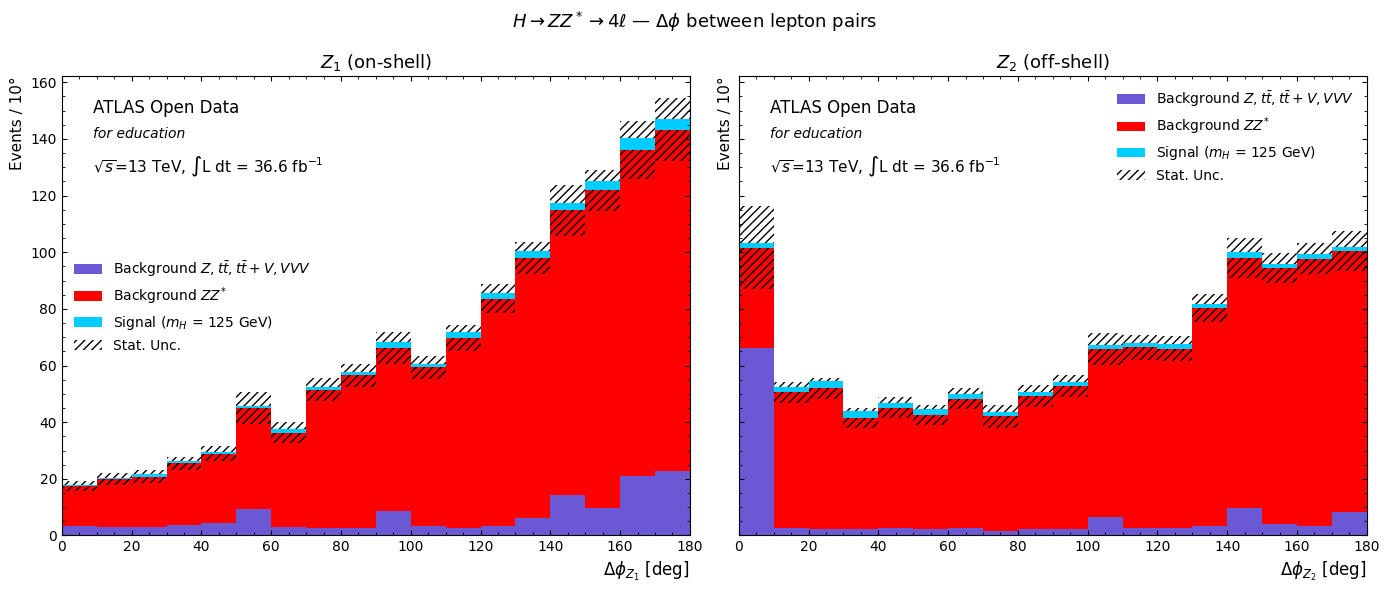

In [18]:
def plot_dphi_z1_z2():
    sig_key   = r'Signal ($m_H$ = 125 GeV)'
    xmin, xmax, step_size = 0, 180, 10
    bin_edges   = np.arange(xmin, xmax + step_size, step_size)
    bin_centres = bin_edges[:-1] + step_size / 2

    panels = [
        ('dphi_z1', r'$Z_1$ (on-shell)',  r'$\Delta\phi_{Z_1}$ [deg]'),
        ('dphi_z2', r'$Z_2$ (off-shell)', r'$\Delta\phi_{Z_2}$ [deg]'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    for ax, (feat_key, title_label, xlabel) in zip(axes, panels):

        signal_x     = np.degrees(z_masses[sig_key][feat_key])
        signal_w     = z_masses[sig_key]['w']
        signal_color = samples[sig_key]['color']

        mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
        for s in z_masses:
            if s == sig_key:
                continue
            mc_x.append(np.degrees(z_masses[s][feat_key]))
            mc_w.append(z_masses[s]['w'])
            mc_colors.append(samples[s]['color'])
            mc_labels.append(s)

        mc_h   = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                         color=mc_colors, label=mc_labels)
        mc_tot = mc_h[0][-1]

        mc_err = np.sqrt(
            np.histogram(np.hstack(mc_x), bins=bin_edges,
                         weights=np.hstack(mc_w)**2)[0]
        )
        ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
               alpha=0.5, color='none', hatch='////', width=step_size,
               label='Stat. Unc.')

        ax.hist(signal_x, bins=bin_edges, weights=signal_w, bottom=mc_tot,
                color=signal_color, label=sig_key)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=0)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.set_xlabel(xlabel, fontsize=12, x=1, horizontalalignment='right')
        ax.set_ylabel(f'Events / {step_size}°', fontsize=11,
                      y=1, horizontalalignment='right')
        ax.set_title(title_label, fontsize=13)
        ax.legend(frameon=False, fontsize=10)

        ax.text(0.05, 0.95, 'ATLAS Open Data', transform=ax.transAxes,
                fontsize=12, va='top')
        ax.text(0.05, 0.89, 'for education',   transform=ax.transAxes,
                fontsize=10, style='italic', va='top')
        ax.text(0.05, 0.83,
                rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
                transform=ax.transAxes, fontsize=11, va='top')

    plt.suptitle(
        rf'$H \rightarrow ZZ^* \rightarrow 4\ell$ — $\Delta\phi$ between lepton pairs',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

plot_dphi_z1_z2()

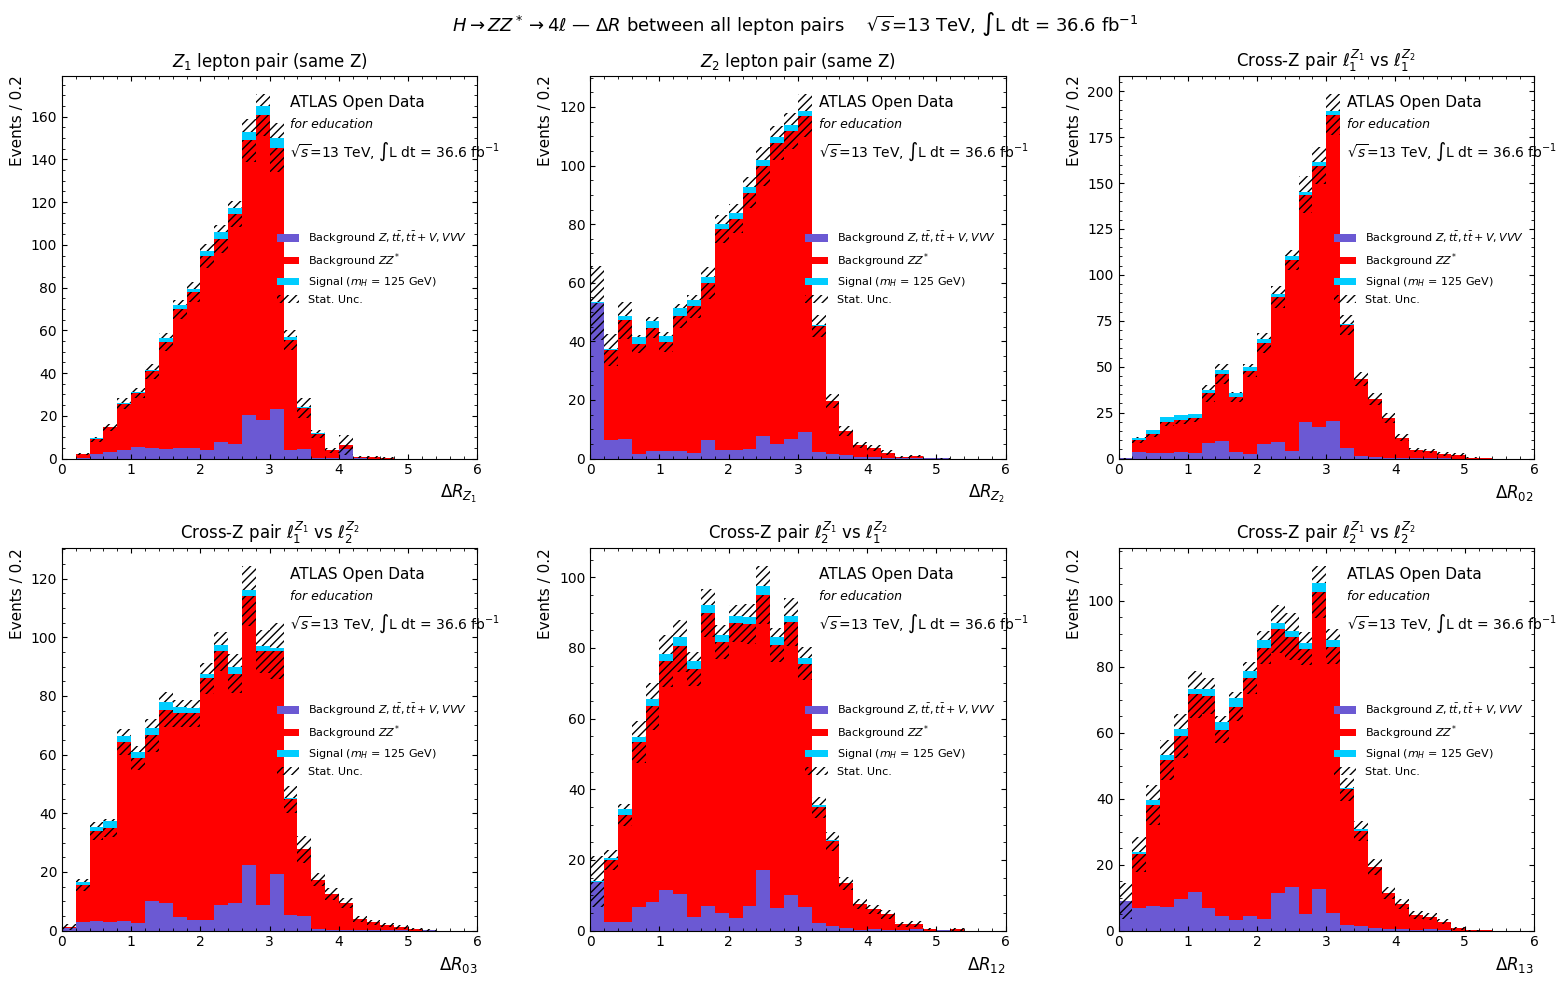

In [19]:
def plot_delta_r():
    sig_key   = r'Signal ($m_H$ = 125 GeV)'
    xmin, xmax, step_size = 0, 6, 0.2
    bin_edges   = np.arange(xmin, xmax + step_size, step_size)
    bin_centres = bin_edges[:-1] + step_size / 2

    panels = [
        ('dR_z1',  r'$Z_1$ lepton pair (same Z)',   r'$\Delta R_{Z_1}$'),
        ('dR_z2',  r'$Z_2$ lepton pair (same Z)',   r'$\Delta R_{Z_2}$'),
        ('dR_02',  r'Cross-Z pair $\ell_1^{Z_1}$ vs $\ell_1^{Z_2}$', r'$\Delta R_{02}$'),
        ('dR_03',  r'Cross-Z pair $\ell_1^{Z_1}$ vs $\ell_2^{Z_2}$', r'$\Delta R_{03}$'),
        ('dR_12',  r'Cross-Z pair $\ell_2^{Z_1}$ vs $\ell_1^{Z_2}$', r'$\Delta R_{12}$'),
        ('dR_13',  r'Cross-Z pair $\ell_2^{Z_1}$ vs $\ell_2^{Z_2}$', r'$\Delta R_{13}$'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (feat_key, title_label, xlabel) in zip(axes, panels):

        signal_x     = z_masses[sig_key][feat_key]
        signal_w     = z_masses[sig_key]['w']
        signal_color = samples[sig_key]['color']

        mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
        for s in z_masses:
            if s == sig_key:
                continue
            mc_x.append(z_masses[s][feat_key])
            mc_w.append(z_masses[s]['w'])
            mc_colors.append(samples[s]['color'])
            mc_labels.append(s)

        mc_h   = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                         color=mc_colors, label=mc_labels)
        mc_tot = mc_h[0][-1]

        mc_err = np.sqrt(
            np.histogram(np.hstack(mc_x), bins=bin_edges,
                         weights=np.hstack(mc_w)**2)[0]
        )
        ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
               alpha=0.5, color='none', hatch='////', width=step_size,
               label='Stat. Unc.')

        ax.hist(signal_x, bins=bin_edges, weights=signal_w, bottom=mc_tot,
                color=signal_color, label=sig_key)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=0)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.set_xlabel(xlabel, fontsize=12, x=1, horizontalalignment='right')
        ax.set_ylabel(f'Events / {step_size}', fontsize=11,
                      y=1, horizontalalignment='right')
        ax.set_title(title_label, fontsize=12)
        ax.legend(frameon=False, fontsize=8)

        ax.text(0.55, 0.95, 'ATLAS Open Data', transform=ax.transAxes, fontsize=11, va='top')
        ax.text(0.55, 0.89, 'for education',   transform=ax.transAxes, fontsize=9,
                style='italic', va='top')
        ax.text(0.55, 0.83,
                rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
                transform=ax.transAxes, fontsize=10, va='top')

    plt.suptitle(
        rf'$H \rightarrow ZZ^* \rightarrow 4\ell$ — $\Delta R$ between all lepton pairs    '
        rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

plot_delta_r()

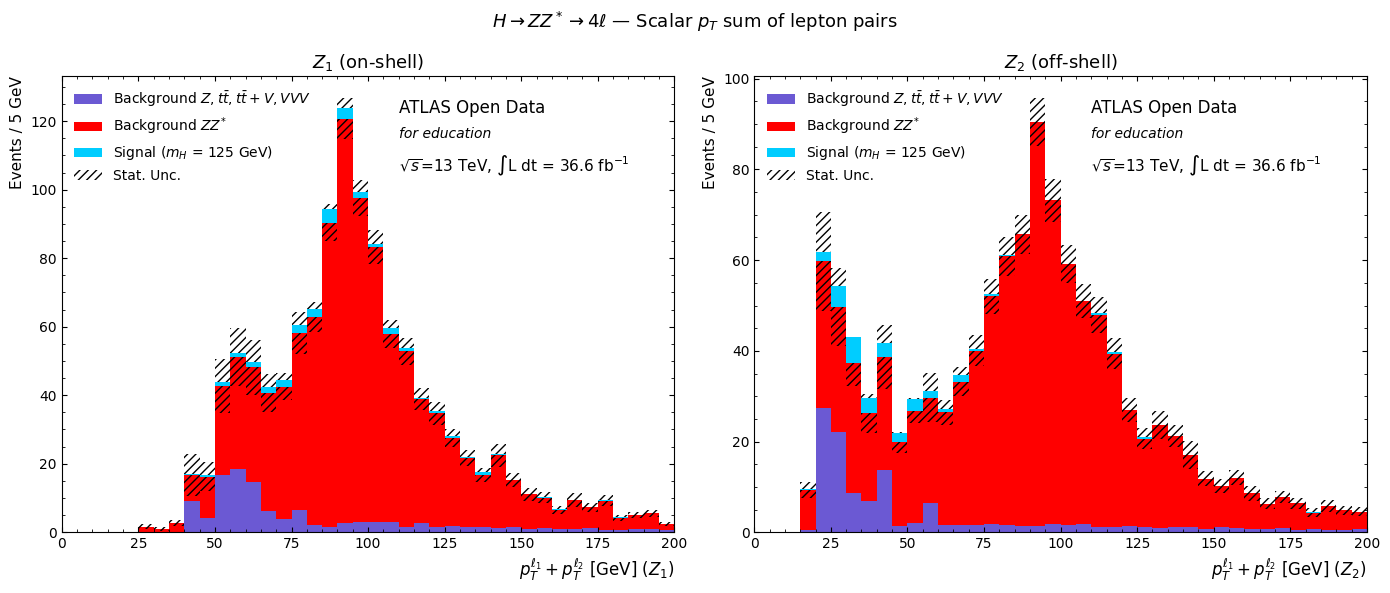

In [20]:
def plot_pt_sum_z1_z2():
    sig_key   = r'Signal ($m_H$ = 125 GeV)'
    xmin, xmax, step_size = 0, 200, 5
    bin_edges   = np.arange(xmin, xmax + step_size, step_size)
    bin_centres = bin_edges[:-1] + step_size / 2

    panels = [
        ('scalar_pt_sum_z1', r'$Z_1$ (on-shell)',  r'$p_T^{\ell_1} + p_T^{\ell_2}$ [GeV] $(Z_1)$'),
        ('scalar_pt_sum_z2', r'$Z_2$ (off-shell)', r'$p_T^{\ell_1} + p_T^{\ell_2}$ [GeV] $(Z_2)$'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

    for ax, (feat_key, title_label, xlabel) in zip(axes, panels):

        signal_x     = z_masses[sig_key][feat_key]
        signal_w     = z_masses[sig_key]['w']
        signal_color = samples[sig_key]['color']

        mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
        for s in z_masses:
            if s == sig_key:
                continue
            mc_x.append(z_masses[s][feat_key])
            mc_w.append(z_masses[s]['w'])
            mc_colors.append(samples[s]['color'])
            mc_labels.append(s)

        mc_h   = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                         color=mc_colors, label=mc_labels)
        mc_tot = mc_h[0][-1]

        mc_err = np.sqrt(
            np.histogram(np.hstack(mc_x), bins=bin_edges,
                         weights=np.hstack(mc_w)**2)[0]
        )
        ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
               alpha=0.5, color='none', hatch='////', width=step_size,
               label='Stat. Unc.')

        ax.hist(signal_x, bins=bin_edges, weights=signal_w, bottom=mc_tot,
                color=signal_color, label=sig_key)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=0)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.set_xlabel(xlabel, fontsize=12, x=1, horizontalalignment='right')
        ax.set_ylabel(f'Events / {step_size} GeV', fontsize=11,
                      y=1, horizontalalignment='right')
        ax.set_title(title_label, fontsize=13)
        ax.legend(frameon=False, fontsize=10)

        ax.text(0.55, 0.95, 'ATLAS Open Data', transform=ax.transAxes, fontsize=12, va='top')
        ax.text(0.55, 0.89, 'for education',   transform=ax.transAxes, fontsize=10,
                style='italic', va='top')
        ax.text(0.55, 0.83,
                rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
                transform=ax.transAxes, fontsize=11, va='top')

    plt.suptitle(
        rf'$H \rightarrow ZZ^* \rightarrow 4\ell$ — Scalar $p_T$ sum of lepton pairs',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

plot_pt_sum_z1_z2()

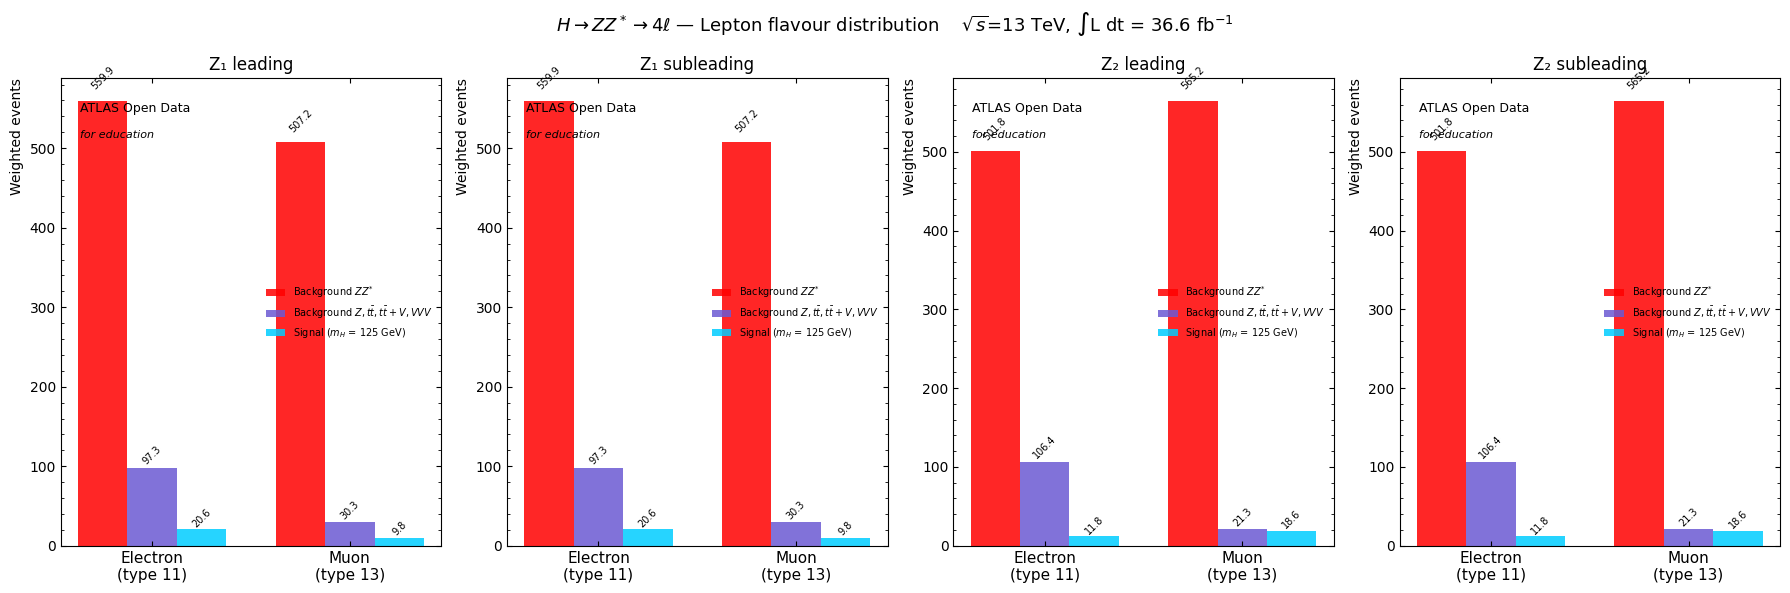

In [21]:
def plot_lepton_flavour():
    sig_key = r'Signal ($m_H$ = 125 GeV)'

    # lepton type: 11 = electron, 13 = muon
    lepton_labels = ['Z₁ leading', 'Z₁ subleading', 'Z₂ leading', 'Z₂ subleading']
    type_keys     = ['type_z1_l1', 'type_z1_l2', 'type_z2_l1', 'type_z2_l2']

    sample_groups = {
        r'Background $ZZ^{*}$':                      samples[r'Background $ZZ^{*}$']['color'],
        r'Background $Z,t\bar{t},t\bar{t}+V,VVV$':  samples[r'Background $Z,t\bar{t},t\bar{t}+V,VVV$']['color'],
        sig_key:                                      samples[sig_key]['color'],
    }

    fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)

    for ax, (lep_label, type_key) in zip(axes, zip(lepton_labels, type_keys)):

        x      = np.arange(2)           # 0 = electron, 1 = muon
        width  = 0.25
        offset = -width

        for s, color in sample_groups.items():
            types   = z_masses[s][type_key]
            weights = z_masses[s]['w']

            n_ele = weights[types == 11].sum()
            n_mu  = weights[types == 13].sum()
            counts = np.array([n_ele, n_mu])

            bars = ax.bar(x + offset, counts, width=width, color=color,
                          label=s, alpha=0.85)
            # value labels on top of each bar
            for bar, val in zip(bars, counts):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width()/2,
                            bar.get_height() * 1.02,
                            f'{val:.1f}',
                            ha='center', va='bottom', fontsize=7, rotation=45)
            offset += width

        ax.set_xticks(x)
        ax.set_xticklabels(['Electron\n(type 11)', 'Muon\n(type 13)'], fontsize=11)
        ax.set_title(lep_label, fontsize=12)
        ax.set_ylabel('Weighted events', fontsize=10, y=1, horizontalalignment='right')
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.legend(frameon=False, fontsize=7)

        ax.text(0.05, 0.95, 'ATLAS Open Data', transform=ax.transAxes,
                fontsize=9, va='top')
        ax.text(0.05, 0.89, 'for education',   transform=ax.transAxes,
                fontsize=8, style='italic', va='top')

    plt.suptitle(
        rf'$H \rightarrow ZZ^* \rightarrow 4\ell$ — Lepton flavour distribution    '
        rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

plot_lepton_flavour()

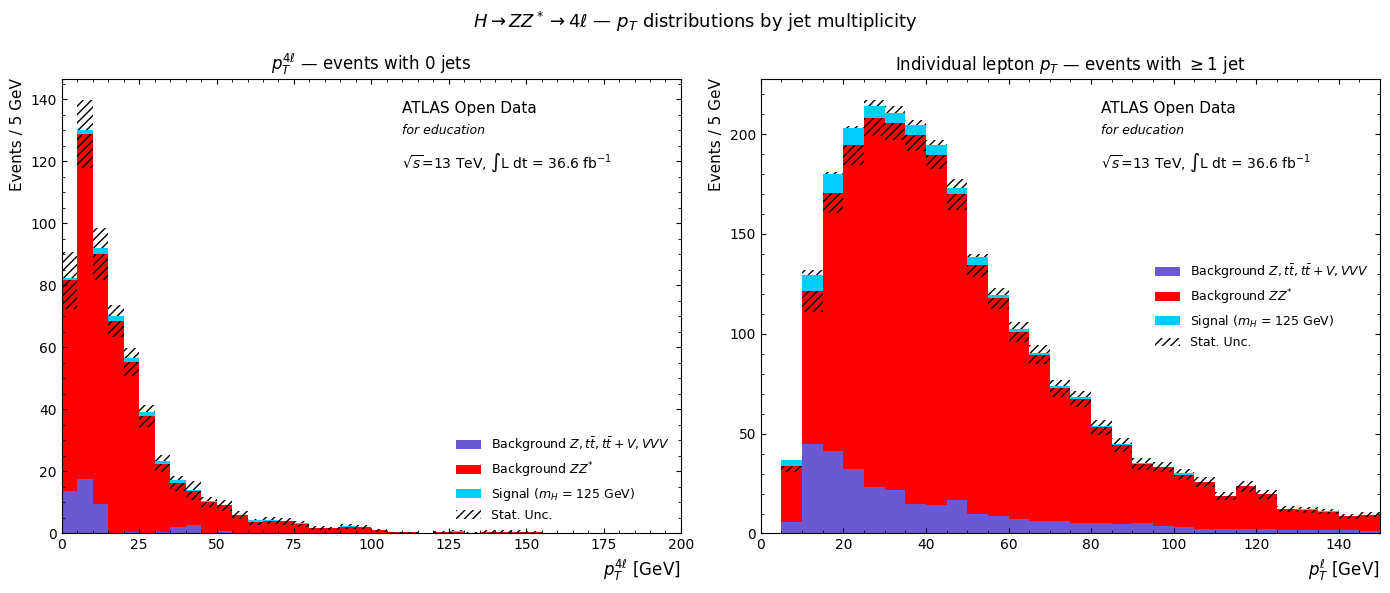

In [22]:
def plot_pt_jet_categories():
    sig_key   = r'Signal ($m_H$ = 125 GeV)'

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    panels = [
        # (feat_key, jet_condition, xmin, xmax, step, title, xlabel)
        ('pt4l',     'zero jets',    0, 200, 5,
         r'4-lepton $p_T$ — 0 jets',
         r'$p_T^{4\ell}$ [GeV]'),
        ('pt_z1_l1', 'nonzero jets', 0, 150, 3,
         r'Leading lepton $p_T$ — $\geq$1 jet',
         r'$p_T^{\ell_1}$ [GeV]'),
    ]

    # We'll do all 4 individual leptons for the second panel so override panels
    panels = [
        ('pt4l', 0, 200, 5,
         r'$p_T^{4\ell}$ — events with 0 jets',
         r'$p_T^{4\ell}$ [GeV]',
         lambda s: z_masses[s]['jet_n'] == 0),

        ('pt_all_leps', 0, 150, 5,
         r'Individual lepton $p_T$ — events with $\geq$1 jet',
         r'$p_T^{\ell}$ [GeV]',
         lambda s: z_masses[s]['jet_n'] > 0),
    ]

    for ax, (feat_key, xmin, xmax, step_size, title, xlabel, mask_fn) in zip(axes, panels):
        bin_edges   = np.arange(xmin, xmax + step_size, step_size)
        bin_centres = bin_edges[:-1] + step_size / 2

        mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
        for s in z_masses:
            if s == sig_key:
                continue
            mask = mask_fn(s)
            if feat_key == 'pt_all_leps':
                # concatenate all 4 lepton pTs, repeat weights 4 times
                pts = np.concatenate([
                    z_masses[s]['pt_z1_l1'][mask],
                    z_masses[s]['pt_z1_l2'][mask],
                    z_masses[s]['pt_z2_l1'][mask],
                    z_masses[s]['pt_z2_l2'][mask],
                ])
                wts = np.tile(z_masses[s]['w'][mask], 4)
            else:
                pts = z_masses[s][feat_key][mask]
                wts = z_masses[s]['w'][mask]
            mc_x.append(pts)
            mc_w.append(wts)
            mc_colors.append(samples[s]['color'])
            mc_labels.append(s)

        # signal
        mask_sig = mask_fn(sig_key)
        if feat_key == 'pt_all_leps':
            signal_x = np.concatenate([
                z_masses[sig_key]['pt_z1_l1'][mask_sig],
                z_masses[sig_key]['pt_z1_l2'][mask_sig],
                z_masses[sig_key]['pt_z2_l1'][mask_sig],
                z_masses[sig_key]['pt_z2_l2'][mask_sig],
            ])
            signal_w = np.tile(z_masses[sig_key]['w'][mask_sig], 4)
        else:
            signal_x = z_masses[sig_key][feat_key][mask_sig]
            signal_w = z_masses[sig_key]['w'][mask_sig]
        signal_color = samples[sig_key]['color']

        mc_h   = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                         color=mc_colors, label=mc_labels)
        mc_tot = mc_h[0][-1]

        mc_err = np.sqrt(
            np.histogram(np.hstack(mc_x), bins=bin_edges,
                         weights=np.hstack(mc_w)**2)[0]
        )
        ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
               alpha=0.5, color='none', hatch='////', width=step_size,
               label='Stat. Unc.')

        ax.hist(signal_x, bins=bin_edges, weights=signal_w, bottom=mc_tot,
                color=signal_color, label=sig_key)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=0)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.set_xlabel(xlabel, fontsize=12, x=1, horizontalalignment='right')
        ax.set_ylabel(f'Events / {step_size} GeV', fontsize=11,
                      y=1, horizontalalignment='right')
        ax.set_title(title, fontsize=12)
        ax.legend(frameon=False, fontsize=9)

        ax.text(0.55, 0.95, 'ATLAS Open Data', transform=ax.transAxes,
                fontsize=11, va='top')
        ax.text(0.55, 0.90, 'for education',   transform=ax.transAxes,
                fontsize=9,  style='italic', va='top')
        ax.text(0.55, 0.84,
                rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
                transform=ax.transAxes, fontsize=10, va='top')

    plt.suptitle(
        rf'$H \rightarrow ZZ^* \rightarrow 4\ell$ — $p_T$ distributions by jet multiplicity',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

plot_pt_jet_categories()

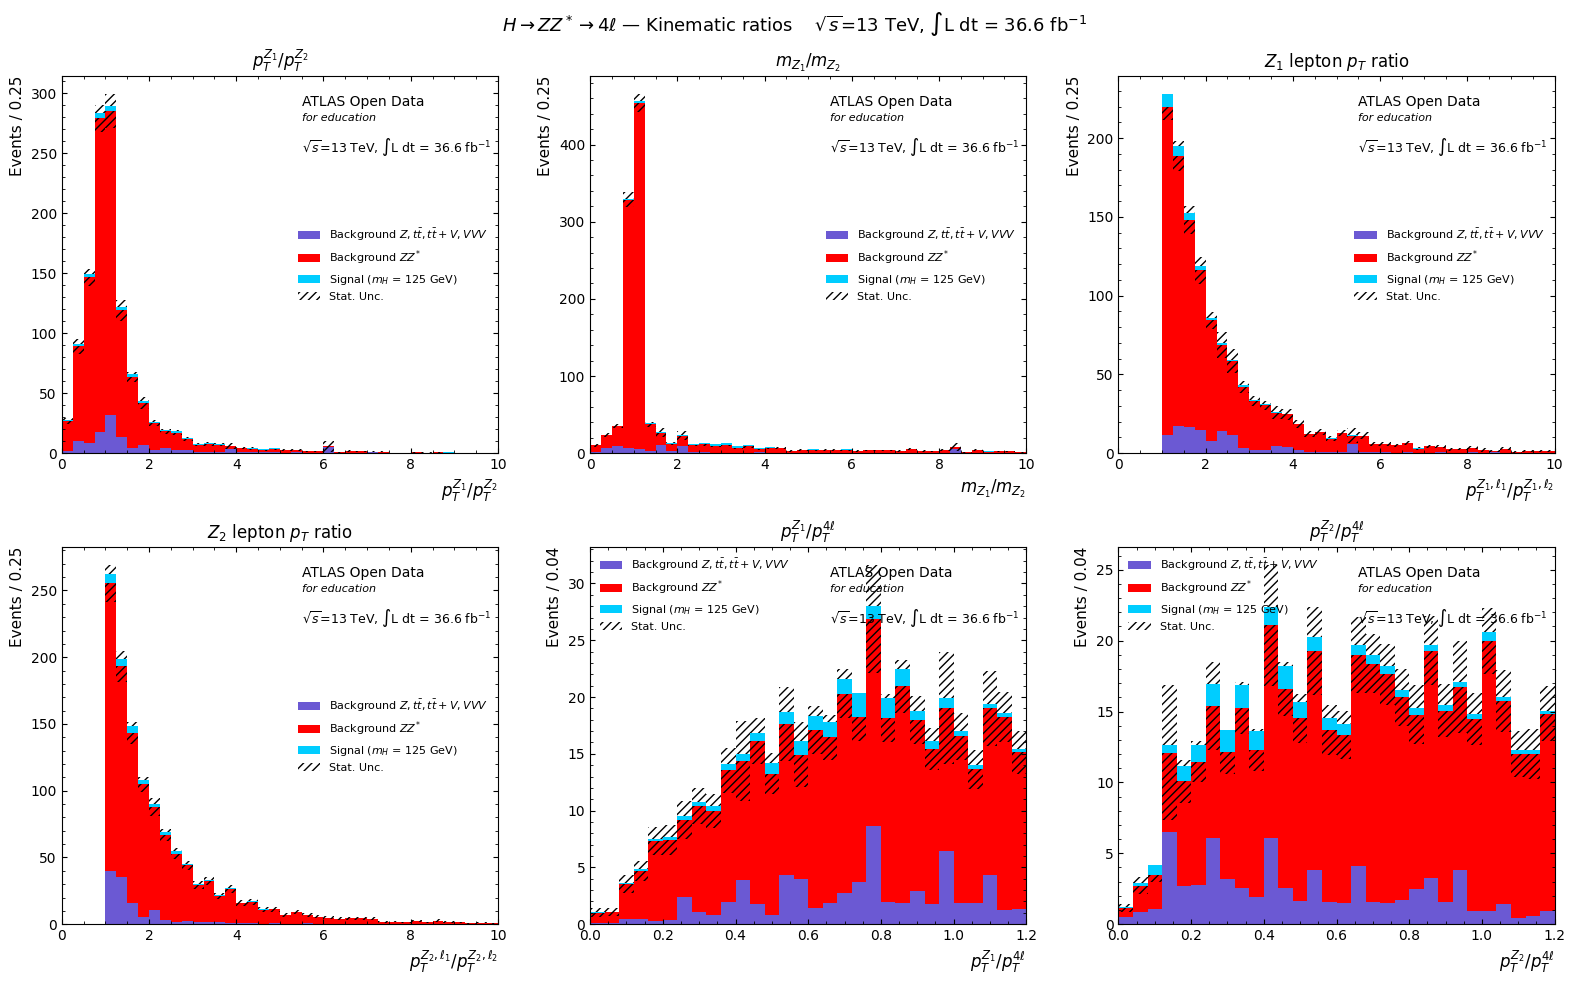

In [23]:
def plot_kinematic_ratios():
    sig_key   = r'Signal ($m_H$ = 125 GeV)'

    panels = [
        # (numerator, denominator, xmin, xmax, step, title, xlabel)
        ('ptz1',  'ptz2',  0,   10,  0.25,
         r'$p_T^{Z_1} / p_T^{Z_2}$',
         r'$p_T^{Z_1} / p_T^{Z_2}$'),

        ('mz1',   'mz2',  0,   10,  0.25,
         r'$m_{Z_1} / m_{Z_2}$',
         r'$m_{Z_1} / m_{Z_2}$'),

        ('pt_z1_l1', 'pt_z1_l2', 0, 10, 0.25,
         r'$Z_1$ lepton $p_T$ ratio',
         r'$p_T^{Z_1,\ell_1} / p_T^{Z_1,\ell_2}$'),

        ('pt_z2_l1', 'pt_z2_l2', 0, 10, 0.25,
         r'$Z_2$ lepton $p_T$ ratio',
         r'$p_T^{Z_2,\ell_1} / p_T^{Z_2,\ell_2}$'),

        ('ptz1',  'pt4l',  0,  1.2, 0.04,
         r'$p_T^{Z_1} / p_T^{4\ell}$',
         r'$p_T^{Z_1} / p_T^{4\ell}$'),

        ('ptz2',  'pt4l',  0,  1.2, 0.04,
         r'$p_T^{Z_2} / p_T^{4\ell}$',
         r'$p_T^{Z_2} / p_T^{4\ell}$'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (num_key, den_key, xmin, xmax, step_size, title, xlabel) in zip(axes, panels):
        bin_edges   = np.arange(xmin, xmax + step_size, step_size)
        bin_centres = bin_edges[:-1] + step_size / 2

        mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
        for s in z_masses:
            if s == sig_key:
                continue

            num = z_masses[s][num_key]
            den = z_masses[s][den_key]
            # avoid division by zero
            valid = den > 0
            ratio   = np.where(valid, num / np.where(valid, den, 1), np.nan)
            weights = z_masses[s]['w']
            # drop nans and out-of-range
            keep = valid & (ratio >= xmin) & (ratio <= xmax)

            mc_x.append(ratio[keep])
            mc_w.append(weights[keep])
            mc_colors.append(samples[s]['color'])
            mc_labels.append(s)

        # signal
        num_s = z_masses[sig_key][num_key]
        den_s = z_masses[sig_key][den_key]
        valid_s = den_s > 0
        ratio_s  = np.where(valid_s, num_s / np.where(valid_s, den_s, 1), np.nan)
        weights_s = z_masses[sig_key]['w']
        keep_s = valid_s & (ratio_s >= xmin) & (ratio_s <= xmax)

        signal_x     = ratio_s[keep_s]
        signal_w     = weights_s[keep_s]
        signal_color = samples[sig_key]['color']

        mc_h   = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                         color=mc_colors, label=mc_labels)
        mc_tot = mc_h[0][-1]

        mc_err = np.sqrt(
            np.histogram(np.hstack(mc_x), bins=bin_edges,
                         weights=np.hstack(mc_w)**2)[0]
        )
        ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
               alpha=0.5, color='none', hatch='////', width=step_size,
               label='Stat. Unc.')

        ax.hist(signal_x, bins=bin_edges, weights=signal_w, bottom=mc_tot,
                color=signal_color, label=sig_key)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=0)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.set_xlabel(xlabel, fontsize=12, x=1, horizontalalignment='right')
        ax.set_ylabel(f'Events / {step_size:.2f}', fontsize=11,
                      y=1, horizontalalignment='right')
        ax.set_title(title, fontsize=12)
        ax.legend(frameon=False, fontsize=8)

        ax.text(0.55, 0.95, 'ATLAS Open Data', transform=ax.transAxes,
                fontsize=10, va='top')
        ax.text(0.55, 0.90, 'for education',   transform=ax.transAxes,
                fontsize=8,  style='italic', va='top')
        ax.text(0.55, 0.84,
                rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
                transform=ax.transAxes, fontsize=9, va='top')

    plt.suptitle(
        rf'$H \rightarrow ZZ^* \rightarrow 4\ell$ — Kinematic ratios    '
        rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

plot_kinematic_ratios()

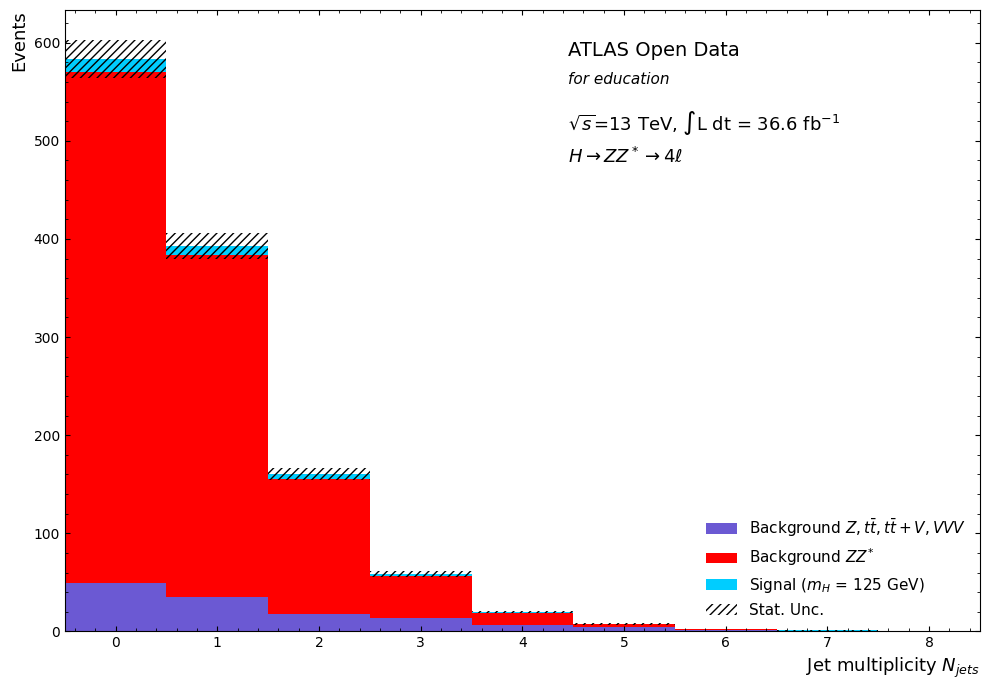

In [24]:
def plot_jet_multiplicity():
    sig_key = r'Signal ($m_H$ = 125 GeV)'

    # Binning
    max_jets = 8
    bin_edges   = np.arange(-0.5, max_jets + 1.5, 1.0)
    bin_centres = np.arange(0, max_jets + 1, 1)

    # --- Signal ---
    signal_x     = ak.to_numpy(all_data[sig_key]['jet_n'])
    signal_w     = ak.to_numpy(all_data[sig_key]['totalWeight'])
    signal_color = samples[sig_key]['color']

    # --- Backgrounds ---
    mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
    for s in samples:
        if s in ['Data', sig_key]:
            continue
        mc_x.append(ak.to_numpy(all_data[s]['jet_n']))
        mc_w.append(ak.to_numpy(all_data[s]['totalWeight']))
        mc_colors.append(samples[s]['color'])
        mc_labels.append(s)

    # --- Combine for FULL STACK ---
    all_x = mc_x + [signal_x]
    all_w = mc_w + [signal_w]
    all_colors = mc_colors + [signal_color]
    all_labels = mc_labels + [sig_key]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 7))

    mc_h = ax.hist(all_x, bins=bin_edges, weights=all_w,
                   stacked=True, color=all_colors, label=all_labels)

    mc_tot = mc_h[0][-1]

    mc_err = np.sqrt(
        np.histogram(np.hstack(all_x), bins=bin_edges,
                     weights=np.hstack(all_w)**2)[0]
    )

    ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
           alpha=0.5, color='none', hatch='////', width=1.0,
           label='Stat. Unc.')

    # --- Styling ---
    ax.set_xlim(-0.5, max_jets + 0.5)
    ax.set_ylim(bottom=0)
    ax.set_xticks(bin_centres)

    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)

    ax.set_xlabel('Jet multiplicity $N_{jets}$', fontsize=13,
                  x=1, horizontalalignment='right')
    ax.set_ylabel('Events', fontsize=13,
                  y=1, horizontalalignment='right')

    # --- ATLAS-style labels ---
    ax.text(0.55, 0.95, 'ATLAS Open Data', transform=ax.transAxes,
            fontsize=14, va='top')
    ax.text(0.55, 0.90, 'for education', transform=ax.transAxes,
            fontsize=11, style='italic', va='top')
    ax.text(0.55, 0.84,
            rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$',
            transform=ax.transAxes, fontsize=13, va='top')
    ax.text(0.55, 0.78, r'$H \rightarrow ZZ^* \rightarrow 4\ell$',
            transform=ax.transAxes, fontsize=13, va='top')

    ax.legend(frameon=False, fontsize=11)

    plt.tight_layout()
    plt.show()

# Run it
plot_jet_multiplicity()

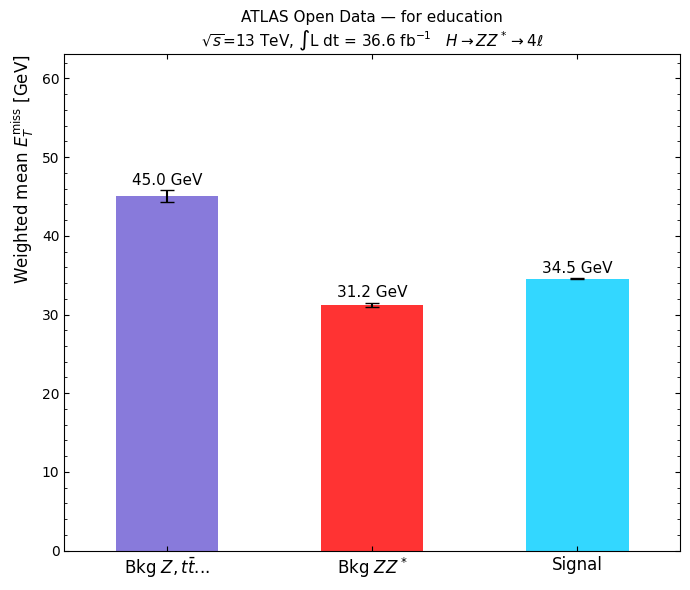

In [25]:
def plot_met_bar():
    sig_key = r'Signal ($m_H$ = 125 GeV)'

    labels, values, errors, colors = [], [], [], []

    for s in samples:
        if s == 'Data':
            continue
        vals    = ak.to_numpy(all_data[s]['met'])   # already in GeV, no conversion
        weights = ak.to_numpy(all_data[s]['totalWeight'])

        w_mean = np.average(vals, weights=weights)
        w_std  = np.sqrt(np.average((vals - w_mean)**2, weights=weights))
        w_err  = w_std / np.sqrt(len(vals))

        if s == sig_key:
            labels.append('Signal')
        elif 'ZZ' in s:
            labels.append(r'Bkg $ZZ^*$')
        else:
            labels.append(r'Bkg $Z,t\bar{t}$...')

        values.append(w_mean)
        errors.append(w_err)
        colors.append(samples[s]['color'])

    x     = np.arange(len(labels))
    width = 0.5

    fig, ax = plt.subplots(figsize=(7, 6))

    bars = ax.bar(x, values, yerr=errors, capsize=5,
                  color=colors, alpha=0.8, width=width,
                  error_kw=dict(elinewidth=1.5, ecolor='black'))

    for bar, val, err in zip(bars, values, errors):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + err + 0.3,
                f'{val:.1f} GeV',
                ha='center', va='bottom', fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_xlim(-0.5, len(labels) - 0.5)
    ax.set_ylabel(r'Weighted mean $E_T^{\mathrm{miss}}$ [GeV]',
                  fontsize=12, y=1, horizontalalignment='right')
    ax.set_ylim(bottom=0, top=max(values)*1.4)
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)

    ax.set_title('ATLAS Open Data — for education\n'
                 rf'$\sqrt{{s}}$=13 TeV, $\int$L dt = {lumi*fraction} fb$^{{-1}}$   '
                 rf'$H \rightarrow ZZ^* \rightarrow 4\ell$',
                 fontsize=11)

    plt.tight_layout()
    plt.show()

plot_met_bar()

## 7. Feature ranking and selection *(paper §VII.B)*

Paper §VII.B uses **separation power δ²** as the ranking metric for the 31
candidate features (paper Fig. 4):

\[
\delta^2 \;=\; \tfrac{1}{2}\sum_i \frac{(s_i - b_i)^2}{s_i + b_i}
\]

computed on 50 bins per feature. Two additional rankings — single-feature
ROC AUC and Random-Forest mean-decrease-impurity — are computed in the code
as cross-checks but are not cited in the paper.

After ranking, feature pairs with Pearson |ρ| ≥ 0.7 in the signal sample
(paper Fig. 5) are pruned by dropping the lower-ranked feature in each pair,
yielding the **20-feature** set used by every classifier.

### 7.1 Pearson correlation matrix on signal *(paper Fig. 5)*

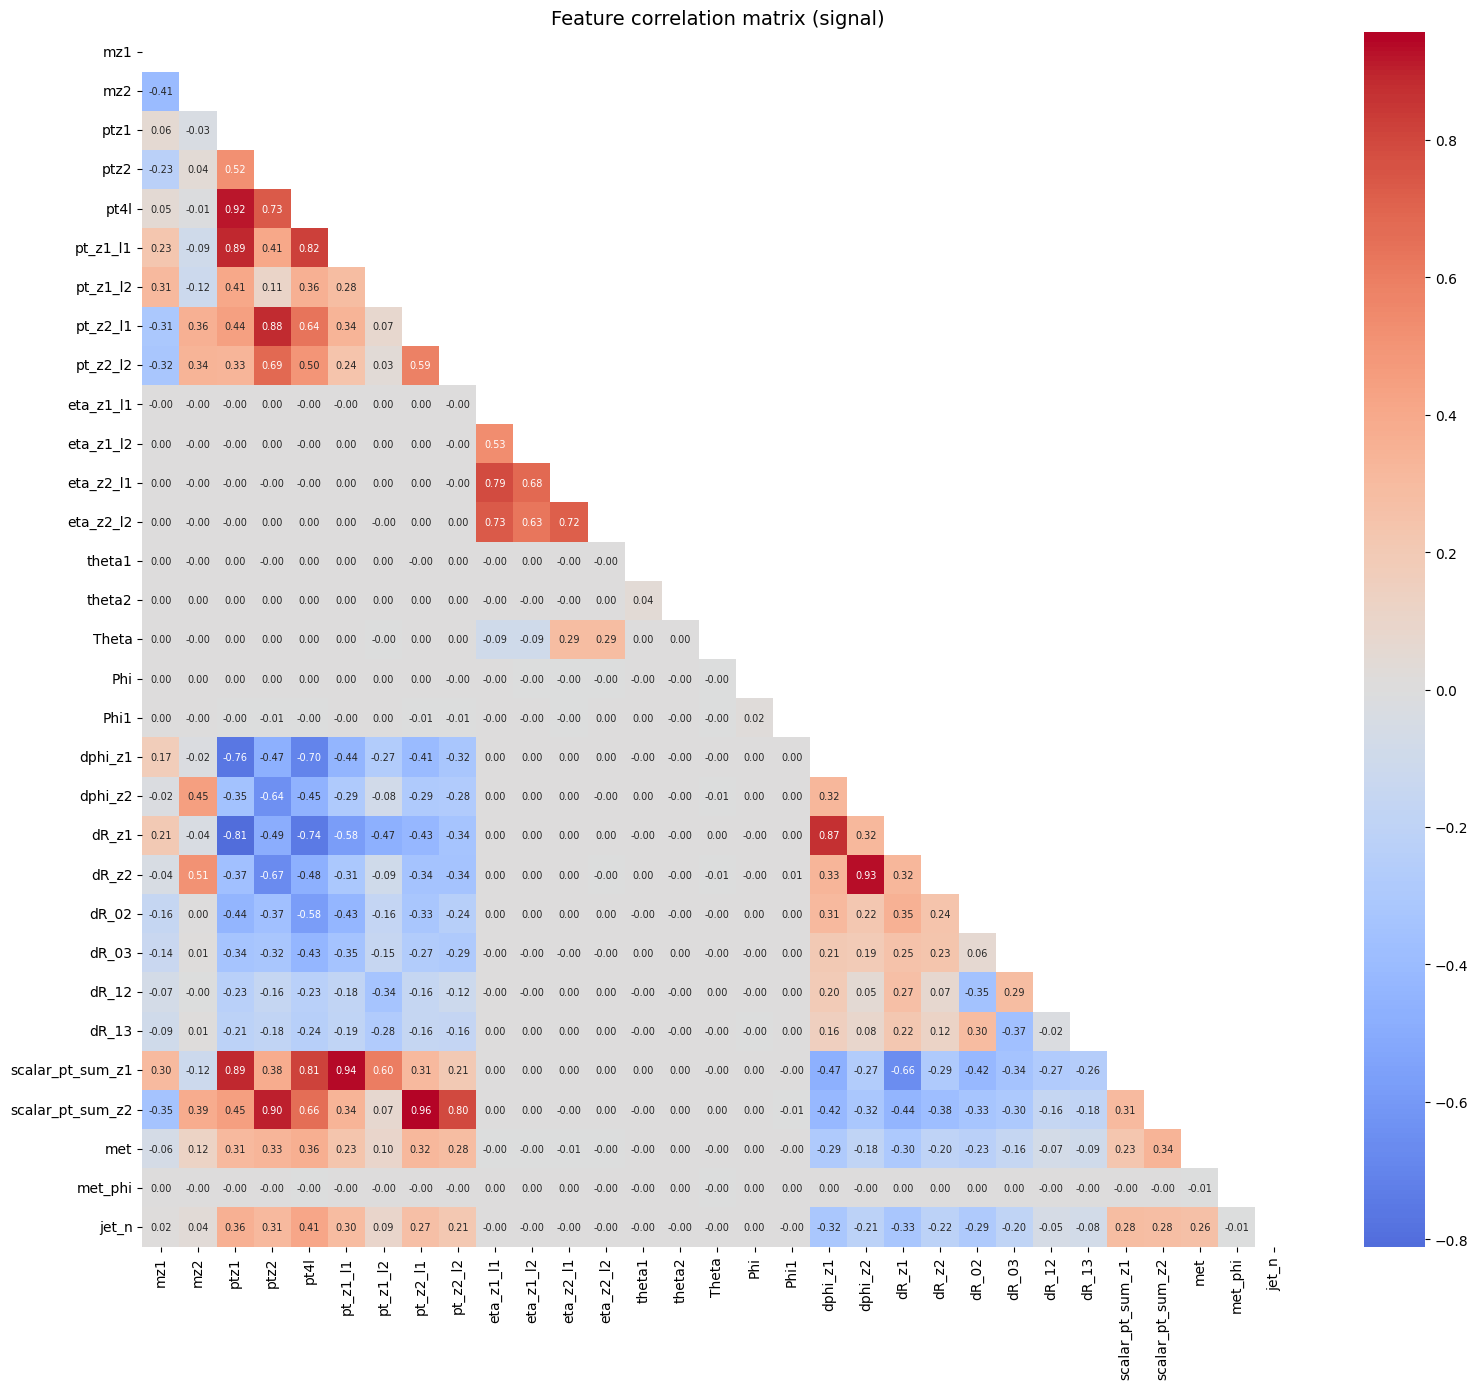

In [26]:

def build_feature_df():
    sig_key = r'Signal ($m_H$ = 125 GeV)'

    feature_keys = [
        'mz1','mz2','ptz1','ptz2','pt4l',
        'pt_z1_l1','pt_z1_l2','pt_z2_l1','pt_z2_l2',
        'eta_z1_l1','eta_z1_l2','eta_z2_l1','eta_z2_l2',
        'theta1','theta2','Theta','Phi','Phi1',
        'dphi_z1','dphi_z2',
        'dR_z1','dR_z2','dR_02','dR_03','dR_12','dR_13',
        'scalar_pt_sum_z1','scalar_pt_sum_z2', 'met', 'met_phi', 'jet_n',
    ]

    dfs = []
    for s in z_masses:
        df = pd.DataFrame({k: z_masses[s][k] for k in feature_keys})
        df['weight'] = z_masses[s]['w']
        df['label']  = 1 if s == sig_key else 0
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

df = build_feature_df()

# Correlation matrix on signal only
sig_df = df[df['label'] == 1].drop(columns=['weight','label'])

fig, ax = plt.subplots(figsize=(16, 14))
corr = sig_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature correlation matrix (signal)', fontsize=14)
plt.tight_layout()
plt.show()

### 7.2 Shared 60/20/20 train / val / test split

A single deterministic split is built once so that all three ranking metrics
(separation power, single-feature ROC AUC, Random Forest importance) and all
downstream classifiers see exactly the same training events — avoiding any
data leakage between feature selection and classifier evaluation.

In [27]:

# Feature list shared by all ranking and training cells
FEATURE_KEYS = [
    'mz1','mz2','ptz1','ptz2','pt4l',
    'pt_z1_l1','pt_z1_l2','pt_z2_l1','pt_z2_l2',
    'eta_z1_l1','eta_z1_l2','eta_z2_l1','eta_z2_l2',
    'theta1','theta2','Theta','Phi','Phi1',
    'dphi_z1','dphi_z2',
    'dR_z1','dR_z2','dR_02','dR_03','dR_12','dR_13',
    'scalar_pt_sum_z1','scalar_pt_sum_z2','met','met_phi','jet_n',
]

_sig_key  = r'Signal ($m_H$ = 125 GeV)'
_bkg_keys = [s for s in z_masses if s != _sig_key]

X_sig_all = np.stack([z_masses[_sig_key][k] for k in FEATURE_KEYS], axis=1)
w_sig_all = z_masses[_sig_key]['w']
X_bkg_all = np.stack([np.concatenate([z_masses[s][k] for s in _bkg_keys])
                      for k in FEATURE_KEYS], axis=1)
w_bkg_all = np.concatenate([z_masses[s]['w'] for s in _bkg_keys])

X_all = np.vstack([X_sig_all, X_bkg_all])
y_all = np.concatenate([np.ones(len(X_sig_all)), np.zeros(len(X_bkg_all))])
w_all = np.concatenate([w_sig_all, w_bkg_all])

# Single shared split — all downstream cells use these index arrays
_idx = np.arange(len(X_all))
idx_train, idx_holdout = train_test_split(
    _idx, test_size=0.40, random_state=42, stratify=y_all
)
idx_val, idx_test = train_test_split(
    idx_holdout, test_size=0.50, random_state=42, stratify=y_all[idx_holdout]
)

X_train_all = X_all[idx_train]
y_train_all = y_all[idx_train]
w_train_all = w_all[idx_train]

print(f'Total: {len(X_all):,}  Train: {len(idx_train):,}  Val: {len(idx_val):,}  Test: {len(idx_test):,}')


Total: 238,517  Train: 143,110  Val: 47,703  Test: 47,704


### 7.3 Separation power δ² *(paper Eq. 3 — primary ranking)*

/tmp/ipykernel_1876/348152524.py:10: RuntimeWarning: invalid value encountered in divide
  sep   = np.where(denom > 0, (s - b)**2 / denom, 0)


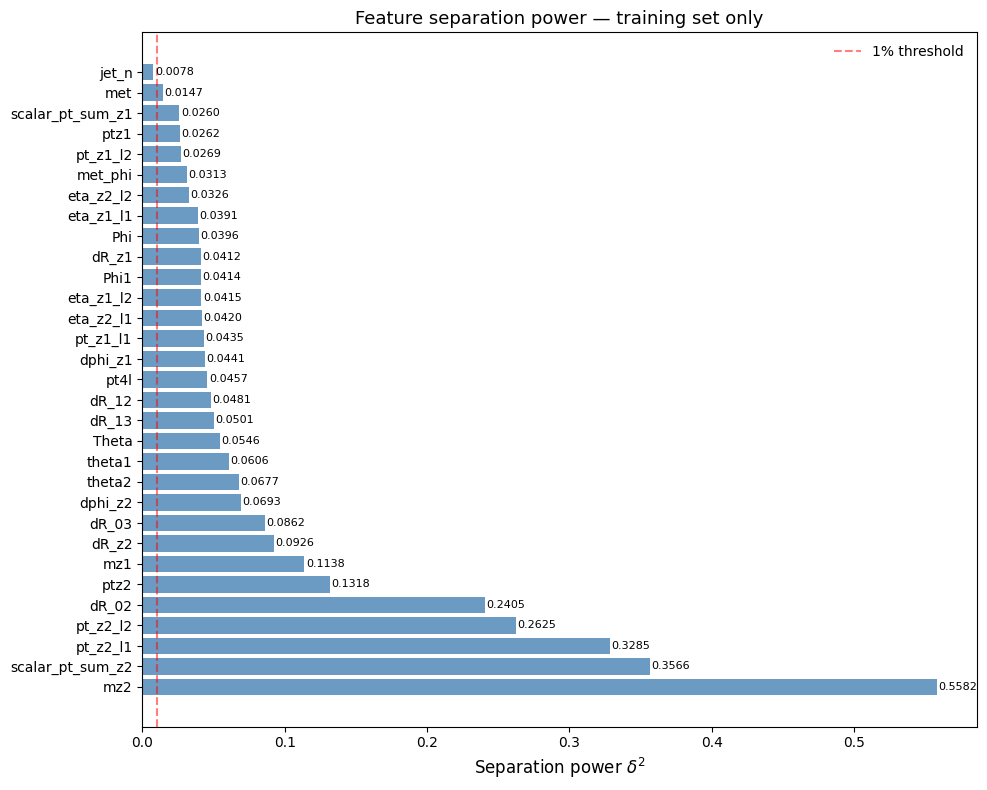


Ranked features by separation power (train only):
  mz2                 : 0.5582
  scalar_pt_sum_z2    : 0.3566
  pt_z2_l1            : 0.3285
  pt_z2_l2            : 0.2625
  dR_02               : 0.2405
  ptz2                : 0.1318
  mz1                 : 0.1138
  dR_z2               : 0.0926
  dR_03               : 0.0862
  dphi_z2             : 0.0693
  theta2              : 0.0677
  theta1              : 0.0606
  Theta               : 0.0546
  dR_13               : 0.0501
  dR_12               : 0.0481
  pt4l                : 0.0457
  dphi_z1             : 0.0441
  pt_z1_l1            : 0.0435
  eta_z2_l1           : 0.0420
  eta_z1_l2           : 0.0415
  Phi1                : 0.0414
  dR_z1               : 0.0412
  Phi                 : 0.0396
  eta_z1_l1           : 0.0391
  eta_z2_l2           : 0.0326
  met_phi             : 0.0313
  pt_z1_l2            : 0.0269
  ptz1                : 0.0262
  scalar_pt_sum_z1    : 0.0260
  met                 : 0.0147
  jet_n            

In [28]:
def separation_power(sig_vals, bkg_vals, sig_w, bkg_w, n_bins=50):
    xmin = min(sig_vals.min(), bkg_vals.min())
    xmax = max(sig_vals.max(), bkg_vals.max())
    bins = np.linspace(xmin, xmax, n_bins + 1)
    s, _ = np.histogram(sig_vals, bins=bins, weights=sig_w)
    b, _ = np.histogram(bkg_vals, bins=bins, weights=bkg_w)
    s = s / (s.sum() + 1e-12)
    b = b / (b.sum() + 1e-12)
    denom = s + b
    sep   = np.where(denom > 0, (s - b)**2 / denom, 0)
    return 0.5 * sep.sum()

def plot_separation_power(X_tr=None, y_tr=None, w_tr=None, feature_keys=None):
    """Plot separation power using training data only."""
    if X_tr is None:
        X_tr, y_tr, w_tr, feature_keys = X_train_all, y_train_all, w_train_all, FEATURE_KEYS

    sig_mask = y_tr == 1
    bkg_mask = y_tr == 0

    separations = {k: separation_power(X_tr[sig_mask, idx], X_tr[bkg_mask, idx],
                                       w_tr[sig_mask], w_tr[bkg_mask])
                   for idx, k in enumerate(feature_keys)}

    sorted_feats = sorted(separations, key=separations.get, reverse=True)
    sorted_vals  = [separations[k] for k in sorted_feats]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(sorted_feats, sorted_vals, color='steelblue', alpha=0.8)
    ax.set_xlabel(r'Separation power $\delta^2$', fontsize=12)
    ax.set_title('Feature separation power — training set only', fontsize=13)
    ax.axvline(0.01, color='red', linestyle='--', alpha=0.5, label='1% threshold')
    ax.legend(frameon=False)
    for bar, val in zip(bars, sorted_vals):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    print('\nRanked features by separation power (train only):')
    for k, v in sorted(separations.items(), key=lambda x: x[1], reverse=True):
        print(f'  {k:20s}: {v:.4f}')

    return separations

_seps_cache = plot_separation_power()


### 7.4 Single-feature ROC AUC *(cross-check, not cited in paper)*

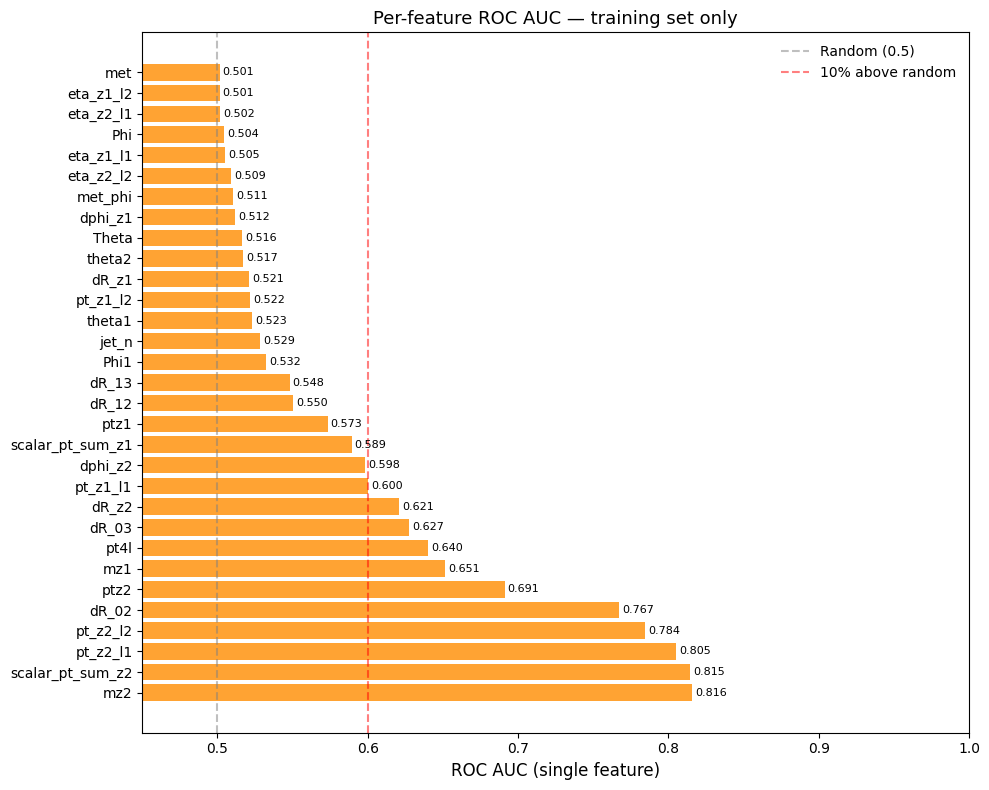

In [29]:

def plot_roc_auc_per_feature(X_tr=None, y_tr=None, w_tr=None, feature_keys=None):
    """Plot per-feature ROC AUC using training data only."""
    if X_tr is None:
        X_tr, y_tr, w_tr, feature_keys = X_train_all, y_train_all, w_train_all, FEATURE_KEYS

    aucs = {}
    for idx, k in enumerate(feature_keys):
        auc     = roc_auc_score(y_tr, X_tr[:, idx], sample_weight=w_tr)
        aucs[k] = max(auc, 1 - auc)

    sorted_feats = sorted(aucs, key=aucs.get, reverse=True)
    sorted_vals  = [aucs[k] for k in sorted_feats]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(sorted_feats, sorted_vals, color='darkorange', alpha=0.8)
    ax.set_xlabel('ROC AUC (single feature)', fontsize=12)
    ax.set_title('Per-feature ROC AUC — training set only', fontsize=13)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
    ax.axvline(0.6, color='red',  linestyle='--', alpha=0.5, label='10% above random')
    ax.set_xlim(0.45, 1.0)
    ax.legend(frameon=False)
    for bar, val in zip(bars, sorted_vals):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    return aucs

_aucs_cache = plot_roc_auc_per_feature()


### 7.5 Random-Forest feature importance *(cross-check, not cited in paper)*

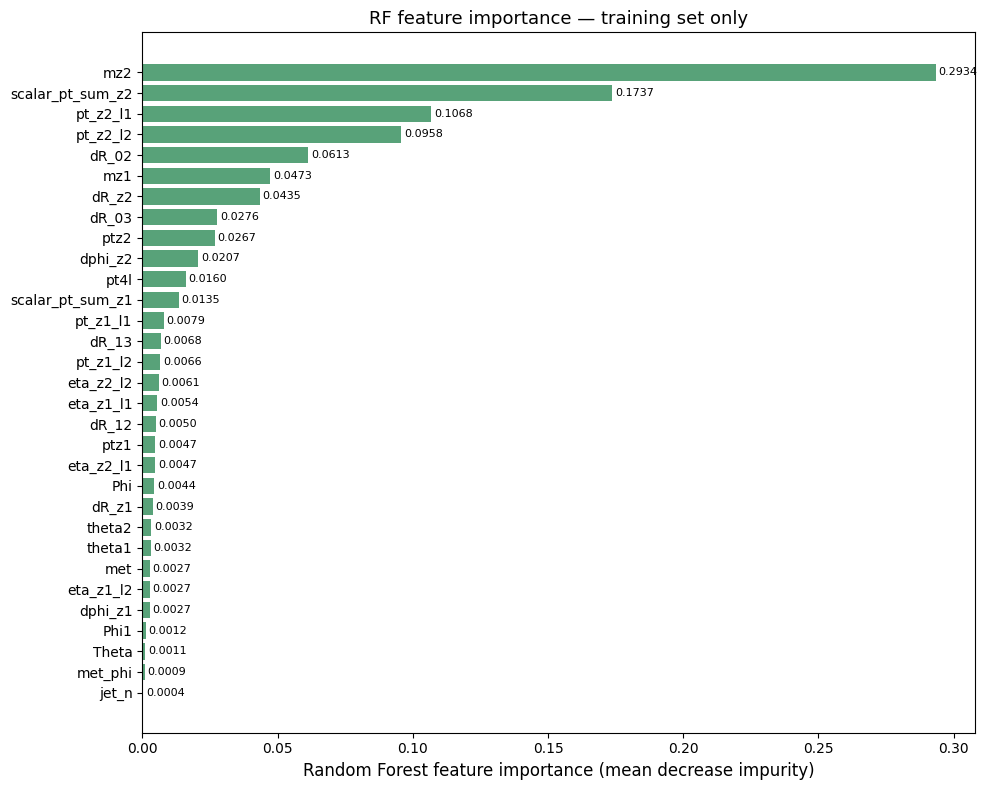

In [30]:

def plot_rf_importance(X_tr=None, y_tr=None, w_tr=None, feature_keys=None):
    if X_tr is None:
        X_tr, y_tr, w_tr, feature_keys = X_train_all, y_train_all, w_train_all, FEATURE_KEYS

    # Match combined fallback: scale signal to match background total weight
    w_scaled = w_tr.copy()
    w_scaled[y_tr == 1] *= (w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum())

    rf = RandomForestClassifier(n_estimators=300, max_depth=5,  # ← 300 not 200
                                n_jobs=-1, random_state=42)
    rf.fit(X_tr, y_tr, sample_weight=w_scaled)

    importances = rf.feature_importances_
    rf_imp      = {k: importances[i] for i, k in enumerate(feature_keys)}

    sorted_idx   = np.argsort(importances)
    sorted_feats = [feature_keys[i] for i in sorted_idx]
    sorted_vals  = importances[sorted_idx]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(sorted_feats, sorted_vals, color='seagreen', alpha=0.8)
    ax.set_xlabel('Random Forest feature importance (mean decrease impurity)', fontsize=12)
    ax.set_title('RF feature importance — training set only', fontsize=13)
    for bar, val in zip(bars, sorted_vals):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    return rf_imp

_rf_imp_cache = plot_rf_importance()


### 7.6 Combined ranking table

Side-by-side comparison of the three rankings. The paper quotes only the
separation-power column; the other two confirm the same top features.

In [31]:
def combined_feature_ranking(seps=None, aucs=None, rf_imp=None,
                              X_tr=None, y_tr=None, w_tr=None, feature_keys=None):
    if X_tr is None:
        X_tr, y_tr, w_tr, feature_keys = X_train_all, y_train_all, w_train_all, FEATURE_KEYS

    # Use caches directly — no globals() needed
    if seps   is None: seps   = _seps_cache
    if aucs   is None: aucs   = _aucs_cache
    if rf_imp is None: rf_imp = _rf_imp_cache

    if any(x is None for x in [seps, aucs, rf_imp]):
        raise RuntimeError(
            "Cache missing — run plot_separation_power(), "
            "plot_roc_auc_per_feature(), and plot_rf_importance() first."
        )

    print('Using cached results for all three metrics.')

    print(f'\n{"Feature":<22} {"Sep. Power":>12} {"ROC AUC":>10} {"RF Imp.":>10}')
    print('='*60)
    for k in sorted(seps, key=seps.get, reverse=True):
        print(f'{k:<22} {seps[k]:>12.4f} {aucs[k]:>10.3f} {rf_imp[k]:>10.4f}')

    print()
    print('Agreement between ROC AUC and RF (top 10 each):')

    return seps, aucs, rf_imp

seps, aucs, rf_imp = combined_feature_ranking()


Using cached results for all three metrics.

Feature                  Sep. Power    ROC AUC    RF Imp.
mz2                          0.5582      0.816     0.2934
scalar_pt_sum_z2             0.3566      0.815     0.1737
pt_z2_l1                     0.3285      0.805     0.1068
pt_z2_l2                     0.2625      0.784     0.0958
dR_02                        0.2405      0.767     0.0613
ptz2                         0.1318      0.691     0.0267
mz1                          0.1138      0.651     0.0473
dR_z2                        0.0926      0.621     0.0435
dR_03                        0.0862      0.627     0.0276
dphi_z2                      0.0693      0.598     0.0207
theta2                       0.0677      0.517     0.0032
theta1                       0.0606      0.523     0.0032
Theta                        0.0546      0.516     0.0011
dR_13                        0.0501      0.548     0.0068
dR_12                        0.0481      0.550     0.0050
pt4l                       

### 7.7 Correlation pruning with |ρ| ≥ 0.7 *(paper §VII.B)*

Run the pruning once per ranking; only `keep_sep` (separation power) is used
downstream — this is the 20-feature set quoted in the paper. The other two
rankings are kept here as a robustness check.

In [32]:
def analyse_correlations_by_method(scores_dict, method_name, threshold=0.7):
    sig_key = r'Signal ($m_H$ = 125 GeV)'

    feature_keys = list(scores_dict.keys())

    sig_df = pd.DataFrame({k: z_masses[sig_key][k] for k in feature_keys})
    corr   = sig_df.corr().abs()

    pairs = []
    for i in range(len(feature_keys)):
        for j in range(i+1, len(feature_keys)):
            f1  = feature_keys[i]
            f2  = feature_keys[j]
            pairs.append((f1, f2, corr.loc[f1, f2]))
    pairs_df = pd.DataFrame(pairs, columns=['Feature 1','Feature 2','|Correlation|'])
    pairs_df = pairs_df.sort_values('|Correlation|', ascending=False).reset_index(drop=True)
    high     = pairs_df[pairs_df['|Correlation|'] >= threshold]

    print()
    print('='*70)
    print(f'  METHOD: {method_name}   (threshold = {threshold})')
    print('='*70)
    print(f'  {"Feature 1":<22} {"Feature 2":<22} {"|r|":>6}  {"Keep":<22} {"Drop"}')
    print(f'  {"-"*70}')

    to_drop = set()

    for _, row in high.iterrows():
        f1, f2   = row['Feature 1'], row['Feature 2']
        corr_val = row['|Correlation|']

        if f1 in to_drop and f2 in to_drop:
            continue
        if f1 in to_drop or f2 in to_drop:
            continue

        if scores_dict[f1] >= scores_dict[f2]:
            keep, drop = f1, f2
        else:
            keep, drop = f2, f1

        to_drop.add(drop)
        print(f'  {f1:<22} {f2:<22} {corr_val:>6.3f}  KEEP {keep:<18} DROP {drop}')

    features_to_keep = [f for f in feature_keys if f not in to_drop]

    print()
    print(f'  Features kept  ({len(features_to_keep):>2}/{len(feature_keys)}): '
          f'{", ".join(features_to_keep)}')
    print(f'  Features dropped ({len(to_drop):>2}/{len(feature_keys)}): '
          f'{", ".join(sorted(to_drop))}')

    return features_to_keep, sorted(to_drop)

# ---------------------------------------------------------------
# Run three times — Combined removed
# ---------------------------------------------------------------
keep_sep, drop_sep = analyse_correlations_by_method(seps,   'Separation Power')
keep_auc, drop_auc = analyse_correlations_by_method(aucs,   'ROC AUC')
keep_rf,  drop_rf  = analyse_correlations_by_method(rf_imp, 'Random Forest')

# ---------------------------------------------------------------
# Final summary — three methods only
# ---------------------------------------------------------------
feature_keys = list(seps.keys())   # use seps keys as the master list

print()
print('='*60)
print('FINAL SUMMARY — agreement across three methods')
print('='*60)
print(f'  {"Feature":<22} {"Sep.Power":>12} {"ROC AUC":>10} {"RF":>8}')
print(f'  {"-"*55}')

for f in feature_keys:
    s1 = 'KEEP' if f in keep_sep else 'DROP'
    s2 = 'KEEP' if f in keep_auc else 'DROP'
    s3 = 'KEEP' if f in keep_rf  else 'DROP'
    print(f'  {f:<22} {s1:>12} {s2:>10} {s3:>8}')

keep_all = set(keep_sep) & set(keep_auc) & set(keep_rf)
drop_any = set(drop_sep) | set(drop_auc) | set(drop_rf)

print()
print(f'  All three agree to KEEP ({len(keep_all)}):')
for f in feature_keys:
    if f in keep_all:
        print(f'    + {f}')

print()
print(f'  At least one method wants to DROP ({len(drop_any)}):')
for f in feature_keys:
    if f in drop_any:
        n = sum([f in drop_sep, f in drop_auc, f in drop_rf])
        print(f'    - {f:<22}  dropped by {n}/3 methods')


  METHOD: Separation Power   (threshold = 0.7)
  Feature 1              Feature 2                 |r|  Keep                   Drop
  ----------------------------------------------------------------------
  pt_z2_l1               scalar_pt_sum_z2        0.956  KEEP scalar_pt_sum_z2   DROP pt_z2_l1
  pt_z1_l1               scalar_pt_sum_z1        0.936  KEEP pt_z1_l1           DROP scalar_pt_sum_z1
  dphi_z2                dR_z2                   0.934  KEEP dR_z2              DROP dphi_z2
  ptz1                   pt4l                    0.920  KEEP pt4l               DROP ptz1
  ptz2                   scalar_pt_sum_z2        0.905  KEEP scalar_pt_sum_z2   DROP ptz2
  dphi_z1                dR_z1                   0.871  KEEP dphi_z1            DROP dR_z1
  pt4l                   pt_z1_l1                0.819  KEEP pt4l               DROP pt_z1_l1
  pt_z2_l2               scalar_pt_sum_z2        0.796  KEEP scalar_pt_sum_z2   DROP pt_z2_l2
  eta_z1_l1              eta_z2_l1             

## 8. Event yields after preselection *(paper Table II)*

Raw (unweighted) and luminosity-scaled yields for each sample group, plus the
total expected background and the observed real-data count.

In [33]:
# Scaled yields (weighted by luminosity)
print('='*60)
print('SCALED YIELDS (weighted to luminosity)')
print('='*60)

sig_key = r'Signal ($m_H$ = 125 GeV)'
total_bkg = 0.0
total_bkg_err = 0.0

for s in samples:
    if s == 'Data':
        continue
    w = ak.to_numpy(all_data[s]['totalWeight'])
    yield_val = w.sum()
    yield_err = np.sqrt((w**2).sum())   # sqrt(sum of weights squared)

    if s == sig_key:
        print(f'\n{"Signal":<45} {yield_val:>10.2f} ± {yield_err:.2f}')
    else:
        print(f'{s:<45} {yield_val:>10.2f} ± {yield_err:.2f}')
        total_bkg     += yield_val
        total_bkg_err += yield_err**2   # add variances

total_bkg_err = np.sqrt(total_bkg_err)
print(f'\n{"Total background":<45} {total_bkg:>10.2f} ± {total_bkg_err:.2f}')
print('='*60)

SCALED YIELDS (weighted to luminosity)
Background $Z,t\bar{t},t\bar{t}+V,VVV$            128.78 ± 16.34
Background $ZZ^{*}$                              1067.12 ± 18.15

Signal                                             30.43 ± 1.33

Total background                                 1195.90 ± 24.42


In [34]:
# Raw event counts (unweighted)
print('='*60)
print('RAW EVENT COUNTS (unweighted)')
print('='*60)

total_bkg_raw = 0

for s in samples:
    if s == 'Data':
        continue
    n_raw = len(all_data[s]['mass'])

    if s == sig_key:
        print(f'\n{"Signal":<45} {n_raw:>10,}')
    else:
        print(f'{s:<45} {n_raw:>10,}')
        total_bkg_raw += n_raw

print(f'\n{"Total background":<45} {total_bkg_raw:>10,}')
print('='*60)

# Also print real data count separately
n_data = len(all_data['Data']['mass'])
print(f'\n{"Real data (observed events)":<45} {n_data:>10,}')
print('='*60)

RAW EVENT COUNTS (unweighted)
Background $Z,t\bar{t},t\bar{t}+V,VVV$             6,071
Background $ZZ^{*}$                                6,365

Signal                                           226,168

Total background                                  12,436

Real data (observed events)                        1,279


## 9. ML pipeline — shared helpers *(paper §VIII)*

Common machinery used by every classifier:

* `yields_in_window`, `significance_with_uncertainty` — paper Eqs. 4–6
  (signal significance S/√(B + (kB)²) with k = 0.30 fractional systematic,
  and propagated σ_Z and one-sided p-value).
* `build_ml_dataset_with_mass` — builds the X / y / w / m arrays from
  `z_masses` for any feature list, keeping m_4l so it can be used at
  scoring time.
* `_fit_xgb_for_validation` / `_summarize` — train/val/test split helpers
  used for the initial XGBoost sanity check before the 5-fold OOF pipeline.

In [35]:
# --- validation helpers ---------------------------------------------------

# Mass-window for the Higgs peak: bins 16-19 ([110, 115) GeV) on a 80-250 GeV axis
# with 2.5 GeV binning.
BIN_XMIN, BIN_XMAX, BIN_STEP = 80.0, 250.0, 2.5
BIN_EDGES = np.arange(BIN_XMIN, BIN_XMAX + BIN_STEP, BIN_STEP)
MASS_BIN_SLICE = slice(12, 22)
FRAC_SYST_B    = 0.30   # 30% fractional systematic on B

def yields_in_window(mass, weights):
    if len(mass) == 0:
        return 0.0, 0.0
    h_w,  _ = np.histogram(mass, bins=BIN_EDGES, weights=weights)
    h_w2, _ = np.histogram(mass, bins=BIN_EDGES, weights=weights**2)
    S       = float(h_w[MASS_BIN_SLICE].sum())
    sigma_S = float(np.sqrt(h_w2[MASS_BIN_SLICE].sum()))
    return S, sigma_S

def significance_with_uncertainty(S, B, sigma_S, sigma_B, frac_syst_B=FRAC_SYST_B):
    """Z = S / sqrt(B + (frac_syst_B * B)^2),  propagated sigma_Z,  one-tailed p.
    Null hypothesis: pure background -> p = 1 - Phi(Z)."""
    k = frac_syst_B
    if (not np.isfinite(S)) or (not np.isfinite(B)) or B <= 0:
        return {'Z': np.nan, 'sigma_Z': np.nan, 'pvalue': np.nan}
    denom  = B + (k * B)**2                        # B + k^2 B^2
    Z      = S / np.sqrt(denom)
    term_S = sigma_S**2 / denom
    term_B = (S**2 * (1 + 2*k**2 * B)**2 * sigma_B**2) / (4 * denom**3)
    sigma_Z = float(np.sqrt(term_S + term_B))
    pvalue  = float(norm.sf(Z))
    return {'Z': float(Z), 'sigma_Z': sigma_Z, 'pvalue': pvalue}

def build_ml_dataset_with_mass(feature_list):
    """Like build_ml_dataset but also returns per-event m_4l."""
    sig_key  = r'Signal ($m_H$ = 125 GeV)'
    bkg_keys = [s for s in z_masses if s != sig_key]

    X_sig = np.stack([z_masses[sig_key][k] for k in feature_list], axis=1)
    w_sig = z_masses[sig_key]['w']
    m_sig = z_masses[sig_key]['mass']

    X_bkg = np.stack([np.concatenate([z_masses[s][k] for s in bkg_keys])
                      for k in feature_list], axis=1)
    w_bkg = np.concatenate([z_masses[s]['w']    for s in bkg_keys])
    m_bkg = np.concatenate([z_masses[s]['mass'] for s in bkg_keys])

    X = np.vstack([X_sig, X_bkg])
    y = np.concatenate([np.ones(len(X_sig)), np.zeros(len(X_bkg))])
    w = np.concatenate([w_sig, w_bkg])
    m = np.concatenate([m_sig, m_bkg])
    return X, y, w, m

def _fit_xgb_for_validation(X, y, w, m, split_seed, model_seed):
    X_train, X_temp, y_train, y_temp, w_train, w_temp, m_train, m_temp = train_test_split(
        X, y, w, m, test_size=0.40, random_state=split_seed, stratify=y
    )
    X_val, X_test, y_val, y_test, w_val, w_test, m_val, m_test = train_test_split(
        X_temp, y_temp, w_temp, m_temp, test_size=0.50,
        random_state=split_seed, stratify=y_temp
    )

    scaler    = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    scale_pos_weight = w_train[y_train == 0].sum() / w_train[y_train == 1].sum()

    model = xgb.XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=1, gamma=0, reg_lambda=1, reg_alpha=0,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc', random_state=model_seed, n_jobs=-1,
    )
    model.fit(
        X_train_s, y_train,
        sample_weight          = w_train,
        eval_set               = [(X_val_s, y_val)],
        sample_weight_eval_set = [w_val],
        verbose                = False,
    )

    splits = {}
    for name, Xs, ys, ws, ms in [('train', X_train_s, y_train, w_train, m_train),
                                 ('val',   X_val_s,   y_val,   w_val,   m_val),
                                 ('test',  X_test_s,  y_test,  w_test,  m_test)]:
        splits[name] = {'p': model.predict_proba(Xs)[:, 1],
                        'y': ys, 'w': ws, 'm': ms}

    # Class-wise rescaling: the test set is a stratified 20% draw, so scale
    # weights up to represent the full luminosity yield per class.
    test = splits['test']
    test['s_scale'] = w[y == 1].sum() / test['w'][test['y'] == 1].sum()
    test['b_scale'] = w[y == 0].sum() / test['w'][test['y'] == 0].sum()
    return splits

def _summarize(splits, threshold=0.5):
    """Weighted AUC on all splits, and mass-window Z / sigma_Z / p-value on
    the held-out test set (rescaled to full luminosity)."""
    test = splits['test']
    auc_test  = roc_auc_score(test['y'],  test['p'],  sample_weight=test['w'])
    auc_train = roc_auc_score(splits['train']['y'], splits['train']['p'],
                              sample_weight=splits['train']['w'])
    auc_val   = roc_auc_score(splits['val']['y'],   splits['val']['p'],
                              sample_weight=splits['val']['w'])

    pass_mask = test['p'] > threshold
    sig_mask  = (test['y'] == 1)
    bkg_mask  = (test['y'] == 0)

    # True signals (TP) and misclassified backgrounds (FP) passing threshold,
    # each rescaled to full luminosity per class.
    S, sigma_S = yields_in_window(
        test['m'][sig_mask & pass_mask],
        test['w'][sig_mask & pass_mask] * test['s_scale'],
    )
    B, sigma_B = yields_in_window(
        test['m'][bkg_mask & pass_mask],
        test['w'][bkg_mask & pass_mask] * test['b_scale'],
    )
    z = significance_with_uncertainty(S, B, sigma_S, sigma_B)

    return {
        'train_auc': auc_train,
        'val_auc'  : auc_val,
        'test_auc' : auc_test,
        'S'        : S,      'sigma_S': sigma_S,
        'B'        : B,      'sigma_B': sigma_B,
        'Z'        : z['Z'], 'sigma_Z': z['sigma_Z'],
        'pvalue'   : z['pvalue'],
    }

# Build feature matrix once (Separation Power, with mz2)
X_sep, y_sep, w_sep, m_sep = build_ml_dataset_with_mass(keep_sep)
print(f'Separation-power features ({len(keep_sep)}): {keep_sep}')
print(f'Total events: {len(y_sep)}   signal: {int((y_sep==1).sum())}   bkg: {int((y_sep==0).sum())}')
print(f'Lumi-scaled yields   -> signal: {w_sep[y_sep==1].sum():.3f}   bkg: {w_sep[y_sep==0].sum():.3f}')


Separation-power features (20): ['mz1', 'mz2', 'pt4l', 'pt_z1_l2', 'eta_z1_l2', 'eta_z2_l1', 'theta1', 'theta2', 'Theta', 'Phi', 'Phi1', 'dR_z2', 'dR_02', 'dR_03', 'dR_12', 'dR_13', 'scalar_pt_sum_z2', 'met', 'met_phi', 'jet_n']
Total events: 238517   signal: 226120   bkg: 12397
Lumi-scaled yields   -> signal: 30.434   bkg: 1194.692


### 9.1 No-ML baseline significance *(paper §IX, Eq. 4)*

Counting significance in the m_4l ∈ [110, 135) GeV signal window with only
the kinematic + Z₁/Z₂ preselection applied — the reference number that every
ML model has to beat.

In [36]:
# ----- No-ML baseline: S, B, Z on the FULL dataset, no classifier, no split -----
# This is the ground-truth counting significance in the mass window with only the
# kinematic + Z1/Z2 preselection applied — the number to quote as the pre-ML baseline.

sig_key = r'Signal ($m_H$ = 125 GeV)'
lo = BIN_EDGES[MASS_BIN_SLICE.start]
hi = BIN_EDGES[MASS_BIN_SLICE.stop]

# Signal yield in window (pure signal, not stacked)
m_s = z_masses[sig_key]['mass']
w_s = z_masses[sig_key]['w']
in_s = (m_s >= lo) & (m_s < hi)
S       = float(w_s[in_s].sum())
sigma_S = float(np.sqrt((w_s[in_s] ** 2).sum()))

# Background yield in window (all MC bkgs summed)
B, sumw2_B = 0.0, 0.0
for s in z_masses:
    if s == sig_key:
        continue
    m = z_masses[s]['mass']
    w = z_masses[s]['w']
    inw = (m >= lo) & (m < hi)
    B       += float(w[inw].sum())
    sumw2_B += float((w[inw] ** 2).sum())
sigma_B = float(np.sqrt(sumw2_B))

z_no_ml = significance_with_uncertainty(S, B, sigma_S, sigma_B)

print('=' * 74)
print(f'  No-ML baseline (full dataset, no classifier, window [{lo:.1f}, {hi:.1f}) GeV)')
print('=' * 74)
print(f'  S = {S:7.3f} ± {sigma_S:6.3f}')
print(f'  B = {B:7.3f} ± {sigma_B:6.3f}')
print(f'  Z = {z_no_ml["Z"]:6.3f} ± {z_no_ml["sigma_Z"]:5.3f}     p = {z_no_ml["pvalue"]:.2e}')
print()
print('  This is the ATLAS-tutorial-style counting significance with only kinematic')
print('  + Z1/Z2 preselection, no machine-learning cut applied.')


  No-ML baseline (full dataset, no classifier, window [110.0, 135.0) GeV)
  S =  25.839 ±  0.639
  B =  31.945 ±  5.622
  Z =  2.322 ± 0.361     p = 1.01e-02

  This is the ATLAS-tutorial-style counting significance with only kinematic
  + Z1/Z2 preselection, no machine-learning cut applied.


## 10. XGBoost — tuning and 5-fold OOF *(paper §VIII.C.1, Table VIII)*

Inner 5-fold grid search over `max_depth ∈ {3, 4, 5}` and
`min_child_weight ∈ {1, 5, 10}`. All other hyperparameters are fixed at the
paper-quoted values (Table III). Early stopping on the internal validation
AUC selects `n_estimators` adaptively per fold.

The best (depth, min_child_weight) combination is then used for the final
5-fold stratified OOF training that produces the score `oof_mc` used downstream.

In [37]:
# ============================================================================
# XGBoost TUNING: max_depth x min_child_weight grid search
# ============================================================================
# Only these two are worth tuning given early stopping handles n_estimators
# and the remaining params are already well-constrained.

TUNE_SPLITS    = 5
TUNE_SEED      = 42
MAX_DEPTH_GRID = [3, 4, 5]
MCW_GRID       = [1, 5, 10]

print(f"Tuning over {len(MAX_DEPTH_GRID) * len(MCW_GRID)} combinations "
      f"({TUNE_SPLITS}-fold inner CV each)...\n")

inner_skf = StratifiedKFold(n_splits=TUNE_SPLITS, shuffle=True, random_state=TUNE_SEED)
tune_results = []

for max_depth, min_child_weight in itertools.product(MAX_DEPTH_GRID, MCW_GRID):
    fold_aucs = []

    for tr_idx, te_idx in inner_skf.split(X_sep, y_sep):
        X_tr_i, X_te_i = X_sep[tr_idx], X_sep[te_idx]
        y_tr_i, y_te_i = y_sep[tr_idx], y_sep[te_idx]
        w_tr_i, w_te_i = w_sep[tr_idx], w_sep[te_idx]

        X_tr_i, X_val_i, y_tr_i, y_val_i, w_tr_i, w_val_i = train_test_split(
            X_tr_i, y_tr_i, w_tr_i,
            test_size=0.20, random_state=TUNE_SEED, stratify=y_tr_i,
        )

        scaler    = StandardScaler()
        X_tr_i_s  = scaler.fit_transform(X_tr_i)
        X_val_i_s = scaler.transform(X_val_i)
        X_te_i_s  = scaler.transform(X_te_i)

        spw = w_tr_i[y_tr_i == 0].sum() / w_tr_i[y_tr_i == 1].sum()

        model = xgb.XGBClassifier(
            n_estimators      = 500,
            max_depth         = max_depth,
            min_child_weight  = min_child_weight,
            learning_rate     = 0.05,
            subsample         = 0.8,
            colsample_bytree  = 0.8,
            gamma             = 0,
            reg_lambda        = 1,
            reg_alpha         = 0,
            scale_pos_weight  = spw,
            eval_metric       = 'auc',
            random_state      = TUNE_SEED,
            n_jobs            = -1,
            tree_method       = 'hist',
            early_stopping_rounds = 20,
        )
        model.fit(
            X_tr_i_s, y_tr_i,
            sample_weight          = w_tr_i,
            eval_set               = [(X_val_i_s, y_val_i)],
            sample_weight_eval_set = [w_val_i],
            verbose                = False,
        )

        proba = model.predict_proba(X_te_i_s)[:, 1]
        fold_aucs.append(roc_auc_score(y_te_i, proba, sample_weight=w_te_i))

    mean_auc = np.mean(fold_aucs)
    std_auc  = np.std(fold_aucs)
    tune_results.append({
        'max_depth': max_depth, 'min_child_weight': min_child_weight,
        'mean_auc': mean_auc,   'std_auc': std_auc,
    })
    print(f"  max_depth={max_depth}  min_child_weight={min_child_weight:>2d}"
          f"  ->  AUC = {mean_auc:.4f} ± {std_auc:.4f}")

best = max(tune_results, key=lambda x: x['mean_auc'])
BEST_MAX_DEPTH        = best['max_depth']
BEST_MIN_CHILD_WEIGHT = best['min_child_weight']

print(f"\nBest: max_depth={BEST_MAX_DEPTH},  "
      f"min_child_weight={BEST_MIN_CHILD_WEIGHT}  "
      f"(AUC = {best['mean_auc']:.4f} ± {best['std_auc']:.4f})")

Tuning over 9 combinations (5-fold inner CV each)...

  max_depth=3  min_child_weight= 1  ->  AUC = 0.9484 ± 0.0326
  max_depth=3  min_child_weight= 5  ->  AUC = 0.9530 ± 0.0229
  max_depth=3  min_child_weight=10  ->  AUC = 0.9471 ± 0.0297
  max_depth=4  min_child_weight= 1  ->  AUC = 0.9616 ± 0.0254
  max_depth=4  min_child_weight= 5  ->  AUC = 0.9518 ± 0.0211
  max_depth=4  min_child_weight=10  ->  AUC = 0.9468 ± 0.0254
  max_depth=5  min_child_weight= 1  ->  AUC = 0.9563 ± 0.0219
  max_depth=5  min_child_weight= 5  ->  AUC = 0.9587 ± 0.0143
  max_depth=5  min_child_weight=10  ->  AUC = 0.9516 ± 0.0278

Best: max_depth=4,  min_child_weight=1  (AUC = 0.9616 ± 0.0254)


### 10.1 5-fold stratified OOF training *(paper §VIII.A)*

Every Monte-Carlo event is scored by a model that did not see it during
training. The OOF AUC and the in-window signal significance are reported and
compared to the no-ML baseline.

In [38]:
# ----- k-fold CV: stable ML significance (every event scored out-of-fold) -----

N_SPLITS         = 5
KFOLD_MODEL_SEED = 42
KFOLD_SEED       = 42
THRESHOLD        = 0.65

# --- recompute no-ML baseline inline so this cell is self-contained ---
sig_key = r'Signal ($m_H$ = 125 GeV)'
lo = BIN_EDGES[MASS_BIN_SLICE.start]
hi = BIN_EDGES[MASS_BIN_SLICE.stop]

m_s  = z_masses[sig_key]['mass']
w_s  = z_masses[sig_key]['w']
in_s = (m_s >= lo) & (m_s < hi)
S_base       = float(w_s[in_s].sum())
sigma_S_base = float(np.sqrt((w_s[in_s] ** 2).sum()))

B_base, sumw2_B_base = 0.0, 0.0
for s in z_masses:
    if s == sig_key:
        continue
    m = z_masses[s]['mass']
    w = z_masses[s]['w']
    inw = (m >= lo) & (m < hi)
    B_base       += float(w[inw].sum())
    sumw2_B_base += float((w[inw] ** 2).sum())
sigma_B_base = float(np.sqrt(sumw2_B_base))

z_no_ml = significance_with_uncertainty(S_base, B_base, sigma_S_base, sigma_B_base)
Z_base  = z_no_ml['Z']

# --- k-fold OOF ---
skf        = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=KFOLD_SEED)
oof_scores = np.zeros(len(y_sep))
fold_aucs  = []

t0 = time.time()
for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_sep, y_sep)):
    X_tr_full, X_te = X_sep[train_idx], X_sep[test_idx]
    y_tr_full, y_te = y_sep[train_idx], y_sep[test_idx]
    w_tr_full, w_te = w_sep[train_idx], w_sep[test_idx]

    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_tr_full, y_tr_full, w_tr_full,
        test_size=0.20, random_state=KFOLD_SEED, stratify=y_tr_full,
    )

    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)
    X_te_s  = scaler.transform(X_te)

    scale_pos_weight = w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum()

    model = xgb.XGBClassifier(
        n_estimators=500, max_depth=BEST_MAX_DEPTH, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=BEST_MIN_CHILD_WEIGHT, gamma=0, reg_lambda=1, reg_alpha=0,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc', random_state=KFOLD_MODEL_SEED, n_jobs=-1,
        tree_method='hist', early_stopping_rounds=20,
    )
    model.fit(
        X_tr_s, y_tr,
        sample_weight          = w_tr,
        eval_set               = [(X_val_s, y_val)],
        sample_weight_eval_set = [w_val],
        verbose                = False,
    )

    oof_scores[test_idx] = model.predict_proba(X_te_s)[:, 1]
    fold_auc = roc_auc_score(y_te, oof_scores[test_idx], sample_weight=w_te)
    fold_aucs.append(fold_auc)
    print(f'  fold {fold_idx+1}/{N_SPLITS}: AUC={fold_auc:.4f}   '
          f'n_train={len(X_tr)}  n_val={len(X_val)}  n_test={len(X_te)}   '
          f'[t={time.time()-t0:.1f}s]')

# --- OOF AUC ---
full_oof_auc = roc_auc_score(y_sep, oof_scores, sample_weight=w_sep)
print(f'\n  Out-of-fold AUC (all events): {full_oof_auc:.4f}   '
      f'per-fold mean ± std: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')

# --- significance after ML cut ---
pass_mask = oof_scores > THRESHOLD
sig_mask  = (y_sep == 1)
bkg_mask  = (y_sep == 0)

S_ml, sigma_S_ml = yields_in_window(m_sep[sig_mask & pass_mask], w_sep[sig_mask & pass_mask])
B_ml, sigma_B_ml = yields_in_window(m_sep[bkg_mask & pass_mask], w_sep[bkg_mask & pass_mask])
z_ml = significance_with_uncertainty(S_ml, B_ml, sigma_S_ml, sigma_B_ml)

# --- save for downstream cells ---
xgb_result = {
    'oof'      : oof_scores,
    'X'        : X_sep,
    'y'        : y_sep,
    'w'        : w_sep,
    'm'        : m_sep,
    'auc'      : full_oof_auc,
    'Z'        : z_ml,
    'fold_aucs': fold_aucs,
}

# --- summary table ---
print()
print('=' * 74)
print(f'  ML significance via {N_SPLITS}-fold CV (full dataset, out-of-fold scores)')
print('=' * 74)
print(f'  {"":30} {"S":>8} {"B":>8} {"Z":>8} {"sigma_Z":>10} {"p-value":>12}')
print(f'  {"No ML (baseline, full data)":<30} '
      f'{S_base:>8.2f} {B_base:>8.2f} '
      f'{Z_base:>8.2f} {z_no_ml["sigma_Z"]:>10.2f} {z_no_ml["pvalue"]:>12.2e}')
print(f'  {"XGBoost k-fold, score > 0.65":<30} '
      f'{S_ml:>8.2f} {B_ml:>8.2f} '
      f'{z_ml["Z"]:>8.2f} {z_ml["sigma_Z"]:>10.2f} {z_ml["pvalue"]:>12.2e}')
print()
print(f'  Z improvement factor : {z_ml["Z"] / Z_base:.2f}x')
print(f'  Signal efficiency    : {100 * S_ml / S_base:.1f}%  of baseline signal kept')
print(f'  Background rejection : {100 * (1 - B_ml / B_base):.1f}%  of baseline bkg removed')

  fold 1/5: AUC=0.9703   n_train=152650  n_val=38163  n_test=47704   [t=1.4s]
  fold 2/5: AUC=0.9545   n_train=152650  n_val=38163  n_test=47704   [t=5.4s]
  fold 3/5: AUC=0.9849   n_train=152651  n_val=38163  n_test=47703   [t=11.2s]
  fold 4/5: AUC=0.9827   n_train=152651  n_val=38163  n_test=47703   [t=14.6s]
  fold 5/5: AUC=0.9156   n_train=152651  n_val=38163  n_test=47703   [t=15.8s]

  Out-of-fold AUC (all events): 0.9549   per-fold mean ± std: 0.9616 ± 0.0254

  ML significance via 5-fold CV (full dataset, out-of-fold scores)
                                        S        B        Z    sigma_Z      p-value
  No ML (baseline, full data)       25.84    31.95     2.32       0.36     1.01e-02
  XGBoost k-fold, score > 0.65      24.86    17.96     3.63       0.40     1.44e-04

  Z improvement factor : 1.56x
  Signal efficiency    : 96.2%  of baseline signal kept
  Background rejection : 43.8%  of baseline bkg removed


### 10.2 k-folds stability study *(paper §VIII.D)*

Repeat the OOF analysis for k ∈ {3, 5, 7, 10}, holding all other settings
fixed. The paper retains k = 5 as the best trade-off between training-fold
size and per-fold variance.

Running k = 3
Running k = 5
Running k = 7
Running k = 10


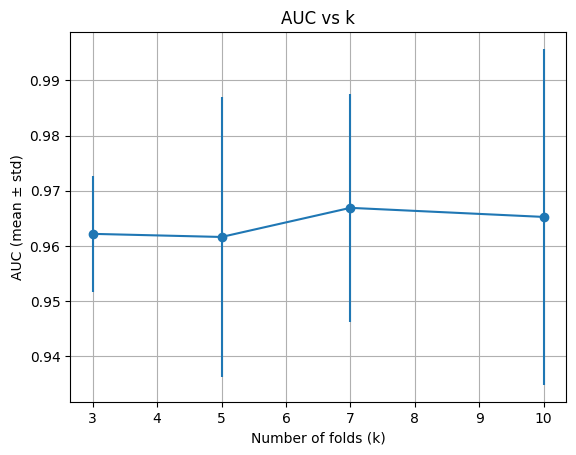

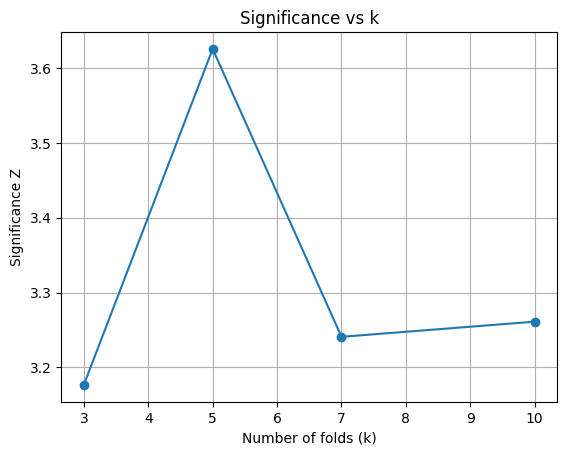

In [39]:
# Check for k-fold k number validation
def run_kfold_experiment(N_SPLITS, X_sep, y_sep, w_sep, m_sep, THRESHOLD):

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    oof_scores = np.zeros(len(y_sep))
    fold_aucs = []

    for train_idx, test_idx in skf.split(X_sep, y_sep):
        X_tr_full, X_te = X_sep[train_idx], X_sep[test_idx]
        y_tr_full, y_te = y_sep[train_idx], y_sep[test_idx]
        w_tr_full, w_te = w_sep[train_idx], w_sep[test_idx]

        # validation split
        X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
            X_tr_full, y_tr_full, w_tr_full,
            test_size=0.20, random_state=42, stratify=y_tr_full,
        )

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_val_s = scaler.transform(X_val)
        X_te_s = scaler.transform(X_te)

        scale_pos_weight = w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum()

        model = xgb.XGBClassifier(
            n_estimators=500, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric='auc', random_state=42, n_jobs=-1,
            tree_method='hist', early_stopping_rounds=20,
        )

        model.fit(
            X_tr_s, y_tr,
            sample_weight=w_tr,
            eval_set=[(X_val_s, y_val)],
            sample_weight_eval_set=[w_val],
            verbose=False,
        )

        oof_scores[test_idx] = model.predict_proba(X_te_s)[:, 1]

        fold_auc = roc_auc_score(y_te, oof_scores[test_idx], sample_weight=w_te)
        fold_aucs.append(fold_auc)

    # full AUC
    full_auc = roc_auc_score(y_sep, oof_scores, sample_weight=w_sep)

    # significance
    pass_mask = oof_scores > THRESHOLD
    sig_mask = (y_sep == 1)
    bkg_mask = (y_sep == 0)

    S_ml, sigma_S_ml = yields_in_window(
        m_sep[sig_mask & pass_mask], w_sep[sig_mask & pass_mask])
    B_ml, sigma_B_ml = yields_in_window(
        m_sep[bkg_mask & pass_mask], w_sep[bkg_mask & pass_mask])
    z_ml = significance_with_uncertainty(S_ml, B_ml, sigma_S_ml, sigma_B_ml)

    return {
        "k": N_SPLITS,
        "auc_mean": np.mean(fold_aucs),
        "auc_std": np.std(fold_aucs),
        "auc_full": full_auc,
        "Z": z_ml["Z"]
    }

k_values = [3, 5, 7, 10]
results = []

for k in k_values:
    print(f"Running k = {k}")
    res = run_kfold_experiment(k, X_sep, y_sep, w_sep, m_sep, THRESHOLD)
    results.append(res)

ks = [r["k"] for r in results]
auc_means = [r["auc_mean"] for r in results]
auc_stds = [r["auc_std"] for r in results]
Zs = [r["Z"] for r in results]

# --- AUC plot ---
plt.figure()
plt.errorbar(ks, auc_means, yerr=auc_stds, marker='o')
plt.xlabel("Number of folds (k)")
plt.ylabel("AUC (mean ± std)")
plt.title("AUC vs k")
plt.grid()
plt.show()

# --- Significance plot ---
plt.figure()
plt.plot(ks, Zs, marker='o')
plt.xlabel("Number of folds (k)")
plt.ylabel("Significance Z")
plt.title("Significance vs k")
plt.grid()
plt.show()

### 10.3 Seed-stability check *(paper §VIII.E)*

Re-run the XGBoost 5-fold OOF with 15 different seeds for both the fold
partitioning and the model initialisation; spread is < 0.005 in AUC and < 3 %
in significance.

Running seed = 0
Running seed = 1
Running seed = 2
Running seed = 3
Running seed = 4
Running seed = 5
Running seed = 10
Running seed = 20
Running seed = 42
Running seed = 100


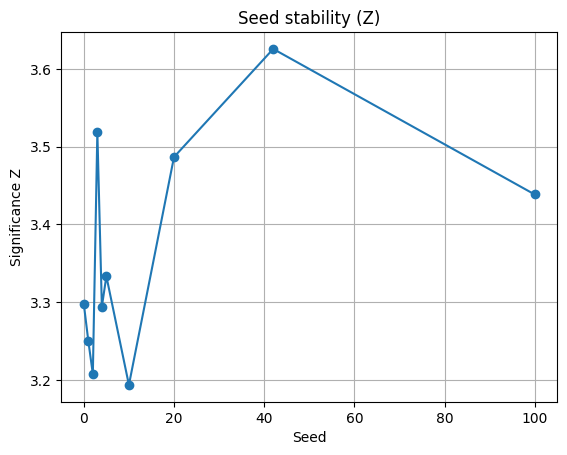

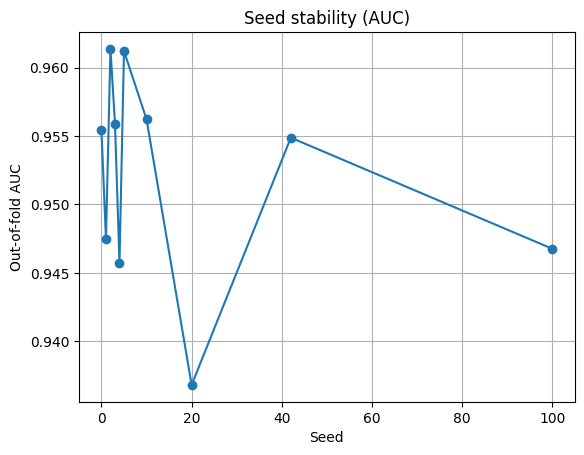


Seed stability results:
  Seed        AUC          Z
     0     0.9555     3.2974
     1     0.9475     3.2500
     2     0.9614     3.2075
     3     0.9559     3.5188
     4     0.9457     3.2942
     5     0.9612     3.3334
    10     0.9562     3.1936
    20     0.9368     3.4866
    42     0.9549     3.6257
   100     0.9468     3.4385

AUC  mean ± std: 0.9522 ± 0.0074
Z    mean ± std: 3.3646 ± 0.1378


In [40]:
def run_with_seed(seed, N_SPLITS, X_sep, y_sep, w_sep, m_sep, THRESHOLD):

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    oof_scores = np.zeros(len(y_sep))
    fold_aucs = []

    for train_idx, test_idx in skf.split(X_sep, y_sep):
        X_tr_full, X_te = X_sep[train_idx], X_sep[test_idx]
        y_tr_full, y_te = y_sep[train_idx], y_sep[test_idx]
        w_tr_full, w_te = w_sep[train_idx], w_sep[test_idx]

        X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
            X_tr_full, y_tr_full, w_tr_full,
            test_size=0.20, random_state=seed, stratify=y_tr_full,
        )

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_val_s = scaler.transform(X_val)
        X_te_s = scaler.transform(X_te)

        scale_pos_weight = w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum()

        model = xgb.XGBClassifier(
            n_estimators=500, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric='auc', random_state=seed, n_jobs=-1,
            tree_method='hist', early_stopping_rounds=20,
        )

        model.fit(
            X_tr_s, y_tr,
            sample_weight=w_tr,
            eval_set=[(X_val_s, y_val)],
            sample_weight_eval_set=[w_val],
            verbose=False,
        )

        oof_scores[test_idx] = model.predict_proba(X_te_s)[:, 1]

        fold_auc = roc_auc_score(y_te, oof_scores[test_idx], sample_weight=w_te)
        fold_aucs.append(fold_auc)

    full_auc = roc_auc_score(y_sep, oof_scores, sample_weight=w_sep)

    pass_mask = oof_scores > THRESHOLD
    sig_mask = (y_sep == 1)
    bkg_mask = (y_sep == 0)

    S_ml, sigma_S_ml = yields_in_window(
        m_sep[sig_mask & pass_mask], w_sep[sig_mask & pass_mask])
    B_ml, sigma_B_ml = yields_in_window(
        m_sep[bkg_mask & pass_mask], w_sep[bkg_mask & pass_mask])
    z_ml = significance_with_uncertainty(S_ml, B_ml, sigma_S_ml, sigma_B_ml)

    return {
        "seed": seed,
        "auc_mean": np.mean(fold_aucs),
        "auc_std": np.std(fold_aucs),
        "auc_full": full_auc,
        "Z": z_ml["Z"]
    }

seeds = [0, 1, 2, 3, 4, 5, 10, 20, 42, 100]
results_seed = []

for s in seeds:
    print(f"Running seed = {s}")
    res = run_with_seed(s, N_SPLITS, X_sep, y_sep, w_sep, m_sep, THRESHOLD)
    results_seed.append(res)

seeds = [r["seed"] for r in results_seed]
Zs = [r["Z"] for r in results_seed]
aucs = [r["auc_full"] for r in results_seed]

# --- Z vs seed ---
plt.figure()
plt.plot(seeds, Zs, marker='o')
plt.xlabel("Seed")
plt.ylabel("Significance Z")
plt.title("Seed stability (Z)")
plt.grid()
plt.show()

# --- AUC vs seed ---
plt.figure()
plt.plot(seeds, aucs, marker='o')
plt.xlabel("Seed")
plt.ylabel("Out-of-fold AUC")
plt.title("Seed stability (AUC)")
plt.grid()
plt.show()

print("\nSeed stability results:")
print("=" * 50)
print(f"{'Seed':>6} {'AUC':>10} {'Z':>10}")
print("=" * 50)

for r in results_seed:
    print(f"{r['seed']:>6} {r['auc_full']:>10.4f} {r['Z']:>10.4f}")

print("=" * 50)

# Summary stats

auc_vals = [r["auc_full"] for r in results_seed]
Z_vals   = [r["Z"] for r in results_seed]

print(f"\nAUC  mean ± std: {np.mean(auc_vals):.4f} ± {np.std(auc_vals):.4f}")
print(f"Z    mean ± std: {np.mean(Z_vals):.4f} ± {np.std(Z_vals):.4f}")

### 10.4 Score → significance: extract OOF arrays, threshold scan, optimal cut *(paper Fig. 8)*

Find the threshold on the OOF score that maximises the in-window
significance Z. The paper retains 0.65 as the working point — at the lower
edge of a broad plateau where enough surviving signal events remain.

In [41]:
# EXTRACT VARIABLES FOR THRESHOLD SCAN
oof_mc = xgb_result['oof']
y_mc = xgb_result['y']
w_mc = xgb_result['w']
m_mc = xgb_result['m']
# Also need X_mc for cross-validation - recreate it
X_mc, y_mc_check, w_mc_check, m_mc_check = build_ml_dataset_with_mass(keep_sep)

In [42]:
# ============================================================================
# PART 1: THRESHOLD SCAN ON MC ONLY - Choose optimal threshold
# ============================================================================
print("\n" + "="*70)
print("PART 1: THRESHOLD SCAN ON MC VALIDATION DATA")
print("="*70)

#WIN_LO, WIN_HI = 120.0, 130.0
WIN_LO, WIN_HI = 110.0, 135.0
thresholds = np.arange(0.1, 0.95, 0.05)
k_syst = 0.30

mc_scan_results = []

for thr in thresholds:
    # True Positives (signal correctly identified)
    sig_mask = (y_mc == 1) & (oof_mc > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
    S_mc = w_mc[sig_mask].sum()
    sigma_S = np.sqrt((w_mc[sig_mask]**2).sum())

    # False Positives (background misidentified as signal)
    bkg_mask = (y_mc == 0) & (oof_mc > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
    B_mc = w_mc[bkg_mask].sum()
    sigma_B = np.sqrt((w_mc[bkg_mask]**2).sum())

    if B_mc > 0:
        # Use S/√(B + k²B²) - measures signal significance over background fluctuations
        denom = B_mc + (k_syst * B_mc)**2
        Z_mc = S_mc / np.sqrt(denom)  # S-only for BDT performance

        # Error propagation for S/√(B + k²B²)
        term_S = sigma_S**2 / denom
        term_B = (S_mc**2 * (1 + 2*k_syst**2 * B_mc)**2 * sigma_B**2) / (4 * denom**3)
        sigma_Z = np.sqrt(term_S + term_B)
    else:
        Z_mc, sigma_Z = 0, 0

    mc_scan_results.append({
        'threshold': thr,
        'S_mc': S_mc,
        'B_mc': B_mc,
        'Z_mc': Z_mc,
        'sigma_Z': sigma_Z,
    })

# Find optimal threshold (maximize signal significance)
best_mc = max(mc_scan_results, key=lambda x: x['Z_mc'])
#OPTIMAL_THRESHOLD = best_mc['threshold']
OPTIMAL_THRESHOLD = 0.65

print(f"\n{'Threshold':>10} | {'True Positives':>14} | {'False Positives':>14} | {'Z (S/√B)':>10} | {'±σ':>8}")
print("-" * 70)
for r in mc_scan_results:
    print(f"{r['threshold']:>10.2f} | {r['S_mc']:>14.2f} | {r['B_mc']:>14.2f} | "
          f"{r['Z_mc']:>10.2f} | ±{r['sigma_Z']:>6.2f}")

print("-" * 70)
print(f"\n{'OPTIMAL':>10} | {best_mc['S_mc']:>14.2f} | {best_mc['B_mc']:>14.2f} | "
      f"{best_mc['Z_mc']:>10.2f} | ±{best_mc['sigma_Z']:>6.2f}")
print(f"\n>>> Selected threshold for real data: {OPTIMAL_THRESHOLD:.2f} <<<")
print("(This threshold maximizes S/√(B + k²B²) on MC validation data)")
print("="*70)


PART 1: THRESHOLD SCAN ON MC VALIDATION DATA

 Threshold | True Positives | False Positives |   Z (S/√B) |       ±σ
----------------------------------------------------------------------
      0.10 |          25.83 |          31.60 |       2.34 | ±  0.37
      0.15 |          25.83 |          31.23 |       2.37 | ±  0.37
      0.20 |          25.82 |          31.23 |       2.37 | ±  0.37
      0.25 |          25.80 |          30.72 |       2.40 | ±  0.38
      0.30 |          25.78 |          25.91 |       2.77 | ±  0.28
      0.35 |          25.75 |          25.91 |       2.77 | ±  0.27
      0.40 |          25.71 |          25.36 |       2.82 | ±  0.28
      0.45 |          25.65 |          23.72 |       2.97 | ±  0.30
      0.50 |          25.56 |          23.46 |       2.99 | ±  0.31
      0.55 |          25.44 |          21.56 |       3.19 | ±  0.33
      0.60 |          25.24 |          19.90 |       3.39 | ±  0.36
      0.65 |          24.86 |          17.96 |       3.63 | ±  0

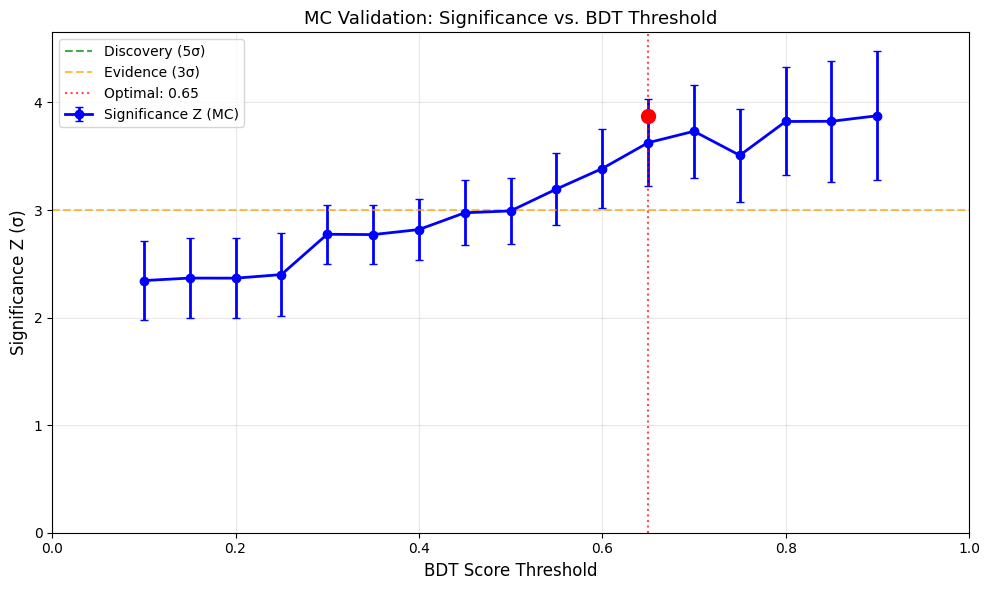

In [43]:
# ============================================================================
# PART 2: PLOT Z + errors vs thresholds (MC only)
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

thresholds_plot = [r['threshold'] for r in mc_scan_results]
z_values = [r['Z_mc'] for r in mc_scan_results]
z_errors = [r['sigma_Z'] for r in mc_scan_results]

ax.errorbar(thresholds_plot, z_values, yerr=z_errors,
            fmt='o-', color='blue', capsize=3, capthick=1,
            markersize=6, linewidth=2, label='Significance Z (MC)')

# Add discovery line
ax.axhline(5.0, color='green', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Discovery (5σ)')
ax.axhline(3.0, color='orange', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Evidence (3σ)')

# Mark optimal threshold
ax.axvline(OPTIMAL_THRESHOLD, color='red', linestyle=':', linewidth=1.5,
           alpha=0.7, label=f'Optimal: {OPTIMAL_THRESHOLD:.2f}')
ax.plot(OPTIMAL_THRESHOLD, best_mc['Z_mc'], 'ro', markersize=10)

ax.set_xlabel('BDT Score Threshold', fontsize=12)
ax.set_ylabel('Significance Z (σ)', fontsize=12)
ax.set_title('MC Validation: Significance vs. BDT Threshold', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, max(z_values) * 1.2)

plt.tight_layout()
plt.savefig("2.png", dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# ============================================================================
# FINAL: Apply the optimal threshold to real data
# ============================================================================
print("\n" + "="*60)
print(f"FINAL: Applying optimal threshold ({OPTIMAL_THRESHOLD:.2f}) to REAL DATA")
print("="*60)


FINAL: Applying optimal threshold (0.65) to REAL DATA


## 11. Other classifiers under the same 5-fold OOF protocol

Every model below follows the same recipe as XGBoost above: 5-fold stratified
CV, identical 20-feature input, OOF scoring, the same Eqs. 4–6 significance
calculation in the m_4l ∈ [110, 135) GeV window, and a threshold scan from
0.10 to 0.95. Class imbalance is handled per paper §VIII.B: `scale_pos_weight`
for boosted trees, class-balanced sample weights for RF / MLP / LogReg, native
sample weights for GaussianNB, and weighted-bootstrap resampling for QDA.

### 11.1 Gaussian Naive Bayes *(paper §VIII.C.5)*

  GNB fold 1/5 AUC=0.9376   [t=0.2s]
  GNB fold 2/5 AUC=0.8443   [t=0.5s]
  GNB fold 3/5 AUC=0.9372   [t=0.7s]
  GNB fold 4/5 AUC=0.9238   [t=1.0s]
  GNB fold 5/5 AUC=0.8939   [t=1.2s]

GaussianNB results:
AUC = 0.9013   mean±std = 0.9074 ± 0.0353
Best threshold = 0.55, Z = 4.323


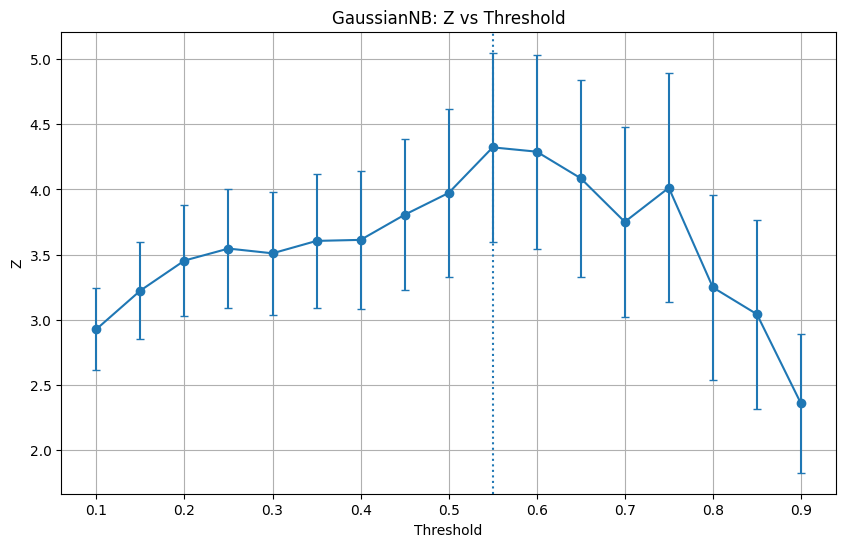

In [45]:
# ============================================================================
# GAUSSIAN NB: OOF + THRESHOLD SCAN
# ============================================================================

CC_K          = 5
CC_KFOLD_SEED = 42
WIN_LO, WIN_HI = 110.0, 135.0
thresholds = np.arange(0.1, 0.95, 0.05)
k_syst = 0.30

# --- OOF predictions ---
skf = StratifiedKFold(n_splits=CC_K, shuffle=True, random_state=CC_KFOLD_SEED)
oof_gnb = np.zeros(len(y_mc))
fold_aucs = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):

    X_tr, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr, w_te = w_mc[tr_idx], w_mc[te_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    clf = GaussianNB()
    clf.fit(X_tr_s, y_tr, sample_weight=w_tr)

    oof_gnb[te_idx] = clf.predict_proba(X_te_s)[:, 1]

    auc = roc_auc_score(y_te, oof_gnb[te_idx], sample_weight=w_te)
    fold_aucs.append(auc)

    print(f'  GNB fold {fold_idx+1}/{CC_K} AUC={auc:.4f}   [t={time.time()-t0:.1f}s]')

full_auc = roc_auc_score(y_mc, oof_gnb, sample_weight=w_mc)

# --- threshold scan ---
results = []

for thr in thresholds:
    sig_mask = (y_mc == 1) & (oof_gnb > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
    bkg_mask = (y_mc == 0) & (oof_gnb > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)

    S = w_mc[sig_mask].sum()
    B = w_mc[bkg_mask].sum()

    sigma_S = np.sqrt((w_mc[sig_mask]**2).sum())
    sigma_B = np.sqrt((w_mc[bkg_mask]**2).sum())

    if B > 0:
        denom = B + (k_syst * B)**2
        Z = S / np.sqrt(denom)

        term_S = sigma_S**2 / denom
        term_B = (S**2 * (1 + 2*k_syst**2 * B)**2 * sigma_B**2) / (4 * denom**3)
        sigma_Z = np.sqrt(term_S + term_B)
    else:
        Z, sigma_Z = 0, 0

    results.append({'threshold': thr, 'Z': Z, 'sigma_Z': sigma_Z})

best = max(results, key=lambda x: x['Z'])

print("\nGaussianNB results:")
print(f"AUC = {full_auc:.4f}   mean±std = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Best threshold = {best['threshold']:.2f}, Z = {best['Z']:.3f}")

# --- plot ---
plt.figure(figsize=(10,6))
plt.errorbar(
    [r['threshold'] for r in results],
    [r['Z'] for r in results],
    yerr=[r['sigma_Z'] for r in results],
    fmt='o-', capsize=3
)
plt.axvline(best['threshold'], linestyle=':')
plt.xlabel("Threshold")
plt.ylabel("Z")
plt.title("GaussianNB: Z vs Threshold")
plt.grid()
plt.show()

### 11.2 Quadratic Discriminant Analysis *(paper §VIII.C.5)*

  QDA fold 1/5 AUC=0.9459   [t=0.7s]
  QDA fold 2/5 AUC=0.8494   [t=1.6s]
  QDA fold 3/5 AUC=0.9447   [t=2.0s]
  QDA fold 4/5 AUC=0.9499   [t=2.4s]
  QDA fold 5/5 AUC=0.9316   [t=2.8s]

QDA results:
AUC = 0.9199   mean±std = 0.9243 ± 0.0380
Best threshold = 0.15, Z = 3.630


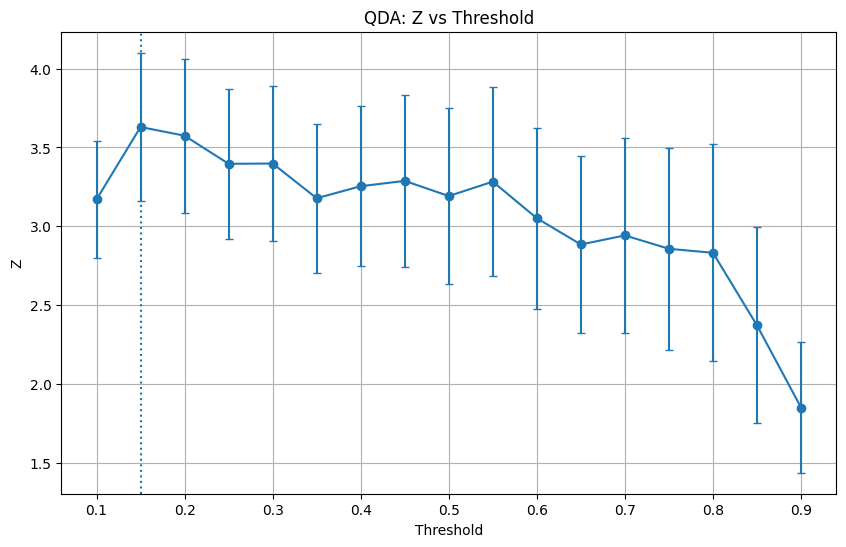

In [46]:
# ============================================================================
# QDA: OOF + THRESHOLD SCAN (weighted bootstrap)
# ============================================================================

CC_K          = 5
CC_KFOLD_SEED = 42
WIN_LO, WIN_HI = 110.0, 135.0
thresholds = np.arange(0.1, 0.95, 0.05)
k_syst = 0.30

skf = StratifiedKFold(n_splits=CC_K, shuffle=True, random_state=CC_KFOLD_SEED)
oof_qda = np.zeros(len(y_mc))
fold_aucs = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):

    X_tr, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr, w_te = w_mc[tr_idx], w_mc[te_idx]

    # weighted bootstrap
    rng = np.random.default_rng(CC_KFOLD_SEED + fold_idx)
    p = w_tr / w_tr.sum()
    idx = rng.choice(len(y_tr), size=len(y_tr), replace=True, p=p)

    X_tr_res = X_tr[idx]
    y_tr_res = y_tr[idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_res)
    X_te_s = scaler.transform(X_te)

    clf = QuadraticDiscriminantAnalysis(reg_param=0.1)
    clf.fit(X_tr_s, y_tr_res)

    oof_qda[te_idx] = clf.predict_proba(X_te_s)[:, 1]

    auc = roc_auc_score(y_te, oof_qda[te_idx], sample_weight=w_te)
    fold_aucs.append(auc)

    print(f'  QDA fold {fold_idx+1}/{CC_K} AUC={auc:.4f}   [t={time.time()-t0:.1f}s]')

full_auc = roc_auc_score(y_mc, oof_qda, sample_weight=w_mc)

# --- threshold scan ---
results = []

for thr in thresholds:
    sig_mask = (y_mc == 1) & (oof_qda > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
    bkg_mask = (y_mc == 0) & (oof_qda > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)

    S = w_mc[sig_mask].sum()
    B = w_mc[bkg_mask].sum()

    sigma_S = np.sqrt((w_mc[sig_mask]**2).sum())
    sigma_B = np.sqrt((w_mc[bkg_mask]**2).sum())

    if B > 0:
        denom = B + (k_syst * B)**2
        Z = S / np.sqrt(denom)

        term_S = sigma_S**2 / denom
        term_B = (S**2 * (1 + 2*k_syst**2 * B)**2 * sigma_B**2) / (4 * denom**3)
        sigma_Z = np.sqrt(term_S + term_B)
    else:
        Z, sigma_Z = 0, 0

    results.append({'threshold': thr, 'Z': Z, 'sigma_Z': sigma_Z})

best = max(results, key=lambda x: x['Z'])

print("\nQDA results:")
print(f"AUC = {full_auc:.4f}   mean±std = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Best threshold = {best['threshold']:.2f}, Z = {best['Z']:.3f}")

# --- plot ---
plt.figure(figsize=(10,6))
plt.errorbar(
    [r['threshold'] for r in results],
    [r['Z'] for r in results],
    yerr=[r['sigma_Z'] for r in results],
    fmt='o-', capsize=3
)
plt.axvline(best['threshold'], linestyle=':')
plt.xlabel("Threshold")
plt.ylabel("Z")
plt.title("QDA: Z vs Threshold")
plt.grid()
plt.show()

### 11.3 Logistic Regression *(paper §VIII.C.4)*

Tuning C via inner 3-fold CV on training data...
  C=0.001  ->  inner AUC = 0.8751
  C=0.010  ->  inner AUC = 0.8979
  C=0.100  ->  inner AUC = 0.9078
  C=1.000  ->  inner AUC = 0.9107
  C=10.000  ->  inner AUC = 0.9114
  C=100.000  ->  inner AUC = 0.9115

Best C = 100.0  (inner AUC = 0.9115)
  LogReg fold 1/5  AUC=0.9419   [t=  1.0s]
  LogReg fold 2/5  AUC=0.8649   [t=  2.1s]
  LogReg fold 3/5  AUC=0.9253   [t=  2.9s]
  LogReg fold 4/5  AUC=0.9250   [t=  3.7s]
  LogReg fold 5/5  AUC=0.9032   [t=  4.4s]

LogReg score distribution:
  Signal:     p10=0.567  p50=0.877  p90=0.968
  Background: p10=0.000  p50=0.062  p90=0.760

Logistic Regression results:
AUC = 0.9091   mean±std = 0.9121 ± 0.0266
Best threshold (raw peak) = 0.80,  Z = 3.203,  S = 17.65,  B = 13.63

   thr        S        B        Z    sig_eff
--------------------------------------------------
  0.10    25.83    31.95     2.32    100.00%
  0.15    25.81    31.95     2.32     99.92%
  0.20    25.76    31.94     2.32     99.72

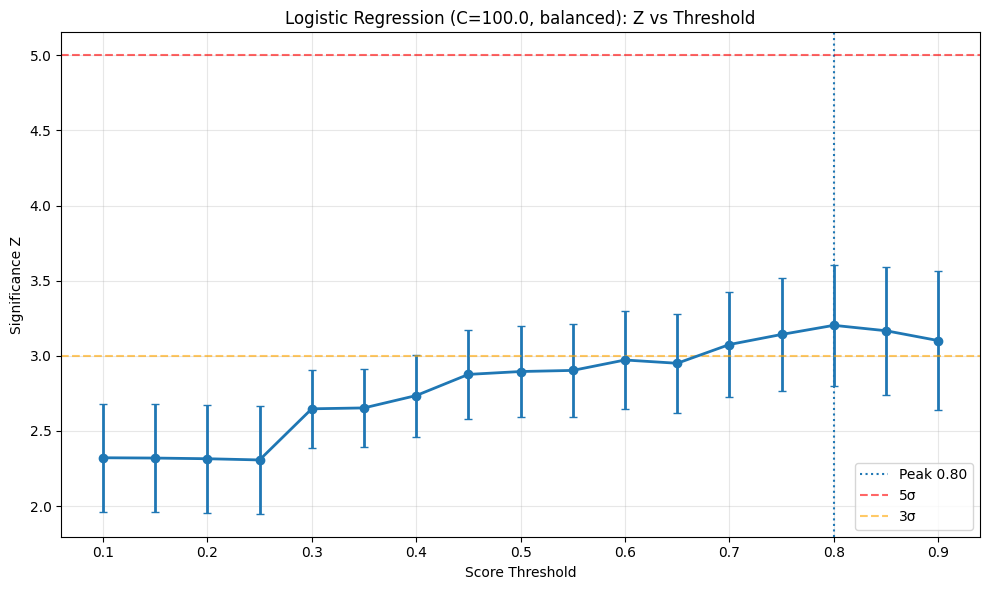

In [47]:
# ============================================================================
# LOGISTIC REGRESSION (BALANCED): OOF + THRESHOLD SCAN
# ============================================================================

CC_K          = 5
CC_KFOLD_SEED = 42
WIN_LO, WIN_HI = 110.0, 135.0
thresholds = np.arange(0.1, 0.95, 0.05)
k_syst = 0.30

if 'X_mc' not in dir() or 'm_mc' not in dir():
    X_mc, y_mc, w_mc, m_mc = build_ml_dataset_with_mass(keep_sep)

# ----------------------------------------------------------------------------
# Helper: build class-balanced sample weights (signal scaled up to match bkg)
# ----------------------------------------------------------------------------
def make_balanced_weights(y, w):
    w_bal = w.copy()
    spw = w[y == 0].sum() / w[y == 1].sum()
    w_bal[y == 1] *= spw
    return w_bal

# ----------------------------------------------------------------------------
# Inner-CV C tuning (uses training data only — no leak)
# ----------------------------------------------------------------------------
C_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

print("Tuning C via inner 3-fold CV on training data...")
inner_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=CC_KFOLD_SEED)
c_aucs = []
for C in C_grid:
    fold_aucs_inner = []
    for tr_idx, te_idx in inner_skf.split(X_mc, y_mc):
        X_tr_i, X_te_i = X_mc[tr_idx], X_mc[te_idx]
        y_tr_i, y_te_i = y_mc[tr_idx], y_mc[te_idx]
        w_tr_i, w_te_i = w_mc[tr_idx], w_mc[te_idx]

        scaler_i  = StandardScaler()
        X_tr_i_s  = scaler_i.fit_transform(X_tr_i)
        X_te_i_s  = scaler_i.transform(X_te_i)

        # Class balance the inner-CV training weights
        w_tr_i_bal = make_balanced_weights(y_tr_i, w_tr_i)

        clf_i = LogisticRegression(
            C=C, max_iter=2000, solver='lbfgs', random_state=42,
        )
        clf_i.fit(X_tr_i_s, y_tr_i, sample_weight=w_tr_i_bal)
        proba_i = clf_i.predict_proba(X_te_i_s)[:, 1]
        # Use raw weights for AUC evaluation (physics-correct yields)
        fold_aucs_inner.append(roc_auc_score(y_te_i, proba_i, sample_weight=w_te_i))

    mean_auc = np.mean(fold_aucs_inner)
    c_aucs.append(mean_auc)
    print(f"  C={C:.3f}  ->  inner AUC = {mean_auc:.4f}")

best_C = C_grid[np.argmax(c_aucs)]
print(f"\nBest C = {best_C}  (inner AUC = {max(c_aucs):.4f})")

# ----------------------------------------------------------------------------
# Outer 5-fold OOF predictions with best C
# ----------------------------------------------------------------------------
skf        = StratifiedKFold(n_splits=CC_K, shuffle=True, random_state=CC_KFOLD_SEED)
oof_logreg = np.zeros(len(y_mc))
fold_aucs  = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):

    X_tr, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr, w_te = w_mc[tr_idx], w_mc[te_idx]

    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr)
    X_te_s   = scaler.transform(X_te)

    # Class-balance training weights
    w_tr_bal = make_balanced_weights(y_tr, w_tr)

    clf = LogisticRegression(
        C            = best_C,
        max_iter     = 2000,
        solver       = 'lbfgs',
        random_state = 42,
    )
    clf.fit(X_tr_s, y_tr, sample_weight=w_tr_bal)

    oof_logreg[te_idx] = clf.predict_proba(X_te_s)[:, 1]

    auc = roc_auc_score(y_te, oof_logreg[te_idx], sample_weight=w_te)
    fold_aucs.append(auc)
    print(f'  LogReg fold {fold_idx+1}/{CC_K}  AUC={auc:.4f}   [t={time.time()-t0:5.1f}s]')

oof_auc_logreg = roc_auc_score(y_mc, oof_logreg, sample_weight=w_mc)

# ----------------------------------------------------------------------------
# Score distribution diagnostic (helpful for choosing threshold range)
# ----------------------------------------------------------------------------
print(f"\nLogReg score distribution:")
print(f"  Signal:     p10={np.percentile(oof_logreg[y_mc==1], 10):.3f}  "
      f"p50={np.percentile(oof_logreg[y_mc==1], 50):.3f}  "
      f"p90={np.percentile(oof_logreg[y_mc==1], 90):.3f}")
print(f"  Background: p10={np.percentile(oof_logreg[y_mc==0], 10):.3f}  "
      f"p50={np.percentile(oof_logreg[y_mc==0], 50):.3f}  "
      f"p90={np.percentile(oof_logreg[y_mc==0], 90):.3f}")

# ----------------------------------------------------------------------------
# Threshold scan
# ----------------------------------------------------------------------------
results = []
for thr in thresholds:
    sig_mask = (y_mc == 1) & (oof_logreg > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
    bkg_mask = (y_mc == 0) & (oof_logreg > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)

    S = w_mc[sig_mask].sum()
    B = w_mc[bkg_mask].sum()
    sigma_S = np.sqrt((w_mc[sig_mask]**2).sum())
    sigma_B = np.sqrt((w_mc[bkg_mask]**2).sum())

    if B > 0:
        denom   = B + (k_syst * B)**2
        Z       = S / np.sqrt(denom)
        term_S  = sigma_S**2 / denom
        term_B  = (S**2 * (1 + 2*k_syst**2 * B)**2 * sigma_B**2) / (4 * denom**3)
        sigma_Z = np.sqrt(term_S + term_B)
    else:
        Z, sigma_Z = 0.0, 0.0

    results.append({
        'threshold': thr, 'Z': Z, 'sigma_Z': sigma_Z, 'S': S, 'B': B,
    })

best = max(results, key=lambda x: x['Z'])

print(f"\nLogistic Regression results:")
print(f"AUC = {oof_auc_logreg:.4f}   mean±std = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Best threshold (raw peak) = {best['threshold']:.2f},  Z = {best['Z']:.3f},  "
      f"S = {best['S']:.2f},  B = {best['B']:.2f}")

# Diagnostic table
S_max = max(r['S'] for r in results)
print(f"\n{'thr':>6} {'S':>8} {'B':>8} {'Z':>8} {'sig_eff':>10}")
print("-" * 50)
for r in results:
    eff = r['S'] / S_max if S_max > 0 else 0
    print(f"{r['threshold']:>6.2f} {r['S']:>8.2f} {r['B']:>8.2f} "
          f"{r['Z']:>8.2f} {eff:>10.2%}")

# ----------------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.errorbar(
    [r['threshold'] for r in results],
    [r['Z']         for r in results],
    yerr=[r['sigma_Z'] for r in results],
    fmt='o-', capsize=3, linewidth=2,
)
plt.axvline(best['threshold'], linestyle=':', label=f"Peak {best['threshold']:.2f}")
plt.axhline(5.0, linestyle='--', color='red',    alpha=0.6, label='5σ')
plt.axhline(3.0, linestyle='--', color='orange', alpha=0.6, label='3σ')
plt.xlabel("Score Threshold")
plt.ylabel("Significance Z")
plt.title(f"Logistic Regression (C={best_C}, balanced): Z vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 11.4 Multilayer Perceptron *(paper §VIII.C.3)*

  MLP fold 1/5  AUC=0.9774   epochs=13   [t= 35.3s]
  MLP fold 2/5  AUC=0.9081   epochs=23   [t= 84.7s]
  MLP fold 3/5  AUC=0.9771   epochs=13   [t=116.1s]
  MLP fold 4/5  AUC=0.9671   epochs=11   [t=141.2s]
  MLP fold 5/5  AUC=0.9256   epochs=11   [t=166.1s]

Keras MLP results:
AUC = 0.9393   mean±std = 0.9510 ± 0.0287
Best threshold = 0.90, Z = 3.365


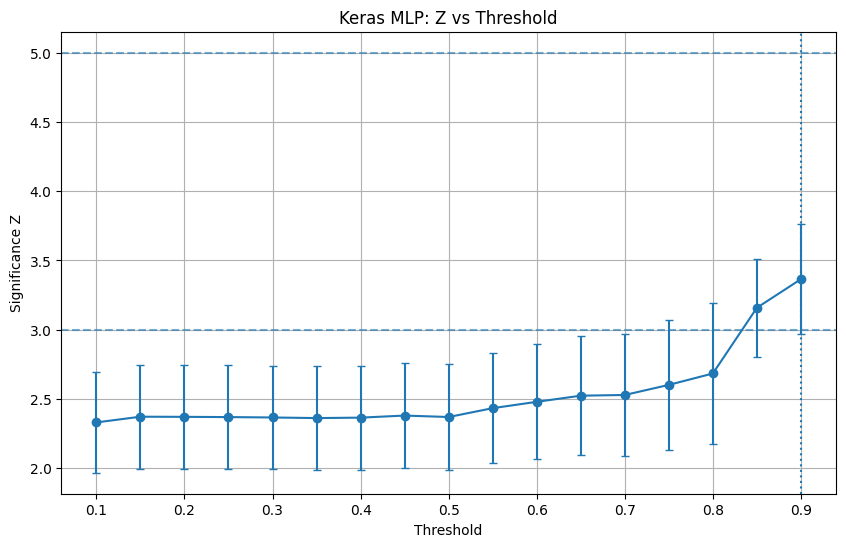

In [48]:
# ============================================================================
# KERAS MLP (WEIGHTED): OOF + THRESHOLD SCAN (XGBoost-style)
# ============================================================================

# ----------------------------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------------------------
CC_K          = 5
CC_KFOLD_SEED = 42
WIN_LO, WIN_HI = 110.0, 135.0

thresholds = np.arange(0.1, 0.95, 0.05)
k_syst = 0.30

MLP_EPOCHS     = 100
MLP_BATCH_SIZE = 256
MLP_LR         = 1e-3
MLP_PATIENCE   = 10

# ----------------------------------------------------------------------------
# BUILD MODEL
# ----------------------------------------------------------------------------
def build_mlp(n_features, seed):
    tf.keras.utils.set_random_seed(seed)
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(32,  activation='relu'),
        Dense(1,   activation='sigmoid'),
    ])
    model.compile(
        optimizer=Adam(learning_rate=MLP_LR),
        loss='binary_crossentropy'
    )
    return model

# ----------------------------------------------------------------------------
# DATA
# ----------------------------------------------------------------------------
if 'X_mc' not in dir() or 'm_mc' not in dir():
    X_mc, y_mc, w_mc, m_mc = build_ml_dataset_with_mass(keep_sep)

# ----------------------------------------------------------------------------
# OOF TRAINING
# ----------------------------------------------------------------------------
skf = StratifiedKFold(n_splits=CC_K, shuffle=True, random_state=CC_KFOLD_SEED)
oof_mlp = np.zeros(len(y_mc))
fold_aucs = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):

    X_tr_full, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr_full, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr_full, w_te = w_mc[tr_idx], w_mc[te_idx]

    # --- validation split ---
    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_tr_full, y_tr_full, w_tr_full,
        test_size=0.20,
        stratify=y_tr_full,
        random_state=CC_KFOLD_SEED
    )

    # --- class-balanced weights ---
    spw = w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum()

    w_tr_bal = w_tr.copy()
    w_tr_bal[y_tr == 1] *= spw

    w_val_bal = w_val.copy()
    w_val_bal[y_val == 1] *= spw

    # --- scaling ---
    scaler = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)
    X_te_s  = scaler.transform(X_te)

    # --- model ---
    model = build_mlp(X_tr_s.shape[1], seed=42 + fold_idx)

    es = EarlyStopping(
        monitor='val_loss',
        patience=MLP_PATIENCE,
        restore_best_weights=True,
        verbose=0
    )

    hist = model.fit(
        X_tr_s, y_tr,
        sample_weight   = w_tr_bal,
        validation_data = (X_val_s, y_val, w_val_bal),
        epochs          = MLP_EPOCHS,
        batch_size      = MLP_BATCH_SIZE,
        callbacks       = [es],
        verbose         = 0,
    )

    oof_mlp[te_idx] = model.predict(X_te_s, batch_size=4096, verbose=0).ravel()

    auc = roc_auc_score(y_te, oof_mlp[te_idx], sample_weight=w_te)
    fold_aucs.append(auc)

    print(f'  MLP fold {fold_idx+1}/{CC_K}  AUC={auc:.4f}   '
          f'epochs={len(hist.history["loss"])}   '
          f'[t={time.time()-t0:5.1f}s]')

# ----------------------------------------------------------------------------
# GLOBAL AUC
# ----------------------------------------------------------------------------
oof_auc_mlp = roc_auc_score(y_mc, oof_mlp, sample_weight=w_mc)

# ----------------------------------------------------------------------------
# THRESHOLD SCAN (same as XGBoost)
# ----------------------------------------------------------------------------
results = []

for thr in thresholds:

    sig_mask = (y_mc == 1) & (oof_mlp > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
    bkg_mask = (y_mc == 0) & (oof_mlp > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)

    S = w_mc[sig_mask].sum()
    B = w_mc[bkg_mask].sum()

    sigma_S = np.sqrt((w_mc[sig_mask]**2).sum())
    sigma_B = np.sqrt((w_mc[bkg_mask]**2).sum())

    if B > 0:
        denom = B + (k_syst * B)**2
        Z = S / np.sqrt(denom)

        term_S = sigma_S**2 / denom
        term_B = (S**2 * (1 + 2*k_syst**2 * B)**2 * sigma_B**2) / (4 * denom**3)
        sigma_Z = np.sqrt(term_S + term_B)
    else:
        Z, sigma_Z = 0, 0

    results.append({
        'threshold': thr,
        'Z': Z,
        'sigma_Z': sigma_Z
    })

best = max(results, key=lambda x: x['Z'])

print("\nKeras MLP results:")
print(f"AUC = {oof_auc_mlp:.4f}   mean±std = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Best threshold = {best['threshold']:.2f}, Z = {best['Z']:.3f}")

# ----------------------------------------------------------------------------
# PLOT
# ----------------------------------------------------------------------------
plt.figure(figsize=(10,6))

plt.errorbar(
    [r['threshold'] for r in results],
    [r['Z'] for r in results],
    yerr=[r['sigma_Z'] for r in results],
    fmt='o-', capsize=3
)

plt.axvline(best['threshold'], linestyle=':')
plt.axhline(5.0, linestyle='--', alpha=0.6)
plt.axhline(3.0, linestyle='--', alpha=0.6)

plt.xlabel("Threshold")
plt.ylabel("Significance Z")
plt.title("Keras MLP: Z vs Threshold")
plt.grid()

plt.show()

### 11.5 Random Forest *(paper §VIII.C.2)*

  RF fold 1/5  AUC=0.9746   [t=118.4s]
  RF fold 2/5  AUC=0.9393   [t=235.0s]
  RF fold 3/5  AUC=0.9791   [t=358.9s]
  RF fold 4/5  AUC=0.9716   [t=478.2s]
  RF fold 5/5  AUC=0.9153   [t=593.3s]

Random Forest results:
AUC = 0.9541   mean±std = 0.9560 ± 0.0247
Best threshold = 0.85,  Z = 5.994,  S = 13.10,  B = 3.60


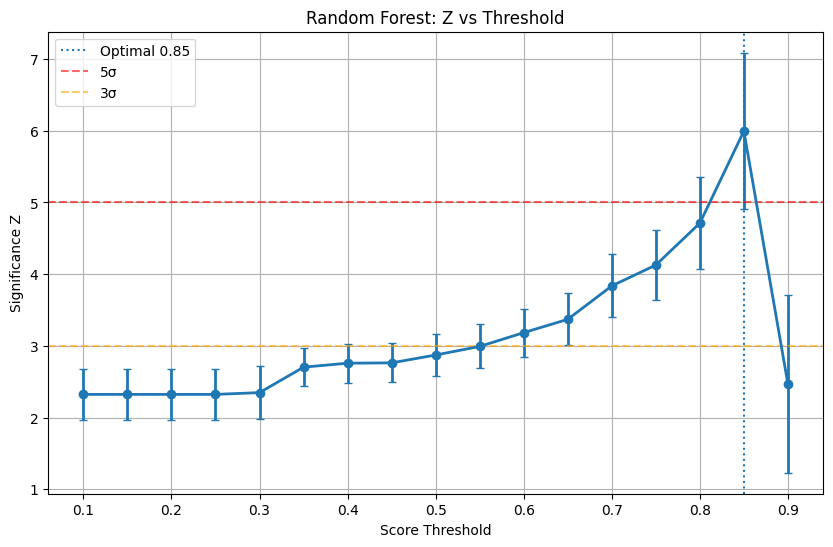

In [49]:
# ============================================================================
# RANDOM FOREST: OOF + THRESHOLD SCAN
# ============================================================================

CC_K          = 5
CC_KFOLD_SEED = 42
WIN_LO, WIN_HI = 110.0, 135.0
thresholds = np.arange(0.1, 0.95, 0.05)
k_syst = 0.30

if 'X_mc' not in dir() or 'm_mc' not in dir():
    X_mc, y_mc, w_mc, m_mc = build_ml_dataset_with_mass(keep_sep)

skf = StratifiedKFold(n_splits=CC_K, shuffle=True, random_state=CC_KFOLD_SEED)
oof_rf    = np.zeros(len(y_mc))
fold_aucs = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):

    X_tr, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr, w_te = w_mc[tr_idx], w_mc[te_idx]

    # Scale signal weights to match background total — same as plot_rf_importance
    w_scaled = w_tr.copy()
    w_scaled[y_tr == 1] *= (w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum())

    # Fit on raw features (RF is scale-invariant, no StandardScaler needed)
    clf = RandomForestClassifier(
        n_estimators     = 300,
        max_depth        = 5,
        min_samples_leaf = 5,   # reduces overfitting on tiny signal
        n_jobs           = -1,
        random_state     = 42,
    )
    clf.fit(X_tr, y_tr, sample_weight=w_scaled)

    # Predict on raw features — consistent with fit (no scaler)
    oof_rf[te_idx] = clf.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, oof_rf[te_idx], sample_weight=w_te)
    fold_aucs.append(auc)
    print(f'  RF fold {fold_idx+1}/{CC_K}  AUC={auc:.4f}   [t={time.time()-t0:5.1f}s]')

oof_auc_rf = roc_auc_score(y_mc, oof_rf, sample_weight=w_mc)

# --- threshold scan ---
results = []
for thr in thresholds:
    sig_mask = (y_mc == 1) & (oof_rf > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
    bkg_mask = (y_mc == 0) & (oof_rf > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)

    S = w_mc[sig_mask].sum()
    B = w_mc[bkg_mask].sum()

    sigma_S = np.sqrt((w_mc[sig_mask]**2).sum())
    sigma_B = np.sqrt((w_mc[bkg_mask]**2).sum())

    if B > 0:
        denom   = B + (k_syst * B)**2
        Z       = S / np.sqrt(denom)
        term_S  = sigma_S**2 / denom
        term_B  = (S**2 * (1 + 2*k_syst**2 * B)**2 * sigma_B**2) / (4 * denom**3)
        sigma_Z = np.sqrt(term_S + term_B)
    else:
        Z, sigma_Z = 0.0, 0.0

    results.append({'threshold': thr, 'Z': Z, 'sigma_Z': sigma_Z, 'S': S, 'B': B})

best = max(results, key=lambda x: x['Z'])

print(f"\nRandom Forest results:")
print(f"AUC = {oof_auc_rf:.4f}   mean±std = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Best threshold = {best['threshold']:.2f},  Z = {best['Z']:.3f},  "
      f"S = {best['S']:.2f},  B = {best['B']:.2f}")

# --- plot ---
plt.figure(figsize=(10, 6))
plt.errorbar(
    [r['threshold'] for r in results],
    [r['Z']         for r in results],
    yerr=[r['sigma_Z'] for r in results],
    fmt='o-', capsize=3, linewidth=2
)
plt.axvline(best['threshold'], linestyle=':', label=f"Optimal {best['threshold']:.2f}")
plt.axhline(5.0, linestyle='--', color='red',    alpha=0.6, label='5σ')
plt.axhline(3.0, linestyle='--', color='orange', alpha=0.6, label='3σ')
plt.xlabel("Score Threshold")
plt.ylabel("Significance Z")
plt.title("Random Forest: Z vs Threshold")
plt.legend()
plt.grid()
plt.show()

### 11.6 LightGBM *(paper §VIII.C.1)*

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB fold 1/5  AUC=0.9741   best_iter=18   [t=  1.6s]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB fold 2/5  AUC=0.9469   best_iter=180   [t=  6.8s]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB fold 3/5  AUC=0.9846   best_iter=133   [t=  9.9s]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB fold 4/5  AUC=0.9807   best_iter=172   [t= 13.7s]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB fold 5/5  AUC=0.9302   best_iter=46   [t= 17.1s]

LightGBM results:
AUC = 0.9541   mean±std = 0.9633 ± 0.0211
Best threshold (raw peak) = 0.85,  Z = 4.038,  S = 17.10,  B = 9.61

   thr        S        B        Z    sig_eff
--------------------------------------------------
  0.10    25.82    31.12     2.37    100.00%
  0.15    25.80    26.33     2.74     99.92%
  0.20    25.77    25.72     2.79     99.80%
  0.25    25.73    25.07     2.85     99.62%
  0.30    25.67    23.43     3.01     99.41%
  0.35    25.59    22.99     3.05     99.09%
  0.40    25.42    21.94     3.15     98.44%
  0.45    25.33    21.88     3.14     98.10%
  0.50    25.15    20.97     3.23     97.40%
  0.55    24.63    19.76     3.32     95.39%
  0.60    22.74    18.36     3.26     88.07%
  0.65    20.09    15.13     3.36     77.78%
  0.70    19.91    14.75     3.40     77.11%
  0.75    19.66    13.44     3.61     76.11%
  0.80    19.14    11.44     3.97     74.13%
  0.85    17.10     9.61     4.04     66.21%

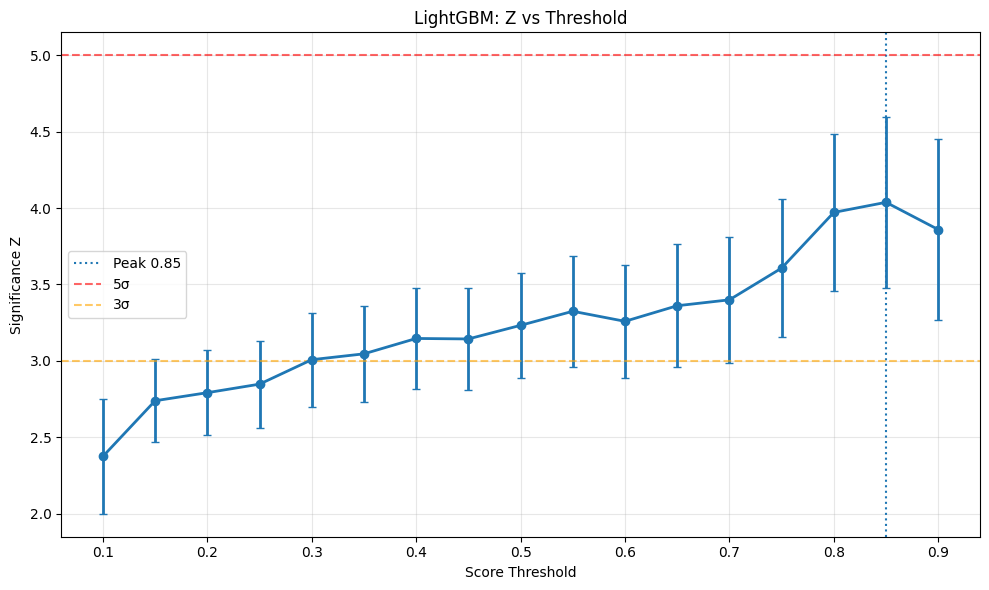

In [50]:
# ============================================================================
# LIGHTGBM: OOF + THRESHOLD SCAN
# ============================================================================

CC_K          = 5
CC_KFOLD_SEED = 42
WIN_LO, WIN_HI = 110.0, 135.0
thresholds = np.arange(0.1, 0.95, 0.05)
k_syst = 0.30

if 'X_mc' not in dir() or 'm_mc' not in dir():
    X_mc, y_mc, w_mc, m_mc = build_ml_dataset_with_mass(keep_sep)

skf = StratifiedKFold(n_splits=CC_K, shuffle=True, random_state=CC_KFOLD_SEED)
oof_lgb   = np.zeros(len(y_mc))
fold_aucs = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):

    X_tr_full, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr_full, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr_full, w_te = w_mc[tr_idx], w_mc[te_idx]

    # Internal validation split for early stopping
    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_tr_full, y_tr_full, w_tr_full,
        test_size=0.20, random_state=CC_KFOLD_SEED, stratify=y_tr_full,
    )

    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)
    X_te_s  = scaler.transform(X_te)

    # Class-balance via scale_pos_weight (matches your XGBoost setup)
    spw = w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum()

    clf = lgb.LGBMClassifier(
        n_estimators       = 500,
        max_depth          = 4,
        num_leaves          = 15,        # ~ 2^max_depth - 1
        learning_rate      = 0.05,
        subsample          = 0.8,
        subsample_freq     = 1,          # required for subsample to take effect
        colsample_bytree   = 0.8,
        min_child_samples  = 20,
        reg_lambda         = 1.0,
        reg_alpha          = 0.0,
        scale_pos_weight   = spw,
        objective          = 'binary',
        metric             = 'auc',
        random_state       = 42,
        n_jobs             = -1,
        verbose            = -1,
    )
    clf.fit(
        X_tr_s, y_tr,
        sample_weight  = w_tr,
        eval_set       = [(X_val_s, y_val)],
        eval_sample_weight = [w_val],
        callbacks      = [lgb.early_stopping(stopping_rounds=20, verbose=False)],
    )

    oof_lgb[te_idx] = clf.predict_proba(X_te_s)[:, 1]

    auc = roc_auc_score(y_te, oof_lgb[te_idx], sample_weight=w_te)
    fold_aucs.append(auc)
    print(f'  LGB fold {fold_idx+1}/{CC_K}  AUC={auc:.4f}   '
          f'best_iter={clf.best_iteration_}   '
          f'[t={time.time()-t0:5.1f}s]')

oof_auc_lgb = roc_auc_score(y_mc, oof_lgb, sample_weight=w_mc)

# --- threshold scan (with S, B stored for proper threshold picking) ---
results = []
for thr in thresholds:
    sig_mask = (y_mc == 1) & (oof_lgb > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
    bkg_mask = (y_mc == 0) & (oof_lgb > thr) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)

    S = w_mc[sig_mask].sum()
    B = w_mc[bkg_mask].sum()
    sigma_S = np.sqrt((w_mc[sig_mask]**2).sum())
    sigma_B = np.sqrt((w_mc[bkg_mask]**2).sum())

    if B > 0:
        denom   = B + (k_syst * B)**2
        Z       = S / np.sqrt(denom)
        term_S  = sigma_S**2 / denom
        term_B  = (S**2 * (1 + 2*k_syst**2 * B)**2 * sigma_B**2) / (4 * denom**3)
        sigma_Z = np.sqrt(term_S + term_B)
    else:
        Z, sigma_Z = 0.0, 0.0

    results.append({
        'threshold': thr, 'Z': Z, 'sigma_Z': sigma_Z, 'S': S, 'B': B,
    })

best = max(results, key=lambda x: x['Z'])

print(f"\nLightGBM results:")
print(f"AUC = {oof_auc_lgb:.4f}   mean±std = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Best threshold (raw peak) = {best['threshold']:.2f},  Z = {best['Z']:.3f},  "
      f"S = {best['S']:.2f},  B = {best['B']:.2f}")

# --- diagnostic table ---
S_max = max(r['S'] for r in results)
print(f"\n{'thr':>6} {'S':>8} {'B':>8} {'Z':>8} {'sig_eff':>10}")
print("-" * 50)
for r in results:
    eff = r['S'] / S_max if S_max > 0 else 0
    print(f"{r['threshold']:>6.2f} {r['S']:>8.2f} {r['B']:>8.2f} "
          f"{r['Z']:>8.2f} {eff:>10.2%}")

# --- plot ---
plt.figure(figsize=(10, 6))
plt.errorbar(
    [r['threshold'] for r in results],
    [r['Z']         for r in results],
    yerr=[r['sigma_Z'] for r in results],
    fmt='o-', capsize=3, linewidth=2,
)
plt.axvline(best['threshold'], linestyle=':', label=f"Peak {best['threshold']:.2f}")
plt.axhline(5.0, linestyle='--', color='red',    alpha=0.6, label='5σ')
plt.axhline(3.0, linestyle='--', color='orange', alpha=0.6, label='3σ')
plt.xlabel("Score Threshold")
plt.ylabel("Significance Z")
plt.title("LightGBM: Z vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Model comparison on Monte Carlo *(paper §IX.B, Table V, Fig. 7)*

Accuracy / signal-efficiency / background-rejection table at the
score > 0.65 working point; per-model OOF score distributions; ROC curves
with bootstrap 95 % CIs (paper Fig. 6, Table IV); MC-only significance
forest plot (paper Fig. 9, Table VI).

### 12.1 Accuracy / signal-efficiency / background-rejection table *(paper Table V)*

QDA and GaussianNB collapse the signal efficiency below 30 % while
maintaining high accuracy, confirming that accuracy alone is misleading
in this strongly imbalanced problem. These two are dropped from the
remainder of the analysis.

CLASSIFIER ACCURACY ON MC (weighted by physics weights)
Model               Thr         TP             TN             FP         FN   Accuracy    SigEff    BkgRej
----------------------------------------------------------------------------------------------
XGBoost            0.65      26.79        1111.27          83.43       3.65    0.9289    88.02%   93.02%
LightGBM           0.65      21.61        1135.41          59.29       8.83    0.9444    71.00%   95.04%
Random Forest      0.65      27.15        1079.95         114.74       3.29    0.9037    89.20%   90.40%
MLP                0.65      26.47        1114.83          79.86       3.96    0.9316    86.98%   93.32%
LogReg             0.65      23.96        1055.06         139.63       6.47    0.8807    78.74%   88.31%
GaussianNB         0.65       8.22        1161.76          32.93      22.21    0.9550    27.01%   97.24%
QDA                0.65       5.90        1181.93          12.77      24.54    0.9696    19.38%   98.93%


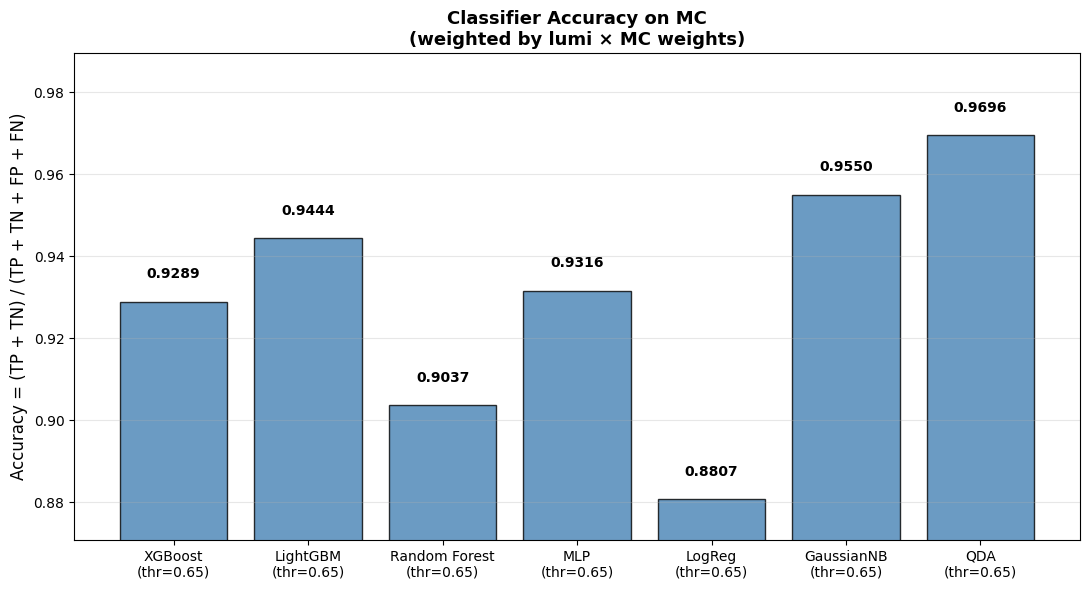

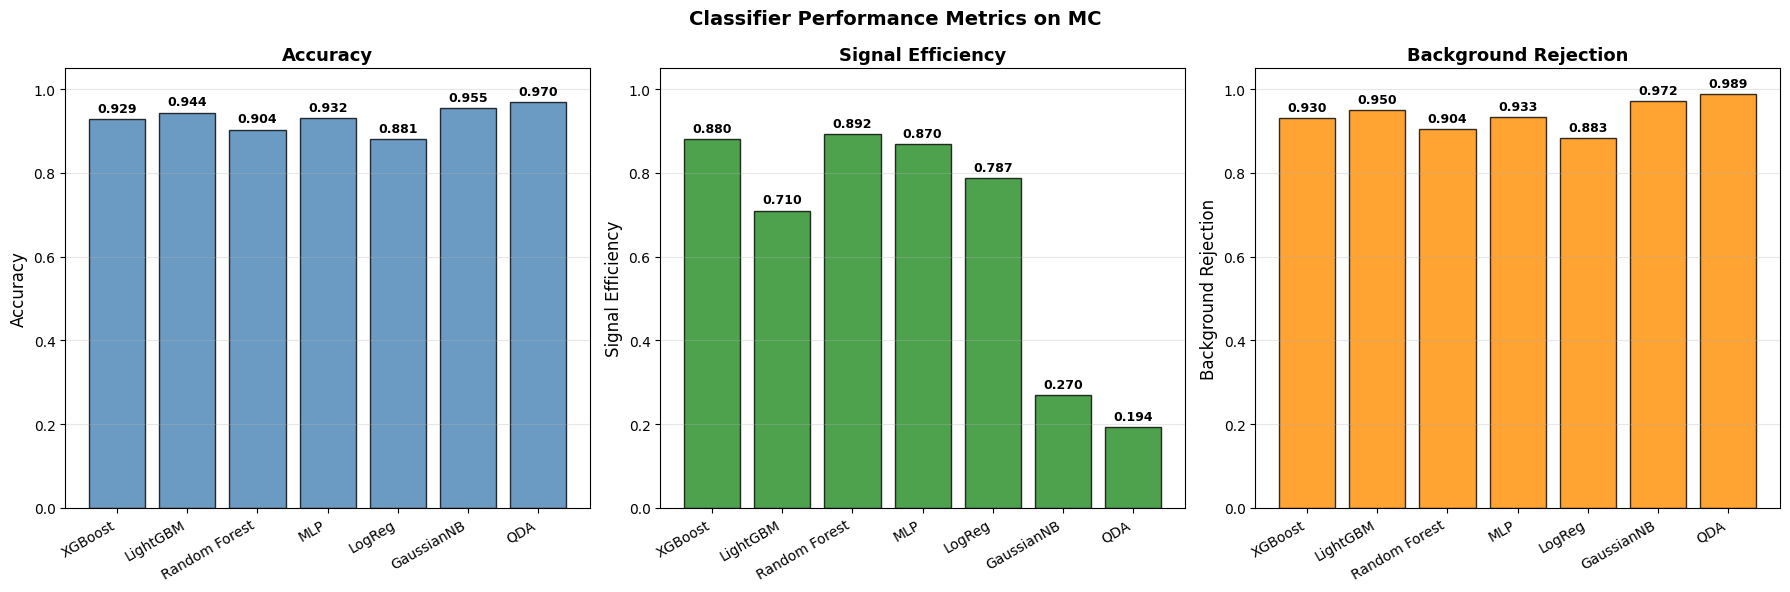

In [51]:
# ============================================================================
# CLASSIFIER ACCURACY ON MC: (TP + TN) / (TP + TN + FP + FN)
# ============================================================================
# Computed on weighted MC events using each model's OOF scores at the
# threshold that was used for the real-data analysis.
# Reuses cached oof_<model> arrays — no retraining needed.

# ----------------------------------------------------------------------------
# CONFIG — model name → (oof variable name, threshold)
# Edit thresholds to match what you used in the real-data analysis for each.
# ----------------------------------------------------------------------------
MODELS = {
    'XGBoost':       ('oof_mc',     0.65),
    'LightGBM':      ('oof_lgb',    0.65),
    'Random Forest': ('oof_rf',     0.65),
    'MLP':           ('oof_mlp',    0.65),
    'LogReg':        ('oof_logreg', 0.65),
    'GaussianNB':    ('oof_gnb',    0.65),
    'QDA':           ('oof_qda',    0.65),
}

# ----------------------------------------------------------------------------
# Compute weighted confusion matrix and accuracy
# ----------------------------------------------------------------------------
def weighted_accuracy(oof, y, w, threshold):
    """Returns dict with weighted TP/TN/FP/FN and accuracy."""
    pred_pos = oof > threshold
    pred_neg = ~pred_pos
    is_sig   = (y == 1)
    is_bkg   = (y == 0)

    TP = w[is_sig & pred_pos].sum()   # signal predicted as signal
    TN = w[is_bkg & pred_neg].sum()   # background predicted as background
    FP = w[is_bkg & pred_pos].sum()   # background predicted as signal
    FN = w[is_sig & pred_neg].sum()   # signal predicted as background

    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total > 0 else np.nan

    # Also useful auxiliary metrics
    sig_eff      = TP / (TP + FN) if (TP + FN) > 0 else np.nan   # = recall
    bkg_rejection = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    purity       = TP / (TP + FP) if (TP + FP) > 0 else np.nan   # = precision

    return {
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
        'accuracy':      accuracy,
        'sig_eff':       sig_eff,
        'bkg_rejection': bkg_rejection,
        'purity':        purity,
    }

# ----------------------------------------------------------------------------
# Compute for each model
# ----------------------------------------------------------------------------
results = {}
for name, (oof_var, thr) in MODELS.items():
    if oof_var not in globals():
        print(f"[skip] {name}: '{oof_var}' not found in globals — model not trained yet.")
        continue
    oof = globals()[oof_var]
    results[name] = weighted_accuracy(oof, y_mc, w_mc, thr)
    results[name]['threshold'] = thr

# ----------------------------------------------------------------------------
# Print summary table
# ----------------------------------------------------------------------------
print("="*94)
print("CLASSIFIER ACCURACY ON MC (weighted by physics weights)")
print("="*94)
print(f"{'Model':<16} {'Thr':>6} {'TP':>10} {'TN':>14} {'FP':>14} {'FN':>10} "
      f"{'Accuracy':>10} {'SigEff':>9} {'BkgRej':>9}")
print("-"*94)
for name, r in results.items():
    print(f"{name:<16} {r['threshold']:>6.2f} {r['TP']:>10.2f} {r['TN']:>14.2f} "
          f"{r['FP']:>14.2f} {r['FN']:>10.2f} "
          f"{r['accuracy']:>9.4f}  {r['sig_eff']:>8.2%} {r['bkg_rejection']:>8.2%}")
print("="*94)

# ----------------------------------------------------------------------------
# Bar plot of accuracies
# ----------------------------------------------------------------------------
model_names = list(results.keys())
accuracies  = [results[m]['accuracy']      for m in model_names]
sig_effs    = [results[m]['sig_eff']       for m in model_names]
bkg_rejs    = [results[m]['bkg_rejection'] for m in model_names]

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(model_names))
bars = ax.bar(x, accuracies, color='steelblue', alpha=0.8,
              edgecolor='black', linewidth=1)

# Annotate accuracy values on top of bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add threshold below each model name
xlabels = [f"{name}\n(thr={results[name]['threshold']:.2f})" for name in model_names]
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=10)

ax.set_ylabel('Accuracy = (TP + TN) / (TP + TN + FP + FN)', fontsize=12)
ax.set_title('Classifier Accuracy on MC\n(weighted by lumi × MC weights)',
             fontsize=13, fontweight='bold')

# Set y-axis range tight around the data, since all accuracies will be very close to 1
y_min = max(0, min(accuracies) - 0.01)
y_max = min(1.0, max(accuracies) + 0.02)
ax.set_ylim(y_min, y_max)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# Bonus: 3-panel plot of accuracy + signal efficiency + background rejection
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('Accuracy',             accuracies, 'steelblue'),
    ('Signal Efficiency',    sig_effs,   'forestgreen'),
    ('Background Rejection', bkg_rejs,   'darkorange'),
]

for ax, (title, vals, color) in zip(axes, metrics):
    bars = ax.bar(x, vals, color=color, alpha=0.8, edgecolor='black', linewidth=1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=10)
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle('Classifier Performance Metrics on MC',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("classifier_metrics_3panel.png", dpi=300, bbox_inches='tight')
plt.show()

### 12.2 Threshold diagnostic helper

In [52]:
# Reuse cached oof scores (no retraining needed)

def threshold_diagnostic(oof, y, w, m, threshold,
                         WIN_LO=110.0, WIN_HI=135.0, k_syst=0.30):
    """Returns all relevant metrics for one threshold."""
    pred_pos = oof > threshold
    pred_neg = ~pred_pos
    is_sig   = (y == 1)
    is_bkg   = (y == 0)

    TP = w[is_sig & pred_pos].sum()
    TN = w[is_bkg & pred_neg].sum()
    FP = w[is_bkg & pred_pos].sum()
    FN = w[is_sig & pred_neg].sum()

    accuracy      = (TP + TN) / (TP + TN + FP + FN)
    sig_eff       = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    bkg_rejection = TN / (TN + FP) if (TN + FP) > 0 else np.nan

    # Z on MC in window
    sig_in_win = is_sig & pred_pos & (m >= WIN_LO) & (m < WIN_HI)
    bkg_in_win = is_bkg & pred_pos & (m >= WIN_LO) & (m < WIN_HI)
    S = w[sig_in_win].sum()
    B = w[bkg_in_win].sum()
    Z = S / np.sqrt(B + (k_syst * B)**2) if B > 0 else 0.0

    # Pass criteria
    passes = (sig_eff >= 0.50) and (bkg_rejection >= 0.90) and (B >= 5)

    return {
        'thr': threshold, 'sig_eff': sig_eff, 'bkg_rej': bkg_rejection,
        'B': B, 'S': S, 'Z': Z, 'accuracy': accuracy, 'passes': passes,
    }

# Scan a range of thresholds for each model
def scan_model(name, oof, thr_grid):
    print(f"\n{'='*78}")
    print(f"  {name}")
    print('='*78)
    print(f"{'thr':>5} {'SigEff':>9} {'BkgRej':>9} {'B':>8} {'Z':>7} {'pass?':>7}")
    print('-'*78)
    for thr in thr_grid:
        r = threshold_diagnostic(oof, y_mc, w_mc, m_mc, thr)
        flag = '✓' if r['passes'] else '✗'
        print(f"{r['thr']:>5.2f} {r['sig_eff']:>8.1%} {r['bkg_rej']:>8.1%} "
              f"{r['B']:>8.2f} {r['Z']:>7.2f} {flag:>7}")

# Run for each model
scan_model('XGBoost',        oof_mc,     np.arange(0.50, 0.96, 0.05))
scan_model('LightGBM',       oof_lgb,    np.arange(0.50, 0.96, 0.05))
scan_model('Random Forest',  oof_rf,     np.arange(0.70, 0.96, 0.02))
scan_model('MLP',            oof_mlp,    np.arange(0.50, 0.96, 0.05))
scan_model('LogReg',         oof_logreg, np.arange(0.50, 0.96, 0.05))
scan_model('GaussianNB',     oof_gnb,    np.arange(0.10, 0.96, 0.05))
scan_model('QDA',            oof_qda,    np.arange(0.05, 0.96, 0.05))


  XGBoost
  thr    SigEff    BkgRej        B       Z   pass?
------------------------------------------------------------------------------
 0.50    92.6%    89.5%    23.46    2.99       ✗
 0.55    90.0%    90.4%    21.56    3.19       ✓
 0.60    89.3%    91.4%    19.90    3.39       ✓
 0.65    88.0%    93.0%    17.96    3.63       ✓
 0.70    82.9%    94.9%    16.30    3.73       ✓
 0.75    67.4%    96.2%    13.67    3.51       ✓
 0.80    62.7%    97.2%    11.06    3.82       ✓
 0.85    50.8%    98.3%     8.16    3.82       ✓
 0.90    46.0%    99.0%     7.14    3.88       ✗
 0.95    29.5%    99.7%     3.29    4.32       ✗

  LightGBM
  thr    SigEff    BkgRej        B       Z   pass?
------------------------------------------------------------------------------
 0.50    89.0%    91.4%    20.97    3.23       ✓
 0.55    87.3%    92.5%    19.76    3.32       ✓
 0.60    80.9%    93.7%    18.36    3.26       ✓
 0.65    71.0%    95.0%    15.13    3.36       ✓
 0.70    70.4%    95.5%    14.7

### 12.3 OOF score distributions per model *(paper Fig. 7)*

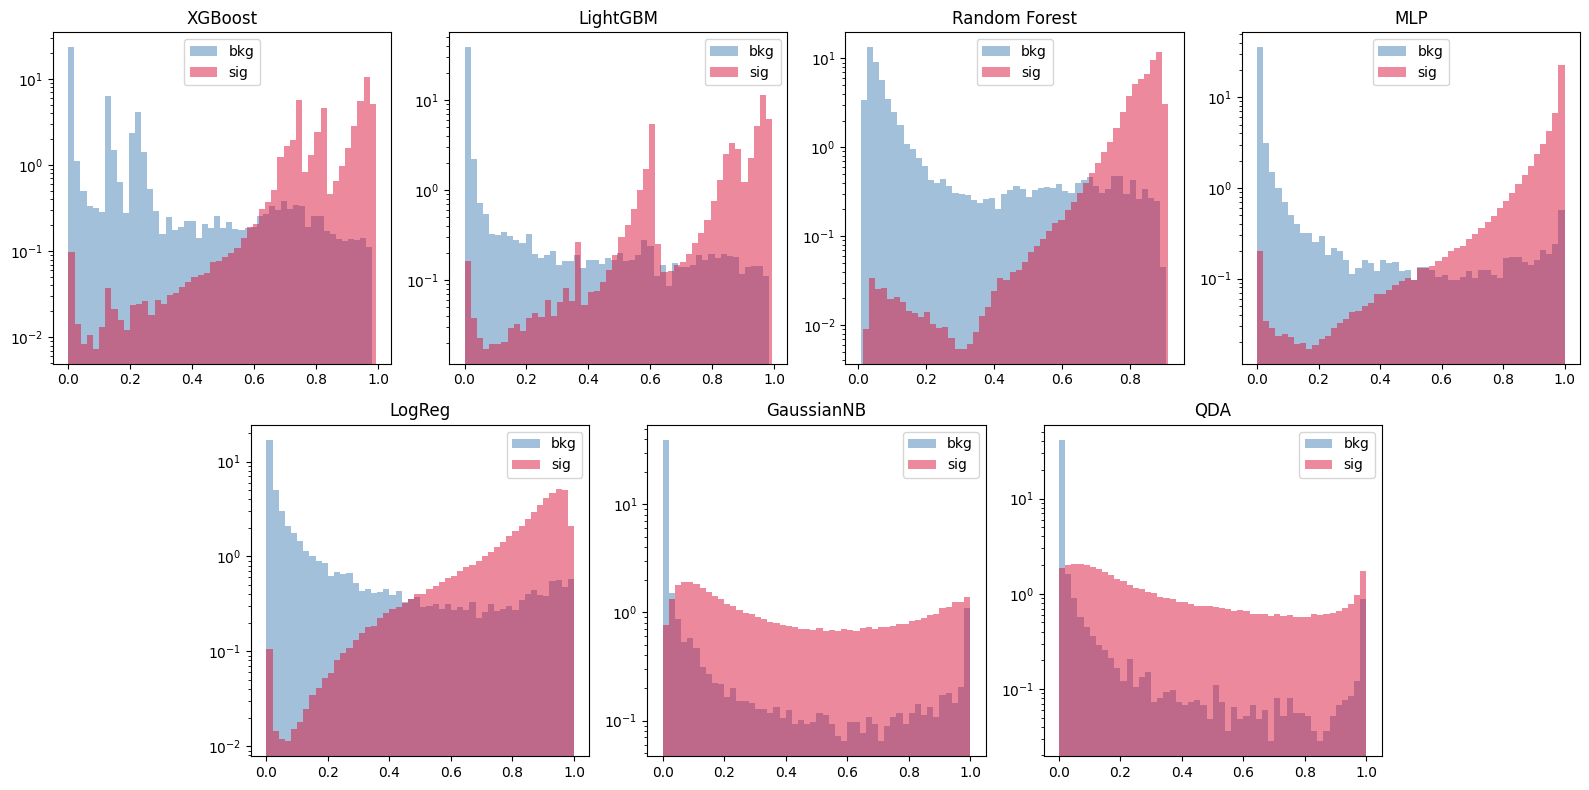

In [53]:

models = [
    ('XGBoost', oof_mc),
    ('LightGBM', oof_lgb),
    ('Random Forest', oof_rf),
    ('MLP', oof_mlp),
    ('LogReg', oof_logreg),
    ('GaussianNB', oof_gnb),
    ('QDA', oof_qda)
]

fig = plt.figure(figsize=(16, 8))

# Use a wider invisible grid to preserve equal subplot sizes
gs = fig.add_gridspec(2, 8)

axes = [
    # Top row (4 equal plots)
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[0, 6:8]),

    # Bottom row (3 equal plots centered)
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
    fig.add_subplot(gs[1, 5:7]),
]

for ax, (name, oof) in zip(axes, models):

    ax.hist(
        oof[y_mc == 0],
        bins=50,
        alpha=0.5,
        label='bkg',
        density=True,
        color='steelblue'
    )

    ax.hist(
        oof[y_mc == 1],
        bins=50,
        alpha=0.5,
        label='sig',
        density=True,
        color='crimson'
    )

    ax.set_title(name)
    ax.set_yscale('log')
    ax.legend()

plt.tight_layout()
plt.show()

### 12.4 Per-model OOF AUC + bootstrap 95 % CI *(paper Table IV)*

Cell 1 below sets the `models` dictionary used by every subsequent comparison
plot; cell 2 produces the ROC + forest plot of AUCs (paper Fig. 6).

In [54]:
models = {
    "XGBoost":            oof_mc,
    "GaussianNB":         oof_gnb,
    "QDA":                oof_qda,
    "Logistic Regression": oof_logreg,   # OOF scores, not oof_auc_logreg
    "Random Forest":      oof_rf,        # OOF scores, not oof_auc_rf
    "MLP":                oof_mlp,
    "LightGBM":           oof_lgb
    }

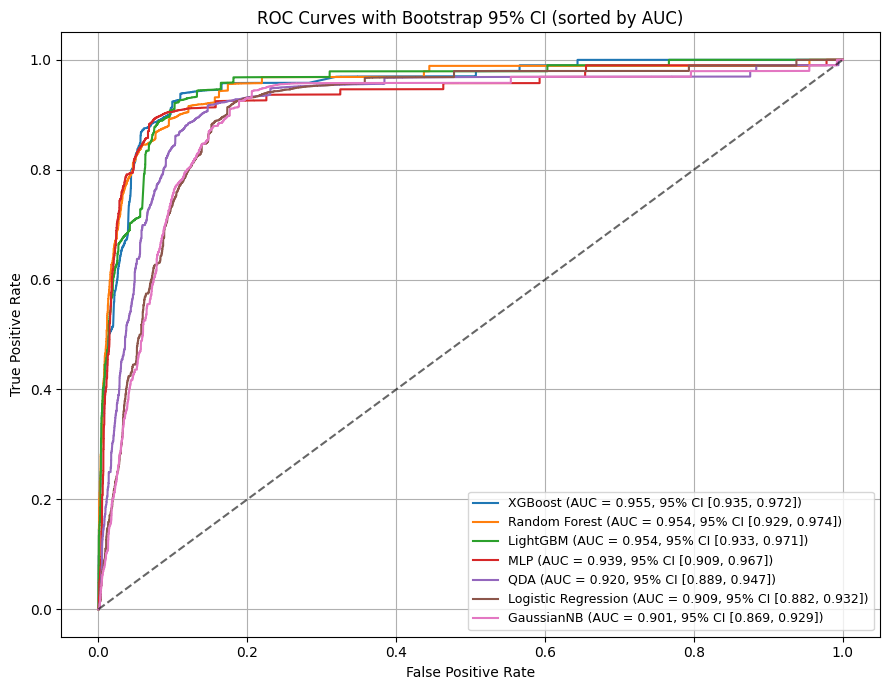

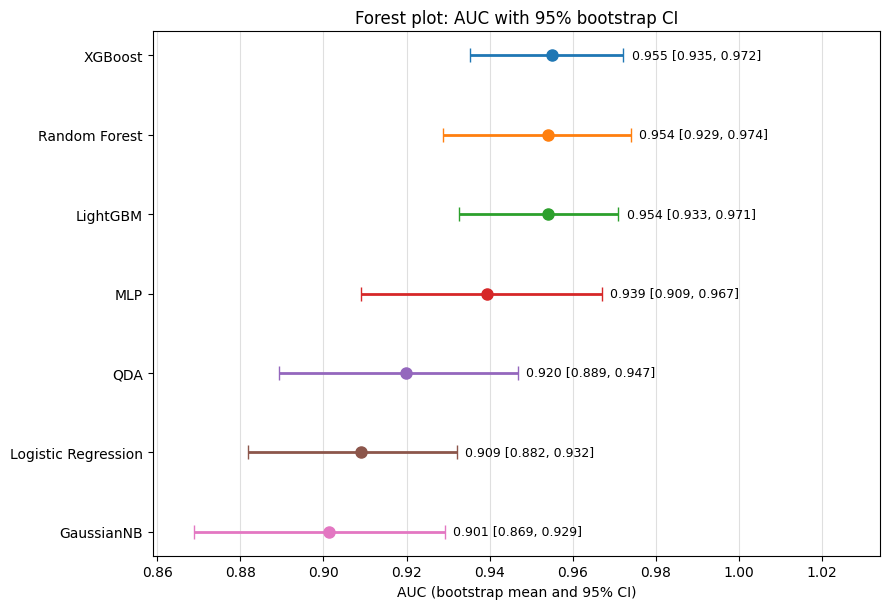

In [55]:

# ---------- Bootstrap AUC with confidence intervals ----------
def bootstrap_auc(y_true, scores, weights, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    aucs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        # skip degenerate resamples (only one class)
        if len(np.unique(y_true[idx])) < 2:
            aucs[i] = np.nan
            continue
        aucs[i] = roc_auc_score(y_true[idx], scores[idx], sample_weight=weights[idx])
    aucs = aucs[~np.isnan(aucs)]
    return aucs.mean(), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

# ---------- Compute point AUCs and bootstrap CIs ----------
auc_dict = {}
boot_dict = {}  # name -> (mean, lo, hi)
for name, scores in models.items():
    auc_dict[name] = roc_auc_score(y_mc, scores, sample_weight=w_mc)
    boot_dict[name] = bootstrap_auc(np.asarray(y_mc), np.asarray(scores), np.asarray(w_mc))

# Sort models by point AUC (descending)
models_sorted = dict(sorted(models.items(), key=lambda x: auc_dict[x[0]], reverse=True))

# ---------- Lock in colors so ROC and forest plot match ----------
cmap = plt.get_cmap("tab10")
color_map = {name: cmap(i) for i, name in enumerate(models_sorted.keys())}

# ---------- ROC curves with bootstrap CI in legend ----------
plt.figure(figsize=(9, 7))
for name, scores in models_sorted.items():
    fpr, tpr, _ = roc_curve(y_mc, scores, sample_weight=w_mc)
    mean, lo, hi = boot_dict[name]
    label = f"{name} (AUC = {auc_dict[name]:.3f}, 95% CI [{lo:.3f}, {hi:.3f}])"
    plt.plot(fpr, tpr, label=label, color=color_map[name])

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves with Bootstrap 95% CI (sorted by AUC)")
plt.legend(loc="lower right", fontsize=9)
plt.grid()
plt.tight_layout()
plt.show()

# ---------- Forest plot ----------
# Order top-to-bottom = best-to-worst (so best is at the top of the plot)
names = list(models_sorted.keys())
y_pos = np.arange(len(names))[::-1]  # reverse so best is on top

fig, ax = plt.subplots(figsize=(9, 0.6 * len(names) + 2))
for y, name in zip(y_pos, names):
    mean, lo, hi = boot_dict[name]
    point = auc_dict[name]
    ax.errorbar(
        point, y,
        xerr=[[point - lo], [hi - point]],
        fmt='o', color=color_map[name],
        ecolor=color_map[name], elinewidth=2, capsize=5, markersize=8,
        label=name
    )
    # numeric annotation to the right of the error bar
    ax.text(hi + 0.002, y, f"{point:.3f} [{lo:.3f}, {hi:.3f}]",
            va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.set_xlabel("AUC (bootstrap mean and 95% CI)")
ax.set_title("Forest plot: AUC with 95% bootstrap CI")
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Random (0.5)')
ax.grid(axis='x', alpha=0.4)

# Give the annotations room on the right
xmin = min(lo for _, lo, _ in boot_dict.values()) - 0.01
xmax = max(hi for _, _, hi in boot_dict.values()) + 0.06
ax.set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()

### 12.5 MC-only significance forest plot at threshold 0.65 *(paper Fig. 9, Table VI)*

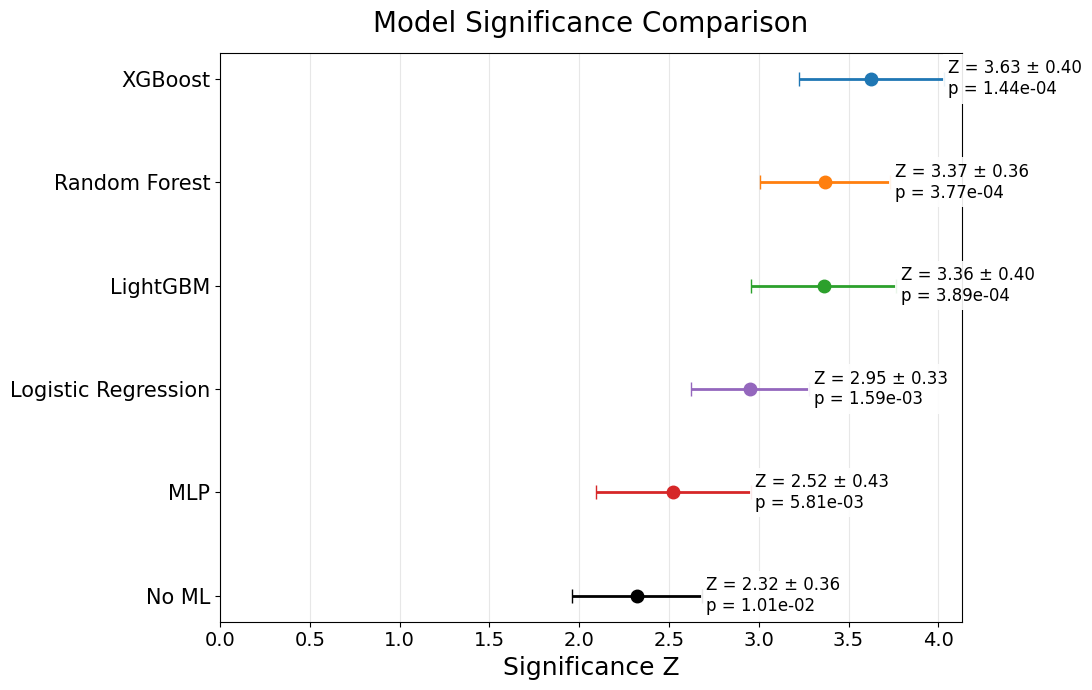

In [56]:

# ----------------------------------------------------------------------------
# MODELS
# ----------------------------------------------------------------------------
models = {
    "XGBoost": oof_mc,
    "Logistic Regression": oof_logreg,
    "Random Forest": oof_rf,
    "MLP": oof_mlp,
    'LightGBM': oof_lgb,
}

# fixed threshold
THR = 0.65

WIN_LO, WIN_HI = 110.0, 135.0
k_syst = 0.30

# ----------------------------------------------------------------------------
# SAME COLORS AS ROC CURVE
# ----------------------------------------------------------------------------
auc_dict = {
    name: roc_auc_score(y_mc, scores, sample_weight=w_mc)
    for name, scores in models.items()
}

models_sorted = dict(
    sorted(models.items(),
           key=lambda x: auc_dict[x[0]],
           reverse=True)
)

cmap = plt.cm.tab10
roc_colors = {
    name: cmap(i)
    for i, name in enumerate(models_sorted)
}

# ----------------------------------------------------------------------------
# FIXED-THRESHOLD Z FUNCTION
# ----------------------------------------------------------------------------
def compute_Z_sigma(y, scores, w, m, thr=0.65):

    sig = (
        (y == 1)
        & (scores > thr)
        & (m >= WIN_LO)
        & (m < WIN_HI)
    )

    bkg = (
        (y == 0)
        & (scores > thr)
        & (m >= WIN_LO)
        & (m < WIN_HI)
    )

    S = w[sig].sum()
    B = w[bkg].sum()

    sigma_S = np.sqrt((w[sig]**2).sum())
    sigma_B = np.sqrt((w[bkg]**2).sum())

    denom = B + (k_syst * B)**2

    Z = S / np.sqrt(denom)

    term_S = sigma_S**2 / denom

    term_B = (
        S**2
        * (1 + 2*k_syst**2 * B)**2
        * sigma_B**2
    ) / (4 * denom**3)

    sigma_Z = np.sqrt(term_S + term_B)

    return Z, sigma_Z

# ----------------------------------------------------------------------------
# COMPUTE RESULTS
# ----------------------------------------------------------------------------
results = []

# ML models
for name, scores in models.items():

    Z, sigma_Z = compute_Z_sigma(
        y_mc,
        scores,
        w_mc,
        m_mc,
        thr=THR
    )

    results.append((name, Z, sigma_Z))

# sort by significance
results.sort(key=lambda x: x[1], reverse=True)

# add baseline last
results.append(("No ML", z_no_ml["Z"], z_no_ml["sigma_Z"]))

names  = [r[0] for r in results]
means  = [r[1] for r in results]
errors = [r[2] for r in results]

# ----------------------------------------------------------------------------
# COLORS
# ----------------------------------------------------------------------------
colors = []

for name in names:

    if name == "No ML":
        colors.append("black")
    else:
        colors.append(roc_colors[name])

# ----------------------------------------------------------------------------
# PLOT
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7))

y_pos = np.arange(len(names))

for i in range(len(names)):

    ax.errorbar(
        means[i],
        y_pos[i],
        xerr=errors[i],
        fmt='o',
        color=colors[i],
        capsize=5,
        markersize=9,
        elinewidth=2
    )

# labels
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=15)

ax.set_xlabel(
    "Significance Z",
    fontsize=18
)

ax.set_title(
    "Model Significance Comparison",
    fontsize=20,
    pad=15
)

# start axis at 0
ax.set_xlim(left=0)

# grid
ax.grid(axis='x', alpha=0.3)

# best model on top
ax.invert_yaxis()

# larger tick labels
ax.tick_params(axis='x', labelsize=14)

# ----------------------------------------------------------------------------
# VALUE LABELS WITH P-VALUES
# ----------------------------------------------------------------------------
x_range = max(means) - min(means)

for i, (z, ez) in enumerate(zip(means, errors)):

    # one-sided p-value
    p = norm.sf(z)

    # scientific notation for tiny values
    p_text = f"{p:.2e}"

    label = (
        f"Z = {z:.2f} ± {ez:.2f}\n"
        f"p = {p_text}"
    )

    ax.text(
        z + ez + 0.02 * x_range,
        i,
        label,
        va='center',
        fontsize=12,
        bbox=dict(
            facecolor='white',
            alpha=0.9,
            edgecolor='none'
        )
    )

plt.tight_layout()
plt.show()

## 13. Application to real ATLAS data *(paper §XI)*

For every retained classifier (XGBoost, LightGBM, Random Forest, MLP,
Logistic Regression), train the same 5-fold pipeline on Monte Carlo and apply
the resulting 5 fold-models to the 1,279 real ATLAS events. The data score
per event is the average over the 5 fold predictions; events are selected
with score > 0.65 in the m_4l ∈ [110, 135) GeV window.

The expected background in the signal region is computed two independent ways
(paper §XI):
* **MC prediction**: B taken directly from simulated background surviving the
  classifier + mass-window cuts.
* **Sideband extrapolation**: B estimated from data events passing the
  classifier cut in m_4l ∈ [90, 105) ∪ [140, 155) GeV, scaled by the
  signal-region / sideband width ratio.

### 13.1 XGBoost on real data — full pipeline + diagnostics *(paper Table VII)*

In [57]:
# ----- XGreal data: train paired k-fold XGBoost, score MC OOF + real data ensemble -----

XR_K          = 5
XR_KFOLD_SEED = 42
XR_MODEL_SEED = 42
XR_THRESHOLD  = 0.65

def build_ml_dataset_with_mass(feature_list):
    sig_key  = r'Signal ($m_H$ = 125 GeV)'
    bkg_keys = [s for s in z_masses if s != sig_key]
    X_sig = np.stack([z_masses[sig_key][k] for k in feature_list], axis=1)
    w_sig = z_masses[sig_key]['w']
    m_sig = z_masses[sig_key]['mass']
    X_bkg = np.stack([np.concatenate([z_masses[s][k] for s in bkg_keys])
                      for k in feature_list], axis=1)
    w_bkg = np.concatenate([z_masses[s]['w']    for s in bkg_keys])
    m_bkg = np.concatenate([z_masses[s]['mass'] for s in bkg_keys])
    X = np.vstack([X_sig, X_bkg])
    y = np.concatenate([np.ones(len(X_sig)), np.zeros(len(X_bkg))])
    w = np.concatenate([w_sig, w_bkg])
    m = np.concatenate([m_sig, m_bkg])
    return X, y, w, m

# --- MC training arrays (with mass) ---
X_mc, y_mc, w_mc, m_mc = build_ml_dataset_with_mass(keep_sep)
print(f'MC events: {len(y_mc)}   sig: {int((y_mc==1).sum())}   bkg: {int((y_mc==0).sum())}')

# --- Real data feature matrix (reconstructed ONCE before the loop) ---
data_feats = reconstruct_z1_z2_fast(all_data['Data'])
X_data     = np.stack([np.asarray(data_feats[k]) for k in keep_sep], axis=1)
m_data     = np.asarray(data_feats['mass'])
print(f'Real data events: {len(X_data)}')

# --- k-fold loop ---
skf          = StratifiedKFold(n_splits=XR_K, shuffle=True, random_state=XR_KFOLD_SEED)
oof_mc       = np.zeros(len(y_mc))
data_per_fold = np.zeros((XR_K, len(X_data)))
fold_aucs    = []
xr_pipelines = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):
    X_tr_full, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr_full, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr_full, w_te = w_mc[tr_idx], w_mc[te_idx]

    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_tr_full, y_tr_full, w_tr_full,
        test_size=0.20, random_state=XR_KFOLD_SEED, stratify=y_tr_full,
    )

    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr)
    X_val_s  = scaler.transform(X_val)
    X_te_s   = scaler.transform(X_te)
    X_data_s = scaler.transform(X_data)

    spw = w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum()
    model = xgb.XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=1, gamma=0, reg_lambda=1, reg_alpha=0,
        scale_pos_weight=spw,
        eval_metric='auc', random_state=XR_MODEL_SEED, n_jobs=-1,
        tree_method='hist', early_stopping_rounds=20,
    )
    model.fit(
        X_tr_s, y_tr,
        sample_weight          = w_tr,
        eval_set               = [(X_val_s, y_val)],
        sample_weight_eval_set = [w_val],
        verbose                = False,
    )

    oof_mc[te_idx]           = model.predict_proba(X_te_s)[:, 1]
    data_per_fold[fold_idx]  = model.predict_proba(X_data_s)[:, 1]
    fold_aucs.append(roc_auc_score(y_te, oof_mc[te_idx], sample_weight=w_te))
    xr_pipelines.append({'scaler': scaler, 'model': model})
    print(f'  fold {fold_idx+1}/{XR_K}  AUC={fold_aucs[-1]:.4f}   '
          f'n_train={len(X_tr)}  n_val={len(X_val)}  n_test={len(X_te)}   '
          f'[t={time.time()-t0:5.1f}s]')

# --- Aggregate scores ---
data_scores = data_per_fold.mean(axis=0)
oof_auc     = roc_auc_score(y_mc, oof_mc, sample_weight=w_mc)

print()
print(f'OOF AUC (MC, all events): {oof_auc:.4f}   '
      f'per-fold {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')
print(f'Real data scored: {len(data_scores)} events  '
      f'(mean of {XR_K} models; fold std = '
      f'{data_per_fold.std(axis=0).mean():.4f})')

xr_sig_mask = (y_mc == 1)
xr_bkg_mask = (y_mc == 0)

MC events: 238517   sig: 226120   bkg: 12397
Real data events: 1279
  fold 1/5  AUC=0.9703   n_train=152650  n_val=38163  n_test=47704   [t=  2.5s]
  fold 2/5  AUC=0.9545   n_train=152650  n_val=38163  n_test=47704   [t=  6.4s]
  fold 3/5  AUC=0.9849   n_train=152651  n_val=38163  n_test=47703   [t= 10.3s]
  fold 4/5  AUC=0.9827   n_train=152651  n_val=38163  n_test=47703   [t= 15.4s]
  fold 5/5  AUC=0.9156   n_train=152651  n_val=38163  n_test=47703   [t= 16.5s]

OOF AUC (MC, all events): 0.9549   per-fold 0.9616 ± 0.0254
Real data scored: 1279 events  (mean of 5 models; fold std = 0.0965)


In [58]:
# --- Per-sample index map (must run immediately after the cell above) ---
sig_key  = r'Signal ($m_H$ = 125 GeV)'
bkg_keys = [s for s in z_masses if s != sig_key]

_offsets = {}
_pos     = 0
_n_sig   = len(z_masses[sig_key]['mass'])
_offsets[sig_key] = (_pos, _pos + _n_sig)
_pos += _n_sig
for s in _bkg_keys:
    n = len(z_masses[s]['mass'])
    _offsets[s] = (_pos, _pos + n)
    _pos += n
assert _pos == len(y_mc), f'offset mismatch {_pos} vs {len(y_mc)}'

def _per_sample(s):
    a, b = _offsets[s]
    return m_mc[a:b], w_mc[a:b], oof_mc[a:b]

In [59]:
# Stacked MC backgrounds after cut
mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample(s)
    sel = p_s > XR_THRESHOLD
    mc_x.append(m_s[sel])
    mc_w.append(w_s[sel])
    mc_colors.append(samples[s]['color'])
    mc_labels.append(s)

# Signal after cut
m_sig_arr, w_sig_arr, p_sig_arr = _per_sample(sig_key)
sig_sel = p_sig_arr > XR_THRESHOLD
signal_x = m_sig_arr[sig_sel]
signal_weights = w_sig_arr[sig_sel]
signal_color = samples[sig_key]['color']

mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                      color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]
mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                               weights=np.hstack(mc_w)**2)[0])

ax.hist(signal_x, bins=bin_edges, weights=signal_weights, bottom=mc_tot,
         color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err, alpha=0.5,
        color='none', hatch='////', width=step_size, label='Stat. Unc.')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'MC after XGBoost (score > {XR_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("1.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

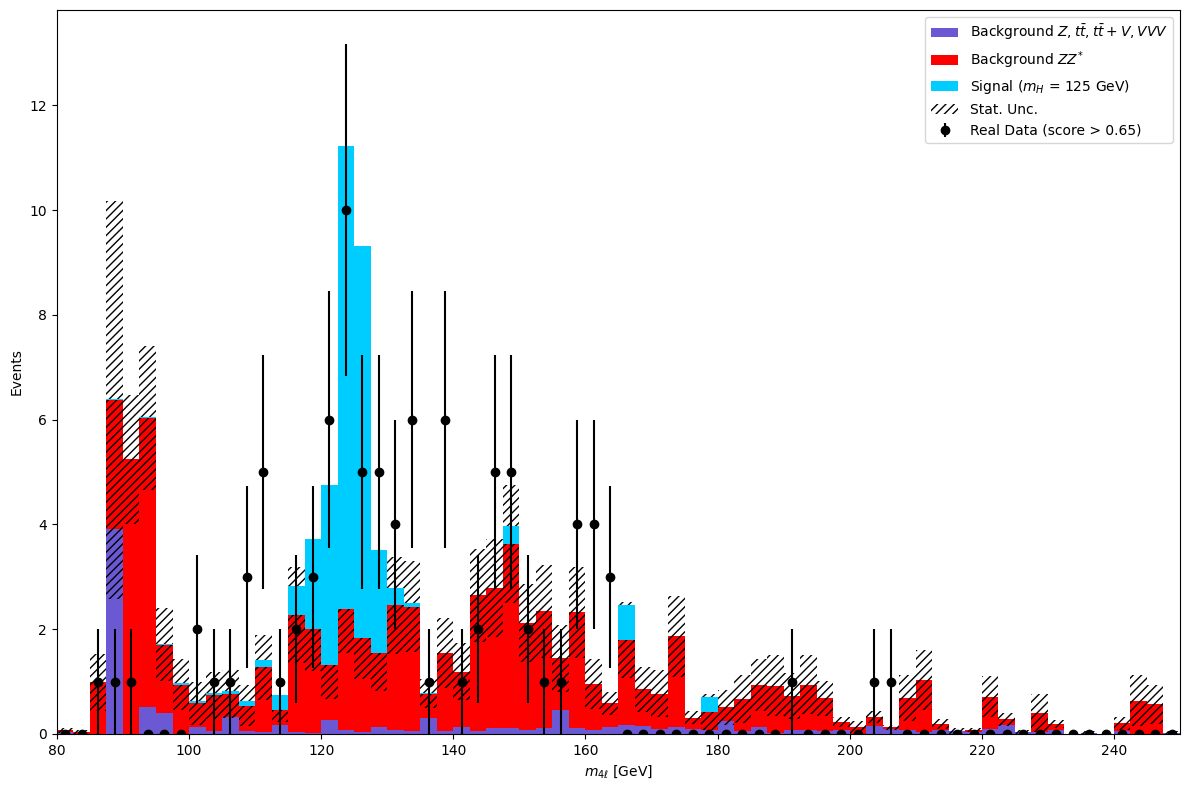

Data passing cut :     95
MC bkg (lumi)    :     83.43
MC signal (lumi) :     26.79


In [76]:
# 1. CREATE the figure FIRST
fig, ax = plt.subplots(figsize=(12, 8))

# 2. Build the data arrays
mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample(s)
    sel = p_s > XR_THRESHOLD
    mc_x.append(m_s[sel])
    mc_w.append(w_s[sel])
    mc_colors.append(samples[s]['color'])
    mc_labels.append(s)

m_sig_arr, w_sig_arr, p_sig_arr = _per_sample(sig_key)
sig_sel = p_sig_arr > XR_THRESHOLD
signal_x = m_sig_arr[sig_sel]
signal_weights = w_sig_arr[sig_sel]
signal_color = samples[sig_key]['color']

# Real data after cut
data_pass = data_scores > XR_THRESHOLD
data_mass = m_data[data_pass]
data_x, _ = np.histogram(data_mass, bins=bin_edges)
data_x_err = np.sqrt(data_x)

# 3. NOW draw onto ax
mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]

mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                              weights=np.hstack(mc_w)**2)[0])
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
       alpha=0.5, color='none', hatch='////',
       width=2.5, label='Stat. Unc.')

ax.hist(signal_x, bins=bin_edges, weights=signal_weights,
        bottom=mc_tot, color=signal_color, label=sig_key)

ax.errorbar(bin_centres, data_x, yerr=data_x_err,
            fmt='ko', label=f'Real Data (score > {XR_THRESHOLD})')

ax.set_xlim(80, 250)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]')
ax.set_ylabel('Events')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Data passing cut : {int(data_pass.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w):>9.2f}')
print(f'MC signal (lumi) : {signal_weights.sum():>9.2f}')

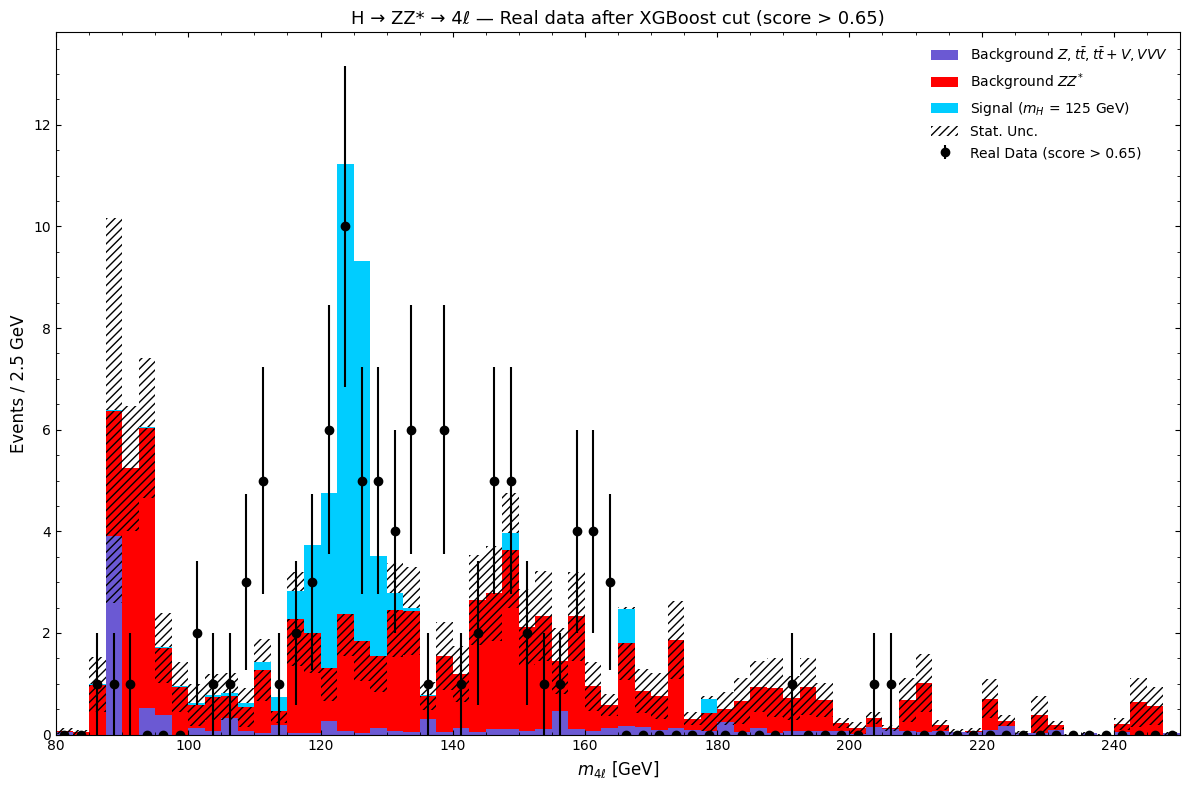

Data passing cut :     95
MC bkg (lumi)    :     83.43
MC signal (lumi) :     26.79


In [80]:
# ============================================================================
# PLOT REAL DATA m4l DISTRIBUTION AFTER XGBOOST CUT
# ============================================================================
m_data = np.asarray(data_feats['mass']) if 'mass' in data_feats else ak.to_numpy(all_data['Data']['mass'])

# Create the figure FIRST (before any ax.hist / ax.errorbar calls)
fig, ax = plt.subplots(figsize=(12, 8))

# Stacked MC backgrounds after cut
mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample(s)
    sel = p_s > XR_THRESHOLD
    mc_x.append(m_s[sel])
    mc_w.append(w_s[sel])
    mc_colors.append(samples[s]['color'])
    mc_labels.append(s)

# Signal after cut
m_sig_arr, w_sig_arr, p_sig_arr = _per_sample(sig_key)
sig_sel = p_sig_arr > XR_THRESHOLD
signal_x = m_sig_arr[sig_sel]
signal_weights = w_sig_arr[sig_sel]
signal_color = samples[sig_key]['color']

# Real data after cut
data_pass = data_scores > XR_THRESHOLD
data_mass = m_data[data_pass]
data_x, _ = np.histogram(data_mass, bins=bin_edges)
data_x_err = np.sqrt(data_x)

# Stacked MC backgrounds
mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                      color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]
mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                               weights=np.hstack(mc_w)**2)[0])

# Stat uncertainty band on MC
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err,
       alpha=0.5, color='none', hatch='////',
       width=2.5, label='Stat. Unc.')

# Signal stacked on top of backgrounds
ax.hist(signal_x, bins=bin_edges, weights=signal_weights, bottom=mc_tot,
         color=signal_color, label=sig_key)

# Real data points with Poisson errors
ax.errorbar(bin_centres, data_x, yerr=data_x_err, fmt='ko',
            label=f'Real Data (score > {XR_THRESHOLD})')

# Axes cosmetics
ax.set_xlim(80, 250)
ax.set_ylim(bottom=0)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=12)
ax.set_ylabel(f'Events / {2.5} GeV', fontsize=12)
ax.set_title(f'H → ZZ* → 4ℓ — Real data after XGBoost cut (score > {XR_THRESHOLD})',
             fontsize=13)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig("xgb_real_data_m4l.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Data passing cut : {int(data_pass.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w):>9.2f}')
print(f'MC signal (lumi) : {signal_weights.sum():>9.2f}')

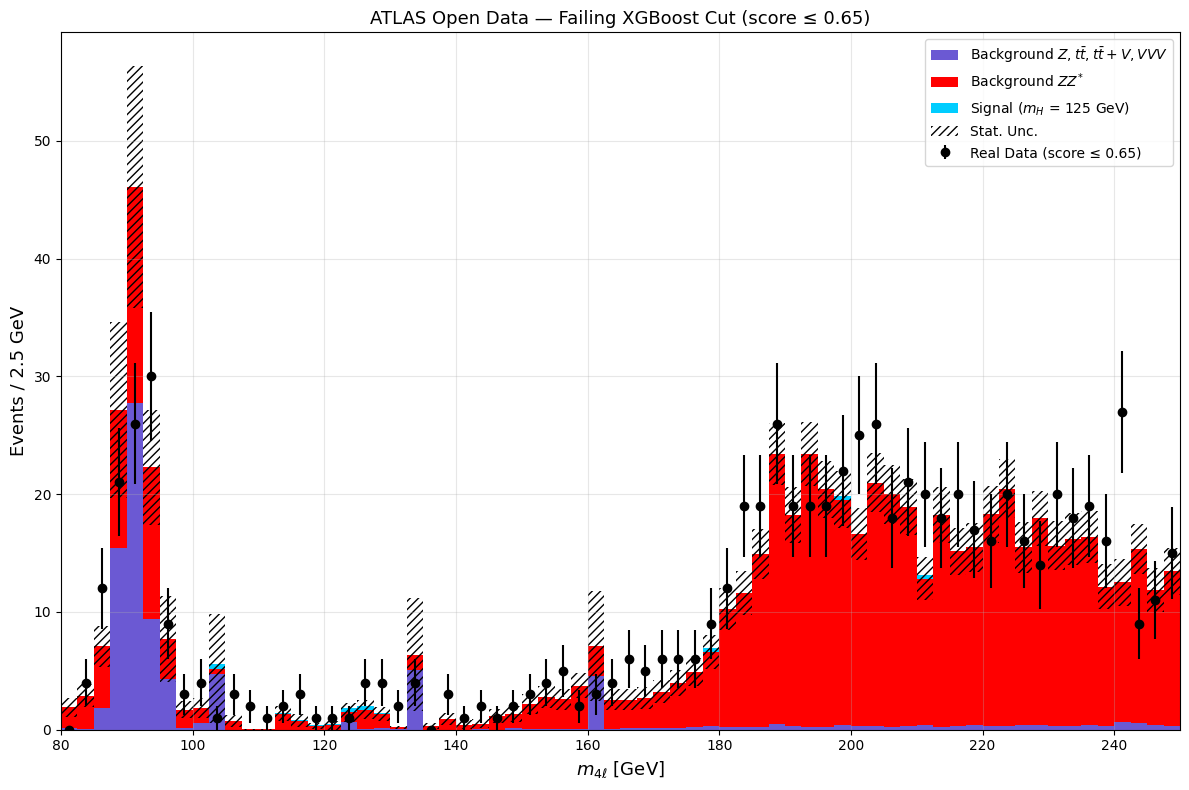

Data failing cut :   1184
MC bkg (lumi)    :   1111.27
MC signal (lumi) :      3.65


In [82]:
# ============================================================================
# PLOT 1: REAL DATA m4l DISTRIBUTION FAILING XGBOOST CUT
# ============================================================================
m_data = np.asarray(data_feats['mass']) if 'mass' in data_feats else ak.to_numpy(all_data['Data']['mass'])

# Rebuild bin edges locally so this cell does not depend on globals from
# section 4 still being alive in the kernel.
xmin, xmax, step_size = 80.0, 250.0, 2.5
bin_edges   = np.arange(xmin, xmax + step_size, step_size)
bin_centres = bin_edges[:-1] + step_size / 2

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

# Recompute MC distributions for FAILING events
mc_x_fail, mc_w_fail, mc_colors_fail, mc_labels_fail = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample(s)
    sel = p_s <= XR_THRESHOLD
    mc_x_fail.append(np.asarray(m_s[sel], dtype=float))
    mc_w_fail.append(np.asarray(w_s[sel], dtype=float))
    mc_colors_fail.append(samples[s]['color'])
    mc_labels_fail.append(s)

m_sig_arr, w_sig_arr, p_sig_arr = _per_sample(sig_key)
sig_sel_fail = p_sig_arr <= XR_THRESHOLD
signal_x_fail = np.asarray(m_sig_arr[sig_sel_fail], dtype=float)
signal_weights_fail = np.asarray(w_sig_arr[sig_sel_fail], dtype=float)

# Data failing cut
data_fail_mask = data_scores <= XR_THRESHOLD
data_mass_fail = m_data[data_fail_mask]
data_x_fail, _ = np.histogram(data_mass_fail, bins=bin_edges)
data_x_fail_err = np.sqrt(data_x_fail)

# Stacked MC backgrounds (drawn first so data points sit on top)
mc_heights_fail = ax.hist(mc_x_fail, bins=bin_edges, weights=mc_w_fail, stacked=True,
                           color=mc_colors_fail, label=mc_labels_fail)
mc_tot_fail = mc_heights_fail[0][-1]
mc_err_fail = np.sqrt(np.histogram(np.hstack(mc_x_fail), bins=bin_edges,
                                    weights=np.hstack(mc_w_fail)**2)[0])

# Signal stacked on top of backgrounds
ax.hist(signal_x_fail, bins=bin_edges, weights=signal_weights_fail, bottom=mc_tot_fail,
        color=signal_color, label=sig_key)

# Stat uncertainty band on MC
ax.bar(bin_centres, 2*mc_err_fail, bottom=mc_tot_fail - mc_err_fail, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')

# Real data points with Poisson errors (drawn last so they're on top)
ax.errorbar(bin_centres, data_x_fail, yerr=data_x_fail_err, fmt='ko',
            label=f'Real Data (score ≤ {XR_THRESHOLD})')

# Axes cosmetics
ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'ATLAS Open Data — Failing XGBoost Cut (score ≤ {XR_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("3prime.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Data failing cut : {int(data_fail_mask.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w_fail):>9.2f}')
print(f'MC signal (lumi) : {signal_weights_fail.sum():>9.2f}')

In [84]:
# ============================================================================
# SIGNIFICANCE ON REAL DATA (with proper S-B method)
# ============================================================================

print("\n" + "="*70)
print("REAL DATA SIGNIFICANCE - Signal Excess over Background")
print("="*70)

WIN_LO, WIN_HI = 110.0, 135.0
k_syst = 0.30

# Observed data in signal window after BDT cut
data_in_win = (m_data >= WIN_LO) & (m_data < WIN_HI)
data_in_win_ml = data_in_win & (data_scores > XR_THRESHOLD)
N_obs = data_in_win_ml.sum()
sigma_obs = np.sqrt(N_obs)  # Poisson uncertainty

print(f"\nObserved data events in [{WIN_LO:.0f}, {WIN_HI:.0f}) GeV with score > {XR_THRESHOLD}: {N_obs}")


REAL DATA SIGNIFICANCE - Signal Excess over Background

Observed data events in [110, 135) GeV with score > 0.65: 47


#### Method 0 — no-ML baseline on real data (mass window only)

In [88]:
# ============================================================================
# METHOD 0: WITHOUT ML (just mass window, no BDT cut)
# ============================================================================
print("\n" + "-"*60)
print("METHOD 0: Without ML (Mass Window Only, No BDT Cut)")
print("-"*60)

# Count real data in mass window (no ML cut)
data_in_window_noml = (m_data >= WIN_LO) & (m_data < WIN_HI)
N_obs_noml = data_in_window_noml.sum()
sigma_obs_noml = np.sqrt(N_obs_noml)

# Count MC background in mass window (no ML cut)
bkg_total_noml = 0
bkg_weight_sq_noml = 0
for s in bkg_keys:
    m = z_masses[s]['mass']
    w = z_masses[s]['w']
    in_window = (m >= WIN_LO) & (m < WIN_HI)
    bkg_total_noml += w[in_window].sum()
    bkg_weight_sq_noml += (w[in_window]**2).sum()

B_noml = bkg_total_noml
sigma_B_noml = np.sqrt(bkg_weight_sq_noml)

# Signal excess and significance
S_excess_noml = N_obs_noml - B_noml

denom_noml = B_noml + (k_syst * B_noml)**2
Z_noml = S_excess_noml / np.sqrt(denom_noml)

# Error propagation
term_obs_noml = sigma_obs_noml**2 / denom_noml
term_B_noml = (S_excess_noml**2 * (1 + 2*k_syst**2 * B_noml)**2 * sigma_B_noml**2) / (4 * denom_noml**3)
sigma_Z_noml = np.sqrt(term_obs_noml + term_B_noml)
pvalue_noml = norm.sf(Z_noml)

print(f"  Observed data (N_obs):           {N_obs_noml:.0f} ± {sigma_obs_noml:.1f}")
print(f"  MC background (B_pred):          {B_noml:.2f} ± {sigma_B_noml:.2f}")
print(f"  Signal excess (N_obs - B_pred):  {S_excess_noml:.2f}")
print(f"  Significance Z:                  {Z_noml:.2f} ± {sigma_Z_noml:.2f}σ")
print(f"  p-value:                         {pvalue_noml:.2e}")



------------------------------------------------------------
METHOD 0: Without ML (Mass Window Only, No BDT Cut)
------------------------------------------------------------
  Observed data (N_obs):           70 ± 8.4
  MC background (B_pred):          31.95 ± 5.62
  Signal excess (N_obs - B_pred):  38.05
  Significance Z:                  3.42 ± 0.92σ
  p-value:                         3.13e-04


#### Method 1 — MC background prediction *(paper §XI)*

In [89]:
# ============================================================================
# METHOD 1: MC Background Prediction (False Positives)
# ============================================================================
print("\n" + "-"*60)
print("METHOD 1: MC Background Prediction (False Positives)")
print("-"*60)

bkg_mask_mc = (y_mc == 0) & (oof_mc > XR_THRESHOLD) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
B_mc = w_mc[bkg_mask_mc].sum()
sigma_B_mc = np.sqrt((w_mc[bkg_mask_mc]**2).sum())

# Signal excess and significance
S_excess_mc = N_obs - B_mc

denom = B_mc + (k_syst * B_mc)**2
Z_mc = S_excess_mc / np.sqrt(denom)

# Error propagation for S-B method
term_obs = sigma_obs**2 / denom
term_B = (S_excess_mc**2 * (1 + 2*k_syst**2 * B_mc)**2 * sigma_B_mc**2) / (4 * denom**3)
sigma_Z_mc = np.sqrt(term_obs + term_B)
pvalue_mc = norm.sf(Z_mc)

print(f"  Observed data (N_obs):           {N_obs:.0f} ± {sigma_obs:.1f}")
print(f"  MC background (B_pred):          {B_mc:.2f} ± {sigma_B_mc:.2f}")
print(f"  Signal excess (N_obs - B_pred):  {S_excess_mc:.2f}")
print(f"  Significance Z:                  {Z_mc:.2f} ± {sigma_Z_mc:.2f}σ")
print(f"  p-value:                         {pvalue_mc:.2e}")


------------------------------------------------------------
METHOD 1: MC Background Prediction (False Positives)
------------------------------------------------------------
  Observed data (N_obs):           47 ± 6.9
  MC background (B_pred):          17.96 ± 2.40
  Signal excess (N_obs - B_pred):  29.04
  Significance Z:                  4.24 ± 1.10σ
  p-value:                         1.14e-05


#### Method 2 — Sideband extrapolation *(paper §XI)*

In [90]:
# ============================================================================
# METHOD 2: Data-Driven (ML-Passed Mass Sidebands, Simple Scaling)
# ============================================================================
print("\n" + "-"*60)
print("METHOD 3: Data-Driven (ML-Passed Mass Sidebands)")
print("-"*60)

LEFT_SB_LO,  LEFT_SB_HI  = 90.0,  105.0
RIGHT_SB_LO, RIGHT_SB_HI = 140.0, 155.0

# Events passing ML cut in sidebands
left_sideband  = (m_data >= LEFT_SB_LO)  & (m_data < LEFT_SB_HI)  & (data_scores > XR_THRESHOLD)
right_sideband = (m_data >= RIGHT_SB_LO) & (m_data < RIGHT_SB_HI) & (data_scores > XR_THRESHOLD)

N_left           = left_sideband.sum()
N_right          = right_sideband.sum()
N_sideband_total = N_left + N_right

sideband_width   = (LEFT_SB_HI - LEFT_SB_LO) + (RIGHT_SB_HI - RIGHT_SB_LO)
signal_width     = WIN_HI - WIN_LO

B_sideband       = N_sideband_total * (signal_width / sideband_width)
sigma_B_sideband = np.sqrt(N_sideband_total) * (signal_width / sideband_width)

S_excess_sideband = N_obs - B_sideband
denom = B_sideband + (k_syst * B_sideband)**2

if B_sideband > 0:
    Z_sideband       = S_excess_sideband / np.sqrt(denom)
    term_obs         = sigma_obs**2 / denom
    term_B           = (S_excess_sideband**2 *
                        (1 + 2*k_syst**2 * B_sideband)**2 *
                        sigma_B_sideband**2) / (4 * denom**3)
    sigma_Z_sideband = np.sqrt(term_obs + term_B)
    pvalue_sideband  = norm.sf(Z_sideband)
else:
    Z_sideband = sigma_Z_sideband = pvalue_sideband = np.nan

print(f"  Left sideband count passing ML:   {N_left}")
print(f"  Right sideband count passing ML:  {N_right}")
print(f"  Ratio left/right:                 {N_left/N_right:.2f}" if N_right > 0 else "  Ratio left/right: N/A")
print(f"  Observed data in signal region:   {N_obs:.0f} ± {sigma_obs:.1f}")
print(f"  Background (width scaled):        {B_sideband:.2f} ± {sigma_B_sideband:.2f}")
print(f"  Signal excess N_obs - B:          {S_excess_sideband:.2f}")
print(f"  Significance Z:                   {Z_sideband:.2f} ± {sigma_Z_sideband:.2f}σ")
print(f"  p-value:                          {pvalue_sideband:.2e}")


------------------------------------------------------------
METHOD 3: Data-Driven (ML-Passed Mass Sidebands)
------------------------------------------------------------
  Left sideband count passing ML:   4
  Right sideband count passing ML:  16
  Ratio left/right:                 0.25
  Observed data in signal region:   47 ± 6.9
  Background (width scaled):        16.67 ± 3.73
  Signal excess N_obs - B:          30.33
  Significance Z:                   4.70 ± 1.35σ
  p-value:                          1.31e-06


#### Summary table and comparison plot across all background-estimation methods

In [92]:
# ============================================================================
# COMPARISON TABLE (including No ML)
# ============================================================================
print("\n" + "="*70)
print("SUMMARY - Comparison of All Methods (Including No ML)")
print("="*70)
print(f"\n{'Method':<35} {'Background':>12} {'Z':>10} {'±σ':>8} {'p-value':>12}")
print("-" * 80)

print(f"{'No ML (mass window only)':<35} {B_noml:>12.2f} {Z_noml:>10.2f} ±{sigma_Z_noml:>7.2f} {pvalue_noml:>12.2e}")
print(f"{'MC Prediction (with ML)':<35} {B_mc:>12.2f} {Z_mc:>10.2f} ±{sigma_Z_mc:>7.2f} {pvalue_mc:>12.2e}")
print(f"{'Sideband Extrapolation':<35} {B_sideband:>12.2f} {Z_sideband:>10.2f} ±{sigma_Z_sideband:>7.2f} {pvalue_sideband:>12.2e}")

print("-" * 80)
print("\nInterpretation:")
print("  - If methods agree within uncertainties, result is robust")
print("  - Z > 3: Evidence")
print("  - Z > 5: Discovery")
print("="*70)


SUMMARY - Comparison of All Methods (Including No ML)

Method                                Background          Z       ±σ      p-value
--------------------------------------------------------------------------------
No ML (mass window only)                   31.95       3.42 ±   0.92     3.13e-04
MC Prediction (with ML)                    17.96       4.24 ±   1.10     1.14e-05
Sideband Extrapolation                     16.67       4.70 ±   1.35     1.31e-06
--------------------------------------------------------------------------------

Interpretation:
  - If methods agree within uncertainties, result is robust
  - Z > 3: Evidence
  - Z > 5: Discovery


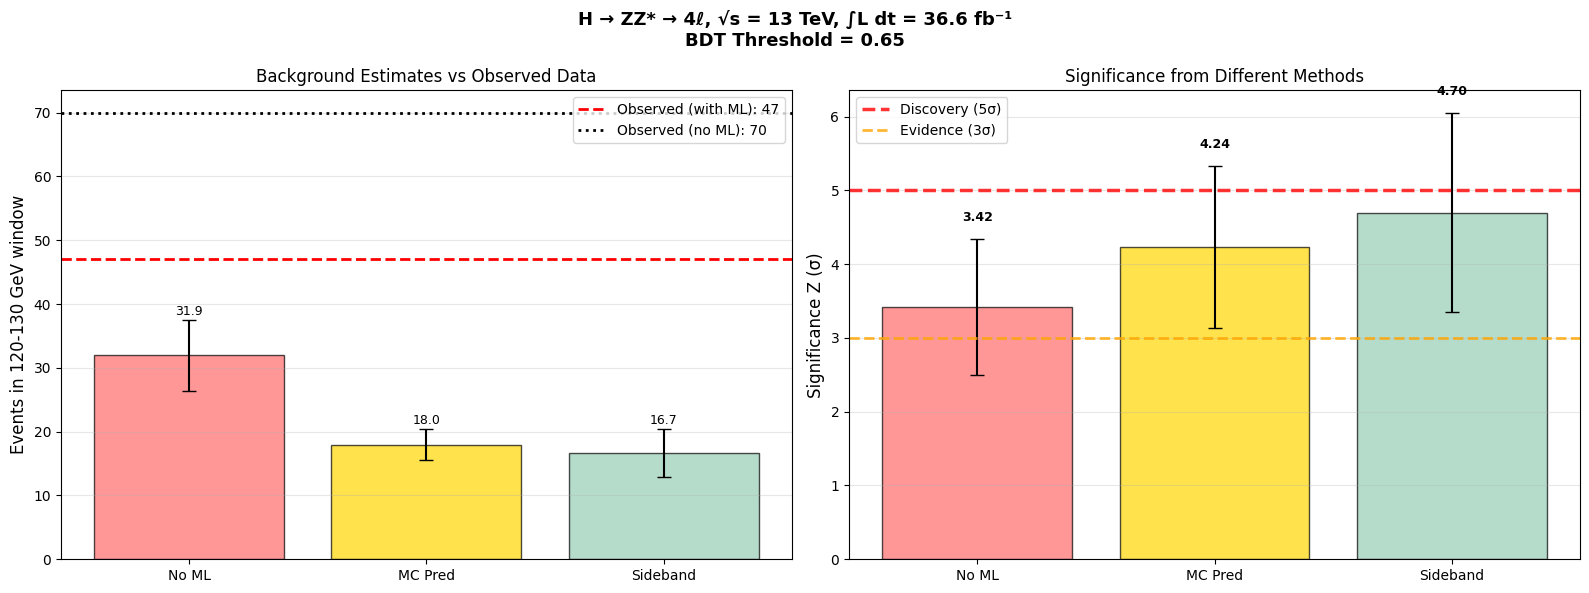

In [97]:
# ============================================================================
# ENHANCED PLOT: No ML, MC Prediction, Sideband
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Bar chart of background estimates
ax = axes[0]
methods_names_all = ['No ML', 'MC Pred', 'Sideband']
backgrounds_all = [B_noml, B_mc, B_sideband]
errors_all = [sigma_B_noml, sigma_B_mc, sigma_B_sideband]
colors_bkg_all = ['#FF6B6B', '#FFD700', '#96CEB4']

bars = ax.bar(methods_names_all, backgrounds_all, yerr=errors_all, capsize=5,
              color=colors_bkg_all, alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(N_obs, color='red', linestyle='--', linewidth=2,
           label=f'Observed (with ML): {N_obs}')
ax.axhline(N_obs_noml, color='black', linestyle=':', linewidth=2,
           label=f'Observed (no ML): {N_obs_noml}')
ax.set_ylabel('Events in 120-130 GeV window', fontsize=12)
ax.set_title('Background Estimates vs Observed Data', fontsize=12)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

for bar, b, err in zip(bars, backgrounds_all, errors_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.3,
            f'{b:.1f}', ha='center', va='bottom', fontsize=9)

# Right: Significance comparison with 5σ line
ax = axes[1]

z_values_all = [Z_noml, Z_mc, Z_sideband]
z_errors_all = [sigma_Z_noml, sigma_Z_mc, sigma_Z_sideband]

bars = ax.bar(methods_names_all, z_values_all, yerr=z_errors_all, capsize=5,
              color=colors_bkg_all, alpha=0.7, edgecolor='black', linewidth=1)

# Add 5σ discovery line
ax.axhline(5.0, color='red', linestyle='--', linewidth=2.5,
           alpha=0.8, label='Discovery (5σ)')
ax.axhline(3.0, color='orange', linestyle='--', linewidth=2,
           alpha=0.8, label='Evidence (3σ)')

ax.set_ylabel('Significance Z (σ)', fontsize=12)
ax.set_title('Significance from Different Methods', fontsize=12)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

for bar, z, err in zip(bars, z_values_all, z_errors_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.2,
            f'{z:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'H → ZZ* → 4ℓ, √s = 13 TeV, ∫L dt = {lumi} fb⁻¹\nBDT Threshold = {XR_THRESHOLD:.2f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("4.png", dpi=300, bbox_inches='tight')
plt.show()

In [98]:
# ============================================================================
# IMPROVEMENT SUMMARY
# ============================================================================
print("\n" + "="*70)
print("IMPROVEMENT SUMMARY: With ML vs Without ML")
print("="*70)

# MC signal before ML
sig_key = r'Signal ($m_H$ = 125 GeV)'
m_sig = z_masses[sig_key]['mass']
w_sig = z_masses[sig_key]['w']

sig_before_mask = (m_sig >= WIN_LO) & (m_sig < WIN_HI)
S_mc_before = w_sig[sig_before_mask].sum()

# MC signal after ML = true positives
sig_after_mask = (
    (y_mc == 1) &
    (oof_mc > XR_THRESHOLD) &
    (m_mc >= WIN_LO) &
    (m_mc < WIN_HI)
)
S_mc_after = w_mc[sig_after_mask].sum()

improvement = Z_mc / Z_noml if Z_noml > 0 else 0
bkg_rejection = (1 - B_mc / B_noml) * 100 if B_noml > 0 else 0
signal_eff = (S_mc_after / S_mc_before) * 100 if S_mc_before > 0 else 0

print(f"\n  Without ML:     Z = {Z_noml:.2f} ± {sigma_Z_noml:.2f}σ")
print(f"  With ML:        Z = {Z_mc:.2f} ± {sigma_Z_mc:.2f}σ")
print(f"\n  Improvement:    {improvement:.2f}x")
print(f"  Background rejection: {bkg_rejection:.1f}%")
print(f"  Signal efficiency:    {signal_eff:.1f}%")
print("="*70)

print("\nDone! - Complete comparison with No ML included")



IMPROVEMENT SUMMARY: With ML vs Without ML

  Without ML:     Z = 3.42 ± 0.92σ
  With ML:        Z = 4.24 ± 1.10σ

  Improvement:    1.24x
  Background rejection: 43.8%
  Signal efficiency:    96.2%

Done! - Complete comparison with No ML included


### 13.2 LightGBM on real data *(paper Table VII)*

MC events: 238517   sig: 226120   bkg: 12397
Real data events: 1279


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB fold 1/5  AUC=0.9741   best_iter=18   n_train=152650  n_val=38163  n_test=47704   [t=  7.2s]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB fold 2/5  AUC=0.9469   best_iter=180   n_train=152650  n_val=38163  n_test=47704   [t= 27.4s]


...

  LGB fold 3/5  AUC=0.9846   best_iter=133   n_train=152651  n_val=38163  n_test=47703   [t= 37.4s]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB fold 4/5  AUC=0.9807   best_iter=172   n_train=152651  n_val=38163  n_test=47703   [t= 47.7s]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB fold 5/5  AUC=0.9302   best_iter=46   n_train=152651  n_val=38163  n_test=47703   [t= 50.9s]

OOF AUC (MC, all events): 0.9541   per-fold 0.9633 ± 0.0211
Real data scored: 1279 events  (mean of 5 models; fold std = 0.0297)


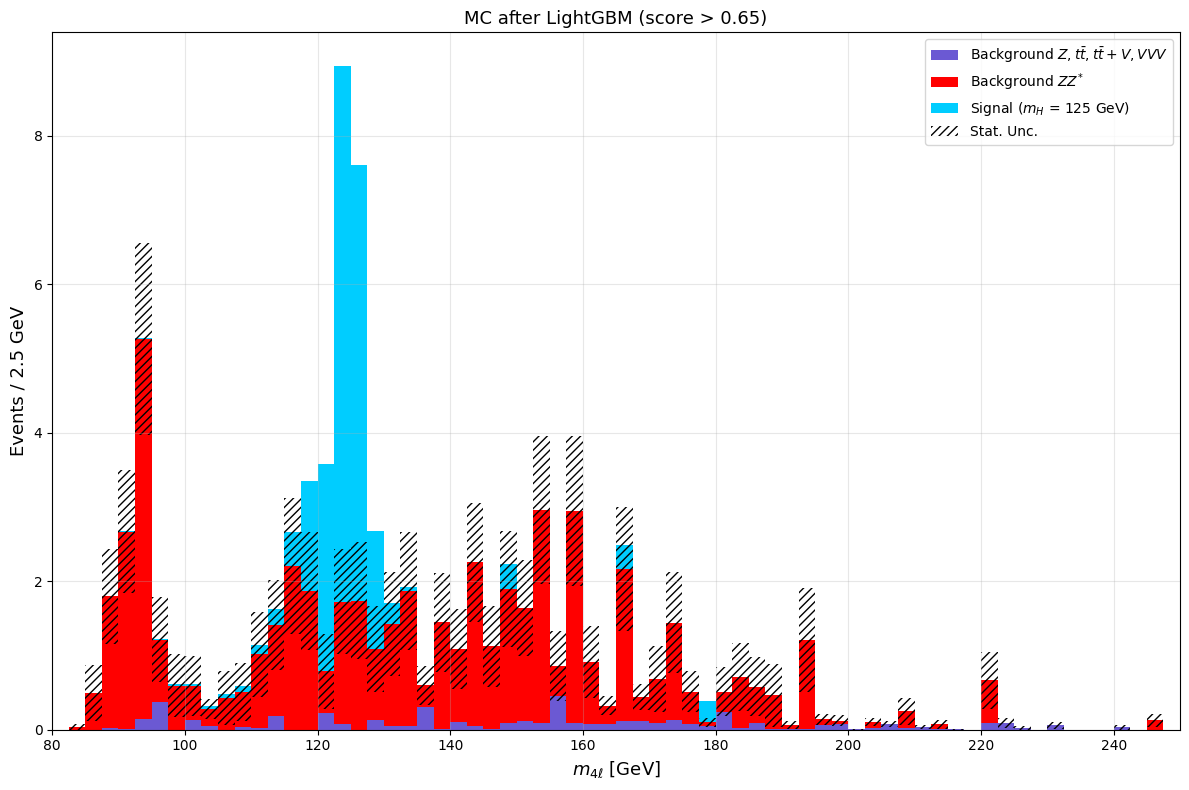

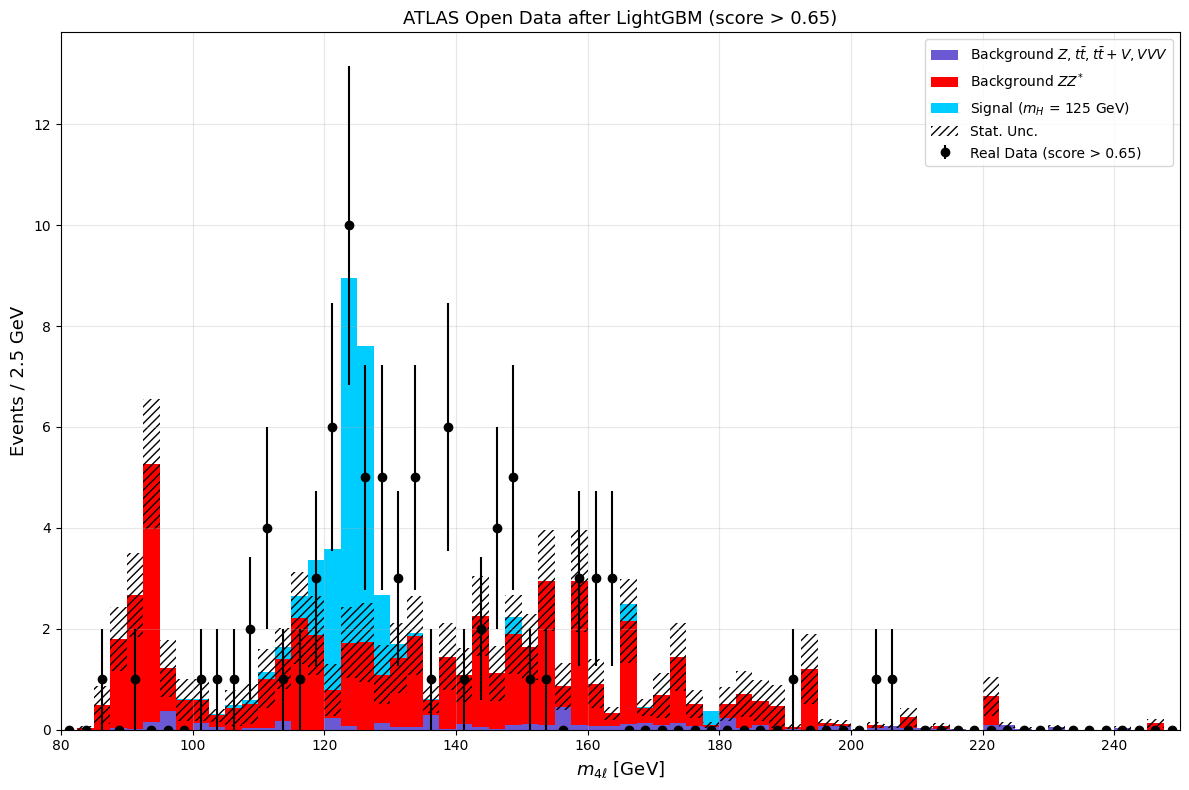

Data passing cut :     83
MC bkg (lumi)    :     59.29
MC signal (lumi) :     21.61


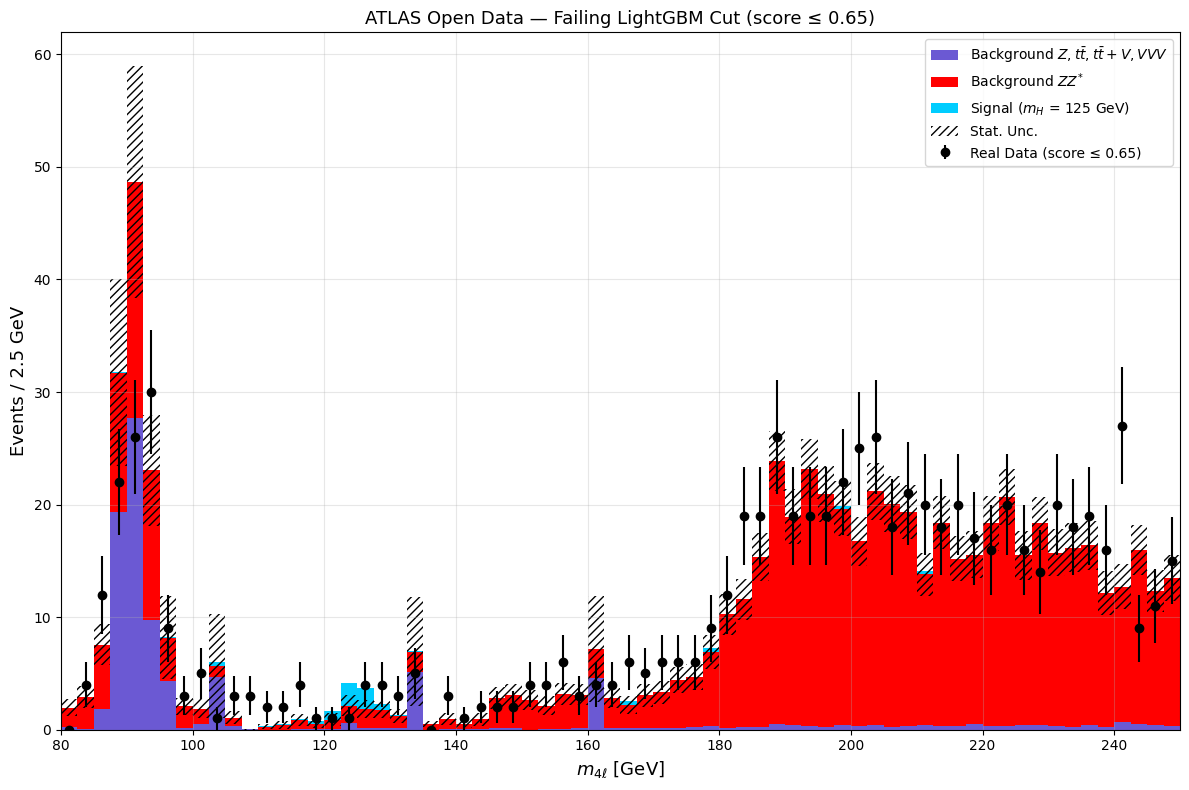

Data failing cut :   1196
MC bkg (lumi)    :   1135.41
MC signal (lumi) :      8.83

REAL DATA SIGNIFICANCE - LightGBM

Observed data events in [110, 135) GeV with score > 0.65: 43

------------------------------------------------------------
METHOD 0: Without ML (Mass Window Only)
------------------------------------------------------------
  Observed data (N_obs):           70 ± 8.4
  MC background (B_pred):          31.95 ± 5.62
  Signal excess:                   38.05
  Significance Z:                  3.42 ± 0.92σ
  p-value:                         3.13e-04

------------------------------------------------------------
METHOD 1: MC Background Prediction (False Positives)
------------------------------------------------------------
  Observed data (N_obs):           43 ± 6.6
  MC background (B_pred):          15.13 ± 2.23
  Signal excess:                   27.87
  Significance Z:                  4.66 ± 1.22σ
  p-value:                         1.55e-06

-----------------------------

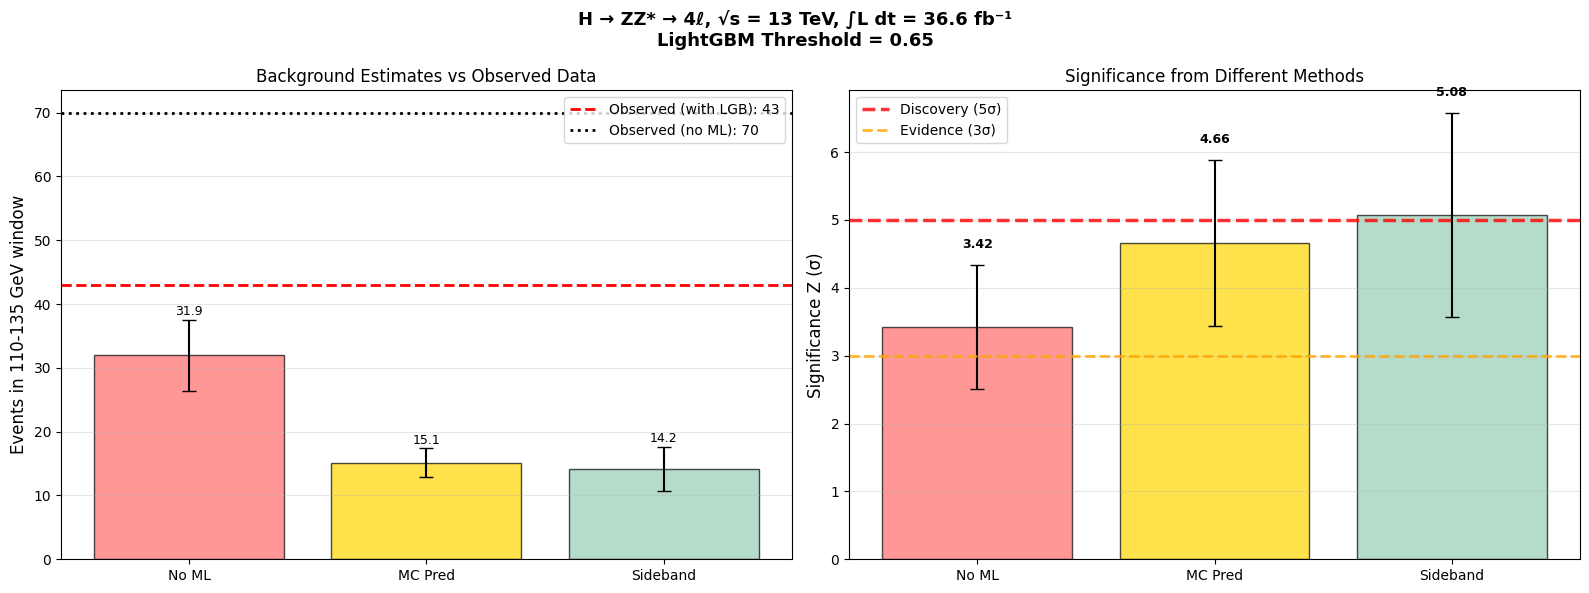


IMPROVEMENT SUMMARY: With LightGBM vs Without ML

  Without ML:     Z = 3.42 ± 0.92σ
  With LGB:       Z = 4.66 ± 1.22σ

  Improvement:    1.36x
  Background rejection: 52.6%
  Signal efficiency:    77.7%

Done! - LightGBM analysis complete


In [99]:
# ============================================================================
# LIGHTGBM: TRAIN PAIRED K-FOLD, SCORE MC OOF + REAL DATA ENSEMBLE
# ============================================================================

LGB_K          = 5
LGB_KFOLD_SEED = 42
LGB_MODEL_SEED = 42
LGB_THRESHOLD  = 0.65

# --- MC training arrays (with mass) ---
X_mc, y_mc, w_mc, m_mc = build_ml_dataset_with_mass(keep_sep)
print(f'MC events: {len(y_mc)}   sig: {int((y_mc==1).sum())}   bkg: {int((y_mc==0).sum())}')

# --- Real data feature matrix (reconstructed ONCE before the loop) ---
data_feats_lgb = reconstruct_z1_z2_fast(all_data['Data'])
X_data_lgb     = np.stack([np.asarray(data_feats_lgb[k]) for k in keep_sep], axis=1)
m_data_lgb     = np.asarray(data_feats_lgb['mass'])
print(f'Real data events: {len(X_data_lgb)}')

# --- k-fold loop ---
skf            = StratifiedKFold(n_splits=LGB_K, shuffle=True, random_state=LGB_KFOLD_SEED)
oof_lgb        = np.zeros(len(y_mc))
data_per_fold  = np.zeros((LGB_K, len(X_data_lgb)))
fold_aucs      = []
lgb_pipelines  = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):
    X_tr_full, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr_full, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr_full, w_te = w_mc[tr_idx], w_mc[te_idx]

    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_tr_full, y_tr_full, w_tr_full,
        test_size=0.20, random_state=LGB_KFOLD_SEED, stratify=y_tr_full,
    )

    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr)
    X_val_s  = scaler.transform(X_val)
    X_te_s   = scaler.transform(X_te)
    X_data_s = scaler.transform(X_data_lgb)

    spw = w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum()
    model = lgb.LGBMClassifier(
        n_estimators       = 500,
        max_depth          = 4,
        num_leaves         = 15,
        learning_rate      = 0.05,
        subsample          = 0.8,
        subsample_freq     = 1,
        colsample_bytree   = 0.8,
        min_child_samples  = 20,
        reg_lambda         = 1.0,
        reg_alpha          = 0.0,
        scale_pos_weight   = spw,
        objective          = 'binary',
        metric             = 'auc',
        random_state       = LGB_MODEL_SEED,
        n_jobs             = -1,
        verbose            = -1,
    )
    model.fit(
        X_tr_s, y_tr,
        sample_weight      = w_tr,
        eval_set           = [(X_val_s, y_val)],
        eval_sample_weight = [w_val],
        callbacks          = [lgb.early_stopping(stopping_rounds=20, verbose=False)],
    )

    oof_lgb[te_idx]         = model.predict_proba(X_te_s)[:, 1]
    data_per_fold[fold_idx] = model.predict_proba(X_data_s)[:, 1]
    fold_aucs.append(roc_auc_score(y_te, oof_lgb[te_idx], sample_weight=w_te))
    lgb_pipelines.append({'scaler': scaler, 'model': model})
    print(f'  LGB fold {fold_idx+1}/{LGB_K}  AUC={fold_aucs[-1]:.4f}   '
          f'best_iter={model.best_iteration_}   '
          f'n_train={len(X_tr)}  n_val={len(X_val)}  n_test={len(X_te)}   '
          f'[t={time.time()-t0:5.1f}s]')

# --- Aggregate scores ---
data_scores_lgb = data_per_fold.mean(axis=0)
oof_auc_lgb     = roc_auc_score(y_mc, oof_lgb, sample_weight=w_mc)

print()
print(f'OOF AUC (MC, all events): {oof_auc_lgb:.4f}   '
      f'per-fold {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')
print(f'Real data scored: {len(data_scores_lgb)} events  '
      f'(mean of {LGB_K} models; fold std = '
      f'{data_per_fold.std(axis=0).mean():.4f})')

# ============================================================================
# PLOT MC m4l DISTRIBUTION AFTER LIGHTGBM CUT
# ============================================================================
sig_key  = r'Signal ($m_H$ = 125 GeV)'
bkg_keys = [s for s in z_masses if s != sig_key]

# Rebuild bin edges locally so this cell does not depend on globals from
# section 4 still being alive in the kernel.
xmin, xmax, step_size = 80.0, 250.0, 2.5
bin_edges   = np.arange(xmin, xmax + step_size, step_size)
bin_centres = bin_edges[:-1] + step_size / 2

# Per-sample index map
_offsets = {}
_pos     = 0
_n_sig   = len(z_masses[sig_key]['mass'])
_offsets[sig_key] = (_pos, _pos + _n_sig)
_pos += _n_sig
for s in bkg_keys:
    n = len(z_masses[s]['mass'])
    _offsets[s] = (_pos, _pos + n)
    _pos += n
assert _pos == len(y_mc), f'offset mismatch {_pos} vs {len(y_mc)}'

def _per_sample_lgb(s):
    a, b = _offsets[s]
    return m_mc[a:b], w_mc[a:b], oof_lgb[a:b]

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample_lgb(s)
    sel = p_s > LGB_THRESHOLD
    mc_x.append(np.asarray(m_s[sel], dtype=float))
    mc_w.append(np.asarray(w_s[sel], dtype=float))
    mc_colors.append(samples[s]['color'])
    mc_labels.append(s)

m_sig_arr, w_sig_arr, p_sig_arr = _per_sample_lgb(sig_key)
sig_sel        = p_sig_arr > LGB_THRESHOLD
signal_x       = np.asarray(m_sig_arr[sig_sel], dtype=float)
signal_weights = np.asarray(w_sig_arr[sig_sel], dtype=float)
signal_color   = samples[sig_key]['color']

mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]
mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                              weights=np.hstack(mc_w)**2)[0])
ax.hist(signal_x, bins=bin_edges, weights=signal_weights, bottom=mc_tot,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'MC after LightGBM (score > {LGB_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lgb_mc.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT REAL DATA m4l DISTRIBUTION AFTER LIGHTGBM CUT
# ============================================================================
data_pass  = data_scores_lgb > LGB_THRESHOLD
data_mass  = m_data_lgb[data_pass]
data_x, _  = np.histogram(data_mass, bins=bin_edges)
data_x_err = np.sqrt(data_x)

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]
mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                              weights=np.hstack(mc_w)**2)[0])
ax.hist(signal_x, bins=bin_edges, weights=signal_weights, bottom=mc_tot,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')
ax.errorbar(bin_centres, data_x, yerr=data_x_err, fmt='ko',
            label=f'Real Data (score > {LGB_THRESHOLD})')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'ATLAS Open Data after LightGBM (score > {LGB_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lgb_data.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Data passing cut : {int(data_pass.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w):>9.2f}')
print(f'MC signal (lumi) : {signal_weights.sum():>9.2f}')

# ============================================================================
# PLOT REAL DATA m4l DISTRIBUTION FAILING LIGHTGBM CUT
# ============================================================================
mc_x_fail, mc_w_fail, mc_colors_fail, mc_labels_fail = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample_lgb(s)
    sel = p_s <= LGB_THRESHOLD
    mc_x_fail.append(np.asarray(m_s[sel], dtype=float))
    mc_w_fail.append(np.asarray(w_s[sel], dtype=float))
    mc_colors_fail.append(samples[s]['color'])
    mc_labels_fail.append(s)

sig_sel_fail        = p_sig_arr <= LGB_THRESHOLD
signal_x_fail       = np.asarray(m_sig_arr[sig_sel_fail], dtype=float)
signal_weights_fail = np.asarray(w_sig_arr[sig_sel_fail], dtype=float)

data_fail_mask  = data_scores_lgb <= LGB_THRESHOLD
data_mass_fail  = m_data_lgb[data_fail_mask]
data_x_fail, _  = np.histogram(data_mass_fail, bins=bin_edges)
data_x_fail_err = np.sqrt(data_x_fail)

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_heights_fail = ax.hist(mc_x_fail, bins=bin_edges, weights=mc_w_fail, stacked=True,
                          color=mc_colors_fail, label=mc_labels_fail)
mc_tot_fail = mc_heights_fail[0][-1]
mc_err_fail = np.sqrt(np.histogram(np.hstack(mc_x_fail), bins=bin_edges,
                                   weights=np.hstack(mc_w_fail)**2)[0])
ax.hist(signal_x_fail, bins=bin_edges, weights=signal_weights_fail, bottom=mc_tot_fail,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err_fail, bottom=mc_tot_fail - mc_err_fail, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')
ax.errorbar(bin_centres, data_x_fail, yerr=data_x_fail_err, fmt='ko',
            label=f'Real Data (score ≤ {LGB_THRESHOLD})')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'ATLAS Open Data — Failing LightGBM Cut (score ≤ {LGB_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lgb_data_fail.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Data failing cut : {int(data_fail_mask.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w_fail):>9.2f}')
print(f'MC signal (lumi) : {signal_weights_fail.sum():>9.2f}')

# ============================================================================
# SIGNIFICANCE ON REAL DATA — LIGHTGBM
# ============================================================================
print("\n" + "="*70)
print("REAL DATA SIGNIFICANCE - LightGBM")
print("="*70)

WIN_LO, WIN_HI = 110.0, 135.0
k_syst         = 0.30

data_in_win    = (m_data_lgb >= WIN_LO) & (m_data_lgb < WIN_HI)
data_in_win_ml = data_in_win & (data_scores_lgb > LGB_THRESHOLD)
N_obs          = int(data_in_win_ml.sum())
sigma_obs      = np.sqrt(N_obs)

print(f"\nObserved data events in [{WIN_LO:.0f}, {WIN_HI:.0f}) GeV with score > {LGB_THRESHOLD}: {N_obs}")

# ---------- METHOD 0: No ML ----------
print("\n" + "-"*60)
print("METHOD 0: Without ML (Mass Window Only)")
print("-"*60)

data_in_window_noml = (m_data_lgb >= WIN_LO) & (m_data_lgb < WIN_HI)
N_obs_noml          = int(data_in_window_noml.sum())
sigma_obs_noml      = np.sqrt(N_obs_noml)

bkg_total_noml, bkg_weight_sq_noml = 0.0, 0.0
for s in bkg_keys:
    m = z_masses[s]['mass']
    w = z_masses[s]['w']
    inw = (m >= WIN_LO) & (m < WIN_HI)
    bkg_total_noml     += float(w[inw].sum())
    bkg_weight_sq_noml += float((w[inw]**2).sum())

B_noml       = bkg_total_noml
sigma_B_noml = np.sqrt(bkg_weight_sq_noml)

S_excess_noml = N_obs_noml - B_noml
denom_noml    = B_noml + (k_syst * B_noml)**2
Z_noml        = S_excess_noml / np.sqrt(denom_noml)
term_obs      = sigma_obs_noml**2 / denom_noml
term_B        = (S_excess_noml**2 * (1 + 2*k_syst**2 * B_noml)**2 * sigma_B_noml**2) / (4 * denom_noml**3)
sigma_Z_noml  = np.sqrt(term_obs + term_B)
pvalue_noml   = norm.sf(Z_noml)

print(f"  Observed data (N_obs):           {N_obs_noml:.0f} ± {sigma_obs_noml:.1f}")
print(f"  MC background (B_pred):          {B_noml:.2f} ± {sigma_B_noml:.2f}")
print(f"  Signal excess:                   {S_excess_noml:.2f}")
print(f"  Significance Z:                  {Z_noml:.2f} ± {sigma_Z_noml:.2f}σ")
print(f"  p-value:                         {pvalue_noml:.2e}")

# ---------- METHOD 1: MC Background Prediction ----------
print("\n" + "-"*60)
print("METHOD 1: MC Background Prediction (False Positives)")
print("-"*60)

bkg_mask_mc  = (y_mc == 0) & (oof_lgb > LGB_THRESHOLD) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
B_mc         = w_mc[bkg_mask_mc].sum()
sigma_B_mc   = np.sqrt((w_mc[bkg_mask_mc]**2).sum())

S_excess_mc  = N_obs - B_mc
denom        = B_mc + (k_syst * B_mc)**2
Z_mc         = S_excess_mc / np.sqrt(denom)
term_obs     = sigma_obs**2 / denom
term_B       = (S_excess_mc**2 * (1 + 2*k_syst**2 * B_mc)**2 * sigma_B_mc**2) / (4 * denom**3)
sigma_Z_mc   = np.sqrt(term_obs + term_B)
pvalue_mc    = norm.sf(Z_mc)

print(f"  Observed data (N_obs):           {N_obs:.0f} ± {sigma_obs:.1f}")
print(f"  MC background (B_pred):          {B_mc:.2f} ± {sigma_B_mc:.2f}")
print(f"  Signal excess:                   {S_excess_mc:.2f}")
print(f"  Significance Z:                  {Z_mc:.2f} ± {sigma_Z_mc:.2f}σ")
print(f"  p-value:                         {pvalue_mc:.2e}")

# ---------- METHOD 2: Sideband ----------
print("\n" + "-"*60)
print("METHOD 2: Data-Driven (ML-Passed Mass Sidebands)")
print("-"*60)

LEFT_SB_LO,  LEFT_SB_HI  = 90.0,  105.0
RIGHT_SB_LO, RIGHT_SB_HI = 140.0, 155.0

left_sideband  = (m_data_lgb >= LEFT_SB_LO)  & (m_data_lgb < LEFT_SB_HI)  & (data_scores_lgb > LGB_THRESHOLD)
right_sideband = (m_data_lgb >= RIGHT_SB_LO) & (m_data_lgb < RIGHT_SB_HI) & (data_scores_lgb > LGB_THRESHOLD)

N_left           = int(left_sideband.sum())
N_right          = int(right_sideband.sum())
N_sideband_total = N_left + N_right
sideband_width   = (LEFT_SB_HI - LEFT_SB_LO) + (RIGHT_SB_HI - RIGHT_SB_LO)
signal_width     = WIN_HI - WIN_LO

B_sideband       = N_sideband_total * (signal_width / sideband_width)
sigma_B_sideband = np.sqrt(N_sideband_total) * (signal_width / sideband_width)

S_excess_sideband = N_obs - B_sideband
denom             = B_sideband + (k_syst * B_sideband)**2
if B_sideband > 0:
    Z_sideband       = S_excess_sideband / np.sqrt(denom)
    term_obs         = sigma_obs**2 / denom
    term_B           = (S_excess_sideband**2 * (1 + 2*k_syst**2 * B_sideband)**2 * sigma_B_sideband**2) / (4 * denom**3)
    sigma_Z_sideband = np.sqrt(term_obs + term_B)
    pvalue_sideband  = norm.sf(Z_sideband)
else:
    Z_sideband = sigma_Z_sideband = pvalue_sideband = np.nan

print(f"  Left sideband count passing ML:   {N_left}")
print(f"  Right sideband count passing ML:  {N_right}")
if N_right > 0:
    print(f"  Ratio left/right:                 {N_left/N_right:.2f}")
print(f"  Observed data in signal region:   {N_obs:.0f} ± {sigma_obs:.1f}")
print(f"  Background (width scaled):        {B_sideband:.2f} ± {sigma_B_sideband:.2f}")
print(f"  Signal excess:                    {S_excess_sideband:.2f}")
print(f"  Significance Z:                   {Z_sideband:.2f} ± {sigma_Z_sideband:.2f}σ")
print(f"  p-value:                          {pvalue_sideband:.2e}")

# ---------- SUMMARY TABLE ----------
print("\n" + "="*70)
print("SUMMARY - LightGBM: Comparison of All Methods")
print("="*70)
print(f"\n{'Method':<35} {'Background':>12} {'Z':>10} {'±σ':>8} {'p-value':>12}")
print("-" * 80)
print(f"{'No ML (mass window only)':<35} {B_noml:>12.2f} {Z_noml:>10.2f} ±{sigma_Z_noml:>7.2f} {pvalue_noml:>12.2e}")
print(f"{'MC Prediction (with LGB)':<35} {B_mc:>12.2f} {Z_mc:>10.2f} ±{sigma_Z_mc:>7.2f} {pvalue_mc:>12.2e}")
print(f"{'Sideband Extrapolation':<35} {B_sideband:>12.2f} {Z_sideband:>10.2f} ±{sigma_Z_sideband:>7.2f} {pvalue_sideband:>12.2e}")
print("-" * 80)

# ---------- COMPARISON PLOT ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods_names_all = ['No ML', 'MC Pred', 'Sideband']
backgrounds_all   = [B_noml, B_mc, B_sideband]
errors_all        = [sigma_B_noml, sigma_B_mc, sigma_B_sideband]
colors_bkg_all    = ['#FF6B6B', '#FFD700', '#96CEB4']

ax = axes[0]
bars = ax.bar(methods_names_all, backgrounds_all, yerr=errors_all, capsize=5,
              color=colors_bkg_all, alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(N_obs,      color='red',   linestyle='--', linewidth=2, label=f'Observed (with LGB): {N_obs}')
ax.axhline(N_obs_noml, color='black', linestyle=':',  linewidth=2, label=f'Observed (no ML): {N_obs_noml}')
ax.set_ylabel('Events in 110-135 GeV window', fontsize=12)
ax.set_title('Background Estimates vs Observed Data', fontsize=12)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
for bar, b, err in zip(bars, backgrounds_all, errors_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.3,
            f'{b:.1f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
z_values_all = [Z_noml, Z_mc, Z_sideband]
z_errors_all = [sigma_Z_noml, sigma_Z_mc, sigma_Z_sideband]
bars = ax.bar(methods_names_all, z_values_all, yerr=z_errors_all, capsize=5,
              color=colors_bkg_all, alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(5.0, color='red',    linestyle='--', linewidth=2.5, alpha=0.8, label='Discovery (5σ)')
ax.axhline(3.0, color='orange', linestyle='--', linewidth=2,   alpha=0.8, label='Evidence (3σ)')
ax.set_ylabel('Significance Z (σ)', fontsize=12)
ax.set_title('Significance from Different Methods', fontsize=12)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
for bar, z, err in zip(bars, z_values_all, z_errors_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.2,
            f'{z:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'H → ZZ* → 4ℓ, √s = 13 TeV, ∫L dt = {lumi} fb⁻¹\nLightGBM Threshold = {LGB_THRESHOLD:.2f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("lgb_summary.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------- IMPROVEMENT SUMMARY ----------
print("\n" + "="*70)
print("IMPROVEMENT SUMMARY: With LightGBM vs Without ML")
print("="*70)

m_sig = z_masses[sig_key]['mass']
w_sig = z_masses[sig_key]['w']
sig_before_mask = (m_sig >= WIN_LO) & (m_sig < WIN_HI)
S_mc_before     = w_sig[sig_before_mask].sum()

sig_after_mask = (y_mc == 1) & (oof_lgb > LGB_THRESHOLD) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
S_mc_after     = w_mc[sig_after_mask].sum()

improvement   = Z_mc / Z_noml             if Z_noml > 0     else 0
bkg_rejection = (1 - B_mc / B_noml) * 100 if B_noml > 0     else 0
signal_eff    = (S_mc_after / S_mc_before) * 100 if S_mc_before > 0 else 0

print(f"\n  Without ML:     Z = {Z_noml:.2f} ± {sigma_Z_noml:.2f}σ")
print(f"  With LGB:       Z = {Z_mc:.2f} ± {sigma_Z_mc:.2f}σ")
print(f"\n  Improvement:    {improvement:.2f}x")
print(f"  Background rejection: {bkg_rejection:.1f}%")
print(f"  Signal efficiency:    {signal_eff:.1f}%")
print("="*70)
print("\nDone! - LightGBM analysis complete")

### 13.3 Random Forest on real data *(paper Table VII)*

MC events: 238517   sig: 226120   bkg: 12397
Real data events: 1279
  RF fold 1/5  AUC=0.9775   n_train=190813  n_test=47704   [t=339.9s]
  RF fold 2/5  AUC=0.9450   n_train=190813  n_test=47704   [t=733.2s]
  RF fold 3/5  AUC=0.9838   n_train=190814  n_test=47703   [t=1042.7s]
  RF fold 4/5  AUC=0.9761   n_train=190814  n_test=47703   [t=1360.7s]
  RF fold 5/5  AUC=0.9181   n_train=190814  n_test=47703   [t=1657.1s]

OOF AUC (MC, all events): 0.9587   per-fold 0.9601 ± 0.0250
Real data scored: 1279 events  (mean of 5 models; fold std = 0.0095)


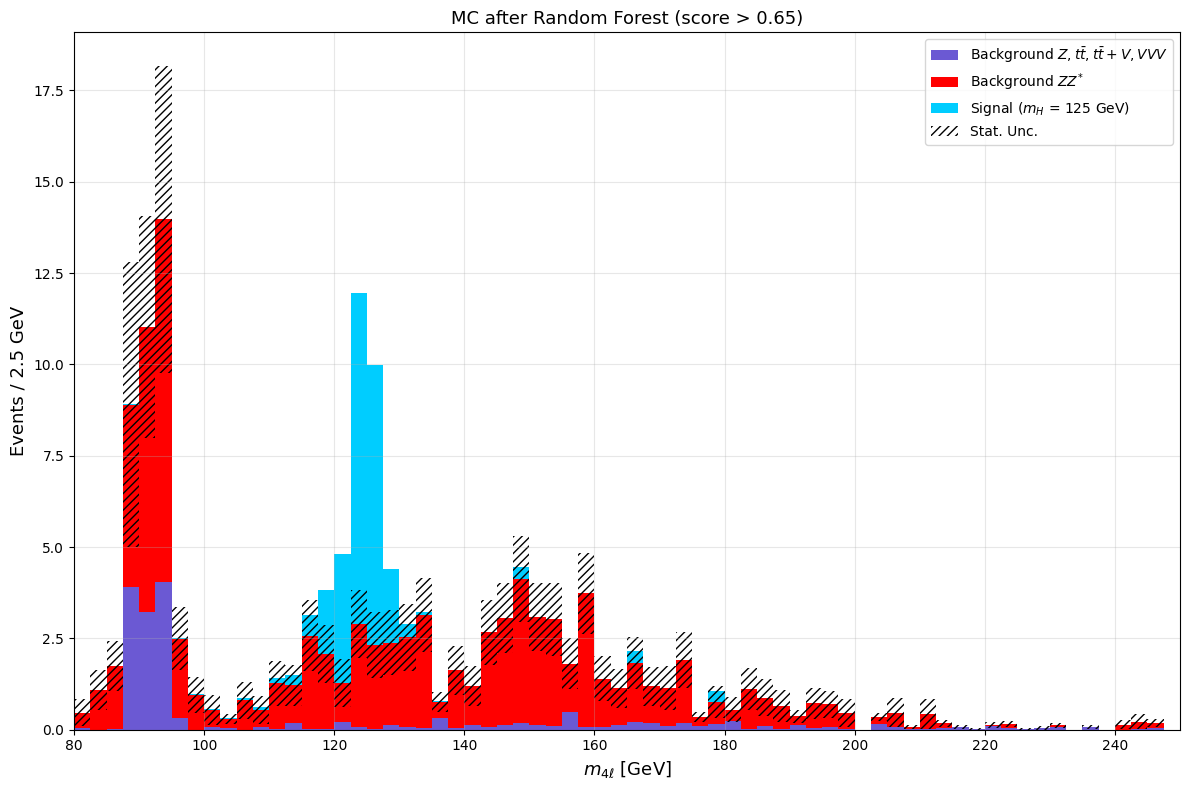

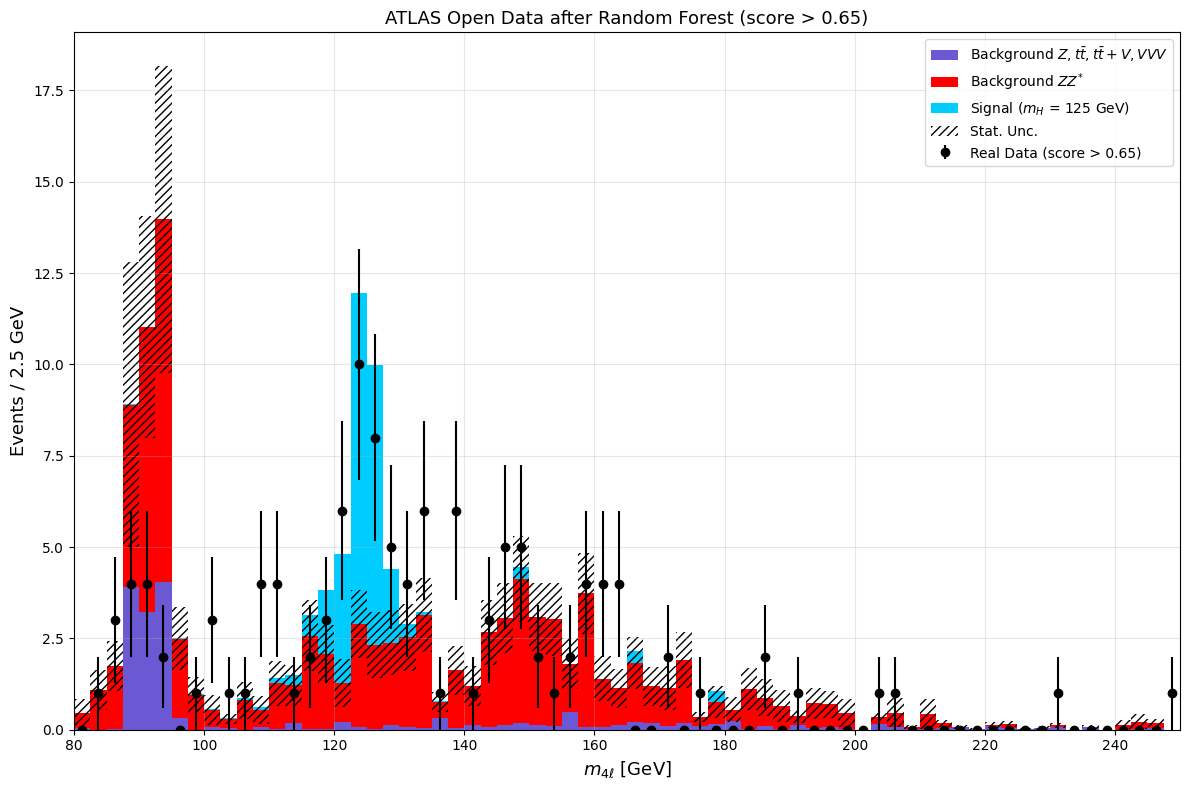

Data passing cut :    122
MC bkg (lumi)    :    108.14
MC signal (lumi) :     26.83


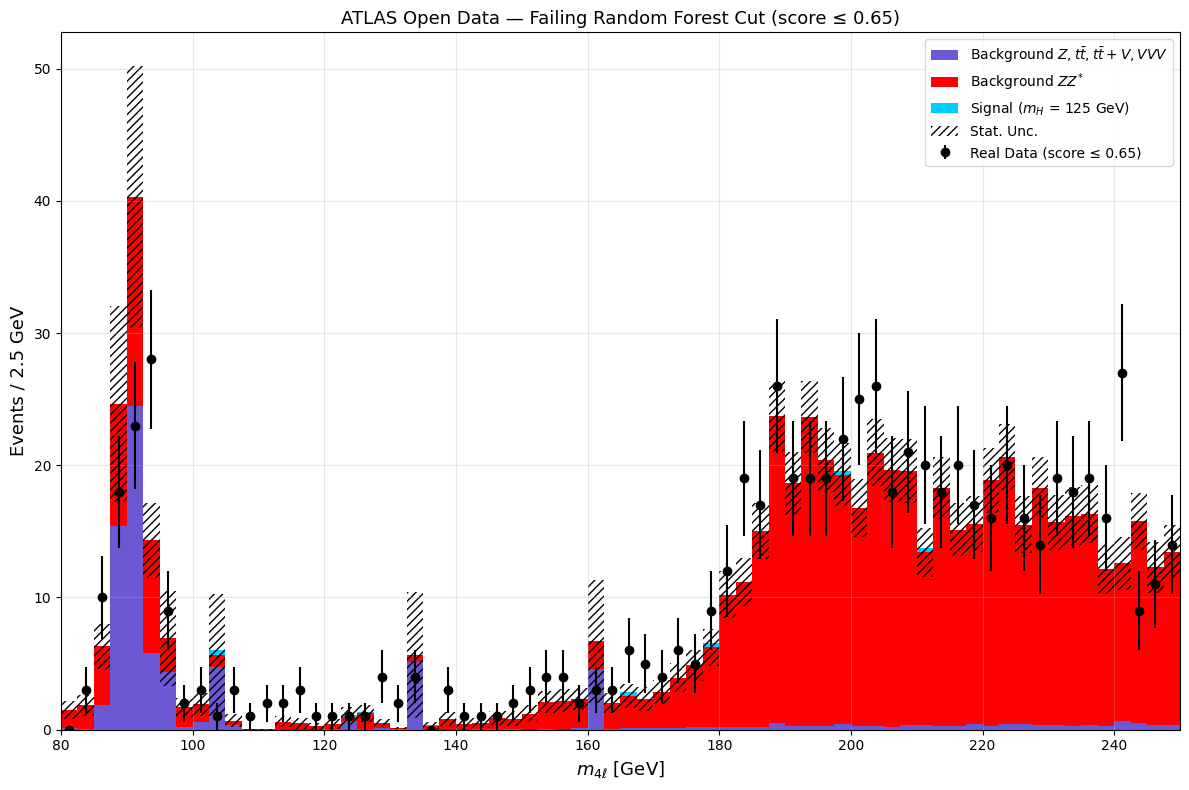

Data failing cut :   1157
MC bkg (lumi)    :   1086.56
MC signal (lumi) :      3.60

REAL DATA SIGNIFICANCE - Random Forest

Observed data events in [110, 135) GeV with score > 0.65: 49

------------------------------------------------------------
METHOD 0: Without ML (Mass Window Only)
------------------------------------------------------------
  Observed data (N_obs):           70 ± 8.4
  MC background (B_pred):          31.95 ± 5.62
  Signal excess:                   38.05
  Significance Z:                  3.42 ± 0.92σ
  p-value:                         3.13e-04

------------------------------------------------------------
METHOD 1: MC Background Prediction (False Positives)
------------------------------------------------------------
  Observed data (N_obs):           49 ± 7.0
  MC background (B_pred):          21.66 ± 2.65
  Signal excess:                   27.34
  Significance Z:                  3.42 ± 0.94σ
  p-value:                         3.11e-04

------------------------

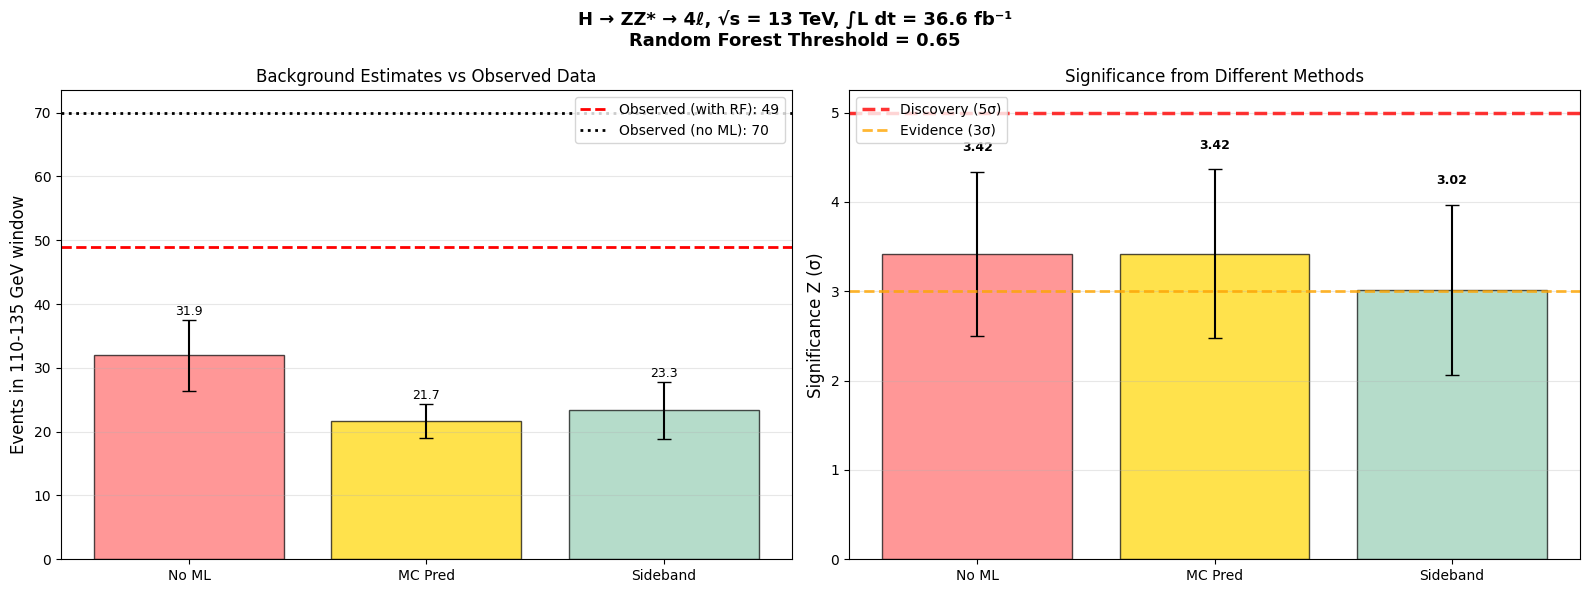


IMPROVEMENT SUMMARY: With Random Forest vs Without ML

  Without ML:     Z = 3.42 ± 0.92σ
  With RF:        Z = 3.42 ± 0.94σ

  Improvement:    1.00x
  Background rejection: 32.2%
  Signal efficiency:    98.7%

Done! - Random Forest analysis complete


In [100]:
# ============================================================================
# RANDOM FOREST: TRAIN PAIRED K-FOLD, SCORE MC OOF + REAL DATA ENSEMBLE
# ============================================================================

RF_K          = 5
RF_KFOLD_SEED = 42
RF_THRESHOLD  = 0.65            # adjust if your threshold scan suggests a different optimum

# --- MC arrays (reuse if already built; otherwise rebuild) ---
# X_mc, y_mc, w_mc, m_mc = build_ml_dataset_with_mass(keep_sep)
print(f'MC events: {len(y_mc)}   sig: {int((y_mc==1).sum())}   bkg: {int((y_mc==0).sum())}')

# --- Real data feature matrix (reconstructed ONCE before the loop) ---
data_feats_rf = reconstruct_z1_z2_fast(all_data['Data'])
X_data_rf     = np.stack([np.asarray(data_feats_rf[k]) for k in keep_sep], axis=1)
m_data_rf     = np.asarray(data_feats_rf['mass'])
print(f'Real data events: {len(X_data_rf)}')

# --- k-fold loop: train RF on MC, score MC OOF + real data ---
skf            = StratifiedKFold(n_splits=RF_K, shuffle=True, random_state=RF_KFOLD_SEED)
oof_rf         = np.zeros(len(y_mc))
data_per_fold  = np.zeros((RF_K, len(X_data_rf)))
fold_aucs_rf   = []
rf_pipelines   = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):
    X_tr, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr, w_te = w_mc[tr_idx], w_mc[te_idx]

    # Scale signal weights to match background total — same as the OOF cell
    w_scaled = w_tr.copy()
    w_scaled[y_tr == 1] *= (w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum())

    # RF is scale-invariant — no StandardScaler. Fit on raw features.
    clf = RandomForestClassifier(
        n_estimators     = 500,
        max_depth        = 8,
        min_samples_leaf = 20,
        n_jobs           = -1,
        random_state     = 42,
    )
    clf.fit(X_tr, y_tr, sample_weight=w_scaled)

    oof_rf[te_idx]          = clf.predict_proba(X_te)[:, 1]
    data_per_fold[fold_idx] = clf.predict_proba(X_data_rf)[:, 1]
    fold_aucs_rf.append(roc_auc_score(y_te, oof_rf[te_idx], sample_weight=w_te))
    rf_pipelines.append({'model': clf})
    print(f'  RF fold {fold_idx+1}/{RF_K}  AUC={fold_aucs_rf[-1]:.4f}   '
          f'n_train={len(X_tr)}  n_test={len(X_te)}   [t={time.time()-t0:5.1f}s]')

# --- Aggregate scores ---
data_scores_rf = data_per_fold.mean(axis=0)
oof_auc_rf     = roc_auc_score(y_mc, oof_rf, sample_weight=w_mc)

print()
print(f'OOF AUC (MC, all events): {oof_auc_rf:.4f}   '
      f'per-fold {np.mean(fold_aucs_rf):.4f} ± {np.std(fold_aucs_rf):.4f}')
print(f'Real data scored: {len(data_scores_rf)} events  '
      f'(mean of {RF_K} models; fold std = '
      f'{data_per_fold.std(axis=0).mean():.4f})')

# ============================================================================
# PLOT MC m4l DISTRIBUTION AFTER RF CUT
# ============================================================================
sig_key  = r'Signal ($m_H$ = 125 GeV)'
bkg_keys = [s for s in z_masses if s != sig_key]

# Rebuild bin edges locally so this cell does not depend on globals from
# section 4 still being alive in the kernel.
xmin, xmax, step_size = 80.0, 250.0, 2.5
bin_edges   = np.arange(xmin, xmax + step_size, step_size)
bin_centres = bin_edges[:-1] + step_size / 2

# Per-sample index map
_offsets = {}
_pos     = 0
_n_sig   = len(z_masses[sig_key]['mass'])
_offsets[sig_key] = (_pos, _pos + _n_sig)
_pos += _n_sig
for s in bkg_keys:
    n = len(z_masses[s]['mass'])
    _offsets[s] = (_pos, _pos + n)
    _pos += n
assert _pos == len(y_mc), f'offset mismatch {_pos} vs {len(y_mc)}'

def _per_sample_rf(s):
    a, b = _offsets[s]
    return m_mc[a:b], w_mc[a:b], oof_rf[a:b]

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

# Stacked MC backgrounds after cut
mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample_rf(s)
    sel = p_s > RF_THRESHOLD
    mc_x.append(np.asarray(m_s[sel], dtype=float))
    mc_w.append(np.asarray(w_s[sel], dtype=float))
    mc_colors.append(samples[s]['color'])
    mc_labels.append(s)

# Signal after cut
m_sig_arr, w_sig_arr, p_sig_arr = _per_sample_rf(sig_key)
sig_sel        = p_sig_arr > RF_THRESHOLD
signal_x       = np.asarray(m_sig_arr[sig_sel], dtype=float)
signal_weights = np.asarray(w_sig_arr[sig_sel], dtype=float)
signal_color   = samples[sig_key]['color']

mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]
mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                              weights=np.hstack(mc_w)**2)[0])
ax.hist(signal_x, bins=bin_edges, weights=signal_weights, bottom=mc_tot,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'MC after Random Forest (score > {RF_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rf_mc.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT REAL DATA m4l DISTRIBUTION AFTER RF CUT
# ============================================================================
data_pass  = data_scores_rf > RF_THRESHOLD
data_mass  = m_data_rf[data_pass]
data_x, _  = np.histogram(data_mass, bins=bin_edges)
data_x_err = np.sqrt(data_x)

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]
mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                              weights=np.hstack(mc_w)**2)[0])
ax.hist(signal_x, bins=bin_edges, weights=signal_weights, bottom=mc_tot,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')
ax.errorbar(bin_centres, data_x, yerr=data_x_err, fmt='ko',
            label=f'Real Data (score > {RF_THRESHOLD})')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'ATLAS Open Data after Random Forest (score > {RF_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rf_data.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Data passing cut : {int(data_pass.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w):>9.2f}')
print(f'MC signal (lumi) : {signal_weights.sum():>9.2f}')

# ============================================================================
# PLOT REAL DATA m4l DISTRIBUTION FAILING RF CUT
# ============================================================================
mc_x_fail, mc_w_fail, mc_colors_fail, mc_labels_fail = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample_rf(s)
    sel = p_s <= RF_THRESHOLD
    mc_x_fail.append(np.asarray(m_s[sel], dtype=float))
    mc_w_fail.append(np.asarray(w_s[sel], dtype=float))
    mc_colors_fail.append(samples[s]['color'])
    mc_labels_fail.append(s)

sig_sel_fail        = p_sig_arr <= RF_THRESHOLD
signal_x_fail       = np.asarray(m_sig_arr[sig_sel_fail], dtype=float)
signal_weights_fail = np.asarray(w_sig_arr[sig_sel_fail], dtype=float)

data_fail_mask  = data_scores_rf <= RF_THRESHOLD
data_mass_fail  = m_data_rf[data_fail_mask]
data_x_fail, _  = np.histogram(data_mass_fail, bins=bin_edges)
data_x_fail_err = np.sqrt(data_x_fail)

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_heights_fail = ax.hist(mc_x_fail, bins=bin_edges, weights=mc_w_fail, stacked=True,
                          color=mc_colors_fail, label=mc_labels_fail)
mc_tot_fail = mc_heights_fail[0][-1]
mc_err_fail = np.sqrt(np.histogram(np.hstack(mc_x_fail), bins=bin_edges,
                                   weights=np.hstack(mc_w_fail)**2)[0])
ax.hist(signal_x_fail, bins=bin_edges, weights=signal_weights_fail, bottom=mc_tot_fail,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err_fail, bottom=mc_tot_fail - mc_err_fail, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')
ax.errorbar(bin_centres, data_x_fail, yerr=data_x_fail_err, fmt='ko',
            label=f'Real Data (score ≤ {RF_THRESHOLD})')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'ATLAS Open Data — Failing Random Forest Cut (score ≤ {RF_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rf_data_fail.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Data failing cut : {int(data_fail_mask.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w_fail):>9.2f}')
print(f'MC signal (lumi) : {signal_weights_fail.sum():>9.2f}')

# ============================================================================
# SIGNIFICANCE ON REAL DATA — RANDOM FOREST
# ============================================================================
print("\n" + "="*70)
print("REAL DATA SIGNIFICANCE - Random Forest")
print("="*70)

WIN_LO, WIN_HI = 110.0, 135.0
k_syst         = 0.30

data_in_win    = (m_data_rf >= WIN_LO) & (m_data_rf < WIN_HI)
data_in_win_ml = data_in_win & (data_scores_rf > RF_THRESHOLD)
N_obs          = int(data_in_win_ml.sum())
sigma_obs      = np.sqrt(N_obs)

print(f"\nObserved data events in [{WIN_LO:.0f}, {WIN_HI:.0f}) GeV with score > {RF_THRESHOLD}: {N_obs}")

# ---------- METHOD 0: No ML ----------
print("\n" + "-"*60)
print("METHOD 0: Without ML (Mass Window Only)")
print("-"*60)

data_in_window_noml = (m_data_rf >= WIN_LO) & (m_data_rf < WIN_HI)
N_obs_noml          = int(data_in_window_noml.sum())
sigma_obs_noml      = np.sqrt(N_obs_noml)

bkg_total_noml, bkg_weight_sq_noml = 0.0, 0.0
for s in bkg_keys:
    m = z_masses[s]['mass']
    w = z_masses[s]['w']
    inw = (m >= WIN_LO) & (m < WIN_HI)
    bkg_total_noml     += float(w[inw].sum())
    bkg_weight_sq_noml += float((w[inw]**2).sum())

B_noml       = bkg_total_noml
sigma_B_noml = np.sqrt(bkg_weight_sq_noml)

S_excess_noml = N_obs_noml - B_noml
denom_noml    = B_noml + (k_syst * B_noml)**2
Z_noml        = S_excess_noml / np.sqrt(denom_noml)
term_obs      = sigma_obs_noml**2 / denom_noml
term_B        = (S_excess_noml**2 * (1 + 2*k_syst**2 * B_noml)**2 * sigma_B_noml**2) / (4 * denom_noml**3)
sigma_Z_noml  = np.sqrt(term_obs + term_B)
pvalue_noml   = norm.sf(Z_noml)

print(f"  Observed data (N_obs):           {N_obs_noml:.0f} ± {sigma_obs_noml:.1f}")
print(f"  MC background (B_pred):          {B_noml:.2f} ± {sigma_B_noml:.2f}")
print(f"  Signal excess:                   {S_excess_noml:.2f}")
print(f"  Significance Z:                  {Z_noml:.2f} ± {sigma_Z_noml:.2f}σ")
print(f"  p-value:                         {pvalue_noml:.2e}")

# ---------- METHOD 1: MC Background Prediction ----------
print("\n" + "-"*60)
print("METHOD 1: MC Background Prediction (False Positives)")
print("-"*60)

bkg_mask_mc  = (y_mc == 0) & (oof_rf > RF_THRESHOLD) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
B_mc         = w_mc[bkg_mask_mc].sum()
sigma_B_mc   = np.sqrt((w_mc[bkg_mask_mc]**2).sum())

S_excess_mc  = N_obs - B_mc
denom        = B_mc + (k_syst * B_mc)**2
Z_mc         = S_excess_mc / np.sqrt(denom)
term_obs     = sigma_obs**2 / denom
term_B       = (S_excess_mc**2 * (1 + 2*k_syst**2 * B_mc)**2 * sigma_B_mc**2) / (4 * denom**3)
sigma_Z_mc   = np.sqrt(term_obs + term_B)
pvalue_mc    = norm.sf(Z_mc)

print(f"  Observed data (N_obs):           {N_obs:.0f} ± {sigma_obs:.1f}")
print(f"  MC background (B_pred):          {B_mc:.2f} ± {sigma_B_mc:.2f}")
print(f"  Signal excess:                   {S_excess_mc:.2f}")
print(f"  Significance Z:                  {Z_mc:.2f} ± {sigma_Z_mc:.2f}σ")
print(f"  p-value:                         {pvalue_mc:.2e}")

# ---------- METHOD 2: Sideband ----------
print("\n" + "-"*60)
print("METHOD 2: Data-Driven (ML-Passed Mass Sidebands)")
print("-"*60)

LEFT_SB_LO,  LEFT_SB_HI  = 90.0,  105.0
RIGHT_SB_LO, RIGHT_SB_HI = 140.0, 155.0

left_sideband  = (m_data_rf >= LEFT_SB_LO)  & (m_data_rf < LEFT_SB_HI)  & (data_scores_rf > RF_THRESHOLD)
right_sideband = (m_data_rf >= RIGHT_SB_LO) & (m_data_rf < RIGHT_SB_HI) & (data_scores_rf > RF_THRESHOLD)

N_left           = int(left_sideband.sum())
N_right          = int(right_sideband.sum())
N_sideband_total = N_left + N_right
sideband_width   = (LEFT_SB_HI - LEFT_SB_LO) + (RIGHT_SB_HI - RIGHT_SB_LO)
signal_width     = WIN_HI - WIN_LO

B_sideband       = N_sideband_total * (signal_width / sideband_width)
sigma_B_sideband = np.sqrt(N_sideband_total) * (signal_width / sideband_width)

S_excess_sideband = N_obs - B_sideband
denom             = B_sideband + (k_syst * B_sideband)**2
if B_sideband > 0:
    Z_sideband       = S_excess_sideband / np.sqrt(denom)
    term_obs         = sigma_obs**2 / denom
    term_B           = (S_excess_sideband**2 * (1 + 2*k_syst**2 * B_sideband)**2 * sigma_B_sideband**2) / (4 * denom**3)
    sigma_Z_sideband = np.sqrt(term_obs + term_B)
    pvalue_sideband  = norm.sf(Z_sideband)
else:
    Z_sideband = sigma_Z_sideband = pvalue_sideband = np.nan

print(f"  Left sideband count passing ML:   {N_left}")
print(f"  Right sideband count passing ML:  {N_right}")
if N_right > 0:
    print(f"  Ratio left/right:                 {N_left/N_right:.2f}")
print(f"  Observed data in signal region:   {N_obs:.0f} ± {sigma_obs:.1f}")
print(f"  Background (width scaled):        {B_sideband:.2f} ± {sigma_B_sideband:.2f}")
print(f"  Signal excess:                    {S_excess_sideband:.2f}")
print(f"  Significance Z:                   {Z_sideband:.2f} ± {sigma_Z_sideband:.2f}σ")
print(f"  p-value:                          {pvalue_sideband:.2e}")

# ---------- SUMMARY TABLE ----------
print("\n" + "="*70)
print("SUMMARY - Random Forest: Comparison of All Methods")
print("="*70)
print(f"\n{'Method':<35} {'Background':>12} {'Z':>10} {'±σ':>8} {'p-value':>12}")
print("-" * 80)
print(f"{'No ML (mass window only)':<35} {B_noml:>12.2f} {Z_noml:>10.2f} ±{sigma_Z_noml:>7.2f} {pvalue_noml:>12.2e}")
print(f"{'MC Prediction (with RF)':<35} {B_mc:>12.2f} {Z_mc:>10.2f} ±{sigma_Z_mc:>7.2f} {pvalue_mc:>12.2e}")
print(f"{'Sideband Extrapolation':<35} {B_sideband:>12.2f} {Z_sideband:>10.2f} ±{sigma_Z_sideband:>7.2f} {pvalue_sideband:>12.2e}")
print("-" * 80)

# ---------- COMPARISON PLOT ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods_names_all = ['No ML', 'MC Pred', 'Sideband']
backgrounds_all   = [B_noml, B_mc, B_sideband]
errors_all        = [sigma_B_noml, sigma_B_mc, sigma_B_sideband]
colors_bkg_all    = ['#FF6B6B', '#FFD700', '#96CEB4']

ax = axes[0]
bars = ax.bar(methods_names_all, backgrounds_all, yerr=errors_all, capsize=5,
              color=colors_bkg_all, alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(N_obs,      color='red',   linestyle='--', linewidth=2, label=f'Observed (with RF): {N_obs}')
ax.axhline(N_obs_noml, color='black', linestyle=':',  linewidth=2, label=f'Observed (no ML): {N_obs_noml}')
ax.set_ylabel('Events in 110-135 GeV window', fontsize=12)
ax.set_title('Background Estimates vs Observed Data', fontsize=12)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
for bar, b, err in zip(bars, backgrounds_all, errors_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.3,
            f'{b:.1f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
z_values_all = [Z_noml, Z_mc, Z_sideband]
z_errors_all = [sigma_Z_noml, sigma_Z_mc, sigma_Z_sideband]
bars = ax.bar(methods_names_all, z_values_all, yerr=z_errors_all, capsize=5,
              color=colors_bkg_all, alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(5.0, color='red',    linestyle='--', linewidth=2.5, alpha=0.8, label='Discovery (5σ)')
ax.axhline(3.0, color='orange', linestyle='--', linewidth=2,   alpha=0.8, label='Evidence (3σ)')
ax.set_ylabel('Significance Z (σ)', fontsize=12)
ax.set_title('Significance from Different Methods', fontsize=12)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
for bar, z, err in zip(bars, z_values_all, z_errors_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.2,
            f'{z:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'H → ZZ* → 4ℓ, √s = 13 TeV, ∫L dt = {lumi} fb⁻¹\nRandom Forest Threshold = {RF_THRESHOLD:.2f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("rf_summary.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------- IMPROVEMENT SUMMARY ----------
print("\n" + "="*70)
print("IMPROVEMENT SUMMARY: With Random Forest vs Without ML")
print("="*70)

m_sig = z_masses[sig_key]['mass']
w_sig = z_masses[sig_key]['w']
sig_before_mask = (m_sig >= WIN_LO) & (m_sig < WIN_HI)
S_mc_before     = w_sig[sig_before_mask].sum()

sig_after_mask = (y_mc == 1) & (oof_rf > RF_THRESHOLD) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
S_mc_after     = w_mc[sig_after_mask].sum()

improvement   = Z_mc / Z_noml             if Z_noml > 0     else 0
bkg_rejection = (1 - B_mc / B_noml) * 100 if B_noml > 0     else 0
signal_eff    = (S_mc_after / S_mc_before) * 100 if S_mc_before > 0 else 0

print(f"\n  Without ML:     Z = {Z_noml:.2f} ± {sigma_Z_noml:.2f}σ")
print(f"  With RF:        Z = {Z_mc:.2f} ± {sigma_Z_mc:.2f}σ")
print(f"\n  Improvement:    {improvement:.2f}x")
print(f"  Background rejection: {bkg_rejection:.1f}%")
print(f"  Signal efficiency:    {signal_eff:.1f}%")
print("="*70)
print("\nDone! - Random Forest analysis complete")

### 13.4 MLP on real data *(paper Table VII)*

MC events: 238517   sig: 226120   bkg: 12397
Real data events: 1279
  MLP fold 1/5  AUC=0.9774   epochs=13  n_train=152650  n_val=38163  n_test=47704   [t= 29.2s]
  MLP fold 2/5  AUC=0.9081   epochs=23  n_train=152650  n_val=38163  n_test=47704   [t= 77.6s]
  MLP fold 3/5  AUC=0.9771   epochs=13  n_train=152651  n_val=38163  n_test=47703   [t=112.4s]
  MLP fold 4/5  AUC=0.9671   epochs=11  n_train=152651  n_val=38163  n_test=47703   [t=138.0s]
  MLP fold 5/5  AUC=0.9256   epochs=11  n_train=152651  n_val=38163  n_test=47703   [t=164.0s]

OOF AUC (MC, all events): 0.9393   per-fold 0.9510 ± 0.0287
Real data scored: 1279 events  (mean of 5 models; fold std = 0.0622)


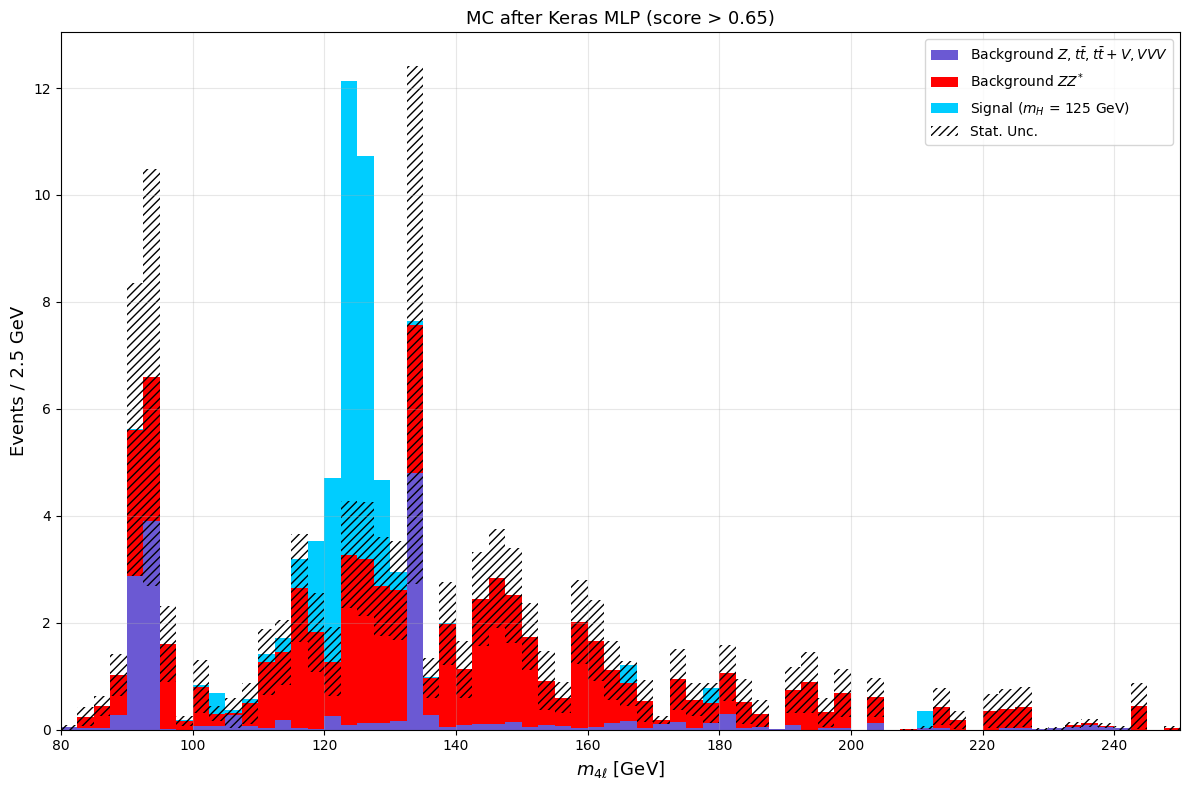

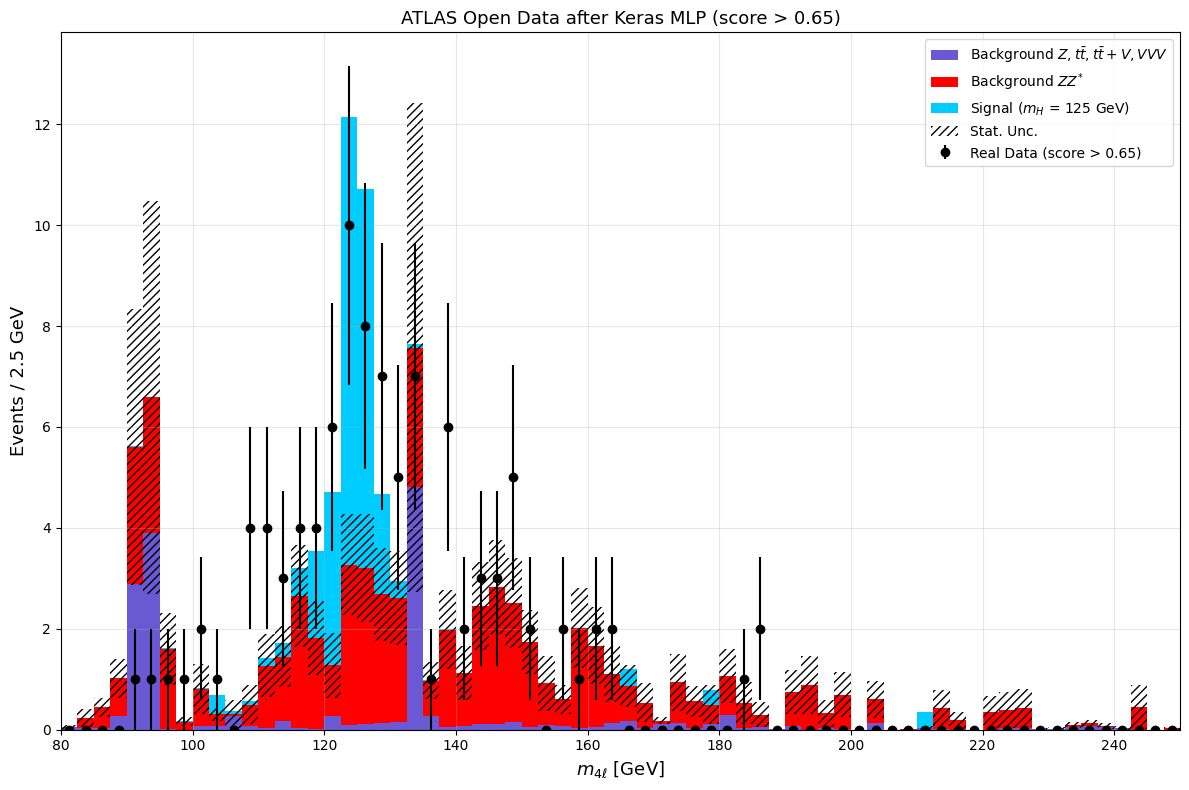

Data passing cut :    101
MC bkg (lumi)    :     79.86
MC signal (lumi) :     26.47


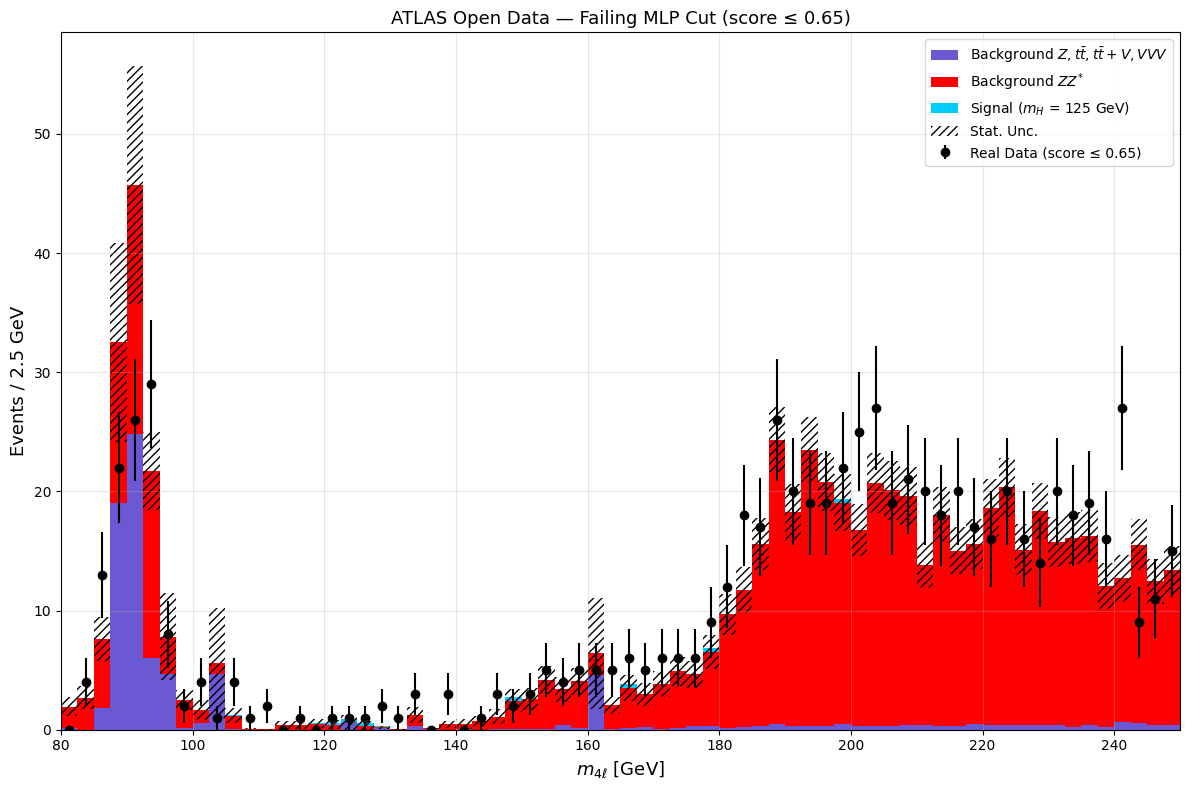

Data failing cut :   1178
MC bkg (lumi)    :   1114.83
MC signal (lumi) :      3.96

REAL DATA SIGNIFICANCE - Keras MLP

Observed data events in [110, 135) GeV with score > 0.65: 58

------------------------------------------------------------
METHOD 0: Without ML (Mass Window Only)
------------------------------------------------------------
  Observed data (N_obs):           70 ± 8.4
  MC background (B_pred):          31.95 ± 5.62
  Signal excess:                   38.05
  Significance Z:                  3.42 ± 0.92σ
  p-value:                         3.13e-04

------------------------------------------------------------
METHOD 1: MC Background Prediction (False Positives)
------------------------------------------------------------
  Observed data (N_obs):           58 ± 7.6
  MC background (B_pred):          27.80 ± 5.49
  Signal excess:                   30.20
  Significance Z:                  3.06 ± 0.93σ
  p-value:                         1.10e-03

----------------------------

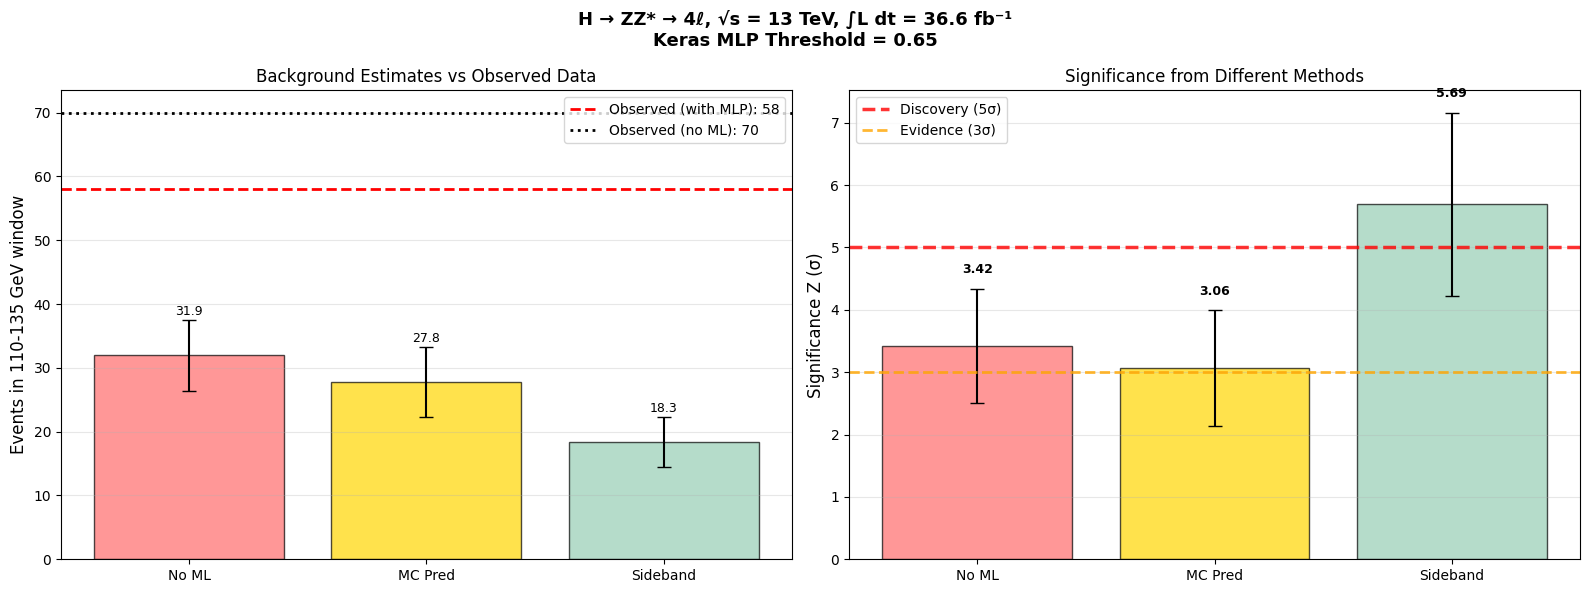


IMPROVEMENT SUMMARY: With Keras MLP vs Without ML

  Without ML:     Z = 3.42 ± 0.92σ
  With MLP:       Z = 3.06 ± 0.93σ

  Improvement:    0.90x
  Background rejection: 13.0%
  Signal efficiency:    96.4%

Done! - Keras MLP analysis complete


In [101]:
# ============================================================================
# KERAS MLP: TRAIN PAIRED K-FOLD, SCORE MC OOF + REAL DATA ENSEMBLE
# ============================================================================

MLP_K          = 5
MLP_KFOLD_SEED = 42
MLP_THRESHOLD  = 0.65

MLP_EPOCHS     = 100
MLP_BATCH_SIZE = 256
MLP_LR         = 1e-3
MLP_PATIENCE   = 10

def build_mlp(n_features, seed):
    tf.keras.utils.set_random_seed(seed)
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(32,  activation='relu'),
        Dense(1,   activation='sigmoid'),
    ])
    model.compile(optimizer=Adam(learning_rate=MLP_LR), loss='binary_crossentropy')
    return model

# --- MC arrays (reuse if already built; otherwise rebuild) ---
# X_mc, y_mc, w_mc, m_mc = build_ml_dataset_with_mass(keep_sep)
print(f'MC events: {len(y_mc)}   sig: {int((y_mc==1).sum())}   bkg: {int((y_mc==0).sum())}')

# --- Real data feature matrix (reconstructed ONCE before the loop) ---
data_feats_mlp = reconstruct_z1_z2_fast(all_data['Data'])
X_data_mlp     = np.stack([np.asarray(data_feats_mlp[k]) for k in keep_sep], axis=1)
m_data_mlp     = np.asarray(data_feats_mlp['mass'])
print(f'Real data events: {len(X_data_mlp)}')

# --- k-fold loop: train MLP on MC, score MC OOF + real data ---
skf            = StratifiedKFold(n_splits=MLP_K, shuffle=True, random_state=MLP_KFOLD_SEED)
oof_mlp        = np.zeros(len(y_mc))
data_per_fold  = np.zeros((MLP_K, len(X_data_mlp)))
fold_aucs_mlp  = []
mlp_pipelines  = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):
    X_tr_full, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr_full, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr_full, w_te = w_mc[tr_idx], w_mc[te_idx]

    # validation split
    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_tr_full, y_tr_full, w_tr_full,
        test_size=0.20, stratify=y_tr_full, random_state=MLP_KFOLD_SEED,
    )

    # class-balanced weights
    spw                 = w_tr[y_tr == 0].sum() / w_tr[y_tr == 1].sum()
    w_tr_bal            = w_tr.copy();  w_tr_bal[y_tr == 1]   *= spw
    w_val_bal           = w_val.copy(); w_val_bal[y_val == 1] *= spw

    # scaling
    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr)
    X_val_s  = scaler.transform(X_val)
    X_te_s   = scaler.transform(X_te)
    X_data_s = scaler.transform(X_data_mlp)

    # model
    model = build_mlp(X_tr_s.shape[1], seed=42 + fold_idx)
    es    = EarlyStopping(monitor='val_loss', patience=MLP_PATIENCE,
                          restore_best_weights=True, verbose=0)
    hist  = model.fit(
        X_tr_s, y_tr,
        sample_weight   = w_tr_bal,
        validation_data = (X_val_s, y_val, w_val_bal),
        epochs          = MLP_EPOCHS,
        batch_size      = MLP_BATCH_SIZE,
        callbacks       = [es],
        verbose         = 0,
    )

    oof_mlp[te_idx]         = model.predict(X_te_s,   batch_size=4096, verbose=0).ravel()
    data_per_fold[fold_idx] = model.predict(X_data_s, batch_size=4096, verbose=0).ravel()
    fold_aucs_mlp.append(roc_auc_score(y_te, oof_mlp[te_idx], sample_weight=w_te))
    mlp_pipelines.append({'scaler': scaler, 'model': model})
    print(f'  MLP fold {fold_idx+1}/{MLP_K}  AUC={fold_aucs_mlp[-1]:.4f}   '
          f'epochs={len(hist.history["loss"])}  '
          f'n_train={len(X_tr)}  n_val={len(X_val)}  n_test={len(X_te)}   '
          f'[t={time.time()-t0:5.1f}s]')

# --- Aggregate scores ---
data_scores_mlp = data_per_fold.mean(axis=0)
oof_auc_mlp     = roc_auc_score(y_mc, oof_mlp, sample_weight=w_mc)

print()
print(f'OOF AUC (MC, all events): {oof_auc_mlp:.4f}   '
      f'per-fold {np.mean(fold_aucs_mlp):.4f} ± {np.std(fold_aucs_mlp):.4f}')
print(f'Real data scored: {len(data_scores_mlp)} events  '
      f'(mean of {MLP_K} models; fold std = '
      f'{data_per_fold.std(axis=0).mean():.4f})')

# ============================================================================
# PLOT MC m4l DISTRIBUTION AFTER MLP CUT
# ============================================================================
sig_key  = r'Signal ($m_H$ = 125 GeV)'
bkg_keys = [s for s in z_masses if s != sig_key]

# Rebuild bin edges locally so this cell does not depend on globals from
# section 4 still being alive in the kernel.
xmin, xmax, step_size = 80.0, 250.0, 2.5
bin_edges   = np.arange(xmin, xmax + step_size, step_size)
bin_centres = bin_edges[:-1] + step_size / 2

# Per-sample index map
_offsets = {}
_pos     = 0
_n_sig   = len(z_masses[sig_key]['mass'])
_offsets[sig_key] = (_pos, _pos + _n_sig)
_pos += _n_sig
for s in bkg_keys:
    n = len(z_masses[s]['mass'])
    _offsets[s] = (_pos, _pos + n)
    _pos += n
assert _pos == len(y_mc), f'offset mismatch {_pos} vs {len(y_mc)}'

def _per_sample_mlp(s):
    a, b = _offsets[s]
    return m_mc[a:b], w_mc[a:b], oof_mlp[a:b]

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample_mlp(s)
    sel = p_s > MLP_THRESHOLD
    mc_x.append(np.asarray(m_s[sel], dtype=float))
    mc_w.append(np.asarray(w_s[sel], dtype=float))
    mc_colors.append(samples[s]['color'])
    mc_labels.append(s)

m_sig_arr, w_sig_arr, p_sig_arr = _per_sample_mlp(sig_key)
sig_sel        = p_sig_arr > MLP_THRESHOLD
signal_x       = np.asarray(m_sig_arr[sig_sel], dtype=float)
signal_weights = np.asarray(w_sig_arr[sig_sel], dtype=float)
signal_color   = samples[sig_key]['color']

mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]
mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                              weights=np.hstack(mc_w)**2)[0])
ax.hist(signal_x, bins=bin_edges, weights=signal_weights, bottom=mc_tot,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'MC after Keras MLP (score > {MLP_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("mlp_mc.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT REAL DATA m4l DISTRIBUTION AFTER MLP CUT
# ============================================================================
data_pass  = data_scores_mlp > MLP_THRESHOLD
data_mass  = m_data_mlp[data_pass]
data_x, _  = np.histogram(data_mass, bins=bin_edges)
data_x_err = np.sqrt(data_x)

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]
mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                              weights=np.hstack(mc_w)**2)[0])
ax.hist(signal_x, bins=bin_edges, weights=signal_weights, bottom=mc_tot,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')
ax.errorbar(bin_centres, data_x, yerr=data_x_err, fmt='ko',
            label=f'Real Data (score > {MLP_THRESHOLD})')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'ATLAS Open Data after Keras MLP (score > {MLP_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("mlp_data.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Data passing cut : {int(data_pass.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w):>9.2f}')
print(f'MC signal (lumi) : {signal_weights.sum():>9.2f}')

# ============================================================================
# PLOT REAL DATA m4l DISTRIBUTION FAILING MLP CUT
# ============================================================================
mc_x_fail, mc_w_fail, mc_colors_fail, mc_labels_fail = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample_mlp(s)
    sel = p_s <= MLP_THRESHOLD
    mc_x_fail.append(np.asarray(m_s[sel], dtype=float))
    mc_w_fail.append(np.asarray(w_s[sel], dtype=float))
    mc_colors_fail.append(samples[s]['color'])
    mc_labels_fail.append(s)

sig_sel_fail        = p_sig_arr <= MLP_THRESHOLD
signal_x_fail       = np.asarray(m_sig_arr[sig_sel_fail], dtype=float)
signal_weights_fail = np.asarray(w_sig_arr[sig_sel_fail], dtype=float)

data_fail_mask  = data_scores_mlp <= MLP_THRESHOLD
data_mass_fail  = m_data_mlp[data_fail_mask]
data_x_fail, _  = np.histogram(data_mass_fail, bins=bin_edges)
data_x_fail_err = np.sqrt(data_x_fail)

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_heights_fail = ax.hist(mc_x_fail, bins=bin_edges, weights=mc_w_fail, stacked=True,
                          color=mc_colors_fail, label=mc_labels_fail)
mc_tot_fail = mc_heights_fail[0][-1]
mc_err_fail = np.sqrt(np.histogram(np.hstack(mc_x_fail), bins=bin_edges,
                                   weights=np.hstack(mc_w_fail)**2)[0])
ax.hist(signal_x_fail, bins=bin_edges, weights=signal_weights_fail, bottom=mc_tot_fail,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err_fail, bottom=mc_tot_fail - mc_err_fail, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')
ax.errorbar(bin_centres, data_x_fail, yerr=data_x_fail_err, fmt='ko',
            label=f'Real Data (score ≤ {MLP_THRESHOLD})')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'ATLAS Open Data — Failing MLP Cut (score ≤ {MLP_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("mlp_data_fail.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Data failing cut : {int(data_fail_mask.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w_fail):>9.2f}')
print(f'MC signal (lumi) : {signal_weights_fail.sum():>9.2f}')

# ============================================================================
# SIGNIFICANCE ON REAL DATA — KERAS MLP
# ============================================================================
print("\n" + "="*70)
print("REAL DATA SIGNIFICANCE - Keras MLP")
print("="*70)

WIN_LO, WIN_HI = 110.0, 135.0
k_syst         = 0.30

data_in_win    = (m_data_mlp >= WIN_LO) & (m_data_mlp < WIN_HI)
data_in_win_ml = data_in_win & (data_scores_mlp > MLP_THRESHOLD)
N_obs          = int(data_in_win_ml.sum())
sigma_obs      = np.sqrt(N_obs)

print(f"\nObserved data events in [{WIN_LO:.0f}, {WIN_HI:.0f}) GeV with score > {MLP_THRESHOLD}: {N_obs}")

# ---------- METHOD 0: No ML ----------
print("\n" + "-"*60)
print("METHOD 0: Without ML (Mass Window Only)")
print("-"*60)

data_in_window_noml = (m_data_mlp >= WIN_LO) & (m_data_mlp < WIN_HI)
N_obs_noml          = int(data_in_window_noml.sum())
sigma_obs_noml      = np.sqrt(N_obs_noml)

bkg_total_noml, bkg_weight_sq_noml = 0.0, 0.0
for s in bkg_keys:
    m = z_masses[s]['mass']
    w = z_masses[s]['w']
    inw = (m >= WIN_LO) & (m < WIN_HI)
    bkg_total_noml     += float(w[inw].sum())
    bkg_weight_sq_noml += float((w[inw]**2).sum())

B_noml       = bkg_total_noml
sigma_B_noml = np.sqrt(bkg_weight_sq_noml)

S_excess_noml = N_obs_noml - B_noml
denom_noml    = B_noml + (k_syst * B_noml)**2
Z_noml        = S_excess_noml / np.sqrt(denom_noml)
term_obs      = sigma_obs_noml**2 / denom_noml
term_B        = (S_excess_noml**2 * (1 + 2*k_syst**2 * B_noml)**2 * sigma_B_noml**2) / (4 * denom_noml**3)
sigma_Z_noml  = np.sqrt(term_obs + term_B)
pvalue_noml   = norm.sf(Z_noml)

print(f"  Observed data (N_obs):           {N_obs_noml:.0f} ± {sigma_obs_noml:.1f}")
print(f"  MC background (B_pred):          {B_noml:.2f} ± {sigma_B_noml:.2f}")
print(f"  Signal excess:                   {S_excess_noml:.2f}")
print(f"  Significance Z:                  {Z_noml:.2f} ± {sigma_Z_noml:.2f}σ")
print(f"  p-value:                         {pvalue_noml:.2e}")

# ---------- METHOD 1: MC Background Prediction ----------
print("\n" + "-"*60)
print("METHOD 1: MC Background Prediction (False Positives)")
print("-"*60)

bkg_mask_mc  = (y_mc == 0) & (oof_mlp > MLP_THRESHOLD) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
B_mc         = w_mc[bkg_mask_mc].sum()
sigma_B_mc   = np.sqrt((w_mc[bkg_mask_mc]**2).sum())

S_excess_mc  = N_obs - B_mc
denom        = B_mc + (k_syst * B_mc)**2
Z_mc         = S_excess_mc / np.sqrt(denom)
term_obs     = sigma_obs**2 / denom
term_B       = (S_excess_mc**2 * (1 + 2*k_syst**2 * B_mc)**2 * sigma_B_mc**2) / (4 * denom**3)
sigma_Z_mc   = np.sqrt(term_obs + term_B)
pvalue_mc    = norm.sf(Z_mc)

print(f"  Observed data (N_obs):           {N_obs:.0f} ± {sigma_obs:.1f}")
print(f"  MC background (B_pred):          {B_mc:.2f} ± {sigma_B_mc:.2f}")
print(f"  Signal excess:                   {S_excess_mc:.2f}")
print(f"  Significance Z:                  {Z_mc:.2f} ± {sigma_Z_mc:.2f}σ")
print(f"  p-value:                         {pvalue_mc:.2e}")

# ---------- METHOD 2: Sideband ----------
print("\n" + "-"*60)
print("METHOD 2: Data-Driven (ML-Passed Mass Sidebands)")
print("-"*60)

LEFT_SB_LO,  LEFT_SB_HI  = 90.0,  105.0
RIGHT_SB_LO, RIGHT_SB_HI = 140.0, 155.0

left_sideband  = (m_data_mlp >= LEFT_SB_LO)  & (m_data_mlp < LEFT_SB_HI)  & (data_scores_mlp > MLP_THRESHOLD)
right_sideband = (m_data_mlp >= RIGHT_SB_LO) & (m_data_mlp < RIGHT_SB_HI) & (data_scores_mlp > MLP_THRESHOLD)

N_left           = int(left_sideband.sum())
N_right          = int(right_sideband.sum())
N_sideband_total = N_left + N_right
sideband_width   = (LEFT_SB_HI - LEFT_SB_LO) + (RIGHT_SB_HI - RIGHT_SB_LO)
signal_width     = WIN_HI - WIN_LO

B_sideband       = N_sideband_total * (signal_width / sideband_width)
sigma_B_sideband = np.sqrt(N_sideband_total) * (signal_width / sideband_width)

S_excess_sideband = N_obs - B_sideband
denom             = B_sideband + (k_syst * B_sideband)**2
if B_sideband > 0:
    Z_sideband       = S_excess_sideband / np.sqrt(denom)
    term_obs         = sigma_obs**2 / denom
    term_B           = (S_excess_sideband**2 * (1 + 2*k_syst**2 * B_sideband)**2 * sigma_B_sideband**2) / (4 * denom**3)
    sigma_Z_sideband = np.sqrt(term_obs + term_B)
    pvalue_sideband  = norm.sf(Z_sideband)
else:
    Z_sideband = sigma_Z_sideband = pvalue_sideband = np.nan

print(f"  Left sideband count passing ML:   {N_left}")
print(f"  Right sideband count passing ML:  {N_right}")
if N_right > 0:
    print(f"  Ratio left/right:                 {N_left/N_right:.2f}")
print(f"  Observed data in signal region:   {N_obs:.0f} ± {sigma_obs:.1f}")
print(f"  Background (width scaled):        {B_sideband:.2f} ± {sigma_B_sideband:.2f}")
print(f"  Signal excess:                    {S_excess_sideband:.2f}")
print(f"  Significance Z:                   {Z_sideband:.2f} ± {sigma_Z_sideband:.2f}σ")
print(f"  p-value:                          {pvalue_sideband:.2e}")

# ---------- SUMMARY TABLE ----------
print("\n" + "="*70)
print("SUMMARY - Keras MLP: Comparison of All Methods")
print("="*70)
print(f"\n{'Method':<35} {'Background':>12} {'Z':>10} {'±σ':>8} {'p-value':>12}")
print("-" * 80)
print(f"{'No ML (mass window only)':<35} {B_noml:>12.2f} {Z_noml:>10.2f} ±{sigma_Z_noml:>7.2f} {pvalue_noml:>12.2e}")
print(f"{'MC Prediction (with MLP)':<35} {B_mc:>12.2f} {Z_mc:>10.2f} ±{sigma_Z_mc:>7.2f} {pvalue_mc:>12.2e}")
print(f"{'Sideband Extrapolation':<35} {B_sideband:>12.2f} {Z_sideband:>10.2f} ±{sigma_Z_sideband:>7.2f} {pvalue_sideband:>12.2e}")
print("-" * 80)

# ---------- COMPARISON PLOT ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods_names_all = ['No ML', 'MC Pred', 'Sideband']
backgrounds_all   = [B_noml, B_mc, B_sideband]
errors_all        = [sigma_B_noml, sigma_B_mc, sigma_B_sideband]
colors_bkg_all    = ['#FF6B6B', '#FFD700', '#96CEB4']

ax = axes[0]
bars = ax.bar(methods_names_all, backgrounds_all, yerr=errors_all, capsize=5,
              color=colors_bkg_all, alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(N_obs,      color='red',   linestyle='--', linewidth=2, label=f'Observed (with MLP): {N_obs}')
ax.axhline(N_obs_noml, color='black', linestyle=':',  linewidth=2, label=f'Observed (no ML): {N_obs_noml}')
ax.set_ylabel('Events in 110-135 GeV window', fontsize=12)
ax.set_title('Background Estimates vs Observed Data', fontsize=12)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
for bar, b, err in zip(bars, backgrounds_all, errors_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.3,
            f'{b:.1f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
z_values_all = [Z_noml, Z_mc, Z_sideband]
z_errors_all = [sigma_Z_noml, sigma_Z_mc, sigma_Z_sideband]
bars = ax.bar(methods_names_all, z_values_all, yerr=z_errors_all, capsize=5,
              color=colors_bkg_all, alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(5.0, color='red',    linestyle='--', linewidth=2.5, alpha=0.8, label='Discovery (5σ)')
ax.axhline(3.0, color='orange', linestyle='--', linewidth=2,   alpha=0.8, label='Evidence (3σ)')
ax.set_ylabel('Significance Z (σ)', fontsize=12)
ax.set_title('Significance from Different Methods', fontsize=12)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
for bar, z, err in zip(bars, z_values_all, z_errors_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.2,
            f'{z:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'H → ZZ* → 4ℓ, √s = 13 TeV, ∫L dt = {lumi} fb⁻¹\nKeras MLP Threshold = {MLP_THRESHOLD:.2f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("mlp_summary.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------- IMPROVEMENT SUMMARY ----------
print("\n" + "="*70)
print("IMPROVEMENT SUMMARY: With Keras MLP vs Without ML")
print("="*70)

m_sig = z_masses[sig_key]['mass']
w_sig = z_masses[sig_key]['w']
sig_before_mask = (m_sig >= WIN_LO) & (m_sig < WIN_HI)
S_mc_before     = w_sig[sig_before_mask].sum()

sig_after_mask = (y_mc == 1) & (oof_mlp > MLP_THRESHOLD) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
S_mc_after     = w_mc[sig_after_mask].sum()

improvement   = Z_mc / Z_noml             if Z_noml > 0     else 0
bkg_rejection = (1 - B_mc / B_noml) * 100 if B_noml > 0     else 0
signal_eff    = (S_mc_after / S_mc_before) * 100 if S_mc_before > 0 else 0

print(f"\n  Without ML:     Z = {Z_noml:.2f} ± {sigma_Z_noml:.2f}σ")
print(f"  With MLP:       Z = {Z_mc:.2f} ± {sigma_Z_mc:.2f}σ")
print(f"\n  Improvement:    {improvement:.2f}x")
print(f"  Background rejection: {bkg_rejection:.1f}%")
print(f"  Signal efficiency:    {signal_eff:.1f}%")
print("="*70)
print("\nDone! - Keras MLP analysis complete")

### 13.5 Logistic Regression on real data *(paper Table VII)*

MC events: 238517   sig: 226120   bkg: 12397
Real data events: 1279
  LR fold 1/5  AUC=0.9419   n_train=190813  n_test=47704   [t=  1.0s]
  LR fold 2/5  AUC=0.8649   n_train=190813  n_test=47704   [t=  2.1s]
  LR fold 3/5  AUC=0.9253   n_train=190814  n_test=47703   [t=  3.2s]
  LR fold 4/5  AUC=0.9250   n_train=190814  n_test=47703   [t=  3.9s]
  LR fold 5/5  AUC=0.9032   n_train=190814  n_test=47703   [t=  4.6s]

OOF AUC (MC, all events): 0.9091   per-fold 0.9121 ± 0.0266
Real data scored: 1279 events  (mean of 5 models; fold std = 0.0209)


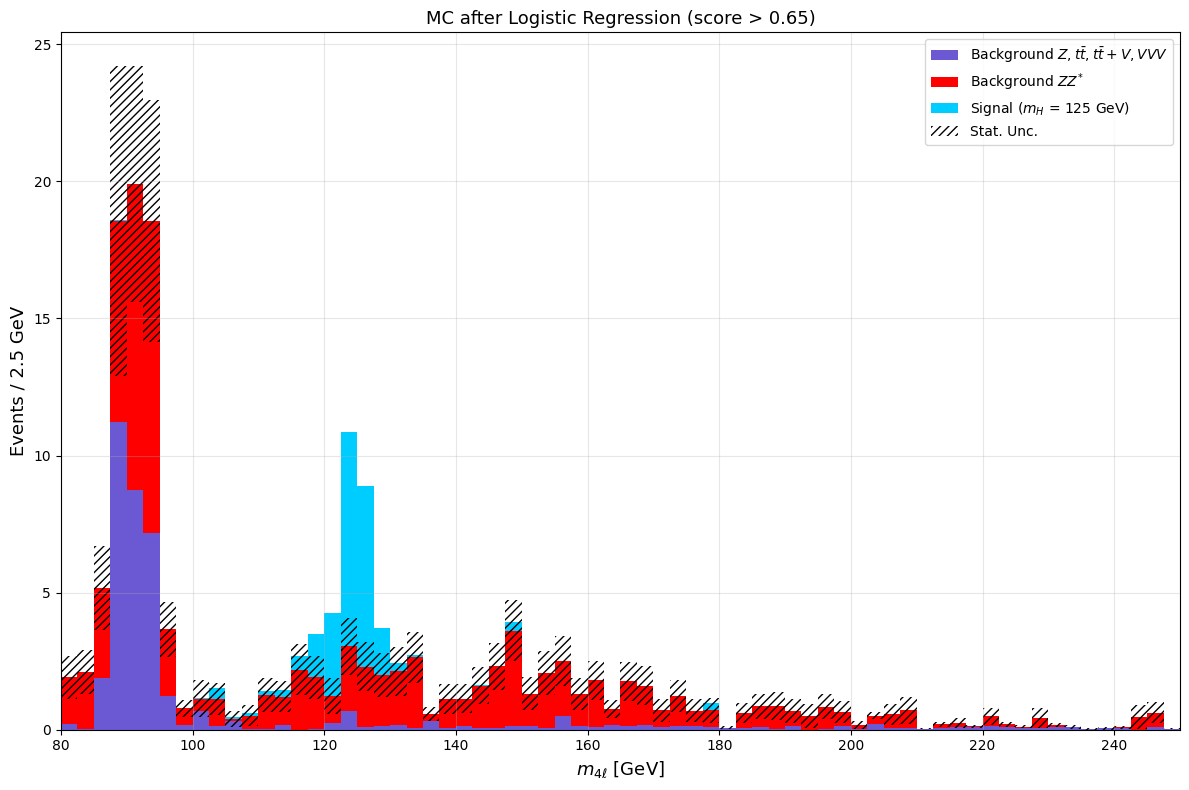

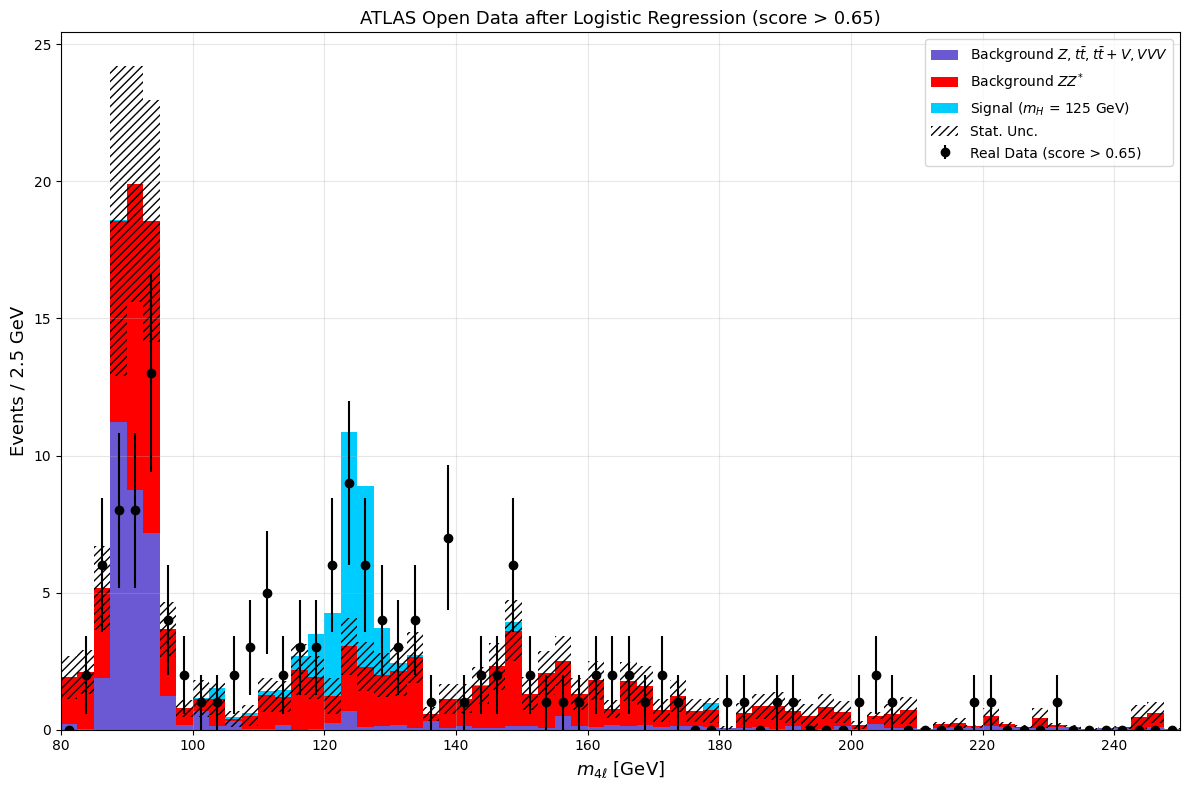

Data passing cut :    152
MC bkg (lumi)    :    139.63
MC signal (lumi) :     23.96


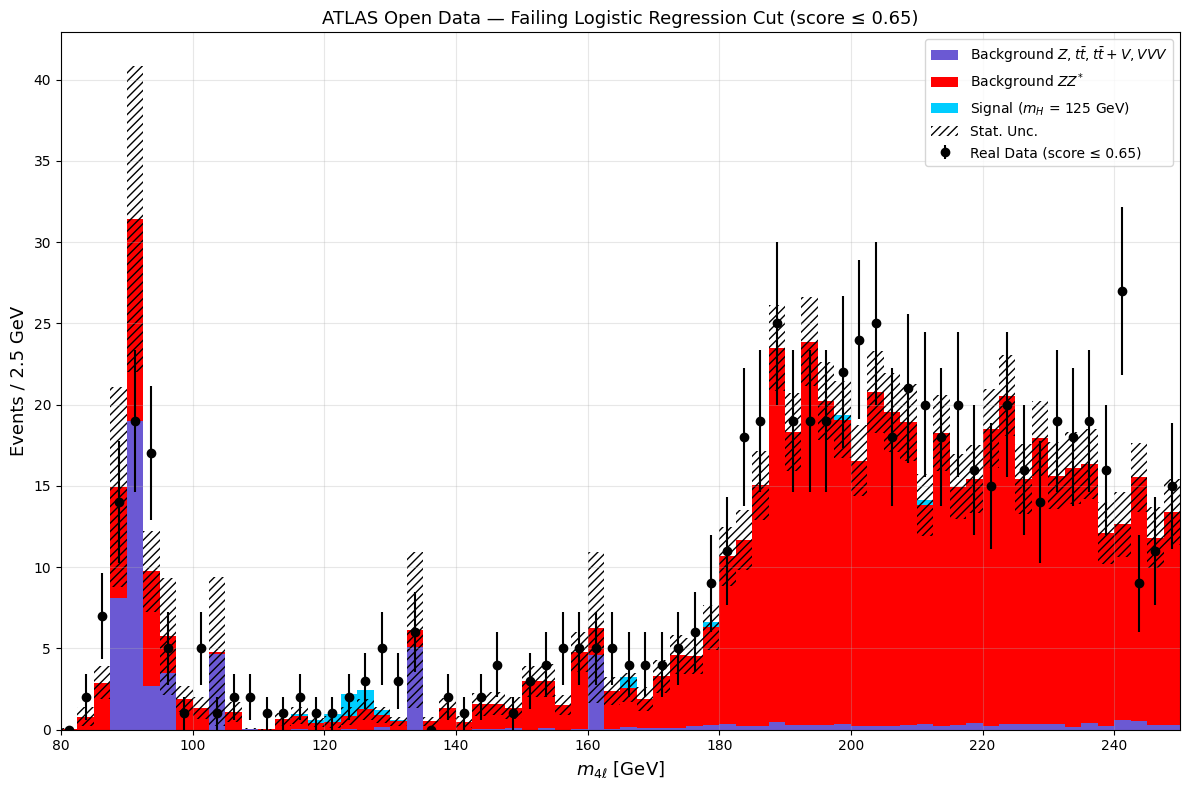

Data failing cut :   1127
MC bkg (lumi)    :   1055.06
MC signal (lumi) :      6.47

REAL DATA SIGNIFICANCE - Logistic Regression

Observed data events in [110, 135) GeV with score > 0.65: 45

------------------------------------------------------------
METHOD 0: Without ML (Mass Window Only)
------------------------------------------------------------
  Observed data (N_obs):           70 ± 8.4
  MC background (B_pred):          31.95 ± 5.62
  Signal excess:                   38.05
  Significance Z:                  3.42 ± 0.92σ
  p-value:                         3.13e-04

------------------------------------------------------------
METHOD 1: MC Background Prediction (False Positives)
------------------------------------------------------------
  Observed data (N_obs):           45 ± 6.7
  MC background (B_pred):          19.91 ± 2.61
  Signal excess:                   25.09
  Significance Z:                  3.37 ± 0.97σ
  p-value:                         3.82e-04

------------------

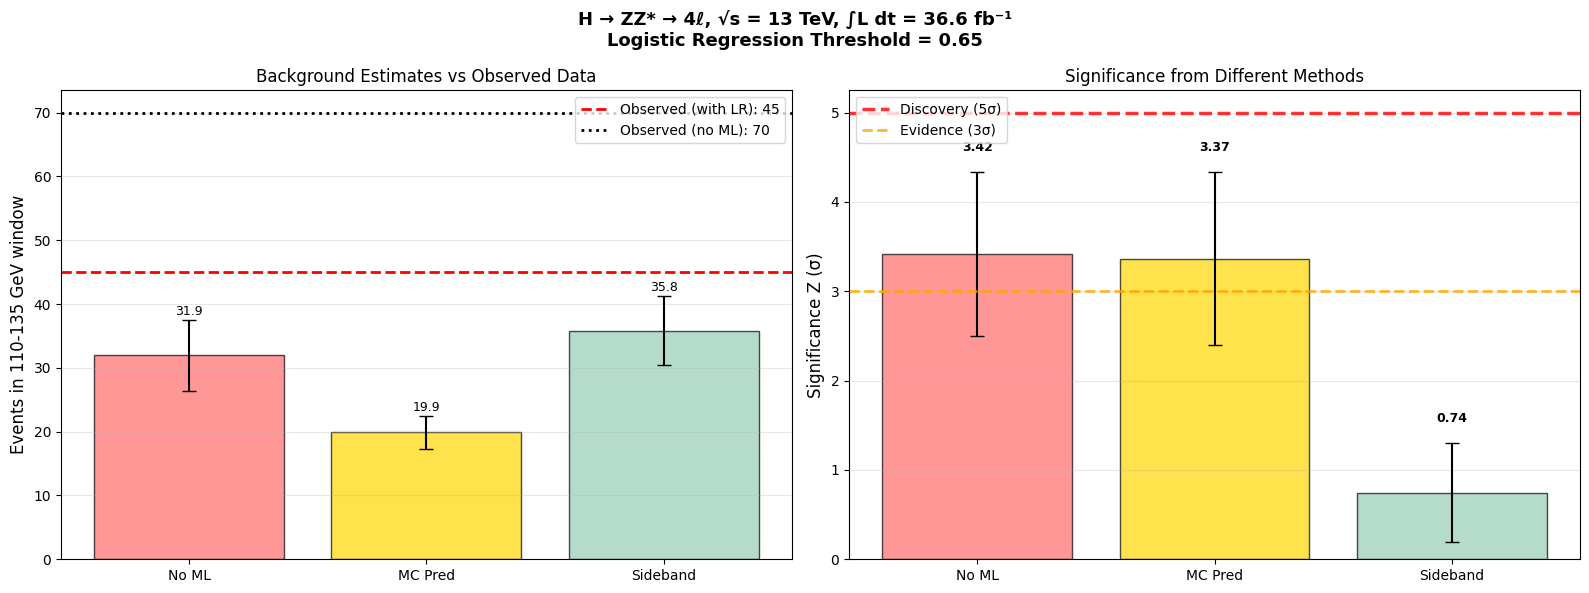


IMPROVEMENT SUMMARY: With Logistic Regression vs Without ML

  Without ML:     Z = 3.42 ± 0.92σ
  With LR:        Z = 3.37 ± 0.97σ

  Improvement:    0.98x
  Background rejection: 37.7%
  Signal efficiency:    85.1%

Done! - Logistic Regression analysis complete


In [102]:
# ============================================================================
# LOGISTIC REGRESSION (BALANCED): TRAIN PAIRED K-FOLD, SCORE MC OOF + REAL DATA
# ============================================================================

LR_K          = 5
LR_KFOLD_SEED = 42
LR_THRESHOLD  = 0.65
LR_C          = 100.0

def make_balanced_weights(y, w):
    w_bal = w.copy()
    spw = w[y == 0].sum() / w[y == 1].sum()
    w_bal[y == 1] *= spw
    return w_bal

# --- MC arrays (reuse if already built; otherwise rebuild) ---
print(f'MC events: {len(y_mc)}   sig: {int((y_mc==1).sum())}   bkg: {int((y_mc==0).sum())}')

# --- Real data feature matrix (reconstructed ONCE before the loop) ---
data_feats_lr = reconstruct_z1_z2_fast(all_data['Data'])
X_data_lr     = np.stack([np.asarray(data_feats_lr[k]) for k in keep_sep], axis=1)
m_data_lr     = np.asarray(data_feats_lr['mass'])
print(f'Real data events: {len(X_data_lr)}')

# --- k-fold loop: train LogReg on MC, score MC OOF + real data ---
skf            = StratifiedKFold(n_splits=LR_K, shuffle=True, random_state=LR_KFOLD_SEED)
oof_logreg     = np.zeros(len(y_mc))
data_per_fold  = np.zeros((LR_K, len(X_data_lr)))
fold_aucs_lr   = []
lr_pipelines   = []

t0 = time.time()
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc)):
    X_tr, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr, y_te = y_mc[tr_idx], y_mc[te_idx]
    w_tr, w_te = w_mc[tr_idx], w_mc[te_idx]

    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr)
    X_te_s   = scaler.transform(X_te)
    X_data_s = scaler.transform(X_data_lr)

    # Class-balance training weights (same as MLP/RF)
    w_tr_bal = make_balanced_weights(y_tr, w_tr)

    clf = LogisticRegression(
        C            = LR_C,
        max_iter     = 2000,
        solver       = 'lbfgs',
        random_state = 42,
    )
    clf.fit(X_tr_s, y_tr, sample_weight=w_tr_bal)

    oof_logreg[te_idx]      = clf.predict_proba(X_te_s)[:, 1]
    data_per_fold[fold_idx] = clf.predict_proba(X_data_s)[:, 1]
    fold_aucs_lr.append(roc_auc_score(y_te, oof_logreg[te_idx], sample_weight=w_te))
    lr_pipelines.append({'scaler': scaler, 'model': clf})
    print(f'  LR fold {fold_idx+1}/{LR_K}  AUC={fold_aucs_lr[-1]:.4f}   '
          f'n_train={len(X_tr)}  n_test={len(X_te)}   [t={time.time()-t0:5.1f}s]')

# --- Aggregate scores ---
data_scores_lr = data_per_fold.mean(axis=0)
oof_auc_lr     = roc_auc_score(y_mc, oof_logreg, sample_weight=w_mc)

print()
print(f'OOF AUC (MC, all events): {oof_auc_lr:.4f}   '
      f'per-fold {np.mean(fold_aucs_lr):.4f} ± {np.std(fold_aucs_lr):.4f}')
print(f'Real data scored: {len(data_scores_lr)} events  '
      f'(mean of {LR_K} models; fold std = '
      f'{data_per_fold.std(axis=0).mean():.4f})')

# ============================================================================
# PLOT MC m4l DISTRIBUTION AFTER LR CUT
# ============================================================================
sig_key  = r'Signal ($m_H$ = 125 GeV)'
bkg_keys = [s for s in z_masses if s != sig_key]

# Rebuild bin edges locally so this cell does not depend on globals from
# section 4 still being alive in the kernel.
xmin, xmax, step_size = 80.0, 250.0, 2.5
bin_edges   = np.arange(xmin, xmax + step_size, step_size)
bin_centres = bin_edges[:-1] + step_size / 2

# Per-sample index map
_offsets = {}
_pos     = 0
_n_sig   = len(z_masses[sig_key]['mass'])
_offsets[sig_key] = (_pos, _pos + _n_sig)
_pos += _n_sig
for s in bkg_keys:
    n = len(z_masses[s]['mass'])
    _offsets[s] = (_pos, _pos + n)
    _pos += n
assert _pos == len(y_mc), f'offset mismatch {_pos} vs {len(y_mc)}'

def _per_sample_lr(s):
    a, b = _offsets[s]
    return m_mc[a:b], w_mc[a:b], oof_logreg[a:b]

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_x, mc_w, mc_colors, mc_labels = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample_lr(s)
    sel = p_s > LR_THRESHOLD
    mc_x.append(np.asarray(m_s[sel], dtype=float))
    mc_w.append(np.asarray(w_s[sel], dtype=float))
    mc_colors.append(samples[s]['color'])
    mc_labels.append(s)

m_sig_arr, w_sig_arr, p_sig_arr = _per_sample_lr(sig_key)
sig_sel        = p_sig_arr > LR_THRESHOLD
signal_x       = np.asarray(m_sig_arr[sig_sel], dtype=float)
signal_weights = np.asarray(w_sig_arr[sig_sel], dtype=float)
signal_color   = samples[sig_key]['color']

mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]
mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                              weights=np.hstack(mc_w)**2)[0])
ax.hist(signal_x, bins=bin_edges, weights=signal_weights, bottom=mc_tot,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'MC after Logistic Regression (score > {LR_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lr_mc.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT REAL DATA m4l DISTRIBUTION AFTER LR CUT
# ============================================================================
data_pass  = data_scores_lr > LR_THRESHOLD
data_mass  = m_data_lr[data_pass]
data_x, _  = np.histogram(data_mass, bins=bin_edges)
data_x_err = np.sqrt(data_x)

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_heights = ax.hist(mc_x, bins=bin_edges, weights=mc_w, stacked=True,
                     color=mc_colors, label=mc_labels)
mc_tot = mc_heights[0][-1]
mc_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges,
                              weights=np.hstack(mc_w)**2)[0])
ax.hist(signal_x, bins=bin_edges, weights=signal_weights, bottom=mc_tot,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err, bottom=mc_tot - mc_err, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')
ax.errorbar(bin_centres, data_x, yerr=data_x_err, fmt='ko',
            label=f'Real Data (score > {LR_THRESHOLD})')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'ATLAS Open Data after Logistic Regression (score > {LR_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lr_data.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Data passing cut : {int(data_pass.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w):>9.2f}')
print(f'MC signal (lumi) : {signal_weights.sum():>9.2f}')

# ============================================================================
# PLOT REAL DATA m4l DISTRIBUTION FAILING LR CUT
# ============================================================================
mc_x_fail, mc_w_fail, mc_colors_fail, mc_labels_fail = [], [], [], []
for s in bkg_keys:
    m_s, w_s, p_s = _per_sample_lr(s)
    sel = p_s <= LR_THRESHOLD
    mc_x_fail.append(np.asarray(m_s[sel], dtype=float))
    mc_w_fail.append(np.asarray(w_s[sel], dtype=float))
    mc_colors_fail.append(samples[s]['color'])
    mc_labels_fail.append(s)

sig_sel_fail        = p_sig_arr <= LR_THRESHOLD
signal_x_fail       = np.asarray(m_sig_arr[sig_sel_fail], dtype=float)
signal_weights_fail = np.asarray(w_sig_arr[sig_sel_fail], dtype=float)

data_fail_mask  = data_scores_lr <= LR_THRESHOLD
data_mass_fail  = m_data_lr[data_fail_mask]
data_x_fail, _  = np.histogram(data_mass_fail, bins=bin_edges)
data_x_fail_err = np.sqrt(data_x_fail)

# Create the figure FIRST (before any ax.hist / ax.errorbar / ax.bar calls)
fig, ax = plt.subplots(figsize=(12, 8))

mc_heights_fail = ax.hist(mc_x_fail, bins=bin_edges, weights=mc_w_fail, stacked=True,
                          color=mc_colors_fail, label=mc_labels_fail)
mc_tot_fail = mc_heights_fail[0][-1]
mc_err_fail = np.sqrt(np.histogram(np.hstack(mc_x_fail), bins=bin_edges,
                                   weights=np.hstack(mc_w_fail)**2)[0])
ax.hist(signal_x_fail, bins=bin_edges, weights=signal_weights_fail, bottom=mc_tot_fail,
        color=signal_color, label=sig_key)
ax.bar(bin_centres, 2*mc_err_fail, bottom=mc_tot_fail - mc_err_fail, alpha=0.5,
       color='none', hatch='////', width=step_size, label='Stat. Unc.')
ax.errorbar(bin_centres, data_x_fail, yerr=data_x_fail_err, fmt='ko',
            label=f'Real Data (score ≤ {LR_THRESHOLD})')

ax.set_xlim(xmin, xmax)
ax.set_xlabel(r'$m_{4\ell}$ [GeV]', fontsize=13)
ax.set_ylabel(f'Events / {step_size} GeV', fontsize=13)
ax.set_title(f'ATLAS Open Data — Failing Logistic Regression Cut (score ≤ {LR_THRESHOLD})', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lr_data_fail.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Data failing cut : {int(data_fail_mask.sum()):>6d}')
print(f'MC bkg (lumi)    : {sum(w.sum() for w in mc_w_fail):>9.2f}')
print(f'MC signal (lumi) : {signal_weights_fail.sum():>9.2f}')

# ============================================================================
# SIGNIFICANCE ON REAL DATA — LOGISTIC REGRESSION
# ============================================================================
print("\n" + "="*70)
print("REAL DATA SIGNIFICANCE - Logistic Regression")
print("="*70)

WIN_LO, WIN_HI = 110.0, 135.0
k_syst         = 0.30

data_in_win    = (m_data_lr >= WIN_LO) & (m_data_lr < WIN_HI)
data_in_win_ml = data_in_win & (data_scores_lr > LR_THRESHOLD)
N_obs          = int(data_in_win_ml.sum())
sigma_obs      = np.sqrt(N_obs)

print(f"\nObserved data events in [{WIN_LO:.0f}, {WIN_HI:.0f}) GeV with score > {LR_THRESHOLD}: {N_obs}")

# ---------- METHOD 0: No ML ----------
print("\n" + "-"*60)
print("METHOD 0: Without ML (Mass Window Only)")
print("-"*60)

data_in_window_noml = (m_data_lr >= WIN_LO) & (m_data_lr < WIN_HI)
N_obs_noml          = int(data_in_window_noml.sum())
sigma_obs_noml      = np.sqrt(N_obs_noml)

bkg_total_noml, bkg_weight_sq_noml = 0.0, 0.0
for s in bkg_keys:
    m = z_masses[s]['mass']
    w = z_masses[s]['w']
    inw = (m >= WIN_LO) & (m < WIN_HI)
    bkg_total_noml     += float(w[inw].sum())
    bkg_weight_sq_noml += float((w[inw]**2).sum())

B_noml       = bkg_total_noml
sigma_B_noml = np.sqrt(bkg_weight_sq_noml)

S_excess_noml = N_obs_noml - B_noml
denom_noml    = B_noml + (k_syst * B_noml)**2
Z_noml        = S_excess_noml / np.sqrt(denom_noml)
term_obs      = sigma_obs_noml**2 / denom_noml
term_B        = (S_excess_noml**2 * (1 + 2*k_syst**2 * B_noml)**2 * sigma_B_noml**2) / (4 * denom_noml**3)
sigma_Z_noml  = np.sqrt(term_obs + term_B)
pvalue_noml   = norm.sf(Z_noml)

print(f"  Observed data (N_obs):           {N_obs_noml:.0f} ± {sigma_obs_noml:.1f}")
print(f"  MC background (B_pred):          {B_noml:.2f} ± {sigma_B_noml:.2f}")
print(f"  Signal excess:                   {S_excess_noml:.2f}")
print(f"  Significance Z:                  {Z_noml:.2f} ± {sigma_Z_noml:.2f}σ")
print(f"  p-value:                         {pvalue_noml:.2e}")

# ---------- METHOD 1: MC Background Prediction ----------
print("\n" + "-"*60)
print("METHOD 1: MC Background Prediction (False Positives)")
print("-"*60)

bkg_mask_mc  = (y_mc == 0) & (oof_logreg > LR_THRESHOLD) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
B_mc         = w_mc[bkg_mask_mc].sum()
sigma_B_mc   = np.sqrt((w_mc[bkg_mask_mc]**2).sum())

S_excess_mc  = N_obs - B_mc
denom        = B_mc + (k_syst * B_mc)**2 if B_mc > 0 else np.nan
if B_mc > 0:
    Z_mc       = S_excess_mc / np.sqrt(denom)
    term_obs   = sigma_obs**2 / denom
    term_B     = (S_excess_mc**2 * (1 + 2*k_syst**2 * B_mc)**2 * sigma_B_mc**2) / (4 * denom**3)
    sigma_Z_mc = np.sqrt(term_obs + term_B)
    pvalue_mc  = norm.sf(Z_mc)
else:
    Z_mc = sigma_Z_mc = pvalue_mc = np.nan

print(f"  Observed data (N_obs):           {N_obs:.0f} ± {sigma_obs:.1f}")
print(f"  MC background (B_pred):          {B_mc:.2f} ± {sigma_B_mc:.2f}")
print(f"  Signal excess:                   {S_excess_mc:.2f}")
print(f"  Significance Z:                  {Z_mc:.2f} ± {sigma_Z_mc:.2f}σ")
print(f"  p-value:                         {pvalue_mc:.2e}")

# ---------- METHOD 2: Sideband ----------
print("\n" + "-"*60)
print("METHOD 2: Data-Driven (ML-Passed Mass Sidebands)")
print("-"*60)

LEFT_SB_LO,  LEFT_SB_HI  = 90.0,  105.0
RIGHT_SB_LO, RIGHT_SB_HI = 140.0, 155.0

left_sideband  = (m_data_lr >= LEFT_SB_LO)  & (m_data_lr < LEFT_SB_HI)  & (data_scores_lr > LR_THRESHOLD)
right_sideband = (m_data_lr >= RIGHT_SB_LO) & (m_data_lr < RIGHT_SB_HI) & (data_scores_lr > LR_THRESHOLD)

N_left           = int(left_sideband.sum())
N_right          = int(right_sideband.sum())
N_sideband_total = N_left + N_right
sideband_width   = (LEFT_SB_HI - LEFT_SB_LO) + (RIGHT_SB_HI - RIGHT_SB_LO)
signal_width     = WIN_HI - WIN_LO

B_sideband       = N_sideband_total * (signal_width / sideband_width)
sigma_B_sideband = np.sqrt(N_sideband_total) * (signal_width / sideband_width)

S_excess_sideband = N_obs - B_sideband
denom             = B_sideband + (k_syst * B_sideband)**2
if B_sideband > 0:
    Z_sideband       = S_excess_sideband / np.sqrt(denom)
    term_obs         = sigma_obs**2 / denom
    term_B           = (S_excess_sideband**2 * (1 + 2*k_syst**2 * B_sideband)**2 * sigma_B_sideband**2) / (4 * denom**3)
    sigma_Z_sideband = np.sqrt(term_obs + term_B)
    pvalue_sideband  = norm.sf(Z_sideband)
else:
    Z_sideband = sigma_Z_sideband = pvalue_sideband = np.nan

print(f"  Left sideband count passing ML:   {N_left}")
print(f"  Right sideband count passing ML:  {N_right}")
if N_right > 0:
    print(f"  Ratio left/right:                 {N_left/N_right:.2f}")
print(f"  Observed data in signal region:   {N_obs:.0f} ± {sigma_obs:.1f}")
print(f"  Background (width scaled):        {B_sideband:.2f} ± {sigma_B_sideband:.2f}")
print(f"  Signal excess:                    {S_excess_sideband:.2f}")
print(f"  Significance Z:                   {Z_sideband:.2f} ± {sigma_Z_sideband:.2f}σ")
print(f"  p-value:                          {pvalue_sideband:.2e}")

# ---------- SUMMARY TABLE ----------
print("\n" + "="*70)
print("SUMMARY - Logistic Regression: Comparison of All Methods")
print("="*70)
print(f"\n{'Method':<35} {'Background':>12} {'Z':>10} {'±σ':>8} {'p-value':>12}")
print("-" * 80)
print(f"{'No ML (mass window only)':<35} {B_noml:>12.2f} {Z_noml:>10.2f} ±{sigma_Z_noml:>7.2f} {pvalue_noml:>12.2e}")
print(f"{'MC Prediction (with LR)':<35} {B_mc:>12.2f} {Z_mc:>10.2f} ±{sigma_Z_mc:>7.2f} {pvalue_mc:>12.2e}")
print(f"{'Sideband Extrapolation':<35} {B_sideband:>12.2f} {Z_sideband:>10.2f} ±{sigma_Z_sideband:>7.2f} {pvalue_sideband:>12.2e}")
print("-" * 80)

# ---------- COMPARISON PLOT ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods_names_all = ['No ML', 'MC Pred', 'Sideband']
backgrounds_all   = [B_noml, B_mc, B_sideband]
errors_all        = [sigma_B_noml, sigma_B_mc, sigma_B_sideband]
colors_bkg_all    = ['#FF6B6B', '#FFD700', '#96CEB4']

ax = axes[0]
bars = ax.bar(methods_names_all, backgrounds_all, yerr=errors_all, capsize=5,
              color=colors_bkg_all, alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(N_obs,      color='red',   linestyle='--', linewidth=2, label=f'Observed (with LR): {N_obs}')
ax.axhline(N_obs_noml, color='black', linestyle=':',  linewidth=2, label=f'Observed (no ML): {N_obs_noml}')
ax.set_ylabel('Events in 110-135 GeV window', fontsize=12)
ax.set_title('Background Estimates vs Observed Data', fontsize=12)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
for bar, b, err in zip(bars, backgrounds_all, errors_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.3,
            f'{b:.1f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
z_values_all = [Z_noml, Z_mc, Z_sideband]
z_errors_all = [sigma_Z_noml, sigma_Z_mc, sigma_Z_sideband]
bars = ax.bar(methods_names_all, z_values_all, yerr=z_errors_all, capsize=5,
              color=colors_bkg_all, alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(5.0, color='red',    linestyle='--', linewidth=2.5, alpha=0.8, label='Discovery (5σ)')
ax.axhline(3.0, color='orange', linestyle='--', linewidth=2,   alpha=0.8, label='Evidence (3σ)')
ax.set_ylabel('Significance Z (σ)', fontsize=12)
ax.set_title('Significance from Different Methods', fontsize=12)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
for bar, z, err in zip(bars, z_values_all, z_errors_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.2,
            f'{z:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'H → ZZ* → 4ℓ, √s = 13 TeV, ∫L dt = {lumi} fb⁻¹\nLogistic Regression Threshold = {LR_THRESHOLD:.2f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("lr_summary.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------- IMPROVEMENT SUMMARY ----------
print("\n" + "="*70)
print("IMPROVEMENT SUMMARY: With Logistic Regression vs Without ML")
print("="*70)

m_sig = z_masses[sig_key]['mass']
w_sig = z_masses[sig_key]['w']
sig_before_mask = (m_sig >= WIN_LO) & (m_sig < WIN_HI)
S_mc_before     = w_sig[sig_before_mask].sum()

sig_after_mask = (y_mc == 1) & (oof_logreg > LR_THRESHOLD) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
S_mc_after     = w_mc[sig_after_mask].sum()

improvement   = Z_mc / Z_noml             if Z_noml > 0     else 0
bkg_rejection = (1 - B_mc / B_noml) * 100 if B_noml > 0     else 0
signal_eff    = (S_mc_after / S_mc_before) * 100 if S_mc_before > 0 else 0

print(f"\n  Without ML:     Z = {Z_noml:.2f} ± {sigma_Z_noml:.2f}σ")
print(f"  With LR:        Z = {Z_mc:.2f} ± {sigma_Z_mc:.2f}σ")
print(f"\n  Improvement:    {improvement:.2f}x")
print(f"  Background rejection: {bkg_rejection:.1f}%")
print(f"  Signal efficiency:    {signal_eff:.1f}%")
print("="*70)
print("\nDone! - Logistic Regression analysis complete")

## 14. Summary — real-data significance across classifiers *(paper Fig. 10, Table VII)*

Forest plot of Z and σ_Z for every retained classifier under both
background-estimation methods (MC prediction, left; sideband extrapolation,
right), plus the p-value table that backs paper Table VII.

FOREST PLOT INPUTS
Model                 Thr   N_obs     B_MC     Z_MC     B_SB     Z_SB
--------------------------------------------------------------------------------
No ML (baseline)        —      70    31.95     3.42        —        —
XGBoost              0.65      47    17.96     4.24    16.67     4.70
LightGBM             0.65      43    15.13     4.66    14.17     5.08
Random Forest        0.65      49    21.66     3.42    23.33     3.02
MLP                  0.65      58    27.80     3.06    18.33     5.69
Logistic Regression   0.65      45    19.91     3.37    35.83     0.74


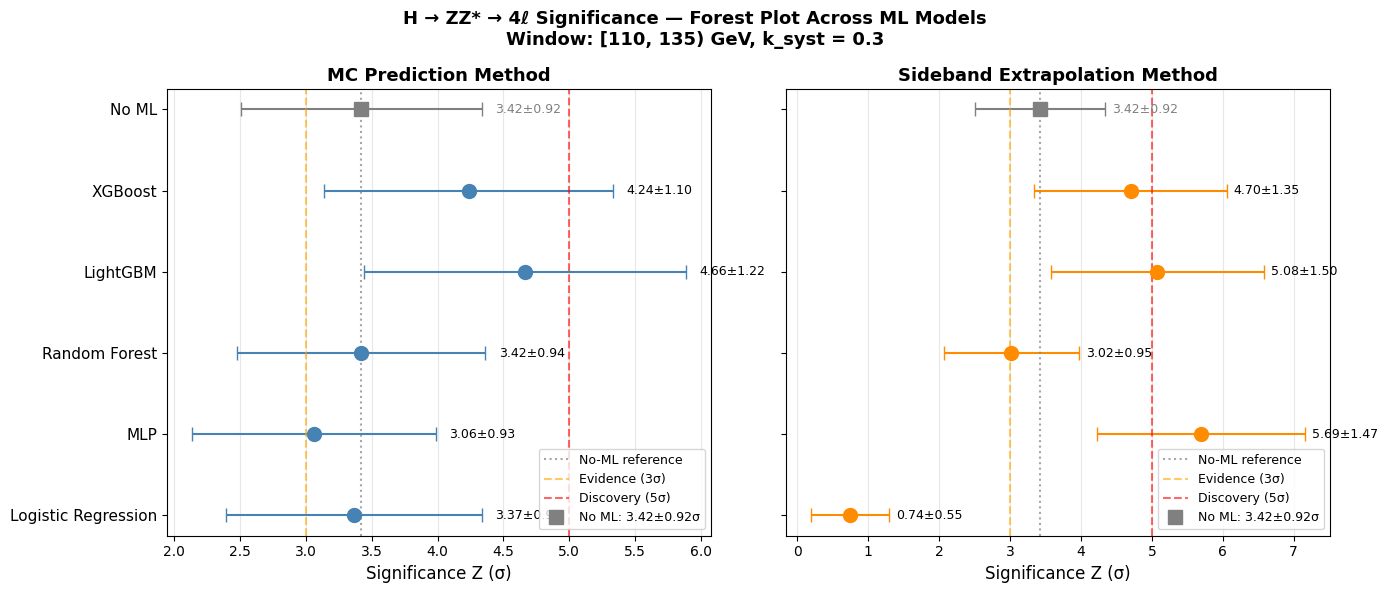

In [111]:
# ============================================================================
# FOREST PLOTS: MC PREDICTION & SIDEBAND METHOD ACROSS MODELS
# ============================================================================
# Reuses cached OOF scores and real-data scores — no retraining needed.
# Set MODEL_THRESHOLDS below to whatever you want for each model.

# ----------------------------------------------------------------------------
# CONFIG — edit thresholds per model here
# ----------------------------------------------------------------------------
MODEL_THRESHOLDS = {
    'XGBoost':       0.65,
    'LightGBM':      0.65,
    'Random Forest': 0.65,
    'MLP':           0.65,
    'Logistic Regression': 0.65
}

# Map model name → (oof_score, data_score, m_data) tuples
# These names must match your cached variables from earlier training runs.
MODEL_DATA = {
    'XGBoost':       ('oof_mc',  'data_scores',     'm_data'),      # XGBoost original cell
    'LightGBM':      ('oof_lgb', 'data_scores_lgb', 'm_data_lgb'),
    'Random Forest': ('oof_rf',  'data_scores_rf',  'm_data_rf'),
    'MLP':           ('oof_mlp', 'data_scores_mlp', 'm_data_mlp'),
    'Logistic Regression': ('oof_logreg', 'data_scores_lr', 'm_data_lr')
}

# Window & systematics
WIN_LO, WIN_HI = 110.0, 135.0
k_syst         = 0.30

# Sideband window
LEFT_SB_LO,  LEFT_SB_HI  = 90.0,  105.0
RIGHT_SB_LO, RIGHT_SB_HI = 140.0, 155.0

# ----------------------------------------------------------------------------
# Helper: compute MC-prediction and sideband Z + uncertainty for one model
# ----------------------------------------------------------------------------
def compute_methods(oof, data_scores, m_data, threshold):
    """Returns dict with Z and sigma_Z for MC-prediction and sideband methods."""
    out = {}

    # --- N_obs ---
    data_in_win_ml = (m_data >= WIN_LO) & (m_data < WIN_HI) & (data_scores > threshold)
    N_obs          = int(data_in_win_ml.sum())
    sigma_obs      = np.sqrt(N_obs)

    # --- METHOD 1: MC Prediction ---
    bkg_mask = (y_mc == 0) & (oof > threshold) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
    B_mc     = w_mc[bkg_mask].sum()
    sigma_B_mc = np.sqrt((w_mc[bkg_mask]**2).sum())

    if B_mc > 0:
        S_excess = N_obs - B_mc
        denom    = B_mc + (k_syst * B_mc)**2
        Z        = S_excess / np.sqrt(denom)
        term_obs = sigma_obs**2 / denom
        term_B   = (S_excess**2 * (1 + 2*k_syst**2 * B_mc)**2 * sigma_B_mc**2) / (4 * denom**3)
        sigma_Z  = np.sqrt(term_obs + term_B)
    else:
        Z, sigma_Z, B_mc = np.nan, np.nan, np.nan
    out['mc_pred'] = {'Z': Z, 'sigma_Z': sigma_Z, 'B': B_mc, 'N_obs': N_obs}

    # --- METHOD 3: Sideband ---
    left_sb  = ((m_data >= LEFT_SB_LO)  & (m_data < LEFT_SB_HI)  & (data_scores > threshold))
    right_sb = ((m_data >= RIGHT_SB_LO) & (m_data < RIGHT_SB_HI) & (data_scores > threshold))
    N_sb     = int(left_sb.sum()) + int(right_sb.sum())

    sb_width   = (LEFT_SB_HI - LEFT_SB_LO) + (RIGHT_SB_HI - RIGHT_SB_LO)
    sig_width  = WIN_HI - WIN_LO
    B_sb       = N_sb * (sig_width / sb_width)
    sigma_B_sb = np.sqrt(N_sb) * (sig_width / sb_width)

    if B_sb > 0:
        S_excess = N_obs - B_sb
        denom    = B_sb + (k_syst * B_sb)**2
        Z        = S_excess / np.sqrt(denom)
        term_obs = sigma_obs**2 / denom
        term_B   = (S_excess**2 * (1 + 2*k_syst**2 * B_sb)**2 * sigma_B_sb**2) / (4 * denom**3)
        sigma_Z  = np.sqrt(term_obs + term_B)
    else:
        Z, sigma_Z = np.nan, np.nan
    out['sideband'] = {'Z': Z, 'sigma_Z': sigma_Z, 'B': B_sb, 'N_obs': N_obs}

    return out

# ----------------------------------------------------------------------------
# Compute per-model results
# ----------------------------------------------------------------------------
results = {}
for name, (oof_var, data_var, mdata_var) in MODEL_DATA.items():
    if oof_var not in globals():
        print(f"[skip] {name}: '{oof_var}' not found in globals — did you run that model's training cell?")
        continue
    oof   = globals()[oof_var]
    dscr  = globals()[data_var]
    mdata = globals()[mdata_var]
    thr   = MODEL_THRESHOLDS[name]
    results[name] = compute_methods(oof, dscr, mdata, thr)
    results[name]['threshold'] = thr

# ----------------------------------------------------------------------------
# Also compute No-ML baseline (same for all models — uses raw data + MC)
# ----------------------------------------------------------------------------
sig_key  = r'Signal ($m_H$ = 125 GeV)'
bkg_keys = [s for s in z_masses if s != sig_key]

# Use any model's m_data (they're all the same — reconstructed from same data)
first_model = next(iter(results))
m_data_any  = globals()[MODEL_DATA[first_model][2]]

N_obs_noml = int(((m_data_any >= WIN_LO) & (m_data_any < WIN_HI)).sum())
sigma_obs_noml = np.sqrt(N_obs_noml)

B_noml, sumw2_B_noml = 0.0, 0.0
for s in bkg_keys:
    m = z_masses[s]['mass']; w = z_masses[s]['w']
    inw = (m >= WIN_LO) & (m < WIN_HI)
    B_noml       += float(w[inw].sum())
    sumw2_B_noml += float((w[inw]**2).sum())
sigma_B_noml = np.sqrt(sumw2_B_noml)

S_excess_noml = N_obs_noml - B_noml
denom_noml    = B_noml + (k_syst * B_noml)**2
Z_noml        = S_excess_noml / np.sqrt(denom_noml)
term_obs      = sigma_obs_noml**2 / denom_noml
term_B        = (S_excess_noml**2 * (1 + 2*k_syst**2 * B_noml)**2 * sigma_B_noml**2) / (4 * denom_noml**3)
sigma_Z_noml  = np.sqrt(term_obs + term_B)

# ----------------------------------------------------------------------------
# Print summary table
# ----------------------------------------------------------------------------
print("="*80)
print("FOREST PLOT INPUTS")
print("="*80)
print(f"{'Model':<18} {'Thr':>6} {'N_obs':>7} {'B_MC':>8} {'Z_MC':>8} {'B_SB':>8} {'Z_SB':>8}")
print("-"*80)
print(f"{'No ML (baseline)':<18} {'—':>6} {N_obs_noml:>7d} {B_noml:>8.2f} "
      f"{Z_noml:>8.2f} {'—':>8} {'—':>8}")
for name, r in results.items():
    print(f"{name:<18} {r['threshold']:>6.2f} {r['mc_pred']['N_obs']:>7d} "
          f"{r['mc_pred']['B']:>8.2f} {r['mc_pred']['Z']:>8.2f} "
          f"{r['sideband']['B']:>8.2f} {r['sideband']['Z']:>8.2f}")
print("="*80)

# ----------------------------------------------------------------------------
# Forest plots
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Order models top-to-bottom for forest plot (reverse so first model on top)
model_names  = list(results.keys())
y_positions  = np.arange(len(model_names) + 1)   # +1 for No-ML row
y_labels     = ['No ML'] + model_names
y_pos_no_ml  = 0
y_pos_models = np.arange(1, len(model_names) + 1)

# --- Left: MC Prediction ---
ax = axes[0]
ax.errorbar([Z_noml], [y_pos_no_ml], xerr=[sigma_Z_noml],
            fmt='s', color='gray', markersize=10, capsize=5,
            label=f'No ML: {Z_noml:.2f}±{sigma_Z_noml:.2f}σ')

z_vals  = [results[m]['mc_pred']['Z']       for m in model_names]
z_errs  = [results[m]['mc_pred']['sigma_Z'] for m in model_names]
ax.errorbar(z_vals, y_pos_models, xerr=z_errs,
            fmt='o', color='steelblue', markersize=10, capsize=5)

# Annotate Z values
for i, (z, e) in enumerate(zip(z_vals, z_errs)):
    ax.text(z + e + 0.1, y_pos_models[i], f'{z:.2f}±{e:.2f}',
            va='center', fontsize=9)
ax.text(Z_noml + sigma_Z_noml + 0.1, y_pos_no_ml, f'{Z_noml:.2f}±{sigma_Z_noml:.2f}',
        va='center', fontsize=9, color='gray')

ax.axvline(Z_noml, linestyle=':', color='gray', alpha=0.7, label='No-ML reference')
ax.axvline(3.0, linestyle='--', color='orange', alpha=0.6, label='Evidence (3σ)')
ax.axvline(5.0, linestyle='--', color='red',    alpha=0.6, label='Discovery (5σ)')

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=11)
ax.set_xlabel('Significance Z (σ)', fontsize=12)
ax.set_title('MC Prediction Method', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()   # Top model = first

# --- Right: Sideband ---
ax = axes[1]
ax.errorbar([Z_noml], [y_pos_no_ml], xerr=[sigma_Z_noml],
            fmt='s', color='gray', markersize=10, capsize=5,
            label=f'No ML: {Z_noml:.2f}±{sigma_Z_noml:.2f}σ')

z_vals  = [results[m]['sideband']['Z']       for m in model_names]
z_errs  = [results[m]['sideband']['sigma_Z'] for m in model_names]
ax.errorbar(z_vals, y_pos_models, xerr=z_errs,
            fmt='o', color='darkorange', markersize=10, capsize=5)

for i, (z, e) in enumerate(zip(z_vals, z_errs)):
    if np.isfinite(z):
        ax.text(z + e + 0.1, y_pos_models[i], f'{z:.2f}±{e:.2f}',
                va='center', fontsize=9)
ax.text(Z_noml + sigma_Z_noml + 0.1, y_pos_no_ml, f'{Z_noml:.2f}±{sigma_Z_noml:.2f}',
        va='center', fontsize=9, color='gray')

ax.axvline(Z_noml, linestyle=':', color='gray', alpha=0.7, label='No-ML reference')
ax.axvline(3.0, linestyle='--', color='orange', alpha=0.6, label='Evidence (3σ)')
ax.axvline(5.0, linestyle='--', color='red',    alpha=0.6, label='Discovery (5σ)')

ax.set_xlabel('Significance Z (σ)', fontsize=12)
ax.set_title('Sideband Extrapolation Method', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right', fontsize=9)

plt.suptitle(f'H → ZZ* → 4ℓ Significance — Forest Plot Across ML Models\n'
             f'Window: [{WIN_LO:.0f}, {WIN_HI:.0f}) GeV, '
             f'k_syst = {k_syst}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("forest_plots.png", dpi=300, bbox_inches='tight')

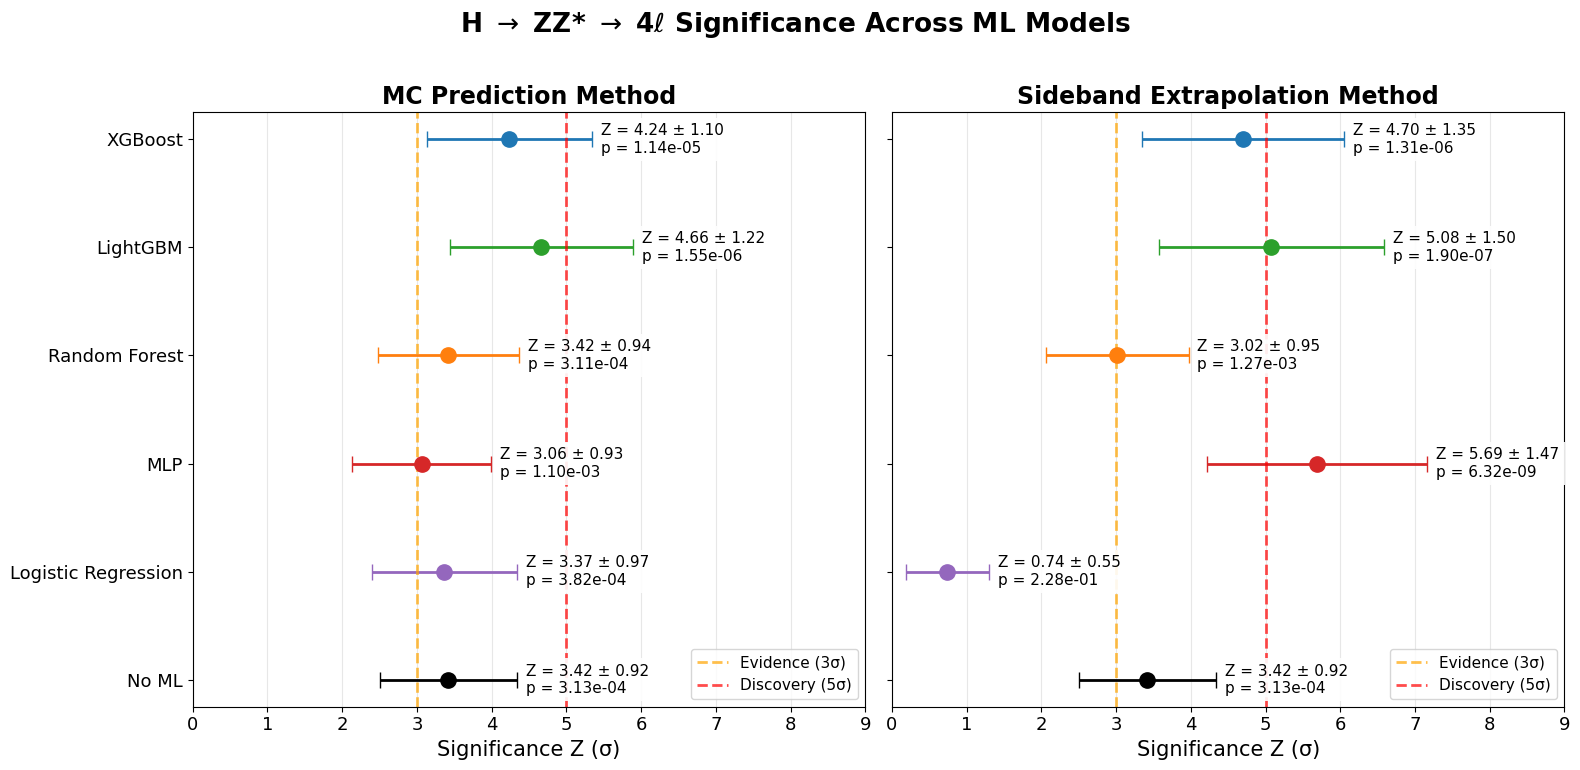

In [110]:
# ----------------------------------------------------------------------------
# Forest plots
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), sharey=True)

# Append No-ML baseline as the last row of the plot.
# We reuse Z_noml / sigma_Z_noml computed earlier in the notebook; the No-ML
# values are identical for the two methods (no classifier cut applied).
model_names_plot = list(results.keys()) + ['No ML']
y_positions     = np.arange(len(model_names_plot))

# Color for the No-ML row (not part of roc_colors)
NOML_COLOR = 'black'

# ----------------------------------------------------------------------------
# LEFT: MC Prediction
# ----------------------------------------------------------------------------
ax = axes[0]

for i, name in enumerate(model_names_plot):

    if name == 'No ML':
        z, e   = Z_noml, sigma_Z_noml
        p_val  = norm.sf(z)
        color  = NOML_COLOR
    else:
        z      = results[name]['mc_pred']['Z']
        e      = results[name]['mc_pred']['sigma_Z']
        p_val  = norm.sf(z) if np.isfinite(z) else np.nan
        color  = roc_colors[name]

    ax.errorbar(
        z,
        y_positions[i],
        xerr=e,
        fmt='o',
        color=color,
        markersize=11,
        capsize=6,
        elinewidth=2
    )

    if np.isfinite(z):
        ax.text(
            z + e + 0.12,
            y_positions[i],
            f'Z = {z:.2f} ± {e:.2f}\np = {p_val:.2e}',
            va='center',
            fontsize=11,
            bbox=dict(
                facecolor='white',
                alpha=0.9,
                edgecolor='none'
            )
        )

ax.axvline(3.0, linestyle='--', color='orange',
           alpha=0.7, linewidth=2,
           label='Evidence (3σ)')

ax.axvline(5.0, linestyle='--', color='red',
           alpha=0.7, linewidth=2,
           label='Discovery (5σ)')

ax.set_yticks(y_positions)
ax.set_yticklabels(model_names_plot, fontsize=13)

ax.set_xlabel('Significance Z (σ)', fontsize=15)

ax.set_title(
    'MC Prediction Method',
    fontsize=17,
    fontweight='bold'
)

ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 9)
ax.tick_params(axis='x', labelsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.invert_yaxis()

# ----------------------------------------------------------------------------
# RIGHT: Sideband
# ----------------------------------------------------------------------------
ax = axes[1]

for i, name in enumerate(model_names_plot):

    if name == 'No ML':
        # No classifier cut, so MC and sideband baselines coincide
        z, e   = Z_noml, sigma_Z_noml
        p_val  = norm.sf(z)
        color  = NOML_COLOR
    else:
        z      = results[name]['sideband']['Z']
        e      = results[name]['sideband']['sigma_Z']
        p_val  = norm.sf(z) if np.isfinite(z) else np.nan
        color  = roc_colors[name]

    ax.errorbar(
        z,
        y_positions[i],
        xerr=e,
        fmt='o',
        color=color,
        markersize=11,
        capsize=6,
        elinewidth=2
    )

    if np.isfinite(z):

        ax.text(
            z + e + 0.12,
            y_positions[i],
            f'Z = {z:.2f} ± {e:.2f}\np = {p_val:.2e}',
            va='center',
            fontsize=11,
            bbox=dict(
                facecolor='white',
                alpha=0.9,
                edgecolor='none'
            )
        )

ax.axvline(3.0, linestyle='--', color='orange',
           alpha=0.7, linewidth=2,
           label='Evidence (3σ)')

ax.axvline(5.0, linestyle='--', color='red',
           alpha=0.7, linewidth=2,
           label='Discovery (5σ)')

ax.set_xlabel('Significance Z (σ)', fontsize=15)

ax.set_title(
    'Sideband Extrapolation Method',
    fontsize=17,
    fontweight='bold'
)

ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 9)
ax.tick_params(axis='x', labelsize=13)
ax.legend(loc='lower right', fontsize=11)

# ----------------------------------------------------------------------------
# GLOBAL TITLE
# ----------------------------------------------------------------------------
plt.suptitle(
    r'H $\rightarrow$ ZZ* $\rightarrow$ 4$\ell$ Significance Across ML Models',
    fontsize=19,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "forest_plots_clean.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 14.1 P-value table across methods *(paper Table VII)*

In [105]:

# ----------------------------------------------------------------------------
# PRINT P-VALUE TABLE
# ----------------------------------------------------------------------------
print("=" * 90)
print(f"{'Model':<22} {'Method':<18} {'Z':>8} {'σ_Z':>10} {'p-value':>18}")
print("=" * 90)

for name in model_names:

    # --- MC prediction ---
    z_mc = results[name]['mc_pred']['Z']
    e_mc = results[name]['mc_pred']['sigma_Z']
    p_mc = norm.sf(z_mc)

    print(
        f"{name:<22} "
        f"{'MC Prediction':<18} "
        f"{z_mc:>8.2f} "
        f"{e_mc:>10.2f} "
        f"{p_mc:>18.3e}"
    )

    # --- Sideband ---
    z_sb = results[name]['sideband']['Z']
    e_sb = results[name]['sideband']['sigma_Z']
    p_sb = norm.sf(z_sb)

    print(
        f"{'':<22} "
        f"{'Sideband':<18} "
        f"{z_sb:>8.2f} "
        f"{e_sb:>10.2f} "
        f"{p_sb:>18.3e}"
    )

    print("-" * 90)

Model                  Method                    Z        σ_Z            p-value
XGBoost                MC Prediction          4.24       1.10          1.139e-05
                       Sideband               4.70       1.35          1.306e-06
------------------------------------------------------------------------------------------
LightGBM               MC Prediction          4.66       1.22          1.551e-06
                       Sideband               5.08       1.50          1.898e-07
------------------------------------------------------------------------------------------
Random Forest          MC Prediction          3.42       0.94          3.114e-04
                       Sideband               3.02       0.95          1.273e-03
------------------------------------------------------------------------------------------
MLP                    MC Prediction          3.06       0.93          1.101e-03
                       Sideband               5.69       1.47          6.318e-0

In [106]:
# ============================================================================
# P-VALUE TABLE — MC PREDICTION & SIDEBAND METHOD ACROSS MODELS
# ============================================================================
# Reuses cached OOF + data scores from earlier training cells. No retraining.

# ----------------------------------------------------------------------------
# CONFIG: thresholds per model (must match what you've used elsewhere)
# ----------------------------------------------------------------------------
MODEL_THRESHOLDS = {
    'XGBoost':              0.65,
    'LightGBM':             0.65,
    'Random Forest':        0.65,
    'MLP':                  0.65,
    'Logistic Regression':  0.65,
}

# Map model name → cached variable names (from each model's training cell)
MODEL_VARS = {
    'XGBoost':              ('oof_mc',     'data_scores',     'm_data'),
    'LightGBM':             ('oof_lgb',    'data_scores_lgb', 'm_data_lgb'),
    'Random Forest':        ('oof_rf',     'data_scores_rf',  'm_data_rf'),
    'MLP':                  ('oof_mlp',    'data_scores_mlp', 'm_data_mlp'),
    'Logistic Regression':  ('oof_logreg', 'data_scores_lr',  'm_data_lr'),
}

# Signal window & systematics
WIN_LO, WIN_HI = 110.0, 135.0
k_syst         = 0.30

# Sideband definition
LEFT_SB_LO,  LEFT_SB_HI  =  90.0, 105.0
RIGHT_SB_LO, RIGHT_SB_HI = 140.0, 155.0

# ----------------------------------------------------------------------------
# Compute Z, sigma_Z, p for MC and sideband methods for one model
# ----------------------------------------------------------------------------
def compute_z_and_p(oof, data_scores, m_data, threshold):
    out = {'threshold': threshold}

    # --- N_obs in signal window after ML cut ---
    in_win_ml = (m_data >= WIN_LO) & (m_data < WIN_HI) & (data_scores > threshold)
    N_obs     = int(in_win_ml.sum())
    sigma_obs = np.sqrt(max(N_obs, 1))   # Poisson; avoid zero
    out['N_obs'] = N_obs

    # ============= METHOD 1: MC PREDICTION =============
    bkg_mask = (y_mc == 0) & (oof > threshold) & (m_mc >= WIN_LO) & (m_mc < WIN_HI)
    B_mc       = float(w_mc[bkg_mask].sum())
    sigma_B_mc = float(np.sqrt((w_mc[bkg_mask] ** 2).sum()))

    if B_mc > 0:
        S_excess = N_obs - B_mc
        denom    = B_mc + (k_syst * B_mc) ** 2
        Z_mc     = S_excess / np.sqrt(denom)
        term_obs = sigma_obs ** 2 / denom
        term_B   = (S_excess ** 2 *
                    (1 + 2 * k_syst ** 2 * B_mc) ** 2 *
                    sigma_B_mc ** 2) / (4 * denom ** 3)
        sigma_Z_mc = np.sqrt(term_obs + term_B)
        p_mc       = norm.sf(Z_mc)        # one-sided p-value
    else:
        Z_mc = sigma_Z_mc = np.nan
        p_mc = np.nan

    out['B_mc']       = B_mc
    out['Z_mc']       = Z_mc
    out['sigma_Z_mc'] = sigma_Z_mc
    out['p_mc']       = p_mc

    # ============= METHOD 2: SIDEBAND EXTRAPOLATION =============
    left_sb  = (m_data >= LEFT_SB_LO)  & (m_data < LEFT_SB_HI)  & (data_scores > threshold)
    right_sb = (m_data >= RIGHT_SB_LO) & (m_data < RIGHT_SB_HI) & (data_scores > threshold)
    N_sb_total = int(left_sb.sum() + right_sb.sum())

    sb_width  = (LEFT_SB_HI  - LEFT_SB_LO) + (RIGHT_SB_HI - RIGHT_SB_LO)
    sig_width = WIN_HI - WIN_LO
    scale     = sig_width / sb_width

    B_sb       = N_sb_total * scale
    sigma_B_sb = np.sqrt(N_sb_total) * scale

    if B_sb > 0:
        S_excess = N_obs - B_sb
        denom    = B_sb + (k_syst * B_sb) ** 2
        Z_sb     = S_excess / np.sqrt(denom)
        term_obs = sigma_obs ** 2 / denom
        term_B   = (S_excess ** 2 *
                    (1 + 2 * k_syst ** 2 * B_sb) ** 2 *
                    sigma_B_sb ** 2) / (4 * denom ** 3)
        sigma_Z_sb = np.sqrt(term_obs + term_B)
        p_sb       = norm.sf(Z_sb)
    else:
        Z_sb = sigma_Z_sb = np.nan
        p_sb = np.nan

    out['B_sb']       = B_sb
    out['Z_sb']       = Z_sb
    out['sigma_Z_sb'] = sigma_Z_sb
    out['p_sb']       = p_sb

    return out

# ----------------------------------------------------------------------------
# Run for every model and print as a table
# ----------------------------------------------------------------------------
print('=' * 110)
print('REAL-DATA SIGNIFICANCE — MC PREDICTION vs SIDEBAND EXTRAPOLATION')
print(f'  Signal window: m_4l ∈ [{WIN_LO}, {WIN_HI}] GeV   ·   κ = {k_syst}')
print('=' * 110)
print(f'{"Model":<22} {"Thr":>5} {"N_obs":>6}'
      f'   ║  {"B_MC":>7} {"Z_MC":>10} {"σ_Z":>6} {"p_MC":>11}'
      f'   ║  {"B_SB":>7} {"Z_SB":>10} {"σ_Z":>6} {"p_SB":>11}')
print('-' * 110)

results = {}
for model_name, (oof_var, data_var, m_var) in MODEL_VARS.items():
    # Pull cached arrays from globals
    if oof_var not in globals() or data_var not in globals() or m_var not in globals():
        print(f'  ⚠ {model_name}: cached arrays not found ({oof_var}, {data_var}, {m_var}) — skipping.')
        continue

    oof  = globals()[oof_var]
    dsc  = globals()[data_var]
    mdat = globals()[m_var]
    thr  = MODEL_THRESHOLDS[model_name]

    r = compute_z_and_p(oof, dsc, mdat, thr)
    results[model_name] = r

    print(f'{model_name:<22} {thr:>5.2f} {r["N_obs"]:>6}'
          f'   ║  {r["B_mc"]:>7.2f} {r["Z_mc"]:>7.2f}±{r["sigma_Z_mc"]:.2f} {r["p_mc"]:>11.2e}'
          f'   ║  {r["B_sb"]:>7.2f} {r["Z_sb"]:>7.2f}±{r["sigma_Z_sb"]:.2f} {r["p_sb"]:>11.2e}')

print('=' * 110)
print('Note: Z<3σ → not evidence;  3σ<Z<5σ → evidence;  Z≥5σ → discovery.')
print('=' * 110)

REAL-DATA SIGNIFICANCE — MC PREDICTION vs SIDEBAND EXTRAPOLATION
  Signal window: m_4l ∈ [110.0, 135.0] GeV   ·   κ = 0.3
Model                    Thr  N_obs   ║     B_MC       Z_MC    σ_Z        p_MC   ║     B_SB       Z_SB    σ_Z        p_SB
--------------------------------------------------------------------------------------------------------------
XGBoost                 0.65     47   ║    17.96    4.24±1.10    1.14e-05   ║    16.67    4.70±1.35    1.31e-06
LightGBM                0.65     43   ║    15.13    4.66±1.22    1.55e-06   ║    14.17    5.08±1.50    1.90e-07
Random Forest           0.65     49   ║    21.66    3.42±0.94    3.11e-04   ║    23.33    3.02±0.95    1.27e-03
MLP                     0.65     58   ║    27.80    3.06±0.93    1.10e-03   ║    18.33    5.69±1.47    6.32e-09
Logistic Regression     0.65     45   ║    19.91    3.37±0.97    3.82e-04   ║    35.83    0.74±0.55    2.28e-01
Note: Z<3σ → not evidence;  3σ<Z<5σ → evidence;  Z≥5σ → discovery.
